In [1]:
# =============================================================================
# PAPERMILL PARAMETERS ONLY
# =============================================================================
# Keep this cell limited to simple assignments. Papermill injects runtime
# parameters immediately after this cell; all executable preprocessing is in
# the next cell so injected values are used correctly.

INPUT_FILE = "../Dataset/Breast-Data/Mask1/Pre_M1.csv"
DATASET_TAG = None
BATCH_ROOT = "./nested_cv_outputs_single_batch"
OUTPUT_DIR = None
TARGET_COLUMN = "Label"
DATASET_OUTPUT_ROOT = None
CLEANED_DATASET_PATH = None


GROUP_COLUMN = "INFO_PatientName"
ROI_COLUMN = "INFO_NameOfRoi"

# Unit-of-analysis / label-integrity policy
# Options:
#   "lesion_level"          : keep current structure; each ROI/lesion row is one sample
#   "drop_mixed_patients"   : remove patients that contain both labels; sensitivity analysis only
#   "raise_on_mixed"        : stop if any patient has mixed labels
UNIT_OF_ANALYSIS_POLICY = "lesion_level"
# UNIT_OF_ANALYSIS_POLICY = "drop_mixed_patients"
# Duplicate patient-ROI policy
# Options:
#   "raise"                 : stop if duplicate patient-ROI pairs exist
#   "keep_first"            : keep first duplicate only
DUPLICATE_PATIENT_ROI_POLICY = "raise"


OVERWRITE_FS_RUNS = True
COMPARE_SMOTE_OPTIONS = True
TARGET_ABLATION = None
RUN_SMOTE_ABLATION = False
RUN_SMOTE_VS_BASELINE_COMPARISON = False


In [2]:
# Parameters
INPUT_FILE = "/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/output/all_single_datasets_standardized/ADC_single_standardized.csv"
DATASET_TAG = "ADC"
BATCH_ROOT = "nested_cv_outputs_single_dataset_batch_smote_compare"
OUTPUT_DIR = "output/cleaned_single_datasets_smote_compare/ADC"
TARGET_COLUMN = "Label"
DATASET_OUTPUT_ROOT = "nested_cv_outputs_single_dataset_batch_smote_compare/ADC"
CLEANED_DATASET_PATH = "output/cleaned_single_datasets_smote_compare/ADC/ADC_single_standardized_Cleaned.csv"
OVERWRITE_FS_RUNS = True
COMPARE_SMOTE_OPTIONS = True
TARGET_ABLATION = None
RUN_SMOTE_ABLATION = False
RUN_SMOTE_VS_BASELINE_COMPARISON = False


In [3]:
# =============================================================================
# COMPLETE RADIOMICS PROCESSING PIPELINE FOR SINGLE DATASET
# =============================================================================

import os
import re
from pathlib import Path
import pandas as pd

print("=" * 80)
print("🎬 STARTING COMPLETE RADIOMICS PROCESSING PIPELINE")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. GLOBAL DATASET CONFIGURATION
# -----------------------------------------------------------------------------

def _as_bool(value):
    """Robust bool parser for papermill-injected parameters."""
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    return str(value).strip().lower() in {"1", "true", "yes", "y", "on"}

INPUT_FILE = str(INPUT_FILE)
_raw_stem = Path(INPUT_FILE).stem

if DATASET_TAG is None or str(DATASET_TAG).strip() == "":
    DATASET_TAG = _raw_stem
    for suffix in ["_M1_single", "_single"]:
        if DATASET_TAG.endswith(suffix):
            DATASET_TAG = DATASET_TAG[:-len(suffix)]
else:
    DATASET_TAG = str(DATASET_TAG)

BATCH_ROOT = str(BATCH_ROOT)

if OUTPUT_DIR is None or str(OUTPUT_DIR).strip() == "":
    OUTPUT_DIR = str(Path("./output/cleaned_single") / DATASET_TAG)
else:
    OUTPUT_DIR = str(OUTPUT_DIR)

TARGET_COLUMN = str(TARGET_COLUMN)

OVERWRITE_FS_RUNS = _as_bool(OVERWRITE_FS_RUNS)
COMPARE_SMOTE_OPTIONS = _as_bool(COMPARE_SMOTE_OPTIONS)



GROUP_COLUMN = str(GROUP_COLUMN)
ROI_COLUMN = str(ROI_COLUMN)

UNIT_OF_ANALYSIS_POLICY = str(UNIT_OF_ANALYSIS_POLICY).strip()
DUPLICATE_PATIENT_ROI_POLICY = str(DUPLICATE_PATIENT_ROI_POLICY).strip()

valid_unit_policies = {
    "lesion_level",
    "drop_mixed_patients",
    "raise_on_mixed",
}

valid_duplicate_policies = {
    "raise",
    "keep_first",
}

if UNIT_OF_ANALYSIS_POLICY not in valid_unit_policies:
    raise ValueError(
        f"Invalid UNIT_OF_ANALYSIS_POLICY={UNIT_OF_ANALYSIS_POLICY}. "
        f"Valid options are: {sorted(valid_unit_policies)}"
    )

if DUPLICATE_PATIENT_ROI_POLICY not in valid_duplicate_policies:
    raise ValueError(
        f"Invalid DUPLICATE_PATIENT_ROI_POLICY={DUPLICATE_PATIENT_ROI_POLICY}. "
        f"Valid options are: {sorted(valid_duplicate_policies)}"
    )



if TARGET_ABLATION is not None:
    TARGET_ABLATION = str(TARGET_ABLATION)

RUN_SMOTE_ABLATION = _as_bool(RUN_SMOTE_ABLATION)
RUN_SMOTE_VS_BASELINE_COMPARISON = _as_bool(RUN_SMOTE_VS_BASELINE_COMPARISON)

if DATASET_OUTPUT_ROOT is None or str(DATASET_OUTPUT_ROOT).strip() == "":
    DATASET_OUTPUT_ROOT = str(Path(BATCH_ROOT) / DATASET_TAG)
else:
    DATASET_OUTPUT_ROOT = str(DATASET_OUTPUT_ROOT)

if CLEANED_DATASET_PATH is None or str(CLEANED_DATASET_PATH).strip() == "":
    CLEANED_DATASET_PATH = str(Path(OUTPUT_DIR) / f"{_raw_stem}_Cleaned.csv")
else:
    CLEANED_DATASET_PATH = str(CLEANED_DATASET_PATH)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATASET_OUTPUT_ROOT, exist_ok=True)

print("\nPARAMETERS")
print("-" * 80)
print("INPUT_FILE            :", INPUT_FILE)
print("DATASET_TAG           :", DATASET_TAG)
print("BATCH_ROOT            :", BATCH_ROOT)
print("OUTPUT_DIR            :", OUTPUT_DIR)
print("DATASET_OUTPUT_ROOT   :", DATASET_OUTPUT_ROOT)
print("CLEANED_DATASET_PATH  :", CLEANED_DATASET_PATH)
print("OVERWRITE_FS_RUNS     :", OVERWRITE_FS_RUNS)
print("COMPARE_SMOTE_OPTIONS :", COMPARE_SMOTE_OPTIONS)
print("RUN_SMOTE_ABLATION    :", RUN_SMOTE_ABLATION)
print("RUN_SMOTE_VS_BASELINE :", RUN_SMOTE_VS_BASELINE_COMPARISON)
print("TARGET_ABLATION       :", TARGET_ABLATION)

print("GROUP_COLUMN          :", GROUP_COLUMN)
print("ROI_COLUMN            :", ROI_COLUMN)
print("UNIT_POLICY           :", UNIT_OF_ANALYSIS_POLICY)
print("DUPLICATE_ROI_POLICY  :", DUPLICATE_PATIENT_ROI_POLICY)
# -----------------------------------------------------------------------------
# 2. FEATURE NOMENCLATURE TRANSFORMATION
# -----------------------------------------------------------------------------

def clean_feature_name(col_name, target_column="Label"):

    original = str(col_name).strip()

    protected_columns = {
        target_column,
        GROUP_COLUMN,
        ROI_COLUMN,
        "INFO_PatientName",
        "INFO_NameOfRoi",
        "PatientID",
        "Patient_ID",
        "ROI",
        "Roi",
        "NameOfRoi",
    }


    if original in protected_columns:
        return original

    new_name = original

    new_name = re.sub(r"\([^)]*\)", "", new_name)

    new_name = re.sub(r"MORPHOLOGICAL", "Morph", new_name, flags=re.IGNORECASE)
    new_name = re.sub(r"INTENSITY-BASED", "IB", new_name, flags=re.IGNORECASE)
    new_name = re.sub(r"INTENSITY-HISTOGRAM", "IH", new_name, flags=re.IGNORECASE)

    new_name = new_name.strip()
    new_name = re.sub(r"\s+", "_", new_name)
    new_name = re.sub(r"_+", "_", new_name)
    new_name = re.sub(r"^_+|_+$", "", new_name)
    new_name = re.sub(r"[^0-9a-zA-Z_]+", "_", new_name)
    new_name = re.sub(r"_+", "_", new_name)
    new_name = new_name.strip("_")

    return new_name


# -----------------------------------------------------------------------------
# 3. MAKE COLUMN NAMES UNIQUE
# -----------------------------------------------------------------------------

def make_unique_columns(columns):

    seen = {}
    unique_columns = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            unique_columns.append(col)
        else:
            seen[col] += 1
            unique_columns.append(f"{col}_{seen[col]}")

    return unique_columns


# -----------------------------------------------------------------------------
# 4. PROCESS DATASET
# -----------------------------------------------------------------------------

file_path = Path(INPUT_FILE)

if not file_path.exists():
    raise FileNotFoundError(f"Input dataset not found:\n{INPUT_FILE}")

print(f"\nReading dataset: {file_path.name}")

df = pd.read_csv(file_path)

empty_cols = df.columns[df.isna().all()].tolist()
if empty_cols:
    print(f"Dropping empty columns ({len(empty_cols)}):")
    print(empty_cols)
    df = df.drop(columns=empty_cols)

old_columns = df.columns.tolist()

cleaned_columns = [
    clean_feature_name(col, TARGET_COLUMN)
    for col in old_columns
]

final_columns = make_unique_columns(cleaned_columns)

df.columns = final_columns

output_csv_path = Path(CLEANED_DATASET_PATH)
output_csv_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_csv_path, index=False)

CLEANED_DATASET_PATH = str(output_csv_path)

print(f"\nCleaned dataset saved to:\n{output_csv_path}")

# -----------------------------------------------------------------------------
# 5. SAVE COLUMN MAPPING
# -----------------------------------------------------------------------------

mapping_df = pd.DataFrame({
    "file_name": file_path.name,
    "old_column_name": old_columns,
    "cleaned_column_name": cleaned_columns,
    "final_column_name": final_columns
})

mapping_path = Path(OUTPUT_DIR) / "column_name_mapping_all_files.csv"

mapping_df.to_csv(mapping_path, index=False)

print("\n" + "=" * 80)
print("PIPELINE FINISHED SUCCESSFULLY")
print("=" * 80)
print("Mapping file:")
print(mapping_path)
print("Cleaned dataset:")
print(output_csv_path)
print("Dataset output root:")
print(DATASET_OUTPUT_ROOT)


🎬 STARTING COMPLETE RADIOMICS PROCESSING PIPELINE

PARAMETERS
--------------------------------------------------------------------------------
INPUT_FILE            : /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/output/all_single_datasets_standardized/ADC_single_standardized.csv
DATASET_TAG           : ADC
BATCH_ROOT            : nested_cv_outputs_single_dataset_batch_smote_compare
OUTPUT_DIR            : output/cleaned_single_datasets_smote_compare/ADC
DATASET_OUTPUT_ROOT   : nested_cv_outputs_single_dataset_batch_smote_compare/ADC
CLEANED_DATASET_PATH  : output/cleaned_single_datasets_smote_compare/ADC/ADC_single_standardized_Cleaned.csv
OVERWRITE_FS_RUNS     : True
COMPARE_SMOTE_OPTIONS : True
RUN_SMOTE_ABLATION    : False
RUN_SMOTE_VS_BASELINE : False
TARGET_ABLATION       : None
GROUP_COLUMN          : INFO_PatientName
ROI_COLUMN            : INFO_NameOfRoi
UNIT_POLICY

In [4]:
# =============================================================================
# RUNTIME SAFETY PATCH: SERIAL EXECUTION FOR PYTHON 3.13 / JOBLIB-LOKY STABILITY
# =============================================================================
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["JOBLIB_TEMP_FOLDER"] = os.path.abspath("./joblib_tmp")
os.makedirs(os.environ["JOBLIB_TEMP_FOLDER"], exist_ok=True)

N_JOBS_SAFE = 1

In [5]:
# !pip install imblearn
!pip install statsmodels
!pip install imbalanced-learn 

In [6]:
# =============================================================================
# SYSTEM CONFIGURATION AND REPRODUCIBLE ENVIRONMENT INITIALIZATION
# =============================================================================
# Purpose:
#   - Consolidate all external packages, statistical tools, and ML frameworks.
#   - Establish environment flags for dynamic optional dependencies.
#   - Enforce operational constraints to isolate global execution states.
#
# Execution Context:
#   - To maintain methodological rigor and eliminate data leakage risks, 
#     no data ingestion or matrix transformations are initiated within this cell.
# =============================================================================

import io
import sys
import warnings
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, spearmanr, shapiro, pearsonr, ttest_ind

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GroupKFold,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.feature_selection import RFE, mutual_info_classif, VarianceThreshold
from sklearn.impute import SimpleImputer

# Suppress non-critical runtime warnings for production-ready reporting
warnings.filterwarnings('ignore', category=UserWarning)
# Establish global typesetting and visualization parameters for publication figures
matplotlib.rcParams['font.size'] = 11

# -----------------------------------------------------------------------------
# DYNAMIC EXTENSION VALIDATION (OPTIONAL PACKAGES)
# -----------------------------------------------------------------------------
# Inspect local runtime environment capabilities to toggle advanced functional 
# modules dynamically without breaking core model compilation pipelines.
# -----------------------------------------------------------------------------

# Hyperparameter Optimization Framework Verification (Optuna)
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

# Gradient Boosting Framework Verification (XGBoost)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Light Gradient Boosting Machine Verification (LightGBM)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except Exception:
    HAS_BORUTA = False

In [7]:
df.head()

,INFO_PatientName,INFO_NameOfRoi,FEATURE_RESULTS,Morph_Volume_cm3,Morph_ApproximateVolume_cm3,Morph_voxelsCounting_vx,Morph_SurfaceArea_cm2,Morph_SurfaceToVolumeRatio_cm,Morph_Compacity,Morph_Compactness1,...,GLSZM_LargeZoneLowGreyLevelEmphasis,GLSZM_LargeZoneHighGreyLevelEmphasis,GLSZM_GreyLevelNonUniformity,GLSZM_NormalisedGreyLevelNonUniformity,GLSZM_ZoneSizeNonUniformity,GLSZM_NormalisedZoneSizeNonUniformity,GLSZM_ZonePercentage,GLSZM_GreyLevelVariance,GLSZM_ZoneSizeVariance,Label
0,ADC_P1,M1_S2_P1_R_#1,1.074417,1.090,1090,7.079835,6.589469,17.533231,0.032178,0.367899,...,5640.524164,7.230483,0.026879,76.249071,0.283454,0.246789,129.280690,62.443388,6.968461,1
1,ADC_P1,M1_S3_P1_R_#1,0.187583,0.196,196,2.043052,10.891437,15.567716,0.036241,0.466662,...,62961.354840,3.000000,0.096774,5.193548,0.167534,0.158163,8.349636,61.895942,4.478232,1
2,ADC_P1,M1_S1_P1_R_#1,9.876958,9.909,9909,29.855902,3.022783,16.516654,0.034159,0.414580,...,177498.878400,41.051776,0.024715,308.196869,0.185549,0.167625,129.223051,500.454572,8.161199,1
3,ADC_P1,M1_S4_P1_R_#1,0.073667,0.082,82,1.787012,24.258075,32.427989,0.017398,0.107550,...,3318.560976,1.926829,0.046996,15.195122,0.370613,0.500000,66.304581,2.292683,5.113650,1
4,ADC_P1,M1_S5_P1_R_#1,0.192417,0.202,202,2.246322,11.674260,17.497073,0.032245,0.369421,...,68193.360000,3.600000,0.072000,10.120000,0.202400,0.247525,20.283600,27.518400,5.093661,1


In [8]:
# =============================================================================
# HYPERPARAMETER CONFIGURATION DICTIONARY & INFRASTRUCTURE MATRIX
# =============================================================================
# Purpose:
#   - Define the global configuration dictionary managing the ML pipeline.
#   - Establish strict operational parameters for feature selection filters,
#     stability pathways, nested cross-validation, and ontological categorization.
#   - Mitigate data leakage risks across data processing boundaries.
# =============================================================================


# =============================================================================
# HYPERPARAMETER CONFIGURATION DICTIONARY & INFRASTRUCTURE MATRIX
# =============================================================================

CONFIG = {

    # -------------------------------------------------------------------------
    # DATA DOMAIN PARAMETERS
    # -------------------------------------------------------------------------
    'VOLUME_COL': 'Morph_Volume_cm3',
    'LABEL_COL': TARGET_COLUMN,
    'GROUP_COL': GROUP_COLUMN,
    'ROI_COL': ROI_COLUMN,

    # Unit-of-analysis / data-integrity controls
    'UNIT_OF_ANALYSIS_POLICY': UNIT_OF_ANALYSIS_POLICY,
    'DUPLICATE_PATIENT_ROI_POLICY': DUPLICATE_PATIENT_ROI_POLICY,



    'PRINT_PATIENT_BREAKDOWN': False,
    # -------------------------------------------------------------------------
    # STAGE 0: UNIVARIATE SIGNIFICANCE FILTER
    # -------------------------------------------------------------------------
    'SIGNIFICANCE_ALPHA': 0.05,
    'SIGNIFICANCE_METHOD': 'fdr_bh',

    # -------------------------------------------------------------------------
    # 
    # 
    #  1: VOLUME DEPENDENCE CONTROL
    # -------------------------------------------------------------------------
    'VOLUME_CORR_THRESHOLD': 0.50,

    # -------------------------------------------------------------------------
    # STAGE 2: REDUNDANCY FILTERING
    # -------------------------------------------------------------------------
    'REDUNDANCY_CORR_THRESHOLD': 0.75,

    # -------------------------------------------------------------------------
    # STAGE 3: MULTICOLLINEARITY CONTROL (VIF)
    # -------------------------------------------------------------------------
    'VIF_THRESHOLD': 6,
    # 'MRMR_N_FEATURES': 16,

    # -------------------------------------------------------------------------
    # FEATURE SELECTION STRATEGY
    # -------------------------------------------------------------------------
    # 'FS_METHOD': 'corr_mrmr',  # Options: 'current_4stage', 'corr_mrmr', 'corr_elasticnet', 'mrmr_only'
    # 'FS_METHOD': 'current_4stage',
    # 'FS_METHOD': 'corr_elasticnet', #66
    # 'FS_METHOD': 'mrmr_only', #65-69
    # 'FS_METHOD' : "rfe_only",
    # 'FS_METHOD' : 'boruta_like',
    # 'FS_METHOD' : 'mrmr_custom',
    # 'FS_METHOD' : 'hier_mrmr_elasticnet', #67, n=14
    # 'FS_METHOD' : 'elasticnet_then_mrmr',
    'FS_METHOD' : 'mrmr_then_elasticnet_no_corr', #72, n=14
    # 'FS_METHOD' : 'elasticnet_only', #65
    # 'FS_METHOD': 'corr_mrmr_then_elasticnet', #62

    'USE_VOLUME_FILTER': False,

    'FS_CORR_THRESHOLD': 0.90,
    # 'FS_N_FEATURES': 8,
    # 'FS_N_FEATURES': 12,
    # 'FS_N_FEATURES': 16,
    'FS_N_FEATURES': 14,

    'USE_SMOTE': False,
    # -------------------------------------------------------------------------
    # STAGE 4: STABILITY SELECTION
    # -------------------------------------------------------------------------
    'STABILITY_N_ITERATIONS': 500, # 2000 for final runs
    'STABILITY_SUBSAMPLE_RATIO': 0.6,
    'STABILITY_SELECTION_THRESHOLD': 0.75,

    'TARGET_PFER': 1.0,

    'ELASTICNET_L1_RATIOS': [0.6, 0.7, 0.8, 0.9, 0.95],
    'ELASTICNET_CS': [0.001, 0.01, 0.05, 0.1, 0.5],
    'ELASTICNET_COEF_THRESHOLD': 1e-3,



    # -----------------------------------------------------------------------------
    # Improved mRMR / ElasticNet selector controls
    # -----------------------------------------------------------------------------
    # Options for MRMR_TRANSFORM:
    #   "none"     : old behavior; use raw feature matrix
    #   "standard" : StandardScaler before MI/correlation
    #   "robust"   : RobustScaler before MI/correlation; recommended for radiomics
    #   "rank"     : percentile-rank transform, then StandardScaler
    'MRMR_TRANSFORM': 'robust',

    # ElasticNet selector should no longer use fixed C/l1_ratio blindly.
    'TUNE_ELASTICNET_SELECTOR': True,

    # Group-aware inner CV for selector hyperparameter choice inside outer-train.
    'ELASTICNET_SELECTOR_INNER_FOLDS': 3,

    # Options: "standard", "robust"
    'ELASTICNET_SELECTOR_SCALER': 'robust',

    # Selector hyperparameter grid.
    # Keep this compact; selector tuning is nested inside outer folds.
    'ELASTICNET_SELECTOR_C_GRID': [0.01, 0.03, 0.1],
    'ELASTICNET_SELECTOR_L1_RATIO_GRID': [0.5, 0.8, 0.95],

    # Used to decide whether coefficients are effectively non-zero.
    'ELASTICNET_SELECTOR_COEF_THRESHOLD': 1e-5,

    # Metric for choosing selector hyperparameters.
    # Options: "auc", "pr_auc"
    'ELASTICNET_SELECTOR_SCORING': 'auc',

    # -------------------------------------------------------------------------
    # REPRODUCIBILITY / SCALING CONTROLS
    # -------------------------------------------------------------------------
    # MODEL_SCALER controls the fold-level final model scaling and the Optuna
    # inner-CV scaling. Use 'standard' for legacy reproduction and switch to
    # 'robust' only as an explicit ablation.
    'MODEL_SCALER': 'standard',

    # FS_K_TUNING_SCALER controls the light model used to select FS_N_FEATURES
    # inside the outer-training fold.
    'FS_K_TUNING_SCALER': 'standard',

    # AUTO_K_USE_GROUPS=False reproduces the older auto-k behavior.
    # Set True for publication-grade patient-aware auto-k tuning.
    'AUTO_K_USE_GROUPS': False,


    # -------------------------------------------------------------------------
    # ADAPTIVE THRESHOLDING
    # -------------------------------------------------------------------------
    'STABILITY_FALLBACK_STEP': 0.05,
    'STABILITY_FALLBACK_MIN_THRESHOLD': 0.55,
    'STABILITY_FALLBACK_MIN_FEATURES': 6,

    # -------------------------------------------------------------------------
    # NESTED CROSS-VALIDATION
    # -------------------------------------------------------------------------
    'N_OUTER_FOLDS': 5,
    'N_INNER_FOLDS': 3,
    'N_OPTUNA_TRIALS': 10, # Legacy reproduction default; stable screening can override in Cell 26
    'RANDOM_STATE': 100,

    # -------------------------------------------------------------------------
    # GROUPED CV (PATIENT-AWARE)
    # -------------------------------------------------------------------------
    'GKFOLD_N_SPLITS': 5,
    'GKFOLD_N_BOOTSTRAP': 2000,
    'GKFOLD_BOOTSTRAP_CI': 0.95,

    # -----------------------------------------------------------------------------
    # Outlier handling configuration
    # -----------------------------------------------------------------------------
    # Options:
    #   "none"      : no outlier clipping
    #   "iqr_clip"  : train-fold-only IQR clipping
    #   "quantile"  : train-fold-only quantile clipping
    #
    # Important:
    #   Outlier handling must be fitted only on training folds.
    # -----------------------------------------------------------------------------
    'OUTLIER_HANDLING': 'none',
    'OUTLIER_IQR_MULTIPLIER': 3.0,
    'OUTLIER_Q_LOW': 0.01,
    'OUTLIER_Q_HIGH': 0.99,
    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------
    'VERBOSE_FS': False,

    # -------------------------------------------------------------------------
    # FEATURE TAXONOMY (RADIONICS IBSI GROUPING)
    # -------------------------------------------------------------------------
    'CATEGORY_PATTERNS': {
        'MORPHOLOGY': [
            'shape', 'mesh', 'volume', 'surface', 'diameter',
            'sphericity', 'compactness', 'elongation', 'flatness'
        ],
        'INTENSITY': [
            'firstorder', 'histogram'
        ],
        'TEXTURE': [
            'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm'
        ],
    },
}



# -----------------------------------------------------------------------------
# DATASET-SPECIFIC OUTPUT ROUTING
# -----------------------------------------------------------------------------
CONFIG["INPUT_FILE"] = str(INPUT_FILE)
CONFIG["DATASET_TAG"] = str(DATASET_TAG)
CONFIG["BATCH_ROOT"] = str(BATCH_ROOT)
CONFIG["OUTPUT_DIR"] = str(OUTPUT_DIR)
CONFIG["CLEANED_DATASET_PATH"] = str(CLEANED_DATASET_PATH)
CONFIG["DATASET_OUTPUT_ROOT"] = str(DATASET_OUTPUT_ROOT)

os.makedirs(CONFIG["DATASET_OUTPUT_ROOT"], exist_ok=True)

print("Dataset-specific routing:")
print(f"   INPUT_FILE:            {CONFIG['INPUT_FILE']}")
print(f"   DATASET_TAG:           {CONFIG['DATASET_TAG']}")
print(f"   CLEANED_DATASET_PATH:  {CONFIG['CLEANED_DATASET_PATH']}")
print(f"   DATASET_OUTPUT_ROOT:   {CONFIG['DATASET_OUTPUT_ROOT']}")


# -----------------------------------------------------------------------------
# PIPELINE VERIFICATION AND HARDWARE ENVIRONMENT LOGGING
# -----------------------------------------------------------------------------
print("█" * 80)
print("   ✅ CELL 6: CONFIGURATION LOADED — NO LEAKAGE PIPELINE")
print("█" * 80)
print(f"\n   Libraries: numpy, pandas, scipy, sklearn, matplotlib")
print(f"   Optional:  Optuna={HAS_OPTUNA} | XGBoost={HAS_XGB} | LightGBM={HAS_LGBM}")
print(f"   Random State: {CONFIG['RANDOM_STATE']}")
print(
    f"   Evaluation: Nested CV | "
    f"Outer={CONFIG['N_OUTER_FOLDS']} | Inner={CONFIG['N_INNER_FOLDS']} | "
    f"Patient-aware=True"
)
print(f"   Verbose FS: {CONFIG['VERBOSE_FS']}")

Dataset-specific routing:
   INPUT_FILE:            /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/output/all_single_datasets_standardized/ADC_single_standardized.csv
   DATASET_TAG:           ADC
   CLEANED_DATASET_PATH:  output/cleaned_single_datasets_smote_compare/ADC/ADC_single_standardized_Cleaned.csv
   DATASET_OUTPUT_ROOT:   nested_cv_outputs_single_dataset_batch_smote_compare/ADC
████████████████████████████████████████████████████████████████████████████████
   ✅ CELL 6: CONFIGURATION LOADED — NO LEAKAGE PIPELINE
████████████████████████████████████████████████████████████████████████████████

   Libraries: numpy, pandas, scipy, sklearn, matplotlib
   Optional:  Optuna=True | XGBoost=True | LightGBM=True
   Random State: 100
   Evaluation: Nested CV | Outer=5 | Inner=3 | Patient-aware=True
   Verbose FS: False


In [9]:
# Verify volume column after Cell 1 column cleaning

volume_candidates = [
    c for c in df.columns
    if "Volume" in c and "ApproximateVolume" not in c
]

print("Volume candidates:", volume_candidates)

if CONFIG["VOLUME_COL"] not in df.columns:
    # if len(volume_candidates) == 1:
    CONFIG["VOLUME_COL"] = volume_candidates[0]
        # print(f"CONFIG['VOLUME_COL'] updated to: {CONFIG['VOLUME_COL']}")
    # else:
    #     raise ValueError(
    #         f"Could not uniquely identify volume column. Candidates: {volume_candidates}"
    #     )
else:
    print(f"CONFIG['VOLUME_COL'] verified: {CONFIG['VOLUME_COL']}")

volume_col = CONFIG["VOLUME_COL"]
volume_col

Volume candidates: ['Morph_Volume_cm3', 'Morph_SurfaceToVolumeRatio_cm']
CONFIG['VOLUME_COL'] verified: Morph_Volume_cm3


'Morph_Volume_cm3'

In [10]:
CONFIG['VOLUME_COL'] = volume_col
assert CONFIG['LABEL_COL'] in df.columns
assert CONFIG['GROUP_COL'] in df.columns
assert CONFIG['VOLUME_COL'] in df.columns

In [11]:
# # Legacy / deprecated cell — not executed
# # # =============================================================================
# # DATA INGESTION, METADATA ISOLATION, AND PREPROCESSING FILTERS
# # =============================================================================
# # Purpose:
# #   - Ingest the standardized multi-modality radiomics dataset from storage.
# #   - Isolate diagnostic features from clinical metadata and non-predictive keys.
# #   - Robustly handle missing values (NaN/Inf) via median imputation.
# #   - Prune invariant (constant) features to streamline computational overhead.
# # =============================================================================

# print("█" * 80)
# print("  📂 DATA LOADING: CLEANED Pre_M1 DATASET")
# print("█" * 80)

# import numpy as np
# import pandas as pd

# # --- Load Standardized Cohort ------------------------------------------------
# df = pd.read_csv('output/Pre_M1_Cleaned.csv')

# # --- Metadata and Exclusion Filter Design ------------------------------------
# # Identify structural identification keys, batch definitions, and administrative 
# # strings to protect the underlying training architecture from covariate leakage.
# non_feature_cols = [
#     CONFIG['LABEL_COL'],
#     CONFIG['GROUP_COL'],
#     'INFO_NameOfRoi',
#     'Unnamed: 0'
# ]

# # --- Feature Vector Extraction -----------------------------------------------
# # Isolate dynamic computational features by matching criteria against the exclusion list
# # and enforcing strict numeric datatype evaluation.
# feature_cols = df.select_dtypes(include=[np.number]).columns
# feature_cols = [c for c in feature_cols if c not in non_feature_cols]

# X_raw = df[feature_cols].values.astype(np.float64)
# y = df[CONFIG['LABEL_COL']].values.astype(int)
# feature_names_raw = list(feature_cols)

# # --- Group-Aware Covariate Identification ------------------------------------
# # Extract cohort names or subject identifiers to map patient-specific structures.
# if CONFIG['GROUP_COL'] not in df.columns:
#     raise ValueError(
#         f"Required group column '{CONFIG['GROUP_COL']}' not found. "
#         "Patient-aware CV is required to avoid patient-level leakage."
#     )

# groups = df[CONFIG['GROUP_COL']].values
# USE_GROUPS = True

# # --- Missing and Extreme Values Mitigation (NaN / Inf) ------------------------
# # Sequentially evaluate feature dimensions to substitute numerical instabilities 
# # using non-parametric column median values calculated from valid entries.
# nan_inf_count = 0
# bad_mask = np.isnan(X_raw) | np.isinf(X_raw)
# nan_inf_count = int(bad_mask.sum())

# if nan_inf_count > 0:
#     print(
#         f"\n  ⚠️ Found {nan_inf_count} NaN/Inf values. "
#         "Do not impute here. Imputation must be performed inside each CV fold."
#     )
# else:
#     print("\n  ✅ No NaN/Inf values detected")

# # --- Zero-Variance Feature Pruning -------------------------------------------
# # Filter out redundant zero-variance columns by setting a strict minimum 
# # variance floor threshold to ensure mathematical optimization stability.
# X = X_raw.copy()
# feature_names = feature_names_raw.copy()
# n_constant = int((np.std(X_raw, axis=0) <= 1e-10).sum())

# print(f"      Globally constant features detected: {n_constant}")
# print("      Constant-feature removal will be performed inside CV folds.")


# # --- Data Profile Compilation ------------------------------------------------
# data_info = {
#     'n_samples':    X.shape[0],
#     'n_features':   X.shape[1],
#     'n_positive':   int(y.sum()),
#     'n_negative':   int((1 - y).sum()),
#     'n_patients':   len(np.unique(groups)) if USE_GROUPS else 'N/A',
#     'n_constant_removed': int(n_constant),
# }

# print(f"\n  ✅ Data loaded successfully:")
# print(f"      Samples:          {data_info['n_samples']}")
# print(f"      Features:         {data_info['n_features']}")
# print(f"      Constant detected: {n_constant} (not removed here)")
# print(f"      Label=0 (benign):    {data_info['n_negative']}")
# print(f"      Label=1 (malignant): {data_info['n_positive']}")
# print(f"      Patients:         {data_info['n_patients']}")
# print(f"      Groups available: {USE_GROUPS}")

# # --- Longitudinal / Patient Cohort Integrity Verification --------------------
# if USE_GROUPS and CONFIG.get('PRINT_PATIENT_BREAKDOWN', False):
#     print(f"\n  📋 Patient breakdown:")
#     for pat in sorted(np.unique(groups)):
#         pat_y = y[groups == pat]
#         n_t = (pat_y == 1).sum()
#         n_n = (pat_y == 0).sum()
#         flag = "⚠️ single-class" if len(np.unique(pat_y)) < 2 else ""
#         print(f"      {pat:<8}: {len(pat_y):>3} samples  "
#               f"(M:{n_t:>2} / B:{n_n:>2})  {flag}")
        

# if USE_GROUPS:
#     patient_counts = pd.Series(groups).value_counts()
#     print(f"Min samples per patient: {patient_counts.min()}")
#     print(f"Max samples per patient: {patient_counts.max()}")
#     print(f"Median samples per patient: {patient_counts.median()}")

In [12]:
# =============================================================================
# STEP 1 — ROBUST DATA INGESTION, DATA QA, AND LEAKAGE-SAFE MATRIX SETUP
# =============================================================================
# Purpose:
#   - Load the cleaned radiomics dataset generated by the previous column-cleaning cell.
#   - Define X, y, groups, and feature_names in a leakage-safe way.
#   - Detect structural problems: empty columns, non-numeric features, NaN/Inf,
#     constant features, duplicate patients, class imbalance, and patient-label structure.
#   - Do NOT apply imputation, scaling, SMOTE, PCA, or feature selection here.
#     These operations must be performed inside CV folds only.
# =============================================================================

print("█" * 80)
print("  STEP 1 — DATA LOADING, QUALITY CONTROL, AND MATRIX INITIALIZATION")
print("█" * 80)

import os
import json
import numpy as np
import pandas as pd
from collections import Counter

# -----------------------------------------------------------------------------
# 1. Load cleaned dataset
# -----------------------------------------------------------------------------
from pathlib import Path
import os


cleaned_dataset_path = str(CONFIG.get("CLEANED_DATASET_PATH", CLEANED_DATASET_PATH))

print("Using cleaned dataset path:", cleaned_dataset_path)
print("Dataset tag:", CONFIG.get("DATASET_TAG"))
print("Dataset output root:", CONFIG.get("DATASET_OUTPUT_ROOT"))

if not os.path.exists(cleaned_dataset_path):
    raise FileNotFoundError(
        f"Cleaned dataset not found: {cleaned_dataset_path}\n"
        "Run the first column-cleaning cell before this cell."
    )

df = pd.read_csv(cleaned_dataset_path)

print(f"\nLoaded dataset: {cleaned_dataset_path}")
print(f"Raw cleaned dataframe shape: {df.shape}")

# -----------------------------------------------------------------------------
# 2. Required column validation
# -----------------------------------------------------------------------------
required_cols = [
    CONFIG["LABEL_COL"],
    CONFIG["GROUP_COL"],
]

# ROI column is strongly recommended but not absolutely required
if CONFIG.get("ROI_COL", "INFO_NameOfRoi") in df.columns:
    required_cols.append(CONFIG.get("ROI_COL", "INFO_NameOfRoi"))


missing_required = [c for c in required_cols if c not in df.columns]

if len(missing_required) > 0:
    raise ValueError(f"Missing required columns: {missing_required}")

# Optional metadata columns that should never enter the model
metadata_cols = [
    CONFIG["GROUP_COL"],
    "INFO_NameOfRoi",
]

# Label column
# Label / group / ROI columns
label_col = CONFIG["LABEL_COL"]
group_col = CONFIG["GROUP_COL"]
roi_col = CONFIG.get("ROI_COL", "INFO_NameOfRoi")

unit_policy = CONFIG.get("UNIT_OF_ANALYSIS_POLICY", "lesion_level")
duplicate_roi_policy = CONFIG.get("DUPLICATE_PATIENT_ROI_POLICY", "raise")


# -----------------------------------------------------------------------------
# 3. Remove fully empty columns if any survived previous cleaning
# -----------------------------------------------------------------------------
empty_cols = df.columns[df.isna().all()].tolist()

if len(empty_cols) > 0:
    print(f"\nFully empty columns detected and removed: {empty_cols}")
    df = df.drop(columns=empty_cols)
else:
    print("\nNo fully empty columns detected.")

# -----------------------------------------------------------------------------
# 4. Validate binary label
# -----------------------------------------------------------------------------
if df[label_col].isna().any():
    raise ValueError(f"Label column '{label_col}' contains missing values.")

unique_labels = sorted(df[label_col].unique().tolist())

print(f"\nUnique labels found: {unique_labels}")

if set(unique_labels) != {0, 1}:
    raise ValueError(
        f"Expected binary labels {{0, 1}}, but found: {unique_labels}. "
        "Please check label encoding before modeling."
    )

y = df[label_col].astype(int).values

# -----------------------------------------------------------------------------
# 5. Extract patient groups and run patient/ROI/label integrity policy
# -----------------------------------------------------------------------------
if df[group_col].isna().any():
    raise ValueError(f"Group column '{group_col}' contains missing patient IDs.")

groups = df[group_col].astype(str).values
USE_GROUPS = True

has_roi_col = roi_col in df.columns

integrity_dir = os.path.join(
    CONFIG["DATASET_OUTPUT_ROOT"],
    "step_1_patient_roi_label_integrity"
)
os.makedirs(integrity_dir, exist_ok=True)

# Patient-level label profile
patient_label_profile = (
    df[[group_col, label_col]]
    .assign(**{
        group_col: df[group_col].astype(str),
        label_col: df[label_col].astype(int)
    })
    .groupby(group_col)[label_col]
    .agg(["count", "nunique", "min", "max"])
    .sort_values(["nunique", "count"], ascending=[False, False])
)

mixed_label_patients = patient_label_profile[
    patient_label_profile["nunique"] > 1
]

patient_label_profile.to_csv(
    os.path.join(integrity_dir, "patient_label_profile.csv")
)

mixed_label_patients.to_csv(
    os.path.join(integrity_dir, "mixed_label_patients.csv")
)

# Detailed mixed-label rows
if mixed_label_patients.shape[0] > 0:
    mixed_ids = mixed_label_patients.index.astype(str).tolist()

    detail_cols = [group_col, label_col]
    if has_roi_col:
        detail_cols.insert(1, roi_col)

    mixed_label_rows = (
        df[df[group_col].astype(str).isin(mixed_ids)][detail_cols]
        .sort_values([group_col] + ([roi_col] if has_roi_col else []))
    )

    mixed_label_rows.to_csv(
        os.path.join(integrity_dir, "mixed_label_patient_rows.csv"),
        index=False
    )
else:
    mixed_label_rows = pd.DataFrame()

# Duplicate patient-ROI check
if has_roi_col:
    duplicate_patient_roi_mask = df.duplicated(
        subset=[group_col, roi_col],
        keep=False
    )

    duplicate_patient_roi_rows = df.loc[
        duplicate_patient_roi_mask,
        [group_col, roi_col, label_col]
    ].sort_values([group_col, roi_col])

    duplicate_patient_roi_rows.to_csv(
        os.path.join(integrity_dir, "duplicate_patient_roi_rows.csv"),
        index=False
    )

    n_duplicate_patient_roi_rows = int(duplicate_patient_roi_rows.shape[0])
    n_duplicate_patient_roi_pairs = int(
        df.duplicated(subset=[group_col, roi_col]).sum()
    )
else:
    duplicate_patient_roi_rows = pd.DataFrame()
    n_duplicate_patient_roi_rows = 0
    n_duplicate_patient_roi_pairs = 0

print("\n" + "═" * 80)
print("PATIENT / ROI / LABEL INTEGRITY")
print("═" * 80)
print(f"Unit-of-analysis policy:        {unit_policy}")
print(f"Duplicate patient-ROI policy:   {duplicate_roi_policy}")
print(f"ROI column found:               {has_roi_col}")
print(f"Patients with mixed labels:     {mixed_label_patients.shape[0]}")
print(f"Duplicate patient-ROI pairs:    {n_duplicate_patient_roi_pairs}")

if mixed_label_patients.shape[0] > 0:
    print("\nMixed-label patient summary:")
    print(mixed_label_patients.to_string())

    print("\nDetailed rows saved to:")
    print(os.path.join(integrity_dir, "mixed_label_patient_rows.csv"))

if n_duplicate_patient_roi_pairs > 0:
    print("\nDuplicate patient-ROI rows saved to:")
    print(os.path.join(integrity_dir, "duplicate_patient_roi_rows.csv"))

# Apply duplicate patient-ROI policy
if n_duplicate_patient_roi_pairs > 0:
    if duplicate_roi_policy == "raise":
        raise ValueError(
            "Duplicate patient-ROI pairs were found. "
            "Inspect duplicate_patient_roi_rows.csv before modeling."
        )

    elif duplicate_roi_policy == "keep_first":
        before_n = df.shape[0]
        df = df.drop_duplicates(subset=[group_col, roi_col], keep="first").reset_index(drop=True)
        after_n = df.shape[0]
        print(f"\nDropped duplicate patient-ROI rows: {before_n - after_n}")

# Apply mixed-label patient policy
if mixed_label_patients.shape[0] > 0:
    mixed_ids = mixed_label_patients.index.astype(str).tolist()

    if unit_policy == "raise_on_mixed":
        raise ValueError(
            f"{len(mixed_ids)} patients contain both labels. "
            "Inspect mixed_label_patient_rows.csv before modeling."
        )

    elif unit_policy == "drop_mixed_patients":
        before_n = df.shape[0]
        before_p = df[group_col].nunique()

        df = df[~df[group_col].astype(str).isin(mixed_ids)].reset_index(drop=True)

        after_n = df.shape[0]
        after_p = df[group_col].nunique()

        print("\nApplied drop_mixed_patients policy:")
        print(f"  Removed samples:  {before_n - after_n}")
        print(f"  Removed patients: {before_p - after_p}")
        print(f"  Remaining samples: {after_n}")
        print(f"  Remaining patients: {after_p}")

    elif unit_policy == "lesion_level":
        print(
            "\nKeeping mixed-label patients because UNIT_OF_ANALYSIS_POLICY='lesion_level'. "
            "This is valid only if rows represent independent lesions/ROIs with lesion-level labels."
        )

# Recompute y and groups after any policy-based row filtering
y = df[label_col].astype(int).values
groups = df[group_col].astype(str).values



# -----------------------------------------------------------------------------
# 6. Build numeric radiomics feature matrix
# -----------------------------------------------------------------------------
non_feature_cols = set([
    label_col,
    group_col,
    roi_col,
    "INFO_NameOfRoi",
    "PatientID",
    "Patient_ID",
    "ROI",
    "Roi",
    "NameOfRoi",
    "Unnamed: 0",
    "Unnamed: 2",
])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c not in non_feature_cols
]

if len(feature_cols) == 0:
    raise ValueError("No numeric radiomics features found after excluding metadata and label columns.")

X_raw = df[feature_cols].astype(np.float64).values
feature_names_raw = list(feature_cols)

# Keep these names for downstream compatibility
X = X_raw.copy()
feature_names = feature_names_raw.copy()

# -----------------------------------------------------------------------------
# 7. Data quality diagnostics
# -----------------------------------------------------------------------------
bad_mask = np.isnan(X_raw) | np.isinf(X_raw)
n_bad_values = int(bad_mask.sum())

feature_nan_counts = pd.Series(np.isnan(X_raw).sum(axis=0), index=feature_names_raw)
feature_inf_counts = pd.Series(np.isinf(X_raw).sum(axis=0), index=feature_names_raw)

n_features_with_nan = int((feature_nan_counts > 0).sum())
n_features_with_inf = int((feature_inf_counts > 0).sum())

feature_variance = pd.Series(np.nanvar(X_raw, axis=0), index=feature_names_raw)
constant_features = feature_variance[feature_variance <= 1e-12].index.tolist()

# Near-zero variance using a conservative threshold
near_zero_variance_features = feature_variance[
    (feature_variance > 1e-12) & (feature_variance <= 1e-8)
].index.tolist()

duplicate_feature_names = pd.Series(feature_names_raw).value_counts()
duplicate_feature_names = duplicate_feature_names[duplicate_feature_names > 1]

# -----------------------------------------------------------------------------
# 8. Cohort and imbalance diagnostics
# -----------------------------------------------------------------------------
label_counts = pd.Series(y).value_counts().sort_index()
label_ratio = label_counts / label_counts.sum()

patient_counts = pd.Series(groups).value_counts()
n_patients = patient_counts.shape[0]

patient_label_profile = (
    pd.DataFrame({
        "Patient_ID": groups,
        "Label": y
    })
    .groupby("Patient_ID")["Label"]
    .agg(["count", "nunique", "min", "max"])
    .sort_values(["nunique", "count"], ascending=[False, False])
)

mixed_label_patients = patient_label_profile[patient_label_profile["nunique"] > 1]

# -----------------------------------------------------------------------------
# 9. Check feasibility of StratifiedGroupKFold
# -----------------------------------------------------------------------------
n_outer = CONFIG.get("N_OUTER_FOLDS", 5)

if n_patients < n_outer:
    raise ValueError(
        f"Number of unique patients ({n_patients}) is smaller than N_OUTER_FOLDS ({n_outer}). "
        "Reduce CONFIG['N_OUTER_FOLDS']."
    )

# -----------------------------------------------------------------------------
# 10. Save QA reports
# -----------------------------------------------------------------------------
qa_dir = os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "step_1_data_qa")
os.makedirs(qa_dir, exist_ok=True)

data_quality_report = pd.DataFrame({
    "feature": feature_names_raw,
    "nan_count": feature_nan_counts.values,
    "inf_count": feature_inf_counts.values,
    "variance": feature_variance.values,
    "is_constant": feature_variance.values <= 1e-12,
    "is_near_zero_variance": ((feature_variance.values > 1e-12) & (feature_variance.values <= 1e-8))
})

data_quality_report.to_csv(os.path.join(qa_dir, "data_quality_report.csv"), index=False)
patient_label_profile.to_csv(os.path.join(qa_dir, "patient_label_profile.csv"))
pd.DataFrame({
    "Label": label_counts.index,
    "Count": label_counts.values,
    "Proportion": label_ratio.values
}).to_csv(os.path.join(qa_dir, "class_distribution.csv"), index=False)

# -----------------------------------------------------------------------------
# 11. Console summary
# -----------------------------------------------------------------------------
print("\n" + "═" * 80)
print("DATASET STRUCTURE")
print("═" * 80)
print(f"Samples:                  {X.shape[0]}")
print(f"Numeric radiomics feats:  {X.shape[1]}")
print(f"Unique patients/groups:   {n_patients}")
print(f"Metadata columns excluded: {[c for c in metadata_cols if c in df.columns]}")

print("\n" + "═" * 80)
print("CLASS DISTRIBUTION")
print("═" * 80)
for cls in [0, 1]:
    count = int(label_counts.get(cls, 0))
    prop = float(label_ratio.get(cls, 0))
    name = "Benign" if cls == 0 else "Malignant"
    print(f"Label={cls} ({name:<9}): {count:>3} samples | {prop:.2%}")

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio majority/minority: {imbalance_ratio:.3f}")

if imbalance_ratio < 1.5:
    print("Imbalance severity: mild")
elif imbalance_ratio < 3:
    print("Imbalance severity: moderate")
else:
    print("Imbalance severity: severe")

print("\n" + "═" * 80)
print("PATIENT / GROUP STRUCTURE")
print("═" * 80)
print(f"Min samples per patient:    {patient_counts.min()}")
print(f"Median samples per patient: {patient_counts.median()}")
print(f"Max samples per patient:    {patient_counts.max()}")
print(f"Patients with mixed labels: {mixed_label_patients.shape[0]}")

if mixed_label_patients.shape[0] > 0:
    print("\nPatients containing both benign and malignant rows:")
    print(mixed_label_patients.head(20).to_string())

print("\n" + "═" * 80)
print("FEATURE QUALITY")
print("═" * 80)
print(f"NaN/Inf values in X:             {n_bad_values}")
print(f"Features with NaN:               {n_features_with_nan}")
print(f"Features with Inf:               {n_features_with_inf}")
print(f"Constant features detected:      {len(constant_features)}")
print(f"Near-zero variance features:     {len(near_zero_variance_features)}")
print(f"Duplicate feature names:         {duplicate_feature_names.shape[0]}")

if len(constant_features) > 0:
    print("\nConstant features:")
    for f in constant_features[:30]:
        print(f"  - {f}")
    if len(constant_features) > 30:
        print(f"  ... and {len(constant_features) - 30} more")

print("\n" + "═" * 80)
print("LEAKAGE-SAFE PREPROCESSING DECISION")
print("═" * 80)
print("No imputation, scaling, SMOTE, PCA, or feature selection was applied globally.")
print("These operations must remain inside the CV loop.")
print("X, y, groups, feature_names, X_raw, and feature_names_raw are ready for downstream cells.")

# -----------------------------------------------------------------------------
# 12. Global summary object for later comparison
# -----------------------------------------------------------------------------
data_info = {
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "n_patients": int(n_patients),
    "n_label_0": int(label_counts.get(0, 0)),
    "n_label_1": int(label_counts.get(1, 0)),
    "imbalance_ratio": float(imbalance_ratio),
    "n_bad_values": int(n_bad_values),
    "n_constant_features": int(len(constant_features)),
    "n_near_zero_variance_features": int(len(near_zero_variance_features)),
    "n_mixed_label_patients": int(mixed_label_patients.shape[0]),
    "n_duplicate_patient_roi_pairs": int(n_duplicate_patient_roi_pairs),
    "unit_of_analysis_policy": unit_policy,
    "duplicate_patient_roi_policy": duplicate_roi_policy,
    "qa_dir": qa_dir,
    "integrity_dir": integrity_dir,
}

print("\nSaved QA reports to:")
print(f"  {qa_dir}")

print("\n✅ STEP 1 completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 1 — DATA LOADING, QUALITY CONTROL, AND MATRIX INITIALIZATION
████████████████████████████████████████████████████████████████████████████████
Using cleaned dataset path: output/cleaned_single_datasets_smote_compare/ADC/ADC_single_standardized_Cleaned.csv
Dataset tag: ADC
Dataset output root: nested_cv_outputs_single_dataset_batch_smote_compare/ADC

Loaded dataset: output/cleaned_single_datasets_smote_compare/ADC/ADC_single_standardized_Cleaned.csv
Raw cleaned dataframe shape: (114, 148)

No fully empty columns detected.

Unique labels found: [0, 1]

════════════════════════════════════════════════════════════════════════════════
PATIENT / ROI / LABEL INTEGRITY
════════════════════════════════════════════════════════════════════════════════
Unit-of-analysis policy:        lesion_level
Duplicate patient-ROI policy:   raise
ROI column found:               True
Patients with mixed labels:     4
Duplicat

In [13]:
# =============================================================================
# STEP 1A — DATA QUALITY AUDIT
# =============================================================================
# Purpose:
#   - Check dataset quality before modeling.
#   - This cell is audit-only and does not modify X, y, groups, or feature_names.
# =============================================================================

print("█" * 80)
print("  STEP 1A — DATA QUALITY AUDIT")
print("█" * 80)

import os
import json
import numpy as np
import pandas as pd

audit_dir = os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "step_1a_data_quality_audit")
os.makedirs(audit_dir, exist_ok=True)

X_audit = np.asarray(X, dtype=float)
y_audit = np.asarray(y)
groups_audit = np.asarray(groups).astype(str)
feature_names_audit = list(feature_names)

label_col = CONFIG.get("LABEL_COL", "Label")
group_col = CONFIG.get("GROUP_COL", "INFO_PatientName")
roi_col = CONFIG.get("ROI_COL", "INFO_NameOfRoi")


# -----------------------------------------------------------------------------
# Basic structure
# -----------------------------------------------------------------------------
n_samples = X_audit.shape[0]
n_features = X_audit.shape[1]
n_patients = len(np.unique(groups_audit))

label_counts = pd.Series(y_audit).value_counts().sort_index()
patient_counts = pd.Series(groups_audit).value_counts()

print("\nBASIC STRUCTURE")
print("-" * 80)
print(f"Samples: {n_samples}")
print(f"Features: {n_features}")
print(f"Patients: {n_patients}")
print(f"Class counts: {label_counts.to_dict()}")
print(f"Samples per patient: min={patient_counts.min()}, median={patient_counts.median()}, max={patient_counts.max()}")

# -----------------------------------------------------------------------------
# Missing / infinite values
# -----------------------------------------------------------------------------
nan_total = int(np.isnan(X_audit).sum())
inf_total = int(np.isinf(X_audit).sum())

nan_per_feature = pd.Series(np.isnan(X_audit).sum(axis=0), index=feature_names_audit)
inf_per_feature = pd.Series(np.isinf(X_audit).sum(axis=0), index=feature_names_audit)

missing_report = pd.DataFrame({
    "Feature": feature_names_audit,
    "NaN_Count": nan_per_feature.values,
    "Inf_Count": inf_per_feature.values
})

missing_report = missing_report[
    (missing_report["NaN_Count"] > 0) | (missing_report["Inf_Count"] > 0)
]

missing_report.to_csv(os.path.join(audit_dir, "missing_inf_report.csv"), index=False)

print("\nMISSING / INF CHECK")
print("-" * 80)
print(f"Total NaN: {nan_total}")
print(f"Total Inf: {inf_total}")
print(f"Features with NaN/Inf: {missing_report.shape[0]}")

# -----------------------------------------------------------------------------
# Empty / invalid columns in original df
# -----------------------------------------------------------------------------
empty_cols = df.columns[df.isna().all()].tolist()
non_numeric_feature_cols = []

for col in feature_names_audit:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        non_numeric_feature_cols.append(col)

print("\nEMPTY / INVALID COLUMNS")
print("-" * 80)
print(f"Completely empty columns in df: {empty_cols}")
print(f"Non-numeric columns inside feature_names: {non_numeric_feature_cols}")

# -----------------------------------------------------------------------------
# Constant / near-constant features
# -----------------------------------------------------------------------------
variances = pd.Series(np.nanvar(X_audit, axis=0), index=feature_names_audit)

constant_features = variances[variances <= 1e-12].index.tolist()
near_constant_features = variances[(variances > 1e-12) & (variances <= 1e-8)].index.tolist()

variance_report = pd.DataFrame({
    "Feature": feature_names_audit,
    "Variance": variances.values
}).sort_values("Variance")

variance_report.to_csv(os.path.join(audit_dir, "variance_report.csv"), index=False)

print("\nCONSTANT / NEAR-CONSTANT FEATURES")
print("-" * 80)
print(f"Constant features: {len(constant_features)}")
print(f"Near-constant features: {len(near_constant_features)}")

# -----------------------------------------------------------------------------
# Duplicate checks
# -----------------------------------------------------------------------------
full_duplicate_rows = int(df.duplicated().sum())

if group_col in df.columns and roi_col in df.columns:
    duplicate_patient_roi = int(df.duplicated(subset=[group_col, roi_col]).sum())
else:
    duplicate_patient_roi = None

if roi_col in df.columns:
    duplicate_roi = int(df[roi_col].duplicated().sum())
else:
    duplicate_roi = None

print("\nDUPLICATE CHECK")
print("-" * 80)
print(f"Full duplicate rows: {full_duplicate_rows}")
print(f"Duplicate ROI names: {duplicate_roi}")
print(f"Duplicate patient-ROI pairs: {duplicate_patient_roi}")

# -----------------------------------------------------------------------------
# Patient-label structure
# -----------------------------------------------------------------------------
patient_label_profile = (
    pd.DataFrame({"Patient": groups_audit, "Label": y_audit})
    .groupby("Patient")["Label"]
    .agg(["count", "nunique", "min", "max"])
    .sort_values(["nunique", "count"], ascending=[False, False])
)

mixed_label_patients = patient_label_profile[patient_label_profile["nunique"] > 1]

patient_label_profile.to_csv(os.path.join(audit_dir, "patient_label_profile.csv"))
mixed_label_patients.to_csv(os.path.join(audit_dir, "mixed_label_patients.csv"))

print("\nPATIENT-LABEL STRUCTURE")
print("-" * 80)
print(f"Patients with mixed labels: {mixed_label_patients.shape[0]}")

# -----------------------------------------------------------------------------
# Simple outlier summary using robust modified z-score
# -----------------------------------------------------------------------------
outlier_counts = []

for i, feat in enumerate(feature_names_audit):
    values = X_audit[:, i]
    med = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - med))

    if mad == 0 or not np.isfinite(mad):
        count = 0
    else:
        modified_z = 0.6745 * (values - med) / mad
        count = int(np.sum(np.abs(modified_z) > 3.5))

    outlier_counts.append({
        "Feature": feat,
        "Outlier_Count": count,
        "Outlier_Rate": count / n_samples
    })

outlier_report = pd.DataFrame(outlier_counts).sort_values("Outlier_Count", ascending=False)
outlier_report.to_csv(os.path.join(audit_dir, "outlier_summary.csv"), index=False)

print("\nOUTLIER SUMMARY")
print("-" * 80)
print(f"Features with at least one outlier flag: {(outlier_report['Outlier_Count'] > 0).sum()}")
print("Top 5 features by outlier count:")
print(outlier_report.head(5).to_string(index=False))

# -----------------------------------------------------------------------------
# Save summary
# -----------------------------------------------------------------------------
summary = {
    "n_samples": int(n_samples),
    "n_features": int(n_features),
    "n_patients": int(n_patients),
    "class_counts": {str(k): int(v) for k, v in label_counts.to_dict().items()},
    "unit_of_analysis_policy": CONFIG.get("UNIT_OF_ANALYSIS_POLICY", "lesion_level"),
    "duplicate_patient_roi_policy": CONFIG.get("DUPLICATE_PATIENT_ROI_POLICY", "raise"),
    "total_nan": nan_total,
    "total_inf": inf_total,
    "empty_columns": empty_cols,
    "non_numeric_feature_columns": non_numeric_feature_cols,
    "constant_features": int(len(constant_features)),
    "near_constant_features": int(len(near_constant_features)),
    "full_duplicate_rows": int(full_duplicate_rows),
    "duplicate_roi_names": duplicate_roi,
    "duplicate_patient_roi_pairs": duplicate_patient_roi,
    "mixed_label_patients": int(mixed_label_patients.shape[0]),
    "features_with_outlier_flags": int((outlier_report["Outlier_Count"] > 0).sum())
}

with open(os.path.join(audit_dir, "data_quality_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

print("\nSUMMARY")
print("-" * 80)
for k, v in summary.items():
    print(f"{k}: {v}")

print("\n✅ STEP 1A completed. No data was modified.")

████████████████████████████████████████████████████████████████████████████████
  STEP 1A — DATA QUALITY AUDIT
████████████████████████████████████████████████████████████████████████████████

BASIC STRUCTURE
--------------------------------------------------------------------------------
Samples: 114
Features: 145
Patients: 48
Class counts: {0: 50, 1: 64}
Samples per patient: min=1, median=2.0, max=7

MISSING / INF CHECK
--------------------------------------------------------------------------------
Total NaN: 12
Total Inf: 0
Features with NaN/Inf: 6

EMPTY / INVALID COLUMNS
--------------------------------------------------------------------------------
Completely empty columns in df: []
Non-numeric columns inside feature_names: []

CONSTANT / NEAR-CONSTANT FEATURES
--------------------------------------------------------------------------------
Constant features: 0
Near-constant features: 0

DUPLICATE CHECK
--------------------------------------------------------------------------

████████████████████████████████████████████████████████████████████████████████
  STEP 1B — COMPACT STATISTICAL QA AND PUBLICATION-STYLE EDA
████████████████████████████████████████████████████████████████████████████████

EDA output directory:
  nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda
Plot output directory:
  nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style

════════════════════════════════════════════════════════════════════════════════
CLASS BALANCE STATISTICAL TEST
════════════════════════════════════════════════════════════════════════════════
 label class_name  count  proportion  binomial_balance_p_value
     0     Benign     50    0.438596                   0.22323
     1  Malignant     64    0.561404                   0.22323

Exact binomial test p-value: 0.223230


Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig01_class_distribution.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig01_class_distribution.pdf


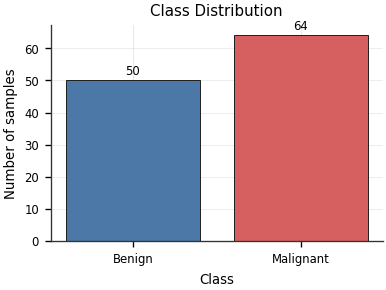


════════════════════════════════════════════════════════════════════════════════
PATIENT SAMPLE COUNT SUMMARY
════════════════════════════════════════════════════════════════════════════════
       samples_per_patient
count             48.00000
mean               2.37500
std                1.91994
min                1.00000
25%                1.00000
50%                2.00000
75%                3.00000
max                7.00000
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig02_samples_per_patient.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig02_samples_per_patient.pdf


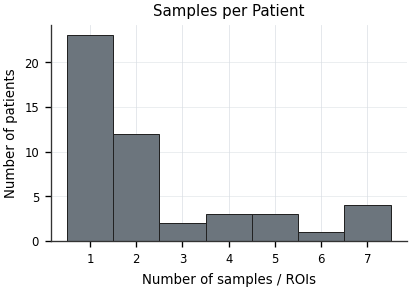

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig03_feature_variance_distribution.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig03_feature_variance_distribution.pdf


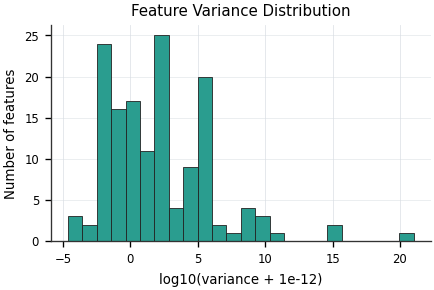


════════════════════════════════════════════════════════════════════════════════
SHAPIRO-WILK NORMALITY SUMMARY
════════════════════════════════════════════════════════════════════════════════
Normal features before FDR:     6
Non-normal features before FDR: 139
Normal features after FDR:      6
Non-normal features after FDR:  139


Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig04_feature_normality_summary.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig04_feature_normality_summary.pdf


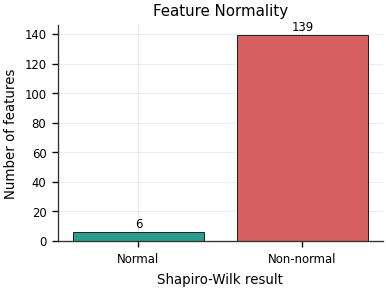


════════════════════════════════════════════════════════════════════════════════
TOP FEATURE-LABEL ASSOCIATIONS AFTER FDR
════════════════════════════════════════════════════════════════════════════════
                              feature                correlation_method  correlation_coefficient  correlation_p_value  correlation_q_value_fdr class_difference_test  class_difference_p_value  class_difference_q_value_fdr  cohen_d_malignant_minus_benign
        Morph_SurfaceToVolumeRatio_cm                          Spearman                 0.289008             0.001817                 0.032937        Mann_Whitney_U                  0.002145                      0.038884                        0.565582
                      Morph_Compacity                          Spearman                -0.289008             0.001817                 0.032937        Mann_Whitney_U                  0.002145                      0.038884                       -0.621135
                   Morph_Compactness1

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig05_top_fdr_ranked_features.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig05_top_fdr_ranked_features.pdf


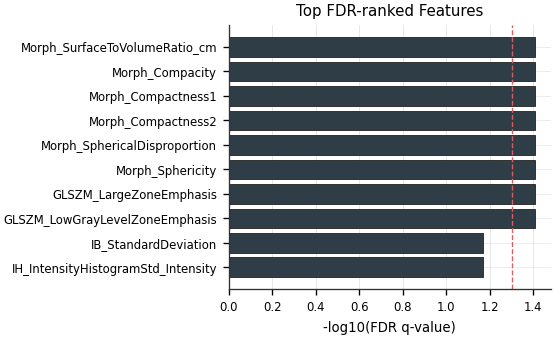

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig06_top4_feature_boxplots.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig06_top4_feature_boxplots.pdf


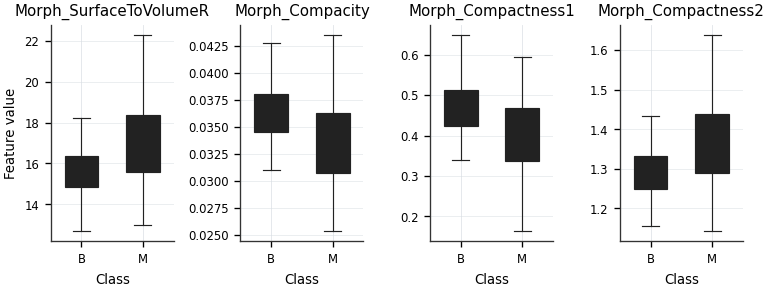

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig07_top12_feature_correlation_heatmap.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig07_top12_feature_correlation_heatmap.pdf


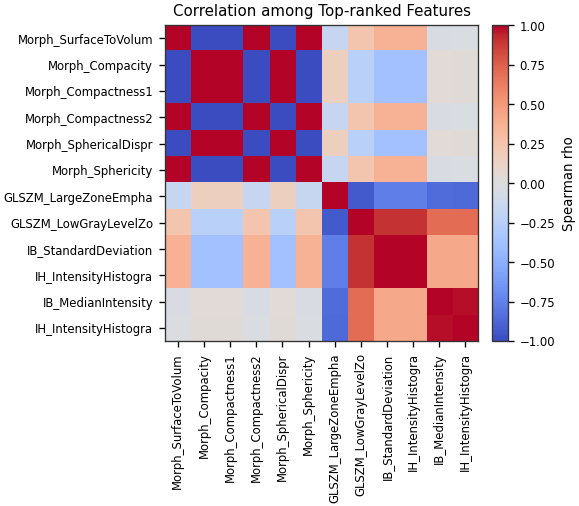

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig08_pca_projection.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_1b_statistical_eda/plots_publication_style/fig08_pca_projection.pdf


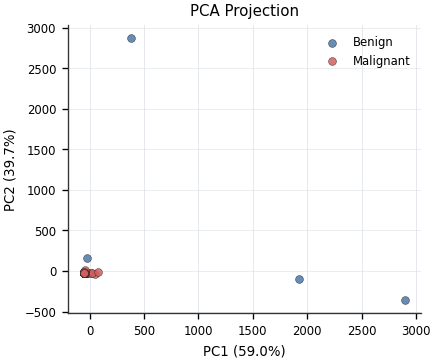


════════════════════════════════════════════════════════════════════════════════
PCA EXPLAINED VARIANCE
════════════════════════════════════════════════════════════════════════════════
component  explained_variance_ratio
      PC1                  0.590116
      PC2                  0.397341

════════════════════════════════════════════════════════════════════════════════
STEP 1B SUMMARY
════════════════════════════════════════════════════════════════════════════════
n_samples: 114
n_features: 145
n_label_0: 50
n_label_1: 64
class_balance_binomial_p_value: 0.22323036245554517
n_normal_features_raw_p_ge_0_05: 6
n_non_normal_features_raw_p_lt_0_05: 139
n_normal_features_fdr_q_ge_0_05: 6
n_non_normal_features_fdr_q_lt_0_05: 139
n_features_with_fdr_significant_class_difference: 8
n_features_with_fdr_significant_correlation: 8
pca_pc1_explained_variance_ratio: 0.5901159673271176
pca_pc2_explained_variance_ratio: 0.397340657428744
eda_dir: nested_cv_outputs_single_dataset_batch_smote_compar

In [14]:
# =============================================================================
# STEP 1B — COMPACT STATISTICAL QA AND PUBLICATION-STYLE VISUAL EDA
# =============================================================================
# Purpose:
#   - Perform statistical QA after robust data ingestion.
#   - Avoid redundant figures.
#   - Generate compact, publication-style plots suitable for manuscripts.
#   - Save all figures as both high-resolution PNG and vector PDF.
#
# Important:
#   - This cell is EDA only.
#   - It does NOT modify X, y, groups, or feature_names.
#   - PCA here is visualization-only and must not be used for model training
#     outside cross-validation.
# =============================================================================

print("█" * 80)
print("  STEP 1B — COMPACT STATISTICAL QA AND PUBLICATION-STYLE EDA")
print("█" * 80)

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    shapiro,
    pearsonr,
    spearmanr,
    ttest_ind,
    mannwhitneyu,
    binomtest
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Output directories
# -----------------------------------------------------------------------------
eda_dir = os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "step_1b_statistical_eda")
plot_dir = os.path.join(eda_dir, "plots_publication_style")

os.makedirs(eda_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

print(f"\nEDA output directory:\n  {eda_dir}")
print(f"Plot output directory:\n  {plot_dir}")

# -----------------------------------------------------------------------------
# 2. Publication-style plotting theme
# -----------------------------------------------------------------------------
# Professional, compact, manuscript-oriented theme.
# Labels are kept in English because most journals require English figures.
plt.style.use("default")

FIG_DPI = 600

COLORS = {
    "benign": "#4C78A8",
    "malignant": "#D65F5F",
    "neutral": "#6C757D",
    "accent": "#2A9D8F",
    "dark": "#2F3E46",
    "grid": "#D9DEE3"
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.5,
    "grid.alpha": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axis(ax):
    """
    Minimal journal-style axis formatting.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", linestyle="-", linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)


def save_figure(fig, filename_base):
    """
    Save each figure in both PNG and PDF formats.
    """
    png_path = os.path.join(plot_dir, f"{filename_base}.png")
    pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# -----------------------------------------------------------------------------
# 3. Safety checks
# -----------------------------------------------------------------------------
required_objects = ["X", "y", "groups", "feature_names"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(f"Required object '{obj_name}' not found. Run Step 1 first.")

X_eda = np.asarray(X, dtype=float)
y_eda = np.asarray(y, dtype=int)
groups_eda = np.asarray(groups).astype(str)
feature_names_eda = list(feature_names)

if X_eda.shape[1] != len(feature_names_eda):
    raise ValueError("X column count does not match feature_names length.")

# -----------------------------------------------------------------------------
# 4. Helper functions
# -----------------------------------------------------------------------------
def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg FDR correction.
    Returns q-values in original order.
    """
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    q_values = np.full(n, np.nan)
    valid_mask = np.isfinite(p_values)
    valid_p = p_values[valid_mask]

    if len(valid_p) == 0:
        return q_values

    order = np.argsort(valid_p)
    ranked_p = valid_p[order]

    adjusted = ranked_p * len(valid_p) / (np.arange(1, len(valid_p) + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    valid_q = np.empty_like(valid_p)
    valid_q[order] = adjusted

    q_values[valid_mask] = valid_q
    return q_values


def cohen_d(x0, x1):
    """
    Cohen's d: malignant minus benign.
    """
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)

    x0 = x0[np.isfinite(x0)]
    x1 = x1[np.isfinite(x1)]

    n0, n1 = len(x0), len(x1)

    if n0 < 2 or n1 < 2:
        return np.nan

    s0 = np.var(x0, ddof=1)
    s1 = np.var(x1, ddof=1)

    pooled_sd = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))

    if pooled_sd == 0:
        return np.nan

    return (np.mean(x1) - np.mean(x0)) / pooled_sd


def group_shapiro(x):
    """
    Safe Shapiro-Wilk test for one group.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 3 or np.std(x) == 0:
        return np.nan, False

    stat, p = shapiro(x)
    return p, bool(p >= 0.05)


# -----------------------------------------------------------------------------
# 5. Class balance statistical test
# -----------------------------------------------------------------------------
label_counts = pd.Series(y_eda).value_counts().sort_index()

n_label_0 = int(label_counts.get(0, 0))
n_label_1 = int(label_counts.get(1, 0))
n_total = int(n_label_0 + n_label_1)

minority_count = min(n_label_0, n_label_1)

balance_test = binomtest(
    k=minority_count,
    n=n_total,
    p=0.5,
    alternative="two-sided"
)

class_balance_report = pd.DataFrame({
    "label": [0, 1],
    "class_name": ["Benign", "Malignant"],
    "count": [n_label_0, n_label_1],
    "proportion": [n_label_0 / n_total, n_label_1 / n_total],
    "binomial_balance_p_value": [balance_test.pvalue, balance_test.pvalue]
})

class_balance_report.to_csv(
    os.path.join(eda_dir, "class_balance_statistical_test.csv"),
    index=False
)

print("\n" + "═" * 80)
print("CLASS BALANCE STATISTICAL TEST")
print("═" * 80)
print(class_balance_report.to_string(index=False))
print(f"\nExact binomial test p-value: {balance_test.pvalue:.6f}")

# Figure 1: Class distribution only. No pie chart to avoid redundancy.
fig, ax = plt.subplots(figsize=(3.4, 2.6))

ax.bar(
    ["Benign", "Malignant"],
    [n_label_0, n_label_1],
    color=[COLORS["benign"], COLORS["malignant"]],
    edgecolor="#222222",
    linewidth=0.6
)

ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
clean_axis(ax)

for i, v in enumerate([n_label_0, n_label_1]):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
save_figure(fig, "fig01_class_distribution")
plt.show()


# -----------------------------------------------------------------------------
# 6. Patient/group structure
# -----------------------------------------------------------------------------
patient_counts = pd.Series(groups_eda).value_counts()

patient_count_summary = patient_counts.describe().to_frame("samples_per_patient")
patient_count_summary.to_csv(os.path.join(eda_dir, "patient_sample_count_summary.csv"))

print("\n" + "═" * 80)
print("PATIENT SAMPLE COUNT SUMMARY")
print("═" * 80)
print(patient_count_summary.to_string())

# Figure 2: Only one patient-distribution figure.
fig, ax = plt.subplots(figsize=(3.6, 2.6))

bins = np.arange(1, int(patient_counts.max()) + 2) - 0.5

ax.hist(
    patient_counts.values,
    bins=bins,
    color=COLORS["neutral"],
    edgecolor="#222222",
    linewidth=0.6
)

ax.set_title("Samples per Patient")
ax.set_xlabel("Number of samples / ROIs")
ax.set_ylabel("Number of patients")
ax.set_xticks(range(1, int(patient_counts.max()) + 1))
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig02_samples_per_patient")
plt.show()


# -----------------------------------------------------------------------------
# 7. Missingness and variance reports
# -----------------------------------------------------------------------------
nan_counts = pd.Series(np.isnan(X_eda).sum(axis=0), index=feature_names_eda)
inf_counts = pd.Series(np.isinf(X_eda).sum(axis=0), index=feature_names_eda)
bad_counts = nan_counts + inf_counts

bad_feature_report = pd.DataFrame({
    "feature": feature_names_eda,
    "nan_count": nan_counts.values,
    "inf_count": inf_counts.values,
    "bad_value_count": bad_counts.values
}).sort_values("bad_value_count", ascending=False)

bad_feature_report.to_csv(
    os.path.join(eda_dir, "feature_missing_inf_report.csv"),
    index=False
)

feature_variance = pd.Series(np.nanvar(X_eda, axis=0), index=feature_names_eda)

variance_report = pd.DataFrame({
    "feature": feature_names_eda,
    "variance": feature_variance.values,
    "log10_variance": np.log10(feature_variance.values + 1e-12)
}).sort_values("variance", ascending=True)

variance_report.to_csv(
    os.path.join(eda_dir, "feature_variance_report.csv"),
    index=False
)

# Figure 3: Feature variance distribution.
fig, ax = plt.subplots(figsize=(3.8, 2.6))

ax.hist(
    variance_report["log10_variance"],
    bins=24,
    color=COLORS["accent"],
    edgecolor="#222222",
    linewidth=0.5
)

ax.set_title("Feature Variance Distribution")
ax.set_xlabel("log10(variance + 1e-12)")
ax.set_ylabel("Number of features")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig03_feature_variance_distribution")
plt.show()


# -----------------------------------------------------------------------------
# 8. Shapiro-Wilk normality test per feature
# -----------------------------------------------------------------------------
normality_rows = []

for j, feat in enumerate(feature_names_eda):
    xj = X_eda[:, j]
    xj = xj[np.isfinite(xj)]

    if len(xj) < 3 or np.nanstd(xj) == 0:
        shapiro_stat = np.nan
        shapiro_p = np.nan
        is_normal = False
    else:
        shapiro_stat, shapiro_p = shapiro(xj)
        is_normal = bool(shapiro_p >= 0.05)

    normality_rows.append({
        "feature": feat,
        "n_valid": int(len(xj)),
        "shapiro_stat": shapiro_stat,
        "shapiro_p_value": shapiro_p,
        "is_normal_global_p_ge_0_05": is_normal
    })

normality_report = pd.DataFrame(normality_rows)

normality_report["shapiro_q_value_fdr"] = benjamini_hochberg(
    normality_report["shapiro_p_value"].values
)

normality_report["is_normal_after_fdr_q_ge_0_05"] = (
    normality_report["shapiro_q_value_fdr"] >= 0.05
)

normality_report.to_csv(
    os.path.join(eda_dir, "shapiro_wilk_normality_report.csv"),
    index=False
)

n_normal_raw = int(normality_report["is_normal_global_p_ge_0_05"].sum())
n_non_normal_raw = int((~normality_report["is_normal_global_p_ge_0_05"]).sum())

n_normal_fdr = int(normality_report["is_normal_after_fdr_q_ge_0_05"].sum())
n_non_normal_fdr = int((~normality_report["is_normal_after_fdr_q_ge_0_05"]).sum())

print("\n" + "═" * 80)
print("SHAPIRO-WILK NORMALITY SUMMARY")
print("═" * 80)
print(f"Normal features before FDR:     {n_normal_raw}")
print(f"Non-normal features before FDR: {n_non_normal_raw}")
print(f"Normal features after FDR:      {n_normal_fdr}")
print(f"Non-normal features after FDR:  {n_non_normal_fdr}")

# Figure 4: Normal vs non-normal summary only.
fig, ax = plt.subplots(figsize=(3.4, 2.6))

ax.bar(
    ["Normal", "Non-normal"],
    [n_normal_raw, n_non_normal_raw],
    color=[COLORS["accent"], COLORS["malignant"]],
    edgecolor="#222222",
    linewidth=0.6
)

ax.set_title("Feature Normality")
ax.set_xlabel("Shapiro-Wilk result")
ax.set_ylabel("Number of features")
clean_axis(ax)

for i, v in enumerate([n_normal_raw, n_non_normal_raw]):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
save_figure(fig, "fig04_feature_normality_summary")
plt.show()


# -----------------------------------------------------------------------------
# 9. Feature-label association:
#    Pearson if both class-specific distributions are normal,
#    Spearman if at least one class-specific distribution is non-normal.
# -----------------------------------------------------------------------------
association_rows = []

for j, feat in enumerate(feature_names_eda):
    xj = X_eda[:, j]

    finite_mask = np.isfinite(xj) & np.isfinite(y_eda)
    xj_valid = xj[finite_mask]
    y_valid = y_eda[finite_mask]

    x0 = xj_valid[y_valid == 0]
    x1 = xj_valid[y_valid == 1]

    shapiro_p_0, normal_0 = group_shapiro(x0)
    shapiro_p_1, normal_1 = group_shapiro(x1)

    use_parametric = bool(normal_0 and normal_1)

    # Correlation with binary label
    if len(np.unique(xj_valid)) < 2 or len(np.unique(y_valid)) < 2:
        corr_method = "undefined"
        corr_coef = np.nan
        corr_p = np.nan
    else:
        if use_parametric:
            corr_method = "Pearson_point_biserial_equivalent"
            corr_coef, corr_p = pearsonr(xj_valid, y_valid)
        else:
            corr_method = "Spearman"
            corr_coef, corr_p = spearmanr(xj_valid, y_valid)

    # Class difference test
    if len(x0) < 2 or len(x1) < 2:
        class_test = "undefined"
        class_test_stat = np.nan
        class_test_p = np.nan
    else:
        if use_parametric:
            class_test = "Welch_t_test"
            class_test_stat, class_test_p = ttest_ind(
                x0,
                x1,
                equal_var=False,
                nan_policy="omit"
            )
        else:
            class_test = "Mann_Whitney_U"
            try:
                class_test_stat, class_test_p = mannwhitneyu(
                    x0,
                    x1,
                    alternative="two-sided"
                )
            except ValueError:
                class_test_stat, class_test_p = np.nan, np.nan

    association_rows.append({
        "feature": feat,
        "n_valid": int(len(xj_valid)),
        "mean_benign": np.nanmean(x0) if len(x0) else np.nan,
        "mean_malignant": np.nanmean(x1) if len(x1) else np.nan,
        "median_benign": np.nanmedian(x0) if len(x0) else np.nan,
        "median_malignant": np.nanmedian(x1) if len(x1) else np.nan,
        "shapiro_p_benign": shapiro_p_0,
        "shapiro_p_malignant": shapiro_p_1,
        "normal_in_both_classes": use_parametric,
        "correlation_method": corr_method,
        "correlation_coefficient": corr_coef,
        "correlation_p_value": corr_p,
        "class_difference_test": class_test,
        "class_difference_stat": class_test_stat,
        "class_difference_p_value": class_test_p,
        "cohen_d_malignant_minus_benign": cohen_d(x0, x1)
    })

association_report = pd.DataFrame(association_rows)

association_report["correlation_q_value_fdr"] = benjamini_hochberg(
    association_report["correlation_p_value"].values
)

association_report["class_difference_q_value_fdr"] = benjamini_hochberg(
    association_report["class_difference_p_value"].values
)

association_report = association_report.sort_values(
    ["class_difference_q_value_fdr", "correlation_q_value_fdr"],
    ascending=[True, True]
)

association_report.to_csv(
    os.path.join(eda_dir, "feature_label_association_report.csv"),
    index=False
)

print("\n" + "═" * 80)
print("TOP FEATURE-LABEL ASSOCIATIONS AFTER FDR")
print("═" * 80)

display_cols = [
    "feature",
    "correlation_method",
    "correlation_coefficient",
    "correlation_p_value",
    "correlation_q_value_fdr",
    "class_difference_test",
    "class_difference_p_value",
    "class_difference_q_value_fdr",
    "cohen_d_malignant_minus_benign"
]

print(association_report[display_cols].head(15).to_string(index=False))


# -----------------------------------------------------------------------------
# 10. Figure 5: Top FDR-ranked features
# -----------------------------------------------------------------------------
assoc_plot_df = association_report.copy()

safe_q = assoc_plot_df["class_difference_q_value_fdr"].copy()
safe_q = safe_q.replace(0, np.nextafter(0, 1))
assoc_plot_df["minus_log10_q"] = -np.log10(safe_q)

assoc_plot_df = assoc_plot_df.replace([np.inf, -np.inf], np.nan)
assoc_plot_df = assoc_plot_df.dropna(subset=["minus_log10_q"])

top_assoc = assoc_plot_df.head(10).iloc[::-1]

if len(top_assoc) > 0:
    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    ax.barh(
        top_assoc["feature"],
        top_assoc["minus_log10_q"],
        color=COLORS["dark"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(
        -np.log10(0.05),
        linestyle="--",
        linewidth=0.8,
        color=COLORS["malignant"]
    )

    ax.set_title("Top FDR-ranked Features")
    ax.set_xlabel("-log10(FDR q-value)")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig05_top_fdr_ranked_features")
    plt.show()


# -----------------------------------------------------------------------------
# 11. Figure 6: Compact boxplots for top 4 FDR-ranked features
# -----------------------------------------------------------------------------
top_box_features = association_report["feature"].head(4).tolist()

if len(top_box_features) > 0:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(top_box_features),
        figsize=(min(6.4, 1.6 * len(top_box_features)), 2.6),
        sharey=False
    )

    if len(top_box_features) == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_box_features):
        j = feature_names_eda.index(feat)
        xj = X_eda[:, j]

        x0 = xj[y_eda == 0]
        x1 = xj[y_eda == 1]

        bp = ax.boxplot(
            [x0[np.isfinite(x0)], x1[np.isfinite(x1)]],
            labels=["B", "M"],
            patch_artist=True,
            showfliers=False,
            widths=0.55
        )

        bp["boxes"][0].set_facecolor(COLORS["benign"])
        bp["boxes"][1].set_facecolor(COLORS["malignant"])

        for element in ["boxes", "whiskers", "caps", "medians"]:
            for item in bp[element]:
                item.set_color("#222222")
                item.set_linewidth(0.7)

        ax.set_title(feat[:22])
        ax.set_xlabel("Class")
        ax.tick_params(axis="x", rotation=0)
        clean_axis(ax)

    axes[0].set_ylabel("Feature value")

    plt.tight_layout()
    save_figure(fig, "fig06_top4_feature_boxplots")
    plt.show()


# -----------------------------------------------------------------------------
# 12. Figure 7: Spearman correlation heatmap among top 12 FDR-ranked features
# -----------------------------------------------------------------------------
top_heatmap_features = association_report["feature"].head(12).tolist()

if len(top_heatmap_features) >= 2:
    top_indices = [feature_names_eda.index(f) for f in top_heatmap_features]

    X_top = pd.DataFrame(
        X_eda[:, top_indices],
        columns=top_heatmap_features
    )

    corr_matrix = X_top.corr(method="spearman")

    corr_matrix.to_csv(
        os.path.join(eda_dir, "top12_features_spearman_correlation_matrix.csv")
    )

    fig, ax = plt.subplots(figsize=(5.0, 4.4))

    im = ax.imshow(
        corr_matrix,
        aspect="auto",
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman rho")

    short_labels = [f[:20] for f in top_heatmap_features]

    ax.set_xticks(np.arange(len(short_labels)))
    ax.set_yticks(np.arange(len(short_labels)))
    ax.set_xticklabels(short_labels, rotation=90)
    ax.set_yticklabels(short_labels)

    ax.set_title("Correlation among Top-ranked Features")
    ax.grid(False)

    plt.tight_layout()
    save_figure(fig, "fig07_top12_feature_correlation_heatmap")
    plt.show()


# -----------------------------------------------------------------------------
# 13. Figure 8: PCA projection
# -----------------------------------------------------------------------------
# EDA-only global transformation.
# Do not use these PCA components for model training outside CV.
imputer_eda = SimpleImputer(strategy="median")
scaler_eda = RobustScaler()

X_imp = imputer_eda.fit_transform(X_eda)
X_scaled = scaler_eda.fit_transform(X_imp)

pca = PCA(n_components=2, random_state=CONFIG.get("RANDOM_STATE", 42))
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Label": y_eda,
    "Patient_ID": groups_eda
})

pca_df.to_csv(os.path.join(eda_dir, "pca_2d_coordinates.csv"), index=False)

pca_variance_df = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

pca_variance_df.to_csv(
    os.path.join(eda_dir, "pca_2d_explained_variance.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(3.8, 3.2))

for cls, label_name, color in [
    (0, "Benign", COLORS["benign"]),
    (1, "Malignant", COLORS["malignant"])
]:
    idx = y_eda == cls
    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=label_name,
        s=22,
        alpha=0.85,
        color=color,
        edgecolor="#222222",
        linewidth=0.3
    )

ax.set_title("PCA Projection")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(frameon=False, loc="best")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig08_pca_projection")
plt.show()

print("\n" + "═" * 80)
print("PCA EXPLAINED VARIANCE")
print("═" * 80)
print(pca_variance_df.to_string(index=False))


# -----------------------------------------------------------------------------
# 14. Compact JSON summary for future comparison
# -----------------------------------------------------------------------------
step_1b_summary = {
    "n_samples": int(X_eda.shape[0]),
    "n_features": int(X_eda.shape[1]),
    "n_label_0": int(n_label_0),
    "n_label_1": int(n_label_1),
    "class_balance_binomial_p_value": float(balance_test.pvalue),
    "n_normal_features_raw_p_ge_0_05": int(n_normal_raw),
    "n_non_normal_features_raw_p_lt_0_05": int(n_non_normal_raw),
    "n_normal_features_fdr_q_ge_0_05": int(n_normal_fdr),
    "n_non_normal_features_fdr_q_lt_0_05": int(n_non_normal_fdr),
    "n_features_with_fdr_significant_class_difference": int(
        (association_report["class_difference_q_value_fdr"] < 0.05).sum()
    ),
    "n_features_with_fdr_significant_correlation": int(
        (association_report["correlation_q_value_fdr"] < 0.05).sum()
    ),
    "pca_pc1_explained_variance_ratio": float(pca.explained_variance_ratio_[0]),
    "pca_pc2_explained_variance_ratio": float(pca.explained_variance_ratio_[1]),
    "eda_dir": eda_dir,
    "plot_dir": plot_dir
}

with open(os.path.join(eda_dir, "step_1b_summary.json"), "w") as f:
    json.dump(step_1b_summary, f, indent=4)

print("\n" + "═" * 80)
print("STEP 1B SUMMARY")
print("═" * 80)

for k, v in step_1b_summary.items():
    print(f"{k}: {v}")

print("\nSaved statistical reports and publication-style plots to:")
print(f"  {eda_dir}")
print(f"  {plot_dir}")

print("\n✅ STEP 1B completed successfully.")

In [15]:
# =============================================================================
# STEP 2A — BASELINE RUN CONFIGURATION LOCK
# =============================================================================
# Baseline must be a real no-SMOTE run saved under the exact path used later by
# the SMOTE-vs-baseline comparison cell.
# =============================================================================

print("█" * 80)
print("  STEP 2A — BASELINE CONFIGURATION LOCK")
print("█" * 80)

import os
import json

# -----------------------------------------------------------------------------
# Baseline identity — this folder name is required by Step 3B
# -----------------------------------------------------------------------------
CONFIG["RUN_NAME"] = "step_2_baseline_nested_cv_no_smote"
CONFIG["SAVE_DIR"] = os.path.join(
    CONFIG["DATASET_OUTPUT_ROOT"],
    CONFIG["RUN_NAME"]
)
SAVE_DIR = CONFIG["SAVE_DIR"]
os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# -----------------------------------------------------------------------------
# Core baseline settings
# -----------------------------------------------------------------------------
CONFIG["USE_SMOTE"] = False
CONFIG["FS_METHOD"] = "mrmr_then_elasticnet_no_corr"
CONFIG["FS_N_FEATURES"] = 14
CONFIG["AUTO_TUNE_FS_N_FEATURES"] = False

# Patient-aware nested CV
CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

# -----------------------------------------------------------------------------
# Safety checks
# -----------------------------------------------------------------------------
if "groups" not in globals():
    raise RuntimeError("groups object not found. Run Step 1 first.")

if len(set(groups)) < CONFIG["N_OUTER_FOLDS"]:
    raise ValueError(
        f"Unique patients/groups = {len(set(groups))}, "
        f"but N_OUTER_FOLDS = {CONFIG['N_OUTER_FOLDS']}."
    )

baseline_config_snapshot = {
    "RUN_NAME": CONFIG["RUN_NAME"],
    "SAVE_DIR": CONFIG["SAVE_DIR"],
    "USE_SMOTE": CONFIG["USE_SMOTE"],
    "FS_METHOD": CONFIG["FS_METHOD"],
    "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
    "AUTO_TUNE_FS_N_FEATURES": CONFIG.get("AUTO_TUNE_FS_N_FEATURES"),
    "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
    "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
    "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
    "RANDOM_STATE": CONFIG["RANDOM_STATE"],
    "N_SAMPLES": int(X.shape[0]),
    "N_FEATURES": int(X.shape[1]),
    "N_PATIENTS": int(len(set(groups))),
    "DATASET_TAG": CONFIG.get("DATASET_TAG"),
    "INPUT_FILE": CONFIG.get("INPUT_FILE"),
    "CLEANED_DATASET_PATH": CONFIG.get("CLEANED_DATASET_PATH"),
}

with open(os.path.join(CONFIG["SAVE_DIR"], "baseline_config_snapshot.json"), "w") as f:
    json.dump(baseline_config_snapshot, f, indent=4)

print("Baseline configuration:")
for k, v in baseline_config_snapshot.items():
    print(f"  {k}: {v}")

print("✅ STEP 2A completed successfully.")


████████████████████████████████████████████████████████████████████████████████
  STEP 2A — BASELINE CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████
Baseline configuration:
  RUN_NAME: step_2_baseline_nested_cv_no_smote
  SAVE_DIR: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_2_baseline_nested_cv_no_smote
  USE_SMOTE: False
  FS_METHOD: mrmr_then_elasticnet_no_corr
  FS_N_FEATURES: 14
  AUTO_TUNE_FS_N_FEATURES: False
  N_OUTER_FOLDS: 5
  N_INNER_FOLDS: 3
  N_OPTUNA_TRIALS: 10
  RANDOM_STATE: 100
  N_SAMPLES: 114
  N_FEATURES: 145
  N_PATIENTS: 48
  DATASET_TAG: ADC
  INPUT_FILE: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/output/all_single_datasets_standardized/ADC_single_standardized.csv
  CLEANED_DATASET_PATH: output/cleaned_single_datasets_smote_compare/ADC/ADC_single_standardized_Cleaned.csv
✅ STEP 2

In [16]:
# =============================================================================
# MULTI-STAGE FEATURE SELECTION ENGINE (STAGE 1 TO STAGE 4)
# =============================================================================
# Purpose:
#   - Stage 1: Eliminate morphological volume confounders using Spearman rho.
#   - Stage 2: Prune redundant features based on Pearson r and AUC rankings.
#   - Stage 3: Perform mRMR selection separately on CT and PET blocks.
#   - Stage 4: Enforce stability selection via subsampled ElasticNet LogReg.
# =============================================================================

import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

# -----------------------------------------------------------------------------
# STAGE 1: MORPHOLOGICAL VOLUME INDEPENDENCE FILTER
# -----------------------------------------------------------------------------
def stage1_volume_independence(X_train, feat_names, volume_col, threshold,
                               category_patterns, all_feature_names_original,
                               X_train_original):
    print("\n" + "═" * 75)
    print("  📐 Stage 1: Volume Independence Filter")
    print(f"     Threshold: |ρ_Spearman| > {threshold}")
    print("═" * 75)

    n_input = len(feat_names)

    # Morphology flag (for reporting only, NOT for automatic removal)
    morph_keywords = category_patterns.get('MORPHOLOGY', [])
    morph_flag = {}
    for fn in feat_names:
        fn_lower = fn.lower()
        is_morph = any(kw.lower() in fn_lower for kw in morph_keywords)
        is_morph = is_morph or any(tag in fn_lower
                                    for tag in ['morphological', '_morph_', '_shape_'])
        morph_flag[fn] = is_morph

    # Find volume vector
    vol_vector = None
    vol_source = "NOT FOUND"

    # Try 1: from original feature matrix
    if all_feature_names_original is not None and volume_col in all_feature_names_original:
        vol_idx = all_feature_names_original.index(volume_col)
        vol_vector = X_train_original[:, vol_idx]
        vol_source = volume_col

    # Try 2: fallback search in original
    if vol_vector is None and all_feature_names_original is not None:
        for i_col, fn_col in enumerate(all_feature_names_original):
            fn_lower = fn_col.lower()
            if (
                ('volume' in fn_lower or 'meshvolume' in fn_lower)
                and 'approximate' not in fn_lower
            ):
                vol_vector = X_train_original[:, i_col]
                vol_source = fn_col
                break

    # Try 3: from current features
    if vol_vector is None:
        for i_col, fn_col in enumerate(feat_names):
            fn_lower = fn_col.lower()
            if (
                ('volume' in fn_lower or 'meshvolume' in fn_lower)
                and 'approximate' not in fn_lower
            ):              
                vol_vector = X_train[:, i_col]
                vol_source = fn_col
                break

    print(f"   📦 Volume column: {vol_source}")

    vol_corr_mask = np.zeros(n_input, dtype=bool)
    vol_details = {}

    if vol_vector is not None:
        print(f"\n  {'Feature':<55} {'|ρ|':>6}  {'Status':<10}  {'Morph?':>6}")
        print("  " + "─" * 85)

        for j in range(n_input):
            fn = feat_names[j]
            try:
                rho, _ = spearmanr(X_train[:, j], vol_vector)
                abs_rho = abs(rho) if np.isfinite(rho) else 0.0
            except Exception:
                abs_rho = 0.0

            vol_details[fn] = abs_rho

            if abs_rho > threshold:
                vol_corr_mask[j] = True
                print(f"     ❌ {fn[:53]:53s} {abs_rho:6.3f}  REMOVED   "
                      f"{str(morph_flag[fn]):>6}")
            elif abs_rho > threshold * 0.7:
                print(f"     ⚠️ {fn[:53]:53s} {abs_rho:6.3f}  kept      "
                      f"{str(morph_flag[fn]):>6}")
    else:
        print("  ⚠️ Volume column NOT FOUND — skipping this stage")

    keep_idx = np.where(~vol_corr_mask)[0]

    print(f"\n  📊 Summary: {n_input} → {len(keep_idx)} "
          f"(removed {int(vol_corr_mask.sum())} volume-dependent)")

    info = {
        'n_input': n_input,
        'n_output': len(keep_idx),
        'n_vol_dep_removed': int(vol_corr_mask.sum()),
        'vol_corr_details': vol_details,
        'removed_features': [feat_names[i] for i in np.where(vol_corr_mask)[0]],
        'kept_features': [feat_names[i] for i in keep_idx],
        'morph_flag': morph_flag,
    }
    return keep_idx, info


# -----------------------------------------------------------------------------
# STAGE 2: REDUNDANCY REDUCTION (PEARSON PAIR-WISE CLUSTERING)
# -----------------------------------------------------------------------------
def stage2_redundancy_reduction(X_train, y_train, feat_names, threshold=0.90):
    print("\n" + "═" * 75)
    print("  🔗 Stage 2: Redundancy Reduction (Pearson |r| clustering)")
    print(f"     Threshold: |r| > {threshold}")
    print("═" * 75)

    n_input = len(feat_names)
    corr_matrix = np.nan_to_num(
        np.corrcoef(X_train, rowvar=False),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )
    auc_scores = np.zeros(n_input)
    for j in range(n_input):
        try:
            if np.std(X_train[:, j]) < 1e-12:
                auc_scores[j] = 0.5
            else:
                auc = roc_auc_score(y_train, X_train[:, j])
                auc_scores[j] = max(auc, 1 - auc)
        except Exception:
            auc_scores[j] = 0.5

    remaining = set(range(n_input))
    selected_idx = []
    removal_reasons = {}

    for idx in np.argsort(-auc_scores):
        if idx not in remaining:
            continue
        selected_idx.append(idx)
        remaining.discard(idx)

        to_remove = set()
        for other in remaining:
            if abs(corr_matrix[idx, other]) > threshold:
                to_remove.add(other)
                removal_reasons[other] = (idx, corr_matrix[idx, other])
        remaining -= to_remove

    selected_idx = sorted(selected_idx)
    removed_features = [i for i in range(n_input) if i not in selected_idx]

    print(f"\n  📋 All features ranked by AUC:")
    print(f"  {'#':<4} {'Feature':<55} {'AUC':<8} {'Status':<10}")
    print("  " + "─" * 80)
    for rank, idx in enumerate(np.argsort(-auc_scores), 1):
        status = "✅ KEPT" if idx in selected_idx else "❌ REMOVED"
        print(f"  {rank:<4} {feat_names[idx][:53]:<55} "
              f"{auc_scores[idx]:.4f}  {status}")

    if removed_features:
        print(f"\n  ❌ REMOVED {len(removed_features)} features (beaten by correlated feature):")
        print(f"  {'#':<4} {'Removed':<42} {'AUC':<8} {'Beaten By':<32} {'|r|':<8}")
        print("  " + "─" * 95)
        for rank, idx in enumerate(removed_features, 1):
            if idx in removal_reasons:
                w_idx, corr_val = removal_reasons[idx]
                print(f"  {rank:<4} {feat_names[idx][:40]:<42} "
                      f"{auc_scores[idx]:.4f}  "
                      f"{feat_names[w_idx][:30]:<32} {abs(corr_val):.4f}")

    print(f"\n  ✅ KEPT {len(selected_idx)} features:")
    for rank, idx in enumerate(selected_idx, 1):
        print(f"     {rank}. {feat_names[idx][:55]} (AUC: {auc_scores[idx]:.4f})")

    print(f"\n  📊 Summary: {n_input} → {len(selected_idx)}")

    info = {
        'n_input': n_input,
        'n_output': len(selected_idx),
        'threshold': threshold,
        'removed_features': [(feat_names[i], float(auc_scores[i]),
                              feat_names[removal_reasons[i][0]] if i in removal_reasons else "N/A",
                              float(abs(removal_reasons[i][1])) if i in removal_reasons else 0)
                             for i in removed_features],
        'kept_features': [feat_names[i] for i in selected_idx],
        'auc_scores': dict(zip(feat_names, auc_scores.tolist())),
    }
    return np.array(selected_idx), auc_scores, info


# -----------------------------------------------------------------------------
# STAGE 3: mRMR 
# -----------------------------------------------------------------------------





def _safe_numeric_matrix(X):
    """
    Converts input to finite numeric matrix.
    Non-finite values are replaced column-wise using the training-fold median.
    This is only a safety guard inside feature selection.
    """
    X = np.asarray(X, dtype=float).copy()

    for j in range(X.shape[1]):
        col = X[:, j]
        finite_mask = np.isfinite(col)

        if finite_mask.any():
            replacement = np.median(col[finite_mask])
        else:
            replacement = 0.0

        col[~finite_mask] = replacement
        X[:, j] = col

    return X


def _prepare_mrmr_matrix(X_train, transform="robust"):
    """
    Prepares matrix used by mRMR relevance/redundancy scoring.

    Why:
    mutual_info_classif for continuous features is nearest-neighbor based.
    Raw radiomics features have heterogeneous scales, so raw MI can be biased
    by feature scale/distribution. This function makes mRMR scale-safe.
    """
    from sklearn.preprocessing import StandardScaler, RobustScaler
    import pandas as pd

    X_clean = _safe_numeric_matrix(X_train)

    transform = str(transform).lower().strip()

    if transform == "none":
        return X_clean

    if transform == "standard":
        return StandardScaler().fit_transform(X_clean)

    if transform == "robust":
        return RobustScaler(
            with_centering=True,
            with_scaling=True,
            quantile_range=(25.0, 75.0)
        ).fit_transform(X_clean)

    if transform == "rank":
        X_rank = (
            pd.DataFrame(X_clean)
            .rank(axis=0, method="average", pct=True)
            .values
        )
        return StandardScaler().fit_transform(X_rank)

    raise ValueError(
        f"Unsupported MRMR_TRANSFORM={transform}. "
        "Use one of: 'none', 'standard', 'robust', 'rank'."
    )


def stage3_mrmr_selection_blockwise(
    X_train,
    y_train,
    feat_names,
    n_features=14,
    mrmr_transform="robust",
    random_state=42
):
    print("\n" + "═" * 75)
    print("  🧠 Stage 3: mRMR Selection")
    print(f"     Transform used for MI/correlation: {mrmr_transform}")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Stage 3 mRMR requires at least two classes in y_train.")

    n_features = int(min(n_features, X_train.shape[1]))

    class_counts = np.bincount(y_train.astype(int))
    min_class_count = class_counts[class_counts > 0].min()
    safe_neighbors = max(1, min(3, min_class_count - 1))

    X_mrmr = _prepare_mrmr_matrix(
        X_train,
        transform=mrmr_transform
    )

    relevance = mutual_info_classif(
        X_mrmr,
        y_train,
        random_state=random_state,
        n_neighbors=safe_neighbors
    )

    relevance = np.nan_to_num(
        relevance,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    corr_mat = np.nan_to_num(
        np.corrcoef(X_mrmr, rowvar=False),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    selected = []
    remaining = list(range(X_mrmr.shape[1]))

    for k in range(n_features):
        best_score = -np.inf
        best_idx = None

        for idx in remaining:
            rel = relevance[idx]

            if len(selected) == 0:
                red = 0.0
            else:
                red = np.mean([abs(corr_mat[idx, s]) for s in selected])

            score = rel - red

            if score > best_score:
                best_score = score
                best_idx = idx

        if best_idx is None:
            break

        selected.append(best_idx)
        remaining.remove(best_idx)

        print(
            f"   {k + 1}. {feat_names[best_idx]:<45} "
            f"score={best_score:.4f} | MI={relevance[best_idx]:.4f}"
        )

    info = {
        "n_input": X_train.shape[1],
        "n_output": len(selected),
        "mrmr_transform": mrmr_transform,
        "safe_neighbors": int(safe_neighbors),
        "kept_features": [feat_names[i] for i in selected],
        "relevance": dict(zip(feat_names, relevance.tolist()))
    }

    return selected, relevance, info




# -----------------------------------------------------------------------------
# STAGE 4: RESAMPLED STABILITY SELECTION (ELASTIC-NET LOGISTIC REGRESSION)
# -----------------------------------------------------------------------------
def stage4_stability_selection(X_train, y_train, feat_names,
                               n_iterations=300, subsample_ratio=0.5,
                               sel_threshold=0.75, l1_ratios=None,
                               Cs=None, random_state=42,
                               coef_threshold=1e-3,
                               fallback_step=0.05,       
                               fallback_min_threshold=0.40,  
                               fallback_min_features=3):     

    print("\n" + "═" * 75)
    print("  🎯 Stage 4: Stability Selection (ElasticNet LogReg)")
    print(f"     Iterations: {n_iterations} | Subsample: {subsample_ratio}")
    print(f"     Selection threshold: {sel_threshold}")
    print(f"     Coefficient threshold: {coef_threshold}")
    print(f"     Fallback: step={fallback_step}, "
          f"min_thresh={fallback_min_threshold}, "
          f"min_features={fallback_min_features}")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Stage 4 stability selection requires at least two classes in y_train.")

    if l1_ratios is None:
        l1_ratios = [0.8, 0.9, 0.95, 1.0]
    if Cs is None:
        Cs = [0.005, 0.01, 0.05, 0.1]

    n_features = len(feat_names)
    n_samples = X_train.shape[0]
    n_sub = max(int(n_samples * subsample_ratio), 10)

    # Scale once
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_train)

    selection_count = np.zeros(n_features)
    coef_accumulator = np.zeros(n_features)
    rng = np.random.RandomState(random_state)

    successful = 0
    failed = 0

    for it in range(n_iterations):
        # Random subsample (stratified)
        idx_0 = np.where(y_train == 0)[0]
        idx_1 = np.where(y_train == 1)[0]

        n_sub_0 = max(int(len(idx_0) * subsample_ratio), 2)
        n_sub_1 = max(int(len(idx_1) * subsample_ratio), 2)

        if len(idx_0) > 0:
            sub_0 = rng.choice(idx_0, size=min(n_sub_0, len(idx_0)), replace=False)
        else:
            sub_0 = np.array([], dtype=int)
        if len(idx_1) > 0:
            sub_1 = rng.choice(idx_1, size=min(n_sub_1, len(idx_1)), replace=False)
        else:
            sub_1 = np.array([], dtype=int)
        sub_idx = np.concatenate([sub_0, sub_1])

        X_sub = X_scaled[sub_idx]
        y_sub = y_train[sub_idx]

        # Random hyperparameters
        l1_ratio = rng.choice(l1_ratios)
        C = rng.choice(Cs)

        try:
            model = LogisticRegression(
                penalty='elasticnet', solver='saga',
                C=C, l1_ratio=l1_ratio,
                max_iter=5000,
                random_state=random_state + it,
                tol=1e-5
            )
            model.fit(X_sub, y_sub)

            coefs = np.abs(model.coef_[0])
            selected_mask = np.abs(coefs) > coef_threshold
            selection_count += selected_mask.astype(float)
            coef_accumulator += coefs
            successful += 1

        except Exception:
            failed += 1

        # Progress tracking updates
        if (it + 1) % 100 == 0:
            current_freq = selection_count / max(successful, 1)
            n_passing = np.sum(current_freq >= sel_threshold)
            print(f"    ... iteration {it + 1}/{n_iterations} "
                  f"(success: {successful}, failed: {failed}, "
                  f"passing: {n_passing} features)")

    # Compute operational frequencies
    if successful > 0:
        selection_freq = selection_count / successful
        mean_coefs = coef_accumulator / successful
    else:
        selection_freq = np.zeros(n_features)
        mean_coefs = np.zeros(n_features)

    # ══════════════════════════════════════════════════════════
    # ADAPTIVE FALLBACK PROTOCOL: GRADUAL THRESHOLD DECAY
    # ══════════════════════════════════════════════════════════
    current_threshold = sel_threshold
    keep_idx = np.where(selection_freq >= current_threshold)[0]

    # Dynamically decay selection criterion if total retained features falls below safety boundaries
    if len(keep_idx) < fallback_min_features:
        print(f"\n  ⚠️  Only {len(keep_idx)} features at threshold "
              f"{current_threshold:.2f} (need ≥{fallback_min_features})")
        print(f"  🔄 Starting adaptive threshold reduction...")

        while (len(keep_idx) < fallback_min_features and
               current_threshold > fallback_min_threshold):

            current_threshold -= fallback_step
            current_threshold = round(current_threshold, 4)  # Safeguard floating-point precision bounds
            keep_idx = np.where(selection_freq >= current_threshold)[0]

            print(f"      → threshold = {current_threshold:.2f} "
                  f"→ {len(keep_idx)} features selected")

        # Absolute fallback override if minimal conditions remain unsatisfied
        if len(keep_idx) < fallback_min_features:
            print(f"\n  🚨 Still only {len(keep_idx)} features at "
                  f"minimum threshold {fallback_min_threshold:.2f}")
            print(f"  🔄 Selecting top {fallback_min_features} by frequency...")
            keep_idx = np.argsort(-selection_freq)[:fallback_min_features]
            if len(keep_idx) > 0:
                current_threshold = selection_freq[keep_idx[-1]]
            else:
                current_threshold = fallback_min_threshold
            print(f"      → Effective threshold: {current_threshold:.3f}")

        if current_threshold < sel_threshold:
            print(f"\n  📌 Final threshold: {current_threshold:.2f} "
                  f"(original: {sel_threshold:.2f})")

    # --- Verbose Output Generation -------------------------------------------
    print(f"\n  📋 Feature selection frequencies "
          f"(threshold used: {current_threshold:.2f}):")
    print(f"  {'#':<4} {'Feature':<55} {'Freq':<8} "
          f"{'MeanCoef':<10} {'Status':<10}")
    print("  " + "─" * 90)

    for rank, idx in enumerate(np.argsort(-selection_freq), 1):
        status = "✅ KEPT" if selection_freq[idx] >= current_threshold else "❌"
        print(f"  {rank:<4} {feat_names[idx][:53]:<55} "
              f"{selection_freq[idx]:.3f}  {mean_coefs[idx]:.6f}  {status}")

    print(f"\n  📊 Summary: {n_features} → {len(keep_idx)} "
          f"(removed {n_features - len(keep_idx)})")
    print(f"     Successful iterations: {successful}/{n_iterations}")
    if current_threshold < sel_threshold:
        print(f"     ⚠️  Threshold was reduced: "
              f"{sel_threshold:.2f} → {current_threshold:.2f}")

    info = {
        'n_input': n_features,
        'n_output': len(keep_idx),
        'n_iterations_success': successful,
        'n_iterations_failed': failed,
        'original_threshold': sel_threshold,
        'final_threshold': current_threshold,
        'threshold_was_reduced': current_threshold < sel_threshold,
        'selection_frequencies': dict(zip(feat_names, selection_freq.tolist())),
        'mean_coefficients': dict(zip(feat_names, mean_coefs.tolist())),
        'kept_features': [feat_names[i] for i in keep_idx],
    }
    return keep_idx, selection_freq, info



# -----------------------------------------------------------------------------
# ALTERNATIVE FS: CORRELATION FILTER + ELASTICNET SELECTION
# -----------------------------------------------------------------------------


def _make_fs_scaler(scaler_type="robust"):
    from sklearn.preprocessing import StandardScaler, RobustScaler

    scaler_type = str(scaler_type).lower().strip()

    if scaler_type == "standard":
        return StandardScaler()

    if scaler_type == "robust":
        return RobustScaler(
            with_centering=True,
            with_scaling=True,
            quantile_range=(25.0, 75.0)
        )

    raise ValueError(
        f"Unsupported scaler_type={scaler_type}. "
        "Use 'standard' or 'robust'."
    )


def stage_elasticnet_selection(
    X_train,
    y_train,
    feat_names,
    n_features=12,
    l1_ratio=0.8,
    C=0.1,
    random_state=100,
    tune_selector=False,
    C_grid=None,
    l1_ratio_grid=None,
    groups_train=None,
    inner_folds=3,
    scaler_type="robust",
    coef_threshold=1e-6,
    scoring="auc"
):
    print("\n" + "═" * 75)
    print("  🧬 ElasticNet Logistic Selection")
    print(f"     Target features: {n_features}")
    print(f"     Tune selector: {tune_selector}")
    print(f"     Scaler: {scaler_type}")
    print("═" * 75)

    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
    from sklearn.metrics import roc_auc_score, average_precision_score
    from sklearn.feature_selection import mutual_info_classif
    import pandas as pd
    import numpy as np

    if len(np.unique(y_train)) < 2:
        raise ValueError("ElasticNet selection requires at least two classes in y_train.")

    X_clean = _safe_numeric_matrix(X_train)
    y_train = np.asarray(y_train).astype(int)

    n_features = int(min(n_features, X_clean.shape[1]))

    if C_grid is None:
        C_grid = [C]

    if l1_ratio_grid is None:
        l1_ratio_grid = [l1_ratio]

    C_grid = [float(x) for x in C_grid]
    l1_ratio_grid = [float(x) for x in l1_ratio_grid]

    best_C = float(C)
    best_l1_ratio = float(l1_ratio)
    df_selector_tuning = pd.DataFrame()

    # -------------------------------------------------------------------------
    # Optional group-aware inner CV to choose C/l1_ratio for the selector
    # -------------------------------------------------------------------------
    if tune_selector and len(C_grid) * len(l1_ratio_grid) > 1:
        class_counts = pd.Series(y_train).value_counts()
        min_class_count = int(class_counts.min())

        if groups_train is not None:
            groups_train = np.asarray(groups_train)
            max_group_folds = len(np.unique(groups_train))
        else:
            max_group_folds = len(y_train)

        n_inner = int(min(inner_folds, min_class_count, max_group_folds))

        rows = []

        if n_inner >= 2:
            if groups_train is not None and len(np.unique(groups_train)) >= n_inner:
                cv = StratifiedGroupKFold(
                    n_splits=n_inner,
                    shuffle=True,
                    random_state=random_state
                )
                splits = list(cv.split(X_clean, y_train, groups_train))
                cv_name = "StratifiedGroupKFold"
            else:
                cv = StratifiedKFold(
                    n_splits=n_inner,
                    shuffle=True,
                    random_state=random_state
                )
                splits = list(cv.split(X_clean, y_train))
                cv_name = "StratifiedKFold"

            print(f"  Selector tuning CV: {cv_name}, folds={n_inner}")

            for C_val in C_grid:
                for l1_val in l1_ratio_grid:
                    fold_scores = []
                    fold_n_nonzero = []

                    for fold_id, (idx_tr, idx_val) in enumerate(splits, start=1):
                        X_tr = X_clean[idx_tr]
                        y_tr = y_train[idx_tr]
                        X_val = X_clean[idx_val]
                        y_val = y_train[idx_val]

                        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
                            continue

                        scaler = _make_fs_scaler(scaler_type)
                        X_tr_scaled = scaler.fit_transform(X_tr)
                        X_val_scaled = scaler.transform(X_val)

                        model = LogisticRegression(
                            penalty="elasticnet",
                            solver="saga",
                            C=C_val,
                            l1_ratio=l1_val,
                            max_iter=7000,
                            random_state=random_state + fold_id,
                            class_weight="balanced",
                            tol=1e-5
                        )

                        try:
                            model.fit(X_tr_scaled, y_tr)

                            y_prob = model.predict_proba(X_val_scaled)[:, 1]
                            coef_abs_fold = np.abs(model.coef_[0])

                            if scoring == "auc":
                                score = roc_auc_score(y_val, y_prob)
                            elif scoring == "pr_auc":
                                score = average_precision_score(y_val, y_prob)
                            else:
                                raise ValueError(
                                    f"Unsupported ELASTICNET_SELECTOR_SCORING={scoring}"
                                )

                            fold_scores.append(score)
                            fold_n_nonzero.append(
                                int(np.sum(coef_abs_fold > coef_threshold))
                            )

                        except Exception:
                            continue

                    if len(fold_scores) == 0:
                        mean_score = np.nan
                        std_score = np.nan
                        mean_n_nonzero = np.nan
                    else:
                        mean_score = float(np.nanmean(fold_scores))
                        std_score = float(np.nanstd(fold_scores))
                        mean_n_nonzero = float(np.nanmean(fold_n_nonzero))

                    rows.append({
                        "C": C_val,
                        "l1_ratio": l1_val,
                        "mean_score": mean_score,
                        "std_score": std_score,
                        "mean_n_nonzero": mean_n_nonzero,
                        "target_n_features": n_features,
                        "sparsity_distance": (
                            abs(mean_n_nonzero - n_features)
                            if np.isfinite(mean_n_nonzero)
                            else np.inf
                        ),
                        "scoring": scoring,
                    })

            df_selector_tuning = pd.DataFrame(rows)



            df_valid = df_selector_tuning[
                np.isfinite(df_selector_tuning["mean_score"])
            ].copy()

            if len(df_valid) > 0:
                # ---------------------------------------------------------------------
                # Sparsity control:
                # Do not allow ElasticNet selector to choose a model that is far denser
                # than the requested number of final features.
                # ---------------------------------------------------------------------
                df_valid["mean_n_nonzero"] = pd.to_numeric(
                    df_valid["mean_n_nonzero"],
                    errors="coerce"
                )

                max_allowed_nonzero = max(2 * n_features, n_features + 10)

                df_sparse = df_valid[
                    np.isfinite(df_valid["mean_n_nonzero"])
                    & (df_valid["mean_n_nonzero"] >= 1)
                    & (df_valid["mean_n_nonzero"] <= max_allowed_nonzero)
                ].copy()

                if len(df_sparse) > 0:
                    df_valid = df_sparse
                    print(
                        f"  Sparsity filter applied: "
                        f"mean_n_nonzero <= {max_allowed_nonzero}"
                    )
                else:
                    print(
                        f"  ⚠️ No selector satisfied sparsity filter "
                        f"mean_n_nonzero <= {max_allowed_nonzero}. "
                        "Using all valid candidates."
                    )

                # Penalize selectors that are much denser/sparser than target.
                df_valid["selection_score"] = (
                    df_valid["mean_score"]
                    - 0.005 * (df_valid["sparsity_distance"] / max(n_features, 1))
                )

                df_valid = df_valid.sort_values(
                    ["selection_score", "mean_score", "sparsity_distance", "mean_n_nonzero"],
                    ascending=[False, False, True, True]
                ).reset_index(drop=True)

                best_C = float(df_valid.iloc[0]["C"])
                best_l1_ratio = float(df_valid.iloc[0]["l1_ratio"])

                print(
                    f"  ✅ Best selector params: "
                    f"C={best_C}, l1_ratio={best_l1_ratio}, "
                    f"mean_{scoring}={df_valid.iloc[0]['mean_score']:.4f}, "
                    f"selection_score={df_valid.iloc[0]['selection_score']:.4f}, "
                    f"mean_nonzero={df_valid.iloc[0]['mean_n_nonzero']:.2f}"
                )
            else:
                print(
                    "  ⚠️ Selector tuning failed for all parameter combinations; "
                    "falling back to fixed C/l1_ratio."
                )



        else:
            print(
                f"  ⚠️ Not enough samples/groups for selector tuning CV. "
                f"n_inner={n_inner}. Falling back to fixed C/l1_ratio."
            )

    else:
        print(f"  Fixed selector params: C={best_C}, l1_ratio={best_l1_ratio}")

    # -------------------------------------------------------------------------
    # Fit final selector on the full outer-training fold
    # -------------------------------------------------------------------------
    scaler = _make_fs_scaler(scaler_type)
    X_scaled = scaler.fit_transform(X_clean)

    model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=best_C,
        l1_ratio=best_l1_ratio,
        max_iter=7000,
        random_state=random_state,
        class_weight="balanced",
        tol=1e-5
    )

    model.fit(X_scaled, y_train)

    coef_abs = np.abs(model.coef_[0])

    fallback_used = False



    nonzero_idx = np.where(coef_abs > coef_threshold)[0]

    if len(nonzero_idx) >= n_features:
        order = nonzero_idx[np.argsort(-coef_abs[nonzero_idx])]
        keep_idx = order[:n_features]

    else:
        fallback_used = True
        print(
            f"  ⚠️ Only {len(nonzero_idx)} nonzero ElasticNet features found. "
            "Filling remaining slots using MI ranking."
        )

        class_counts = np.bincount(y_train.astype(int))
        min_class_count = class_counts[class_counts > 0].min()
        safe_neighbors = max(1, min(3, min_class_count - 1))

        fallback_scores = mutual_info_classif(
            X_scaled,
            y_train,
            random_state=random_state,
            n_neighbors=safe_neighbors
        )

        fallback_scores = np.nan_to_num(
            fallback_scores,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        already_selected = set(nonzero_idx.tolist())

        mi_order = [
            idx for idx in np.argsort(-fallback_scores)
            if idx not in already_selected
        ]

        keep_idx = np.array(
            list(nonzero_idx[np.argsort(-coef_abs[nonzero_idx])])
            + mi_order[:max(0, n_features - len(nonzero_idx))]
        )

    keep_idx = np.array(sorted(keep_idx[:min(n_features, X_clean.shape[1])]))


    print(f"  📊 Summary: {X_train.shape[1]} → {len(keep_idx)}")
    print("  ✅ Selected features:")
    for i, idx in enumerate(keep_idx, 1):
        print(
            f"     {i}. {feat_names[idx]} | "
            f"coef_abs={coef_abs[idx]:.6f}"
        )

    info = {
        "n_input": X_train.shape[1],
        "n_output": len(keep_idx),
        "kept_features": [feat_names[i] for i in keep_idx],
        "coef_abs": dict(zip(feat_names, coef_abs.tolist())),
        "best_C": best_C,
        "best_l1_ratio": best_l1_ratio,
        "tune_selector": bool(tune_selector),
        "scaler_type": scaler_type,
        "coef_threshold": float(coef_threshold),
        "fallback_used": bool(fallback_used),
    }

    if len(df_selector_tuning) > 0:
        info["selector_tuning_table"] = df_selector_tuning.to_dict(orient="records")

    return keep_idx, coef_abs, info

    
# -----------------------------------------------------------------------------
# PIPELINE STEP DEFINITION VERIFICATION
# -----------------------------------------------------------------------------
print(f"\n  ✅ All 4 feature selection functions defined:")
print(f"     1. stage1_volume_independence()")
print(f"     2. stage2_redundancy_reduction()")
print(f"     3. stage3_mrmr_selection_blockwise()")
print(f"     4. stage4_stability_selection()")
if 'X' in globals() and 'feature_names' in globals():
    print(f"\n  📊 Current data: X.shape = {X.shape}, features = {len(feature_names)}")


  ✅ All 4 feature selection functions defined:
     1. stage1_volume_independence()
     2. stage2_redundancy_reduction()
     3. stage3_mrmr_selection_blockwise()
     4. stage4_stability_selection()

  📊 Current data: X.shape = (114, 145), features = 145


In [17]:
# =============================================================================
# MODEL ARCHITECTURE POOL AND BASE ESTIMATOR TEMPLATES
# =============================================================================
# Purpose:
#   - Define a comprehensive dictionary of core base estimators across multiple
#     algorithmic paradigms (Linear, Kernel, Ensembles, Distance, Probabilistic).
#   - Conditionally compile advanced gradient boosting estimators based on 
#     detected environment runtime extensions.
#   - Establish standard configurations for data balance mitigation via class weights.
# =============================================================================
from sklearn.pipeline import Pipeline


print("█" * 80)
print("  🤖 CELL 15: MODEL DEFINITIONS")
print("█" * 80)

RANDOM_STATE = CONFIG['RANDOM_STATE']

# --- Core Model Pool Construction --------------------------------------------
NESTED_CV_MODELS = {
    # --- Parametric & Linear Estimators --------------------------------------
    'LogisticRegression': LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        tol=1e-4,
        n_jobs=1,
    ),
    

    # --- Structural Maximum Margin Kernels (SVM) -----------------------------

    'SVM_RBF': Pipeline([
        ('scaler', RobustScaler()),
        ('svc', SVC(kernel='rbf', probability=True,
                    random_state=RANDOM_STATE,
                    class_weight='balanced'))
    ]),
    'SVM_Linear': Pipeline([
        ('scaler', RobustScaler()),
        ('svc', SVC(kernel='linear', probability=True,
                    random_state=RANDOM_STATE,
                    class_weight='balanced'))
    ]),

    # --- Tree-Based Resampling Ensembles ------------------------------------
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=1,
    ),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        max_depth=None,  
        max_leaf_nodes=3  
    ),

    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=1,
    ),
    # Note: AdaBoost classifier has been systematically excluded from this array

    # --- Non-Parametric & Instance/Distance Estimators -----------------------
    'KNN': Pipeline([
        ('scaler', RobustScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=1))
    ]),

    # --- Generative & Probabilistic Estimators -------------------------------
    'NaiveBayes': GaussianNB(),
}

# --- Conditional Compilations (Advanced Tree Frameworks) ---------------------
# Dynamic ingestion of external execution frames if pre-validated in local space
if HAS_XGB:
    NESTED_CV_MODELS['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=1,
    )
    print("  ✅ XGBoost added to model pool")

if HAS_LGBM:
    NESTED_CV_MODELS['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=1,
        class_weight='balanced',
    )
    print("  ✅ LightGBM added to model pool")

# --- Pool Verification and Meta-Manifest Compilation -------------------------
print(f"\n  📦 Total models defined: {len(NESTED_CV_MODELS)}")
print(f"  {'─' * 50}")
for i, (name, model) in enumerate(NESTED_CV_MODELS.items(), 1):
    model_class = type(model).__name__
    print(f"  {i:>2}. {name:<25} → {model_class}")

print(f"\n  💡 Note: These are BASE templates.")
if HAS_OPTUNA:
    print(f"     Optuna will tune hyperparameters in the inner CV loop")
    print(f"     ({CONFIG['N_OPTUNA_TRIALS']} trials per model per outer fold)")
else:
    print(f"     ⚠️ Optuna NOT available — using default hyperparameters")

print(f"\n{'█' * 80}")

████████████████████████████████████████████████████████████████████████████████
  🤖 CELL 15: MODEL DEFINITIONS
████████████████████████████████████████████████████████████████████████████████
  ✅ XGBoost added to model pool
  ✅ LightGBM added to model pool

  📦 Total models defined: 10
  ──────────────────────────────────────────────────
   1. LogisticRegression        → LogisticRegression
   2. SVM_RBF                   → Pipeline
   3. SVM_Linear                → Pipeline
   4. RandomForest              → RandomForestClassifier
   5. GradientBoosting          → GradientBoostingClassifier
   6. ExtraTrees                → ExtraTreesClassifier
   7. KNN                       → Pipeline
   8. NaiveBayes                → GaussianNB
   9. XGBoost                   → XGBClassifier
  10. LightGBM                  → LGBMClassifier

  💡 Note: These are BASE templates.
     Optuna will tune hyperparameters in the inner CV loop
     (10 trials per model per outer fold)

███████████████████████

In [18]:
# =============================================================================
# LASSO FEATURE SELECTION UTILITIES
# =============================================================================

from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_lasso(X_train, y_train):
    """
    Computes absolute univariate discriminative ability using max(AUC, 1-AUC).
    Used only as fallback if LASSO selects zero features.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_lasso_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    Cs=None,
    coef_threshold=1e-6,
    random_state=100
):
    """
    LASSO logistic-regression feature selection.

    Notes:
    - Scaling is done internally because LASSO coefficients are scale-sensitive.
    - This function is called only inside each outer train fold.
    - It returns selected column indices relative to the input X_train.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    if Cs is None:
        Cs = np.logspace(-3, 1, 10)

    n_features = int(min(n_features, X_train.shape[1]))

    X_safe = np.nan_to_num(
        X_train,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_safe)

    class_counts = Counter(y_train)
    min_class_count = min(class_counts.values()) if len(class_counts) == 2 else 0
    cv_splits = min(3, min_class_count)

    print("\n  ─────────────────────────────────────────────")
    print("  LASSO feature selection")
    print(f"  Input features: {X_train.shape[1]}")
    print(f"  Target features: {n_features}")
    print(f"  Class distribution: {dict(class_counts)}")
    print("  ─────────────────────────────────────────────")

    try:
        if cv_splits >= 2:
            inner_cv = StratifiedKFold(
                n_splits=cv_splits,
                shuffle=True,
                random_state=random_state
            )

            lasso_model = LogisticRegressionCV(
                Cs=Cs,
                cv=inner_cv,
                penalty="l1",
                solver="liblinear",
                scoring="roc_auc",
                class_weight="balanced",
                max_iter=10000,
                random_state=random_state,
                n_jobs=1,
                refit=True
            )
        else:
            lasso_model = LogisticRegression(
                C=1.0,
                penalty="l1",
                solver="liblinear",
                class_weight="balanced",
                max_iter=10000,
                random_state=random_state
            )

        lasso_model.fit(X_scaled, y_train)

        coef = np.abs(lasso_model.coef_).ravel()
        selected_nonzero = np.where(coef > coef_threshold)[0]

        if len(selected_nonzero) > 0:
            ranked_idx = selected_nonzero[np.argsort(-coef[selected_nonzero])]
            selected_idx = ranked_idx[:n_features]
            selection_source = "nonzero_lasso_coefficients"
        else:
            print("  ⚠️ LASSO selected zero features. Falling back to univariate AUC ranking.")
            auc_scores = _safe_univariate_auc_scores_lasso(X_scaled, y_train)
            selected_idx = np.argsort(-auc_scores)[:n_features]
            coef = auc_scores
            selection_source = "fallback_univariate_auc"

    except Exception as e:
        print(f"  ⚠️ LASSO failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        auc_scores = _safe_univariate_auc_scores_lasso(X_scaled, y_train)
        selected_idx = np.argsort(-auc_scores)[:n_features]
        coef = auc_scores
        selection_source = "fallback_univariate_auc_after_lasso_failure"

    selected_idx = np.asarray(selected_idx, dtype=int)
    selected_names = [feat_names[i] for i in selected_idx]

    info = {
        "selection_source": selection_source,
        "n_input_features": int(X_train.shape[1]),
        "n_selected_features": int(len(selected_idx)),
        "selected_features": selected_names,
        "selected_scores": [float(coef[i]) for i in selected_idx]
    }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {selection_source}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [19]:
# =============================================================================
# RFE FEATURE SELECTION UTILITIES
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_rfe(X_train, y_train):
    """
    Computes abs-discriminative univariate AUC score: max(AUC, 1-AUC).
    Used only if RFE fails.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_rfe_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    step=0.10,
    C=1.0,
    random_state=100
):
    """
    Recursive Feature Elimination using class-weighted logistic regression.

    Notes:
    - Scaling is performed internally because coefficient-based RFE is scale-sensitive.
    - RFE is called inside each outer train fold only.
    - Returned indices are relative to input X_train.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    n_features = int(min(n_features, X_train.shape[1]))

    print("\n  ─────────────────────────────────────────────")
    print("  RFE feature selection")
    print(f"  Input features: {X_train.shape[1]}")
    print(f"  Target features: {n_features}")
    print(f"  RFE step: {step}")
    print("  ─────────────────────────────────────────────")

    X_safe = np.nan_to_num(
        X_train,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_safe)

    try:
        base_estimator = LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=C,
            class_weight="balanced",
            max_iter=10000,
            random_state=random_state
        )

        selector = RFE(
            estimator=base_estimator,
            n_features_to_select=n_features,
            step=step
        )

        selector.fit(X_scaled, y_train)

        selected_idx = np.where(selector.support_)[0]
        ranking = selector.ranking_.astype(float)

        # Lower ranking is better. Convert to score so higher is better.
        selection_score = 1.0 / ranking

        selected_idx = selected_idx[np.argsort(ranking[selected_idx])]
        selection_source = "rfe_logistic_regression"

    except Exception as e:
        print(f"  ⚠️ RFE failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        auc_scores = _safe_univariate_auc_scores_rfe(X_scaled, y_train)
        selected_idx = np.argsort(-auc_scores)[:n_features]
        selection_score = auc_scores
        ranking = np.argsort(np.argsort(-auc_scores)) + 1
        selection_source = "fallback_univariate_auc_after_rfe_failure"

    selected_idx = np.asarray(selected_idx, dtype=int)
    selected_names = [feat_names[i] for i in selected_idx]

    info = {
        "selection_source": selection_source,
        "n_input_features": int(X_train.shape[1]),
        "n_selected_features": int(len(selected_idx)),
        "selected_features": selected_names,
        "selected_scores": [float(selection_score[i]) for i in selected_idx],
        "selected_ranks": [float(ranking[i]) for i in selected_idx]
    }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {selection_source}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [20]:
# =============================================================================
# BORUTA-LIKE FEATURE SELECTION UTILITIES
# =============================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_boruta(X_train, y_train):
    """
    Computes abs-discriminative univariate AUC score: max(AUC, 1-AUC).
    Used only if Boruta-like fails.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_boruta_like_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    n_iterations=50,
    percentile_shadow=100,
    random_state=100,
    n_estimators=500,
    max_depth=None
):
    """
    Boruta-like feature selection using shadow features.

    For each iteration:
    - Create shuffled shadow features.
    - Train ExtraTrees on real + shadow features.
    - Count a hit when real feature importance exceeds shadow threshold.

    Returns:
    - selected_idx
    - selected_names
    - info
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    n_features = int(min(n_features, X_train.shape[1]))

    print("\n  ─────────────────────────────────────────────")
    print("  Boruta-like shadow feature selection")
    print(f"  Input features: {X_train.shape[1]}")
    print(f"  Target features: {n_features}")
    print(f"  Iterations: {n_iterations}")
    print(f"  Shadow threshold percentile: {percentile_shadow}")
    print("  ─────────────────────────────────────────────")

    X_safe = np.nan_to_num(
        X_train,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    rng = np.random.default_rng(random_state)

    n_real_features = X_safe.shape[1]
    hit_counts = np.zeros(n_real_features, dtype=float)
    importance_sum = np.zeros(n_real_features, dtype=float)
    importance_sq_sum = np.zeros(n_real_features, dtype=float)

    try:
        for it in range(n_iterations):
            # Create shadow features by independently shuffling each column
            X_shadow = X_safe.copy()

            for j in range(n_real_features):
                X_shadow[:, j] = rng.permutation(X_shadow[:, j])

            X_aug = np.hstack([X_safe, X_shadow])

            clf = ExtraTreesClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                class_weight="balanced",
                random_state=random_state + it,
                n_jobs=1,
                bootstrap=False
            )

            clf.fit(X_aug, y_train)

            importances = clf.feature_importances_
            real_importance = importances[:n_real_features]
            shadow_importance = importances[n_real_features:]

            if percentile_shadow == 100:
                shadow_threshold = np.max(shadow_importance)
            else:
                shadow_threshold = np.percentile(
                    shadow_importance,
                    percentile_shadow
                )

            hit_counts += (real_importance > shadow_threshold).astype(float)
            importance_sum += real_importance
            importance_sq_sum += real_importance ** 2

        hit_rate = hit_counts / n_iterations
        mean_importance = importance_sum / n_iterations

        importance_std = np.sqrt(
            np.maximum(
                (importance_sq_sum / n_iterations) - mean_importance ** 2,
                0
            )
        )

        ranking_df = pd.DataFrame({
            "feature": feat_names,
            "index": np.arange(n_real_features),
            "hit_count": hit_counts,
            "hit_rate": hit_rate,
            "mean_importance": mean_importance,
            "std_importance": importance_std
        })

        ranking_df = ranking_df.sort_values(
            ["hit_rate", "mean_importance"],
            ascending=[False, False]
        ).reset_index(drop=True)

        selected_idx = ranking_df["index"].head(n_features).values.astype(int)
        selected_names = [feat_names[i] for i in selected_idx]

        selection_source = "boruta_like_shadow_extratrees"

        info = {
            "selection_source": selection_source,
            "n_input_features": int(n_real_features),
            "n_selected_features": int(len(selected_idx)),
            "n_iterations": int(n_iterations),
            "percentile_shadow": float(percentile_shadow),
            "selected_features": selected_names,
            "selected_hit_rates": [
                float(ranking_df.loc[ranking_df["index"] == i, "hit_rate"].iloc[0])
                for i in selected_idx
            ],
            "selected_mean_importances": [
                float(ranking_df.loc[ranking_df["index"] == i, "mean_importance"].iloc[0])
                for i in selected_idx
            ]
        }

    except Exception as e:
        print(f"  ⚠️ Boruta-like failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        auc_scores = _safe_univariate_auc_scores_boruta(X_safe, y_train)
        selected_idx = np.argsort(-auc_scores)[:n_features]
        selected_names = [feat_names[i] for i in selected_idx]

        info = {
            "selection_source": "fallback_univariate_auc_after_boruta_failure",
            "n_input_features": int(n_real_features),
            "n_selected_features": int(len(selected_idx)),
            "selected_features": selected_names,
            "selected_scores": [float(auc_scores[i]) for i in selected_idx]
        }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {info['selection_source']}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [21]:
# =============================================================================
# CUSTOM mRMR FEATURE SELECTION UTILITIES
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_mrmr_custom(X_train, y_train):
    """
    Computes abs-discriminative univariate AUC score: max(AUC, 1-AUC).
    Used only if mRMR-custom fails or mutual information is degenerate.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_mrmr_custom_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    redundancy_weight=0.50,
    mi_n_neighbors=3,
    random_state=100
):
    """
    Custom mRMR-like greedy selector.

    Score(candidate) = relevance(candidate) - redundancy_weight * redundancy(candidate)

    Relevance:
        normalized mutual information with y

    Redundancy:
        mean absolute Spearman correlation with already selected features

    Notes:
    - All fitting is done only inside the current training fold.
    - This is not applied globally, so it remains leakage-safe.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    n_input_features = X_train.shape[1]
    n_features = int(min(n_features, n_input_features))

    print("\n  ─────────────────────────────────────────────")
    print("  Custom mRMR feature selection")
    print(f"  Input features: {n_input_features}")
    print(f"  Target features: {n_features}")
    print(f"  Redundancy weight: {redundancy_weight}")
    print("  ─────────────────────────────────────────────")

    try:
        imputer = SimpleImputer(strategy="median")
        scaler = RobustScaler()

        X_imp = imputer.fit_transform(X_train)
        X_scaled = scaler.fit_transform(X_imp)

        X_scaled = np.nan_to_num(
            X_scaled,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        relevance = mutual_info_classif(
            X_scaled,
            y_train,
            discrete_features=False,
            n_neighbors=mi_n_neighbors,
            random_state=random_state
        )

        relevance = np.asarray(relevance, dtype=float)
        relevance = np.nan_to_num(
            relevance,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        if np.nanmax(relevance) <= 1e-12:
            print("  ⚠️ Mutual information was near-zero for all features. Using AUC relevance fallback.")
            relevance = _safe_univariate_auc_scores_mrmr_custom(X_scaled, y_train)

        rel_min = np.nanmin(relevance)
        rel_max = np.nanmax(relevance)

        if rel_max > rel_min:
            relevance_norm = (relevance - rel_min) / (rel_max - rel_min)
        else:
            relevance_norm = relevance.copy()

        corr_df = pd.DataFrame(
            X_scaled,
            columns=feat_names
        ).corr(method="spearman").abs()

        corr_matrix = corr_df.values
        corr_matrix = np.nan_to_num(
            corr_matrix,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )
        np.fill_diagonal(corr_matrix, 0.0)

        selected = []
        remaining = list(range(n_input_features))
        greedy_scores = np.zeros(n_input_features, dtype=float)
        redundancy_values = np.zeros(n_input_features, dtype=float)

        for step_i in range(n_features):
            if len(selected) == 0:
                candidate_scores = relevance_norm[remaining]
                best_local_pos = int(np.argmax(candidate_scores))
                best_idx = remaining[best_local_pos]
                best_score = relevance_norm[best_idx]
                best_redundancy = 0.0
            else:
                scores = []

                for idx in remaining:
                    redundancy = float(np.mean(corr_matrix[idx, selected]))
                    score = float(
                        relevance_norm[idx]
                        - redundancy_weight * redundancy
                    )
                    scores.append(score)

                scores = np.asarray(scores, dtype=float)
                best_local_pos = int(np.argmax(scores))
                best_idx = remaining[best_local_pos]
                best_score = float(scores[best_local_pos])
                best_redundancy = float(np.mean(corr_matrix[best_idx, selected]))

            selected.append(best_idx)
            remaining.remove(best_idx)

            greedy_scores[best_idx] = best_score
            redundancy_values[best_idx] = best_redundancy

        selected_idx = np.asarray(selected, dtype=int)
        selected_names = [feat_names[i] for i in selected_idx]

        selection_source = "custom_mrmr_mutual_information_spearman_redundancy"

        info = {
            "selection_source": selection_source,
            "n_input_features": int(n_input_features),
            "n_selected_features": int(len(selected_idx)),
            "redundancy_weight": float(redundancy_weight),
            "mi_n_neighbors": int(mi_n_neighbors),
            "selected_features": selected_names,
            "selected_relevance": [
                float(relevance_norm[i])
                for i in selected_idx
            ],
            "selected_redundancy": [
                float(redundancy_values[i])
                for i in selected_idx
            ],
            "selected_mrmr_scores": [
                float(greedy_scores[i])
                for i in selected_idx
            ]
        }

    except Exception as e:
        print(f"  ⚠️ mRMR-custom failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        X_safe = np.nan_to_num(
            X_train,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        auc_scores = _safe_univariate_auc_scores_mrmr_custom(
            X_safe,
            y_train
        )

        selected_idx = np.argsort(-auc_scores)[:n_features]
        selected_names = [feat_names[i] for i in selected_idx]

        info = {
            "selection_source": "fallback_univariate_auc_after_mrmr_failure",
            "n_input_features": int(n_input_features),
            "n_selected_features": int(len(selected_idx)),
            "selected_features": selected_names,
            "selected_scores": [
                float(auc_scores[i])
                for i in selected_idx
            ]
        }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {info['selection_source']}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [22]:
# =============================================================================
# REPRODUCIBLE SEQUENTIAL FEATURE SELECTION PIPELINE WRAPPER
# =============================================================================
# Purpose:
#   - Encapsulate stages 1 through 4 into a single procedural pipeline.
#   - Isolate feature space transformations locally within individual cross-validation 
#     folds to guarantee strict data separation and eliminate selection bias.
#   - Track feature coordinate tracking matrices dynamically using explicit indexing masks.
# =============================================================================

def execute_fs_pipeline_on_fold(
    X_train,
    y_train,
    feat_names,
    X_orig_train,
    feat_names_orig,
    config,
    groups_train=None
):
    """Executes the localized multi-stage feature selection workflow within a single CV fold.

    This function sequentially filters out confounding, redundant, and unstable 
    radiomics features, ensuring that the feature space is optimized without 
    incurring cross-validation data leakage.

    Args:
        X_train (np.ndarray): Local scaled feature matrix for training within the fold.
        y_train (np.ndarray): Ground-truth class labels for target metrics mapping.
        feat_names (list of str): Current computational identifiers for the column subset.
        X_orig_train (np.ndarray): Unaltered structural reference feature training space.
        feat_names_orig (list of str): Static master nomenclature baseline array.
        config (dict): Global configurations managing algorithmic hyperparameter margins.

    Returns:
        tuple: (selected_mask, final_names) where selected_mask contains the global indices
               of the selected features, and final_names contains their string identifiers.
    """
    import numpy as np

    current_X = X_train.copy()
    current_names = list(feat_names)
    selected_mask = np.arange(X_train.shape[1])  # Dynamically track global index positions


    global_idx = np.arange(len(feat_names))

    fs_method = config.get('FS_METHOD')
    use_volume_filter = config.get('USE_VOLUME_FILTER', False)
    fs_corr_threshold = config.get('FS_CORR_THRESHOLD', config['REDUNDANCY_CORR_THRESHOLD'])
    fs_n_features = config.get('FS_N_FEATURES', config.get('FS_N_FEATURES', 12))


    # -------------------------------------------------------------------------
    # Normalize feature-selection method names
    # -------------------------------------------------------------------------
    FS_METHOD_ALIASES = {
        None: "no_fs",
        "none": "no_fs",
        "baseline": "no_fs",
        "all_features": "no_fs",
        "all": "no_fs",
    }

    fs_method = FS_METHOD_ALIASES.get(fs_method, fs_method)

    # -------------------------------------------------------------------------
    # True baseline: no feature selection
    # -------------------------------------------------------------------------
    if fs_method == "no_fs":
        print("  🔬 Feature selection method: TRUE BASELINE / no_fs")
        print(f"  ✅ No feature selection applied: {X_train.shape[1]} features kept")
        selected_mask = np.arange(X_train.shape[1])
        final_names = list(feat_names)
        return selected_mask, final_names


    print(f"  🔧 Feature selection method: {fs_method}")
    print(f"  🔧 Use volume filter: {use_volume_filter}")
    print(f"  🔧 Target number of features: {fs_n_features}")


    # -------------------------------------------------------------------------
    # Local selector wrappers
    # These make all mRMR / ElasticNet calls configuration-aware without
    # rewriting every branch manually.
    # -------------------------------------------------------------------------
    def run_mrmr(X_local, y_local, names_local, n_features):
        return stage3_mrmr_selection_blockwise(
            X_local,
            y_local,
            names_local,
            n_features=n_features,
            mrmr_transform=config.get("MRMR_TRANSFORM", "robust"),
            random_state=config.get("RANDOM_STATE", 100)
        )

    def run_elasticnet(X_local, y_local, names_local, n_features, **kwargs):
        return stage_elasticnet_selection(
            X_local,
            y_local,
            names_local,
            n_features=n_features,
            random_state=kwargs.get("random_state", config.get("RANDOM_STATE", 100)),
            tune_selector=config.get("TUNE_ELASTICNET_SELECTOR", False),
            C_grid=config.get(
                "ELASTICNET_SELECTOR_C_GRID",
                config.get("ELASTICNET_CS", [0.01, 0.03, 0.1, 0.3])
            ),
            l1_ratio_grid=config.get(
                "ELASTICNET_SELECTOR_L1_RATIO_GRID",
                config.get("ELASTICNET_L1_RATIOS", [0.2, 0.5, 0.8, 0.95])
            ),
            groups_train=groups_train,
            inner_folds=config.get("ELASTICNET_SELECTOR_INNER_FOLDS", 3),
            scaler_type=config.get("ELASTICNET_SELECTOR_SCALER", "robust"),
            coef_threshold=config.get("ELASTICNET_SELECTOR_COEF_THRESHOLD", 1e-6),
            scoring=config.get("ELASTICNET_SELECTOR_SCORING", "auc")
        )
    
    
    # --- Optional Stage 1: Volume Independence Filter -----------------------------
    if use_volume_filter:
        try:
            keep_idx_1, info_1 = stage1_volume_independence(
                current_X, current_names,
                volume_col=config['VOLUME_COL'],
                threshold=config['VOLUME_CORR_THRESHOLD'],
                category_patterns=config['CATEGORY_PATTERNS'],
                all_feature_names_original=feat_names_orig,
                X_train_original=X_orig_train
            )

            if len(keep_idx_1) > 0:
                selected_mask = selected_mask[keep_idx_1]
                current_X = current_X[:, keep_idx_1]
                current_names = [current_names[i] for i in keep_idx_1]
                print(f"  Optional volume filter: {len(keep_idx_1)} features kept")
            else:
                print("  Optional volume filter selected 0 features; keeping all features")

        except Exception as e:
            print(f"  Optional volume filter failed: {e}; skipping")
    else:
        print("  Optional volume filter skipped")


    if fs_method == 'current_4stage':
        # --- Stage 2: Pair-wise Redundancy Reduction -----------------------------
        try:
            keep_idx_2, _, info_2 = stage2_redundancy_reduction(
                current_X, y_train, current_names,
                threshold=config['REDUNDANCY_CORR_THRESHOLD']
            )
            if len(keep_idx_2) > 0:
                selected_mask = selected_mask[keep_idx_2]
                global_idx = global_idx[keep_idx_2]
                current_X = current_X[:, keep_idx_2]
                current_names = [current_names[i] for i in keep_idx_2]
                print(f"  Stage 2: {len(keep_idx_2)} features kept")
            else:
                print("  Stage 2: skipped (0 features selected, keeping all)")
        except Exception as e:
            print(f"  Stage 2 failed: {e}, skipping")

        # --- Stage 3: mRMR Selection ----------------
        try:

            keep_idx_3, _, info_3 = run_mrmr(
                current_X, y_train, current_names,
                n_features=config.get('FS_N_FEATURES', 14)
            )
            if len(keep_idx_3) > 0:
                selected_mask = selected_mask[keep_idx_3]
                global_idx = global_idx[keep_idx_3]
                current_X = current_X[:, keep_idx_3]
                current_names = [current_names[i] for i in keep_idx_3]
                print(f"  Stage 3: {len(keep_idx_3)} features kept")
            else:
                print("  Stage 3: skipped (0 features selected, keeping all)")
        except Exception as e:
            print(f"  Stage 3 failed: {e}, skipping")

        # --- Stage 4: Resampled ElasticNet Stability Selection -------------------
        try:
            keep_idx_final, _, info_final = stage4_stability_selection(
                current_X, y_train, current_names,
                n_iterations=config['STABILITY_N_ITERATIONS'],
                subsample_ratio=config['STABILITY_SUBSAMPLE_RATIO'],
                sel_threshold=config['STABILITY_SELECTION_THRESHOLD'],
                l1_ratios=config['ELASTICNET_L1_RATIOS'],
                Cs=config['ELASTICNET_CS'],
                coef_threshold=config['ELASTICNET_COEF_THRESHOLD'],
                fallback_step=config.get('STABILITY_FALLBACK_STEP', 0.05),
                fallback_min_threshold=config.get('STABILITY_FALLBACK_MIN_THRESHOLD', 0.40),
                fallback_min_features=config.get('STABILITY_FALLBACK_MIN_FEATURES', 4)
            )
            if len(keep_idx_final) > 0:
                selected_mask = selected_mask[keep_idx_final]
                global_idx = global_idx[keep_idx_final]
                current_X = current_X[:, keep_idx_final]
                current_names = [current_names[i] for i in keep_idx_final]
                print(f"  Stage 4: {len(keep_idx_final)} features kept")
            else:
                print("  Stage 4: skipped (0 features selected, keeping all)")
        except Exception as e:
            
            print(f"  Stage 4 failed: {e}, skipping")



    elif fs_method == 'corr_mrmr':
        # Stage 2: correlation filtering
        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X, y_train, current_names,
            threshold=fs_corr_threshold
        )
        selected_mask = selected_mask[keep_idx_2]
        global_idx = global_idx[keep_idx_2]
        current_X = current_X[:, keep_idx_2]
        current_names = [current_names[i] for i in keep_idx_2]
        print(f"  Corr filter: {len(keep_idx_2)} features kept")

        # Stage 3: mRMR
        keep_idx_3, _, info_3 = run_mrmr(
            current_X, y_train, current_names,
            n_features=fs_n_features
        )
        selected_mask = selected_mask[keep_idx_3]
        global_idx = global_idx[keep_idx_3]
        current_X = current_X[:, keep_idx_3]
        current_names = [current_names[i] for i in keep_idx_3]
        print(f"  mRMR: {len(keep_idx_3)} features kept")

    elif fs_method == 'corr_elasticnet':
        # Stage 2: correlation filtering
        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X, y_train, current_names,
            threshold=fs_corr_threshold
        )
        selected_mask = selected_mask[keep_idx_2]
        global_idx = global_idx[keep_idx_2]
        current_X = current_X[:, keep_idx_2]
        current_names = [current_names[i] for i in keep_idx_2]
        print(f"  Corr filter: {len(keep_idx_2)} features kept")

        # ElasticNet selection
        keep_idx_en, _, info_en = run_elasticnet(
            current_X, y_train, current_names,
            n_features=fs_n_features,
            random_state=config['RANDOM_STATE']
        )
        selected_mask = selected_mask[keep_idx_en]
        global_idx = global_idx[keep_idx_en]
        current_X = current_X[:, keep_idx_en]
        current_names = [current_names[i] for i in keep_idx_en]
        print(f"  ElasticNet: {len(keep_idx_en)} features kept")

    elif fs_method == 'mrmr_only':
        keep_idx_3, _, info_3 = run_mrmr(
            current_X, y_train, current_names,
            n_features=fs_n_features
        )
        selected_mask = selected_mask[keep_idx_3]
        global_idx = global_idx[keep_idx_3]
        current_X = current_X[:, keep_idx_3]
        current_names = [current_names[i] for i in keep_idx_3]
        print(f"  mRMR only: {len(keep_idx_3)} features kept")

    elif fs_method == 'elasticnet_only':
        # ---------------------------------------------------------------------
        # ElasticNet-only feature selection
        # ---------------------------------------------------------------------

        print("  🔬 ElasticNet-only feature-selection branch")

        keep_idx_en, selected_names_en, info_en = run_elasticnet(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_en) == 0:
            raise RuntimeError("ElasticNet selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_en]
        global_idx = global_idx[keep_idx_en]
        current_X = current_X[:, keep_idx_en]
        current_names = [current_names[i] for i in keep_idx_en]

        print(f"  ✅ ElasticNet-only branch complete: {len(selected_mask)} features selected")

    elif fs_method in ['lasso_only', 'corr_lasso']:
        # ---------------------------------------------------------------------
        # LASSO-only / Correlation + LASSO feature selection
        # ---------------------------------------------------------------------

        print("  🔬 LASSO feature-selection branch")

        # Optional correlation pruning before LASSO
        if fs_method == 'corr_lasso':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before LASSO: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for LASSO.")

        # LASSO selection
        keep_idx_lasso, selected_names_lasso, info_lasso = stage_lasso_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            Cs=config.get("LASSO_CS", np.logspace(-3, 1, 10)),
            coef_threshold=config.get("LASSO_COEF_THRESHOLD", 1e-6),
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_lasso) == 0:
            raise RuntimeError("LASSO selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_lasso]
        global_idx = global_idx[keep_idx_lasso]
        current_X = current_X[:, keep_idx_lasso]
        current_names = [current_names[i] for i in keep_idx_lasso]

        print(f"  ✅ LASSO branch complete: {len(selected_mask)} features selected")


    elif fs_method == 'hier_mrmr_elasticnet':
        # ---------------------------------------------------------------------
        # Hierarchical Feature Selection:
        #   1) Correlation redundancy filter
        #   2) Native notebook mRMR candidate selection
        #   3) ElasticNet final sparse refinement
        # ---------------------------------------------------------------------

        print("  🔬 Hierarchical FS: correlation filter → native mRMR → ElasticNet")

        # Stage 1 — Correlation redundancy filter
        hier_corr_threshold = config.get("HIER_CORR_THRESHOLD", fs_corr_threshold)

        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X,
            y_train,
            current_names,
            threshold=hier_corr_threshold
        )

        if len(keep_idx_2) == 0:
            print("  ⚠️ Hier Stage 1 returned 0 features; keeping all features for next stage.")
        else:
            selected_mask = selected_mask[keep_idx_2]
            global_idx = global_idx[keep_idx_2]
            current_X = current_X[:, keep_idx_2]
            current_names = [current_names[i] for i in keep_idx_2]
            print(f"  Hier Stage 1 — Corr filter: {len(keep_idx_2)} features kept")

        # Stage 2 — Native mRMR candidate pool
        hier_mrmr_candidates = int(
            min(
                config.get("HIER_MRMR_CANDIDATES", max(24, fs_n_features * 2)),
                current_X.shape[1]
            )
        )

        keep_idx_3, _, info_3 = run_mrmr(
            current_X,
            y_train,
            current_names,
            n_features=hier_mrmr_candidates
        )

        if len(keep_idx_3) == 0:
            print("  ⚠️ Hier Stage 2 mRMR returned 0 features; keeping current features for ElasticNet.")
        else:
            selected_mask = selected_mask[keep_idx_3]
            global_idx = global_idx[keep_idx_3]
            current_X = current_X[:, keep_idx_3]
            current_names = [current_names[i] for i in keep_idx_3]
            print(f"  Hier Stage 2 — Native mRMR: {len(keep_idx_3)} candidate features kept")

        # Stage 3 — ElasticNet sparse refinement
        final_n_features = int(min(fs_n_features, current_X.shape[1]))

        keep_idx_en, _, info_en = run_elasticnet(
            current_X,
            y_train,
            current_names,
            n_features=final_n_features,
            random_state=config["RANDOM_STATE"]
        )

        if len(keep_idx_en) == 0:
            print("  ⚠️ Hier Stage 3 ElasticNet returned 0 features; keeping mRMR candidates.")
        else:
            selected_mask = selected_mask[keep_idx_en]
            global_idx = global_idx[keep_idx_en]
            current_X = current_X[:, keep_idx_en]
            current_names = [current_names[i] for i in keep_idx_en]
            print(f"  Hier Stage 3 — ElasticNet refinement: {len(keep_idx_en)} final features kept")

        print(f"  ✅ Hierarchical mRMR + ElasticNet complete: {len(selected_mask)} features selected")



    elif fs_method in ['rfe_only', 'corr_rfe']:
        # ---------------------------------------------------------------------
        # RFE-only / Correlation + RFE feature selection
        # ---------------------------------------------------------------------

        print("  🔬 RFE feature-selection branch")

        # Optional correlation pruning before RFE
        if fs_method == 'corr_rfe':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before RFE: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for RFE.")

        # RFE selection
        keep_idx_rfe, selected_names_rfe, info_rfe = stage_rfe_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            step=config.get("RFE_STEP", 0.10),
            C=config.get("RFE_C", 1.0),
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_rfe) == 0:
            raise RuntimeError("RFE selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_rfe]
        global_idx = global_idx[keep_idx_rfe]
        current_X = current_X[:, keep_idx_rfe]
        current_names = [current_names[i] for i in keep_idx_rfe]

        print(f"  ✅ RFE branch complete: {len(selected_mask)} features selected")


    elif fs_method in ['boruta_like', 'corr_boruta_like']:
        # ---------------------------------------------------------------------
        # Boruta-like / Correlation + Boruta-like feature selection
        # ---------------------------------------------------------------------

        print("  🔬 Boruta-like feature-selection branch")

        # Optional correlation pruning before Boruta-like
        if fs_method == 'corr_boruta_like':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before Boruta-like: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for Boruta-like.")

        # Boruta-like selection
        keep_idx_boruta, selected_names_boruta, info_boruta = stage_boruta_like_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            n_iterations=config.get("BORUTA_N_ITERATIONS", 50),
            percentile_shadow=config.get("BORUTA_SHADOW_PERCENTILE", 100),
            random_state=config.get("RANDOM_STATE", 100),
            n_estimators=config.get("BORUTA_N_ESTIMATORS", 500),
            max_depth=config.get("BORUTA_MAX_DEPTH", None)
        )

        if len(keep_idx_boruta) == 0:
            raise RuntimeError("Boruta-like selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_boruta]
        global_idx = global_idx[keep_idx_boruta]
        current_X = current_X[:, keep_idx_boruta]
        current_names = [current_names[i] for i in keep_idx_boruta]

        print(f"  ✅ Boruta-like branch complete: {len(selected_mask)} features selected")
        



    elif fs_method in ['mrmr_custom', 'corr_mrmr_custom']:
        # ---------------------------------------------------------------------
        # Custom mRMR / Correlation + Custom mRMR feature selection
        # ---------------------------------------------------------------------

        print("  🔬 Custom mRMR feature-selection branch")

        # Optional correlation pruning before custom mRMR
        if fs_method == 'corr_mrmr_custom':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before custom mRMR: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for custom mRMR.")

        keep_idx_mrmr_custom, selected_names_mrmr_custom, info_mrmr_custom = stage_mrmr_custom_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            redundancy_weight=config.get("MRMR_REDUNDANCY_WEIGHT", 0.50),
            mi_n_neighbors=config.get("MRMR_MI_N_NEIGHBORS", 3),
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_mrmr_custom) == 0:
            raise RuntimeError("mRMR-custom selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_mrmr_custom]
        global_idx = global_idx[keep_idx_mrmr_custom]
        current_X = current_X[:, keep_idx_mrmr_custom]
        current_names = [current_names[i] for i in keep_idx_mrmr_custom]

        print(f"  ✅ Custom mRMR branch complete: {len(selected_mask)} features selected")



    elif fs_method == 'mrmr_then_elasticnet_no_corr':
        # ---------------------------------------------------------------------
        # Hierarchical FS without correlation filter:
        #   1) mRMR candidate selection
        #   2) ElasticNet sparse refinement
        # ---------------------------------------------------------------------

        print("  🔬 Hierarchical FS: mRMR → ElasticNet, no correlation filter")

        # Stage 1 — mRMR candidate pool
        mrmr_candidate_n = int(
            min(
                config.get("MRMR_ELASTICNET_CANDIDATES", max(24, fs_n_features * 2)),
                current_X.shape[1]
            )
        )

        keep_idx_mrmr, _, info_mrmr = run_mrmr(
            current_X,
            y_train,
            current_names,
            n_features=mrmr_candidate_n
        )

        if len(keep_idx_mrmr) == 0:
            raise RuntimeError("mRMR candidate stage selected zero features.")

        selected_mask = selected_mask[keep_idx_mrmr]
        global_idx = global_idx[keep_idx_mrmr]
        current_X = current_X[:, keep_idx_mrmr]
        current_names = [current_names[i] for i in keep_idx_mrmr]

        print(f"  Stage 1 — mRMR candidates: {len(keep_idx_mrmr)} features kept")

        # Stage 2 — ElasticNet final refinement
        final_n_features = int(min(fs_n_features, current_X.shape[1]))

        keep_idx_en, selected_names_en, info_en = run_elasticnet(
            current_X,
            y_train,
            current_names,
            n_features=final_n_features,
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_en) == 0:
            raise RuntimeError("ElasticNet refinement selected zero features.")

        selected_mask = selected_mask[keep_idx_en]
        global_idx = global_idx[keep_idx_en]
        current_X = current_X[:, keep_idx_en]
        current_names = [current_names[i] for i in keep_idx_en]

        print(f"  Stage 2 — ElasticNet refinement: {len(keep_idx_en)} features kept")
        print(f"  ✅ mRMR → ElasticNet complete: {len(selected_mask)} features selected")


    elif fs_method == 'elasticnet_then_mrmr':
        # ---------------------------------------------------------------------
        # Hierarchical FS:
        #   1) ElasticNet candidate selection
        #   2) mRMR final selection
        # ---------------------------------------------------------------------

        print("  🔬 Hierarchical FS: ElasticNet → mRMR")

        # Stage 1 — ElasticNet candidate pool
        elasticnet_candidate_n = int(
            min(
                config.get("ELASTICNET_MRMR_CANDIDATES", max(24, fs_n_features * 2)),
                current_X.shape[1]
            )
        )

        keep_idx_en, selected_names_en, info_en = run_elasticnet(
            current_X,
            y_train,
            current_names,
            n_features=elasticnet_candidate_n,
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_en) == 0:
            raise RuntimeError("ElasticNet candidate stage selected zero features.")

        selected_mask = selected_mask[keep_idx_en]
        global_idx = global_idx[keep_idx_en]
        current_X = current_X[:, keep_idx_en]
        current_names = [current_names[i] for i in keep_idx_en]

        print(f"  Stage 1 — ElasticNet candidates: {len(keep_idx_en)} features kept")

        # Stage 2 — mRMR final selection
        final_n_features = int(min(fs_n_features, current_X.shape[1]))

        keep_idx_mrmr, _, info_mrmr = run_mrmr(
            current_X,
            y_train,
            current_names,
            n_features=final_n_features
        )

        if len(keep_idx_mrmr) == 0:
            raise RuntimeError("mRMR final stage selected zero features.")

        selected_mask = selected_mask[keep_idx_mrmr]
        global_idx = global_idx[keep_idx_mrmr]
        current_X = current_X[:, keep_idx_mrmr]
        current_names = [current_names[i] for i in keep_idx_mrmr]

        print(f"  Stage 2 — mRMR final selection: {len(keep_idx_mrmr)} features kept")
        print(f"  ✅ ElasticNet → mRMR complete: {len(selected_mask)} features selected")






    elif fs_method == 'corr_mrmr_then_elasticnet':
        # ---------------------------------------------------------------------
        # Hierarchical FS with correlation filter:
        #   1) Correlation redundancy filter
        #   2) mRMR candidate selection
        #   3) ElasticNet sparse refinement
        # ---------------------------------------------------------------------

        print("  🔬 Hierarchical FS: Correlation Filter → mRMR → ElasticNet")

        # ---------------------------------------------------------------------
        # Stage 1 — Correlation redundancy filter
        # ---------------------------------------------------------------------
        corr_threshold = float(
            config.get(
                "CORR_MRMR_ELASTICNET_CORR_THRESHOLD",
                config.get("FS_CORR_THRESHOLD", 0.90)
            )
        )

        keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
            current_X,
            y_train,
            current_names,
            threshold=corr_threshold
        )

        if len(keep_idx_corr) == 0:
            raise RuntimeError("Correlation filter selected zero features.")

        selected_mask = selected_mask[keep_idx_corr]
        global_idx = global_idx[keep_idx_corr]
        current_X = current_X[:, keep_idx_corr]
        current_names = [current_names[i] for i in keep_idx_corr]

        print(
            f"  Stage 1 — Correlation filter: "
            f"{len(keep_idx_corr)} features kept "
            f"(|r| threshold = {corr_threshold})"
        )

        # ---------------------------------------------------------------------
        # Stage 2 — mRMR candidate pool
        # ---------------------------------------------------------------------
        mrmr_candidate_n = int(
            min(
                config.get(
                    "CORR_MRMR_ELASTICNET_CANDIDATES",
                    max(24, fs_n_features * 2)
                ),
                current_X.shape[1]
            )
        )

        keep_idx_mrmr, _, info_mrmr = run_mrmr(
            current_X,
            y_train,
            current_names,
            n_features=mrmr_candidate_n
        )

        if len(keep_idx_mrmr) == 0:
            raise RuntimeError("mRMR candidate stage selected zero features.")

        selected_mask = selected_mask[keep_idx_mrmr]
        global_idx = global_idx[keep_idx_mrmr]
        current_X = current_X[:, keep_idx_mrmr]
        current_names = [current_names[i] for i in keep_idx_mrmr]

        print(f"  Stage 2 — mRMR candidates: {len(keep_idx_mrmr)} features kept")

        # ---------------------------------------------------------------------
        # Stage 3 — ElasticNet final refinement
        # ---------------------------------------------------------------------
        final_n_features = int(min(fs_n_features, current_X.shape[1]))

        keep_idx_en, selected_names_en, info_en = run_elasticnet(
            current_X,
            y_train,
            current_names,
            n_features=final_n_features,
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_en) == 0:
            raise RuntimeError("ElasticNet refinement selected zero features.")

        selected_mask = selected_mask[keep_idx_en]
        global_idx = global_idx[keep_idx_en]
        current_X = current_X[:, keep_idx_en]
        current_names = [current_names[i] for i in keep_idx_en]

        print(f"  Stage 3 — ElasticNet refinement: {len(keep_idx_en)} features kept")
        print(
            f"  ✅ Correlation Filter → mRMR → ElasticNet complete: "
            f"{len(selected_mask)} features selected"
        )





        
    else:
        raise ValueError(f"Unknown FS_METHOD: {fs_method}")

        
    final_names = list(current_names)

    print(f"  ✅ FS Pipeline complete: {len(selected_mask)} / {X_train.shape[1]} features selected")

    print("\n  [DEBUG] Final selected_mask:", selected_mask)
    print("  [DEBUG] final_names:", final_names)

    return selected_mask, final_names

In [23]:
!pip install optuna

In [24]:
# =============================================================================
# AUTO-TUNE NUMBER OF SELECTED FEATURES WITHIN OUTER TRAINING FOLD
# =============================================================================

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import copy
import pandas as pd


def get_fs_k_tuning_estimator(model_name="LogisticRegression", random_state=100):
    """
    Lightweight estimator used only for selecting FS_N_FEATURES inside outer-train.
    This is not necessarily the final classifier.
    """
    if model_name == "LogisticRegression":
        return LogisticRegression(
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=random_state
        )

    if model_name == "SVM_Linear":
        return SVC(
            kernel="linear",
            probability=True,
            class_weight="balanced",
            random_state=random_state
        )

    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=1
        )

    raise ValueError(f"Unknown FS_N_FEATURE_TUNING_MODEL: {model_name}")


def auto_tune_fs_n_features_on_outer_train(
    X_train,
    y_train,
    groups_train,
    feat_names,
    X_orig_train,
    feat_names_orig,
    base_config
):
    """
    Selects the best number of features using only the current outer-training fold.

    Important:
    - Outer-test is never used.
    - The selected k is allowed to differ across outer folds.
    """

    candidates = base_config.get(
        "FS_N_FEATURE_CANDIDATES",
        [4, 6, 8, 10, 12, 14, 16],
    )

    metric = base_config.get("FS_N_FEATURE_TUNING_METRIC", "auc")
    tuning_model_name = base_config.get("FS_N_FEATURE_TUNING_MODEL", "LogisticRegression")
    random_state = base_config.get("RANDOM_STATE", 100)

    # Keep only valid k values
    max_possible = X_train.shape[1]
    candidates = sorted(set([
        int(k) for k in candidates
        if isinstance(k, (int, np.integer)) and 1 <= int(k) <= max_possible
    ]))

    if len(candidates) == 0:
        raise ValueError("No valid FS_N_FEATURE_CANDIDATES after filtering.")

    requested_inner = int(base_config.get("FS_N_FEATURE_TUNING_INNER_FOLDS", 3))
    use_grouped_auto_k = bool(base_config.get("AUTO_K_USE_GROUPS", True))

    class_counts = pd.Series(y_train).value_counts()
    min_class_count = int(class_counts.min())

    if use_grouped_auto_k and groups_train is not None:
        max_group_folds = len(np.unique(groups_train))
    else:
        max_group_folds = len(y_train)

    n_inner = min(requested_inner, min_class_count, max_group_folds)

    if n_inner < 2:
        raise ValueError(
            f"Cannot run inner-CV for auto-k tuning. n_inner={n_inner}, "
            f"class_counts={class_counts.to_dict()}"
        )

    if use_grouped_auto_k and groups_train is not None and len(np.unique(groups_train)) >= n_inner:
        inner_cv = StratifiedGroupKFold(
            n_splits=n_inner,
            shuffle=True,
            random_state=random_state
        )
        inner_splits = list(inner_cv.split(X_train, y_train, groups_train))
        print(f"Auto-k tuning CV: StratifiedGroupKFold, folds={n_inner}")
    else:
        inner_cv = StratifiedKFold(
            n_splits=n_inner,
            shuffle=True,
            random_state=random_state
        )
        inner_splits = list(inner_cv.split(X_train, y_train))
        print(f"Auto-k tuning CV: StratifiedKFold, folds={n_inner}")

    rows = []

    for k in candidates:
        fold_scores = []

        cfg_k = copy.deepcopy(base_config)
        cfg_k["FS_N_FEATURES"] = k
        cfg_k["AUTO_TUNE_FS_N_FEATURES"] = False

        for inner_fold, (idx_tr, idx_val) in enumerate(inner_splits, start=1):
            X_tr = X_train[idx_tr]
            y_tr = y_train[idx_tr]

            X_val = X_train[idx_val]
            y_val = y_train[idx_val]

            X_orig_tr = X_orig_train[idx_tr] if X_orig_train is not None else X_tr
            groups_tr = (
                groups_train[idx_tr]
                if use_grouped_auto_k and groups_train is not None
                else None
            )

            selected_idx, selected_names = execute_fs_pipeline_on_fold(
                X_train=X_tr,
                y_train=y_tr,
                feat_names=feat_names,
                X_orig_train=X_orig_tr,
                feat_names_orig=feat_names_orig,
                config=cfg_k,
                groups_train=groups_tr
            )

            X_tr_sel = X_tr[:, selected_idx]
            X_val_sel = X_val[:, selected_idx]

            fs_k_scaler_name = str(base_config.get("FS_K_TUNING_SCALER", "standard")).lower()

            if fs_k_scaler_name == "standard":
                inner_scaler = StandardScaler()
            elif fs_k_scaler_name == "robust":
                inner_scaler = RobustScaler()
            else:
                raise ValueError(
                    f"Unsupported FS_K_TUNING_SCALER={fs_k_scaler_name}. "
                    "Use 'standard' or 'robust'."
                )

            X_tr_sel_scaled = inner_scaler.fit_transform(X_tr_sel)
            X_val_sel_scaled = inner_scaler.transform(X_val_sel)

            estimator = get_fs_k_tuning_estimator(
                model_name=tuning_model_name,
                random_state=random_state
            )

            estimator.fit(X_tr_sel_scaled, y_tr)



            if hasattr(estimator, "predict_proba"):
                y_prob = estimator.predict_proba(X_val_sel_scaled)[:, 1]
            else:
                y_score = estimator.decision_function(X_val_sel_scaled)
                y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)

            if len(np.unique(y_val)) < 2:
                score = np.nan
            elif metric == "auc":
                score = roc_auc_score(y_val, y_prob)
            elif metric == "pr_auc":
                score = average_precision_score(y_val, y_prob)
            else:
                raise ValueError(f"Unsupported FS_N_FEATURE_TUNING_METRIC: {metric}")

            fold_scores.append(score)

        rows.append({
            "k": k,
            "mean_score": np.nanmean(fold_scores),
            "std_score": np.nanstd(fold_scores),
            "fold_scores": fold_scores,
            "metric": metric,
            "tuning_model": tuning_model_name,
        })

    df_k = pd.DataFrame(rows).sort_values(
        ["mean_score", "k"],
        ascending=[False, True]
    ).reset_index(drop=True)

    best_k = int(df_k.iloc[0]["k"])

    return best_k, df_k

In [25]:
def apply_smote_if_possible(X, y, random_state=100):
    """Safely executes SMOTE balancing if valid structural prerequisites are met."""
    class_counts = Counter(y)

    if len(class_counts) < 2:
        return X, y

    minority_count = min(class_counts.values())

    if minority_count < 2:
        return X, y

    k_neighbors = min(5, minority_count - 1)

    try:
        smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
        X_res, y_res = smote.fit_resample(X, y)
        return X_res, y_res
    except Exception:
        return X, y

In [26]:
# =============================================================================
# NESTED CROSS-VALIDATION HYPERPARAMETER TUNING SUBSYSTEM (OPTUNA ENGINE)
# =============================================================================
# Purpose:
#   - Define conservative, publication-grade search spaces for core estimators
#     to robustly suppress over-fitting trends on low-sample radiomics cohorts.
#   - Standardize patient-aware Inner Cross-Validation loops utilizing closures.
#   - Inject localized synthetic oversampling (SMOTE) to safely mitigate class 
#     imbalances within training boundaries without structural leakage.
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

import optuna
import numpy as np
from collections import Counter
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE

# Enforce uniform warnings suppression across dynamic optimization trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -----------------------------------------------------------------------------
# 1. OPTUNA CONFIGURATION BOUNDARIES AND HYPERPARAMETER SEARCH SPACES
# -----------------------------------------------------------------------------
def get_optuna_search_space(trial, model_name, random_state):
    """Generates localized parameter distributions for Optuna optimization loops.

    The continuous and discrete search margins are configured tightly to guarantee
    mathematical convergence and structural generalization on high-dimensional clinical matrices.

    Args:
        trial (optuna.trial.Trial): Active operational optimization trial instance.
        model_name (str): Unique identifier match key for the targeted estimator paradigm.
        random_state (int): Global seed managing reproducible random distributions.

    Returns:
        BaseEstimator: An uncompiled Scikit-Learn estimator instantiated with sampled parameters.
    """
    if model_name == 'LogisticRegression':
        C = trial.suggest_float('C', 1e-4, 1.0, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        return LogisticRegression(
            C=C,
            l1_ratio=l1_ratio,
            penalty='elasticnet',
            solver='saga',
            max_iter=5000,
            random_state=random_state,
            class_weight='balanced',
            tol=1e-4
        )

    elif model_name == 'SVM_RBF':
        C = trial.suggest_float('C', 1e-3, 10.0, log=True)
        
        gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
        return SVC(
            C=C,
            kernel='rbf',
            gamma=gamma,
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'SVM_Linear':
        C = trial.suggest_float('C', 1e-4, 1.0, log=True)
        return SVC(
            C=C,
            kernel='linear',
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
        max_depth = trial.suggest_int(
            'max_depth',
            2,
            8
        )
        min_samples_leaf = trial.suggest_int(
            'min_samples_leaf',
            1,
            10
        )
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        return RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, max_features=max_features,
            random_state=random_state, n_jobs=1, class_weight='balanced'
        )

    elif model_name == 'GradientBoosting':
        n_estimators = trial.suggest_int('n_estimators', 25, 100, step=25)
        max_depth = trial.suggest_int('max_depth', 1, 3)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
        subsample = trial.suggest_float('subsample', 0.7, 1.0)
        return GradientBoostingClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            random_state=random_state
        )

    elif model_name == 'ExtraTrees':
        n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        return ExtraTreesClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, max_features=max_features,
            random_state=random_state, n_jobs=1, class_weight='balanced'
        )

    elif model_name == 'KNN':
        n_neighbors = trial.suggest_int(
            'n_neighbors',
            3,
            15
        )        
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        metric = trial.suggest_categorical(
        'metric',
            ['euclidean', 'manhattan']
        )

        return KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )

    elif model_name == 'NaiveBayes':
        var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-6, log=True)
        return GaussianNB(var_smoothing=var_smoothing)

    elif model_name == 'XGBoost' and HAS_XGB:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 8)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        return XGBClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=random_state, use_label_encoder=False,
            eval_metric='logloss', verbosity=0
        )

    elif model_name == 'LightGBM' and HAS_LGBM:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 8)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        num_leaves = trial.suggest_int('num_leaves', 8, 64)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        return LGBMClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, num_leaves=num_leaves,
            subsample=subsample, colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=random_state, verbose=-1, class_weight='balanced'
        )

    else:
        # Static Fallback Model Assignment
        return clone(NESTED_CV_MODELS[model_name])




def build_model_from_best_params(model_name, params, random_state):
    """Builds the final estimator from Optuna best_params without calling trial.suggest_* again."""

    if model_name == 'LogisticRegression':
        return LogisticRegression(
            C=params['C'],
            l1_ratio=params['l1_ratio'],
            penalty='elasticnet',
            solver='saga',
            max_iter=5000,
            random_state=random_state,
            class_weight='balanced',
            tol=1e-4
        )

    elif model_name == 'SVM_RBF':
        return SVC(
            C=params['C'],
            kernel='rbf',
            gamma=params['gamma'],
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'SVM_Linear':
        return SVC(
            C=params['C'],
            kernel='linear',
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=random_state,
            n_jobs=1,
            class_weight='balanced'
        )

    elif model_name == 'GradientBoosting':
        return GradientBoostingClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            random_state=random_state
        )

    elif model_name == 'ExtraTrees':
        return ExtraTreesClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=random_state,
            n_jobs=1,
            class_weight='balanced'
        )

    elif model_name == 'KNN':
        return KNeighborsClassifier(
            n_neighbors=params['n_neighbors'],
            weights=params['weights'],
            metric=params['metric']
        )

    elif model_name == 'NaiveBayes':
        return GaussianNB(
            var_smoothing=params['var_smoothing']
        )

    elif model_name == 'XGBoost' and HAS_XGB:
        return XGBClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            random_state=random_state,
            eval_metric='logloss',
            verbosity=0
        )

    elif model_name == 'LightGBM' and HAS_LGBM:
        return LGBMClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            random_state=random_state,
            verbose=-1,
            class_weight='balanced'
        )

    else:
        return clone(NESTED_CV_MODELS[model_name])
    

    
# -----------------------------------------------------------------------------
# 2. LOCALIZED RESAMPLING FRAMEWORK (SMOTE PRESERVATION)
# -----------------------------------------------------------------------------
# def apply_smote_if_possible(X, y, random_state=42):
#     """Safely executes SMOTE balancing if valid structural prerequisites are met.

#     Protects the pipeline compilation from failure loops in extremely small cohorts 
#     by adaptively down-scaling nearest neighbor checks based on the minority class count.
#     """
#     classes, counts = np.unique(y, return_counts=True)

#     if len(classes) < 2:
#         return X, y

#     minority_count = np.min(counts)

#     if minority_count < 2:
#         return X, y

#     # Dynamically optimize k_neighbors margin relative to minority sample availability
#     k_neighbors = min(5, minority_count - 1)

#     try:
#         smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
#         return smote.fit_resample(X, y)
#     except Exception:
#         return X, y


# -----------------------------------------------------------------------------
# 3. CLOSED INNER-LOOP OPTIMIZATION OBJECTIVE FUNCTION
# -----------------------------------------------------------------------------
def make_optuna_objective(model_name, X_inner, y_inner, groups_inner,
                          n_inner_folds, random_state, use_smote=False,
                          scaler_name="standard"):
    """Constructs a localized cross-validation tracking instance for Optuna tuning routines.

    Enforces strict patient-level grouping segregation dynamically when tracking matrix structures 
    to preserve mathematical generalization integrity and counter diagnostic target leakage.
    """
    def objective(trial):
        clf = get_optuna_search_space(trial, model_name, random_state)
        class_counts = np.bincount(y_inner.astype(int))
        class_counts = class_counts[class_counts > 0]

        if len(class_counts) < 2:
            return 0.5

        min_class_count = int(class_counts.min())

        n_unique = len(np.unique(groups_inner)) if groups_inner is not None else 0

        actual_inner_folds = min(n_inner_folds, min_class_count)

        if groups_inner is not None and n_unique > 1:
            actual_inner_folds = min(actual_inner_folds, n_unique)

        if actual_inner_folds < 2:
            return 0.5

        # Patient-Aware Configuration Routing Strategy
        if groups_inner is not None and n_unique > 1 and actual_inner_folds >= 2:
            inner_cv = StratifiedGroupKFold(
                n_splits=actual_inner_folds,
                shuffle=True,
                random_state=random_state
            )
            splits = list(inner_cv.split(X_inner, y_inner, groups_inner))
        else:
            inner_cv = StratifiedKFold(
                n_splits=actual_inner_folds,
                shuffle=True,
                random_state=random_state
            )
            splits = list(inner_cv.split(X_inner, y_inner))

        auc_scores = []

        # Functional Internal Cross-Validation Optimization Loop
        for tr_idx, val_idx in splits:
            X_tr, X_val = X_inner[tr_idx], X_inner[val_idx]
            y_tr, y_val = y_inner[tr_idx], y_inner[val_idx]

            # Enforce strict internal operational transformation sequence
            # 1) Fold-specific imputation
            imputer = SimpleImputer(strategy='median')
            X_tr = imputer.fit_transform(X_tr)
            X_val = imputer.transform(X_val)

            # 2) Fold-specific constant-feature removal
            vt = VarianceThreshold(threshold=1e-10)
            try:
                X_tr = vt.fit_transform(X_tr)
                X_val = vt.transform(X_val)
            except ValueError:
                # If all features are constant in this inner split, return poor trial score
                auc_scores.append(0.5)
                continue

            # 3) Fold-specific scaling
            scaler_name_local = str(scaler_name).lower()
            if scaler_name_local == "standard":
                sc = StandardScaler()
            elif scaler_name_local == "robust":
                sc = RobustScaler()
            else:
                raise ValueError(
                    f"Unsupported MODEL_SCALER={scaler_name_local}. "
                    "Use 'standard' or 'robust'."
                )
            X_tr = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

            if use_smote:
                X_tr, y_tr = apply_smote_if_possible(
                    X_tr, y_tr, random_state=random_state
                )

            try:
                clf_clone = clone(clf)
                clf_clone.fit(X_tr, y_tr)

                # Route classification matrix probabilities dynamically based on object attributes
                if hasattr(clf_clone, "predict_proba"):
                    y_prob_val = clf_clone.predict_proba(X_val)[:, 1]
                elif hasattr(clf_clone, "decision_function"):
                    y_prob_val = clf_clone.decision_function(X_val)
                else:
                    y_prob_val = clf_clone.predict(X_val)
                if len(np.unique(y_val)) < 2:
                    continue
                auc = roc_auc_score(y_val, y_prob_val)

            except Exception:
                auc = 0.5  # Strategic floor fallback for unconverged models

            auc_scores.append(auc)

        if len(auc_scores) == 0:
            return 0.5
        mean_auc = np.median(auc_scores)
        complexity_penalty = 0.001 * X_inner.shape[1]
        return mean_auc - complexity_penalty

    return objective

In [27]:
# # =============================================================================
# # FINAL PIPELINE LOCK — BEST FS + CHAMPION MODEL
# # =============================================================================
# # Purpose:
# #   - Lock the final feature-selection method.
# #   - Lock the champion classifier as SVM_RBF.
# #   - Keep SMOTE disabled.
# #   - Run final nested CV only for the champion model.
# # =============================================================================

# print("█" * 80)
# print("  FINAL PIPELINE LOCK — mRMR → ElasticNet + SVM_RBF")
# print("█" * 80)

# import os
# import json

# # -----------------------------------------------------------------------------
# # Final run identity
# # -----------------------------------------------------------------------------
# CONFIG["RUN_NAME"] = "final_svm_rbf_mrmr_then_elasticnet_no_corr_auto_k_no_smote"
# CONFIG["SAVE_DIR"] = os.path.join(
#     "./nested_cv_outputs",
#     CONFIG["RUN_NAME"]
# )

# os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# # -----------------------------------------------------------------------------
# # Lock final feature-selection method
# # -----------------------------------------------------------------------------
# CONFIG["USE_SMOTE"] = False
# CONFIG["FS_METHOD"] = "mrmr_then_elasticnet_no_corr"
# CONFIG["FS_N_FEATURES"] = 14
# CONFIG["MRMR_ELASTICNET_CANDIDATES"] = 28

# # -----------------------------------------------------------------------------
# # Lock validation structure
# # -----------------------------------------------------------------------------
# CONFIG["N_OUTER_FOLDS"] = 5
# CONFIG["N_INNER_FOLDS"] = 3
# CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

# # -----------------------------------------------------------------------------
# # Lock champion model only
# # -----------------------------------------------------------------------------
# CONFIG["CHAMPION_MODEL"] = "SVM_RBF"

# if "NESTED_CV_MODELS" not in globals():
#     raise RuntimeError("NESTED_CV_MODELS is not defined. Run the model-definition cell first.")

# if "SVM_RBF" not in NESTED_CV_MODELS:
#     raise RuntimeError("SVM_RBF not found in NESTED_CV_MODELS.")

# # Keep only SVM_RBF for the final run
# NESTED_CV_MODELS = {
#     "SVM_RBF": NESTED_CV_MODELS["SVM_RBF"]
# }

# # -----------------------------------------------------------------------------
# # Safety checks
# # -----------------------------------------------------------------------------
# assert CONFIG["USE_SMOTE"] is False
# assert CONFIG["FS_METHOD"] == "mrmr_then_elasticnet_no_corr"
# assert CONFIG["FS_N_FEATURES"] == 14
# assert CONFIG["CHAMPION_MODEL"] == "SVM_RBF"
# assert list(NESTED_CV_MODELS.keys()) == ["SVM_RBF"]

# final_lock = {
#     "RUN_NAME": CONFIG["RUN_NAME"],
#     "SAVE_DIR": CONFIG["SAVE_DIR"],
#     "USE_SMOTE": CONFIG["USE_SMOTE"],
#     "FS_METHOD": CONFIG["FS_METHOD"],
#     "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
#     "MRMR_ELASTICNET_CANDIDATES": CONFIG["MRMR_ELASTICNET_CANDIDATES"],
#     "CHAMPION_MODEL": CONFIG["CHAMPION_MODEL"],
#     "MODELS_TO_RUN": list(NESTED_CV_MODELS.keys()),
#     "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
#     "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
#     "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
#     "RANDOM_STATE": CONFIG["RANDOM_STATE"]
# }

# with open(os.path.join(CONFIG["SAVE_DIR"], "final_pipeline_lock.json"), "w") as f:
#     json.dump(final_lock, f, indent=4)

# print("\nFinal pipeline locked:")
# for k, v in final_lock.items():
#     print(f"  {k}: {v}")

# print("\n✅ Ready to run final nested CV for SVM_RBF only.")

In [28]:
# =============================================================================
# FEATURE-SELECTION EXPERIMENT GRID
# =============================================================================
# Purpose:
#   - Define reproducible experiment plans without silently mixing old/new logic.
#   - Default RUN_PLAN="legacy_reproduce" tries to reproduce the previous stronger
#     elasticnet_then_mrmr_auto_k result before adding new corrections.
#   - RUN_PLAN="stable_groupaware" runs a cleaner patient-aware fixed-k screening.
# =============================================================================

import os
import copy
import json
from pathlib import Path

FS_COMPARISON_ROOT = os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "fs_method_comparison")
os.makedirs(FS_COMPARISON_ROOT, exist_ok=True)

# -----------------------------------------------------------------------------
# Choose the execution plan here.
# -----------------------------------------------------------------------------
# Options:
#   "legacy_reproduce" : reproduce the older stronger run as closely as possible.
#   "stable_groupaware": patient-aware, fixed-k, sparse/tuned ElasticNet screening.
#   "both"             : run both plans sequentially; slower.
# -----------------------------------------------------------------------------
RUN_PLAN = globals().get("RUN_PLAN", "legacy_reproduce")
# RUN_PLAN = "stable_groupaware"
VALID_RUN_PLANS = {"legacy_reproduce", "stable_groupaware", "both"}

if RUN_PLAN not in VALID_RUN_PLANS:
    raise ValueError(f"Invalid RUN_PLAN={RUN_PLAN}. Choose one of {sorted(VALID_RUN_PLANS)}")

BASE_EXPERIMENT_CONFIG = copy.deepcopy(CONFIG)

# Defaults shared by all plans; plan-specific blocks below override these.
BASE_EXPERIMENT_CONFIG.update({
    "AUTO_TUNE_FS_N_FEATURES": True,
    "FS_N_FEATURE_CANDIDATES": [4, 6, 8, 10, 12, 14, 16],
    "FS_N_FEATURE_TUNING_METRIC": "auc",
    "FS_N_FEATURE_TUNING_MODEL": "LogisticRegression",
})

BASE_FS_EXPERIMENTS = [
    {
        "EXPERIMENT_ID": "legacy_elasticnet_then_mrmr_k8",
        "FS_METHOD": "elasticnet_then_mrmr",
        "FS_N_FEATURES": 8,
        "AUTO_TUNE_FS_N_FEATURES": False,

        "TUNE_ELASTICNET_SELECTOR": False,
        "MRMR_TRANSFORM": "none",

        "ELASTICNET_SELECTOR_SCALER": "standard",
        "ELASTICNET_SELECTOR_COEF_THRESHOLD": 1e-6,
        "MODEL_SCALER": "standard",
        "FS_K_TUNING_SCALER": "standard",
        "AUTO_K_USE_GROUPS": False,

        "ELASTICNET_MRMR_CANDIDATES": 16,
    },
    {
        "EXPERIMENT_ID": "legacy_elasticnet_then_mrmr_k10",
        "FS_METHOD": "elasticnet_then_mrmr",
        "FS_N_FEATURES": 10,
        "AUTO_TUNE_FS_N_FEATURES": False,

        "TUNE_ELASTICNET_SELECTOR": False,
        "MRMR_TRANSFORM": "none",

        "ELASTICNET_SELECTOR_SCALER": "standard",
        "ELASTICNET_SELECTOR_COEF_THRESHOLD": 1e-6,
        "MODEL_SCALER": "standard",
        "FS_K_TUNING_SCALER": "standard",
        "AUTO_K_USE_GROUPS": False,

        "ELASTICNET_MRMR_CANDIDATES": 20,
    },
    {
        "EXPERIMENT_ID": "legacy_elasticnet_then_mrmr_k6",
        "FS_METHOD": "elasticnet_then_mrmr",
        "FS_N_FEATURES": 6,
        "AUTO_TUNE_FS_N_FEATURES": False,

        "TUNE_ELASTICNET_SELECTOR": False,
        "MRMR_TRANSFORM": "none",

        "ELASTICNET_SELECTOR_SCALER": "standard",
        "ELASTICNET_SELECTOR_COEF_THRESHOLD": 1e-6,
        "MODEL_SCALER": "standard",
        "FS_K_TUNING_SCALER": "standard",
        "AUTO_K_USE_GROUPS": False,

        "ELASTICNET_MRMR_CANDIDATES": 14,
    },
]

SMOTE_OPTIONS_TO_RUN = [False]

# -----------------------------------------------------------------------------
# Plan A — legacy reproduction
# -----------------------------------------------------------------------------
if RUN_PLAN in {"legacy_reproduce", "both"}:
    BASE_EXPERIMENT_CONFIG.update({
        # Match the older stronger setting more closely.
        "N_OPTUNA_TRIALS": 10,
        "MODEL_SCALER": "standard",
        "FS_K_TUNING_SCALER": "standard",
        "AUTO_K_USE_GROUPS": False,

        # Run all models for a fair reproduction; change to a list only for quick debugging.
        "MODEL_SUBSET_FOR_FS_SCREENING": None,
    })

    # BASE_FS_EXPERIMENTS.append({
    #     "EXPERIMENT_ID": "reproduce_old_elasticnet_then_mrmr_auto_k",
    #     "FS_METHOD": "elasticnet_then_mrmr",
    #     "FS_N_FEATURES": "auto",
    #     "AUTO_TUNE_FS_N_FEATURES": True,

    #     # Critical: old behavior, no new robust mRMR / no tuned selector.
    #     "TUNE_ELASTICNET_SELECTOR": False,
    #     "MRMR_TRANSFORM": "none",

    #     # Critical: old-style scaling and coefficient threshold.
    #     "ELASTICNET_SELECTOR_SCALER": "standard",
    #     "ELASTICNET_SELECTOR_COEF_THRESHOLD": 1e-6,
    #     "MODEL_SCALER": "standard",
    #     "FS_K_TUNING_SCALER": "standard",
    #     "AUTO_K_USE_GROUPS": False,

    #     "ELASTICNET_MRMR_CANDIDATES": 28,
    # })

# -----------------------------------------------------------------------------
# Plan B — stable patient-aware screening
# -----------------------------------------------------------------------------
if RUN_PLAN in {"stable_groupaware", "both"}:
    BASE_EXPERIMENT_CONFIG.update({
        "N_OPTUNA_TRIALS": 5,
        "MODEL_SCALER": "standard",
        "FS_K_TUNING_SCALER": "standard",
        "AUTO_K_USE_GROUPS": True,
        "ELASTICNET_SELECTOR_C_GRID": [0.01, 0.03, 0.1],
        "ELASTICNET_SELECTOR_L1_RATIO_GRID": [0.5, 0.8, 0.95],
        "ELASTICNET_SELECTOR_COEF_THRESHOLD": 1e-5,
        "MODEL_SUBSET_FOR_FS_SCREENING": [
            "LogisticRegression",
            "NaiveBayes",
            "SVM_Linear",
            "SVM_RBF",
        ],
    })

    BASE_FS_EXPERIMENTS.extend([
        {
            "EXPERIMENT_ID": "stable_elasticnet_then_mrmr_k8_groupaware",
            "FS_METHOD": "elasticnet_then_mrmr",
            "FS_N_FEATURES": 8,
            "AUTO_TUNE_FS_N_FEATURES": False,
            "TUNE_ELASTICNET_SELECTOR": True,
            "MRMR_TRANSFORM": "robust",
            "ELASTICNET_MRMR_CANDIDATES": 16,
            "AUTO_K_USE_GROUPS": True,
        },
        {
            "EXPERIMENT_ID": "stable_elasticnet_then_mrmr_k10_groupaware",
            "FS_METHOD": "elasticnet_then_mrmr",
            "FS_N_FEATURES": 10,
            "AUTO_TUNE_FS_N_FEATURES": False,
            "TUNE_ELASTICNET_SELECTOR": True,
            "MRMR_TRANSFORM": "robust",
            "ELASTICNET_MRMR_CANDIDATES": 20,
            "AUTO_K_USE_GROUPS": True,
        },
    ])

COMPARE_SMOTE_OPTIONS = False
SMOTE_OPTIONS_TO_RUN = [False]

FS_EXPERIMENTS = []
for base_exp in BASE_FS_EXPERIMENTS:
    for use_smote in SMOTE_OPTIONS_TO_RUN:
        exp = copy.deepcopy(base_exp)
        exp["USE_SMOTE"] = bool(use_smote)
        FS_EXPERIMENTS.append(exp)


def build_experiment_config(base_config, experiment):
    cfg = copy.deepcopy(base_config)
    cfg.update(experiment)

    fs_method = cfg["FS_METHOD"]
    n_features = cfg.get("FS_N_FEATURES", None)
    use_smote = bool(cfg.get("USE_SMOTE", False))

    smote_tag = "smote" if use_smote else "no_smote"
    n_tag = "all_features" if fs_method == "no_fs" else f"n{n_features}"

    run_name = f"{cfg['EXPERIMENT_ID']}_{smote_tag}"

    cfg["RUN_NAME"] = run_name
    cfg["SAVE_DIR"] = os.path.join(FS_COMPARISON_ROOT, run_name)

    os.makedirs(cfg["SAVE_DIR"], exist_ok=True)

    with open(os.path.join(cfg["SAVE_DIR"], "effective_config.json"), "w", encoding="utf-8") as f:
        json.dump(cfg, f, indent=2, ensure_ascii=False, default=str)

    return cfg


print("Feature-selection run plan:", RUN_PLAN)
print("Feature-selection experiments:")
for exp in FS_EXPERIMENTS:
    print(
        f"  - {exp['EXPERIMENT_ID']} | "
        f"FS_METHOD={exp['FS_METHOD']} | "
        f"N={exp.get('FS_N_FEATURES')} | "
        f"SMOTE={exp.get('USE_SMOTE')} | "
        f"TUNE_ELASTICNET={exp.get('TUNE_ELASTICNET_SELECTOR')} | "
        f"MRMR_TRANSFORM={exp.get('MRMR_TRANSFORM')} | "
        f"MODEL_SCALER={exp.get('MODEL_SCALER', BASE_EXPERIMENT_CONFIG.get('MODEL_SCALER'))}"
    )


Feature-selection run plan: legacy_reproduce
Feature-selection experiments:
  - legacy_elasticnet_then_mrmr_k8 | FS_METHOD=elasticnet_then_mrmr | N=8 | SMOTE=False | TUNE_ELASTICNET=False | MRMR_TRANSFORM=none | MODEL_SCALER=standard
  - legacy_elasticnet_then_mrmr_k10 | FS_METHOD=elasticnet_then_mrmr | N=10 | SMOTE=False | TUNE_ELASTICNET=False | MRMR_TRANSFORM=none | MODEL_SCALER=standard
  - legacy_elasticnet_then_mrmr_k6 | FS_METHOD=elasticnet_then_mrmr | N=6 | SMOTE=False | TUNE_ELASTICNET=False | MRMR_TRANSFORM=none | MODEL_SCALER=standard


In [29]:
# =============================================================================
# INTEGRATED NESTED CROSS-VALIDATION MATRIX, OPTUNA TUNING, AND I/O SUBSYSTEM
# =============================================================================
# Purpose:
#   - Execute an un-leaked Nested Cross-Validation (Stratified or Group aware).
#   - Conduct inner-loop hyperparameter exploration with Optuna TPE samplers.
#   - Apply training-confined synthetic oversampling (SMOTE) to prevent leakages.
#   - Compile comprehensive statistics (mean, std, pooled) for multi-metric profiles.
#   - Persist tabular exports, serialized binary assets, and operational meta-logs.
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

import os
import json
import pickle
import copy
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

# Operational Prerequisite Assumption:
# Global baseline frames (CONFIG, NESTED_CV_MODELS, X, y, feature_names, X_raw, 
# feature_names_raw, execute_fs_pipeline_on_fold, make_optuna_objective, 
# get_optuna_search_space, and optionally 'groups') must be initialized in runtime.

# =============================================================================
# ANALYTICAL PIPELINE UTILITY HIGHER-ORDER FUNCTIONS
# =============================================================================




def compute_specificity(y_true, y_pred):
    """Computes binary True Negative Rate (Specificity) via confusion matrix analysis."""
    try:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan
    except Exception:
        return np.nan


def to_serializable(obj):
    """Recursively converts NumPy numeric primitives into standard JSON serializable objects."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, )):
        return int(obj)
    if isinstance(obj, (np.floating, )):
        return float(obj)
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    return obj


def build_oof_predictions_dataframe(nested_cv_results):
    """Assembles an unrolled out-of-fold predictions data matrix for tabular modeling."""
    rows = []
    for model_name, results in nested_cv_results.items():
        n = len(results['y_true'])
        for i in range(n):
            rows.append({
                'Model': model_name,
                'y_true': results['y_true'][i],
                'y_prob': results['y_prob'][i],
                'y_pred': results['y_pred'][i]
            })
    return pd.DataFrame(rows)


def build_selected_features_long_dataframe(selected_features_per_fold):
    """Maps dynamic feature selection signatures across separate cross-validation folds."""
    rows = []
    for fold_idx, feat_list in enumerate(selected_features_per_fold, start=1):
        for rank_idx, feat in enumerate(feat_list, start=1):
            rows.append({
                'Fold': fold_idx,
                'Feature_Rank_in_Fold': rank_idx,
                'Feature_Name': feat
            })
    return pd.DataFrame(rows)


def build_fold_details_dataframe(fold_details):
    """Flattens nested multi-model verification arrays into clean structured DataFrames."""
    rows = []
    for fold_info in fold_details:
        base_info = {
            'Fold': fold_info['fold'],
            'n_train': fold_info['n_train'],
            'n_test': fold_info['n_test'],
            'n_features': fold_info['n_features'],
            'FS_N_FEATURES_SELECTED': fold_info.get('FS_N_FEATURES_SELECTED', fold_info['n_features']),
            'FS_N_FEATURES_CONFIG': fold_info.get('FS_N_FEATURES_CONFIG', None),
            'FS_N_FEATURES_MODE': fold_info.get('FS_N_FEATURES_MODE', None),
            'FS_METHOD': fold_info.get('FS_METHOD', None),
            'test_patients': str(fold_info['test_patients']) if fold_info['test_patients'] is not None else None
        }
        for model_name, model_res in fold_info['model_results'].items():
            row = base_info.copy()
            row['Model'] = model_name
            for k, v in model_res.items():
                row[k] = v
            rows.append(row)
    return pd.DataFrame(rows)


def save_nested_cv_outputs(
    save_dir,
    df_summary,
    fold_details,
    selected_features_per_fold,
    nested_cv_results,
    config_dict=None
):
    """Main execution engine governing persistent file exports and structured metadata logs."""
    os.makedirs(save_dir, exist_ok=True)

    df_fold_details = build_fold_details_dataframe(fold_details)
    df_oof_predictions = build_oof_predictions_dataframe(nested_cv_results)
    df_selected_features_long = build_selected_features_long_dataframe(selected_features_per_fold)

    # Tabular file exports
    df_summary.to_csv(os.path.join(save_dir, 'df_summary.csv'), index=False)
    df_fold_details.to_csv(os.path.join(save_dir, 'df_fold_details.csv'), index=False)
    df_oof_predictions.to_csv(os.path.join(save_dir, 'df_oof_predictions.csv'), index=False)
    df_selected_features_long.to_csv(os.path.join(save_dir, 'df_selected_features_long.csv'), index=False)

    # Serialized binary (pickle) exports
    df_summary.to_pickle(os.path.join(save_dir, 'df_summary.pkl'))

    with open(os.path.join(save_dir, 'nested_cv_results.pkl'), 'wb') as f:
        pickle.dump(nested_cv_results, f)

    with open(os.path.join(save_dir, 'selected_features_per_fold.pkl'), 'wb') as f:
        pickle.dump(selected_features_per_fold, f)

    with open(os.path.join(save_dir, 'fold_details.pkl'), 'wb') as f:
        pickle.dump(fold_details, f)

    metadata = {
        'save_dir': save_dir,
        'saved_files': [
            'df_summary.csv',
            'df_fold_details.csv',
            'df_oof_predictions.csv',
            'df_selected_features_long.csv',
            'df_summary.pkl',
            'nested_cv_results.pkl',
            'selected_features_per_fold.pkl',
            'fold_details.pkl',
            'run_metadata.json',
        ],
        'config': to_serializable(config_dict) if config_dict is not None else None,
        'available_runtime_variables': {
            'df_summary': 'Overall pooled and fold-mean model performance summary',
            'fold_details': 'Fold-level summary with per-model metrics inside each fold',
            'selected_features_per_fold': 'Selected feature names for each outer fold',
            'nested_cv_results': 'Main dictionary containing pooled y_true, y_prob, y_pred and fold metrics',
            'df_fold_details': 'Flat dataframe version of fold_details for easy analysis',
            'df_oof_predictions': 'Out-of-fold predictions for every model, one row per sample-prediction',
            'df_selected_features_long': 'Long-format dataframe of selected features per fold'
        }
    }

    with open(os.path.join(save_dir, 'run_metadata.json'), 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return {
        'df_fold_details': df_fold_details,
        'df_oof_predictions': df_oof_predictions,
        'df_selected_features_long': df_selected_features_long,
        'save_dir': save_dir
    }


# =============================================================================
# MAIN NESTED CROSS-VALIDATION EXECUTION BLOCK
# =============================================================================


from sklearn.metrics import roc_curve

def find_best_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    return thresholds[best_idx]


# smote_msg = "with SMOTE" if CONFIG.get("USE_SMOTE", False) else "without SMOTE"



def run_nested_cv_experiment(config_run, model_subset=None, overwrite=True):
    global CONFIG
    global SAVE_DIR
    global NESTED_CV_MODELS
    global nested_cv_results
    global df_summary
    global df_fold_details
    global df_oof_predictions
    global df_selected_features_long
    global selected_features_per_fold
    global fold_details
    global ACTIVE_RUN_NAME
    global ACTIVE_FS_METHOD
    global ACTIVE_USE_SMOTE
    global ACTIVE_SAVE_DIR

    import copy
    import os
    import json

    CONFIG = copy.deepcopy(config_run)
    SAVE_DIR = CONFIG["SAVE_DIR"]
    smote_msg = "with SMOTE" if CONFIG.get("USE_SMOTE", False) else "without SMOTE"

    os.makedirs(SAVE_DIR, exist_ok=True)

    result_pkl = os.path.join(SAVE_DIR, "nested_cv_results.pkl")
    summary_csv = os.path.join(SAVE_DIR, "df_summary.csv")

    if os.path.exists(result_pkl) and os.path.exists(summary_csv) and not overwrite:
        print("\n" + "=" * 100)
        print(f"SKIPPING EXISTING RUN: {CONFIG['RUN_NAME']}")
        print(f"Found: {result_pkl}")
        print("=" * 100)

        df_summary = pd.read_csv(summary_csv)

        with open(result_pkl, "rb") as f:
            nested_cv_results = pickle.load(f)

        with open(os.path.join(SAVE_DIR, "selected_features_per_fold.pkl"), "rb") as f:
            selected_features_per_fold = pickle.load(f)

        df_fold_details = pd.read_csv(os.path.join(SAVE_DIR, "df_fold_details.csv"))
        df_oof_predictions = pd.read_csv(os.path.join(SAVE_DIR, "df_oof_predictions.csv"))
        df_selected_features_long = pd.read_csv(os.path.join(SAVE_DIR, "df_selected_features_long.csv"))

        ACTIVE_RUN_NAME = CONFIG["RUN_NAME"]
        ACTIVE_FS_METHOD = CONFIG["FS_METHOD"]
        ACTIVE_USE_SMOTE = CONFIG["USE_SMOTE"]
        ACTIVE_SAVE_DIR = SAVE_DIR

        return {
            "RUN_NAME": ACTIVE_RUN_NAME,
            "SAVE_DIR": ACTIVE_SAVE_DIR,
            "FS_METHOD": ACTIVE_FS_METHOD,
            "USE_SMOTE": ACTIVE_USE_SMOTE,
            "df_summary": df_summary,
            "nested_cv_results": nested_cv_results,
        }

    print("\n" + "█" * 100)
    print(f"RUNNING FEATURE-SELECTION EXPERIMENT: {CONFIG['RUN_NAME']}")
    print(f"FS_METHOD: {CONFIG.get('FS_METHOD')}")
    print(f"FS_N_FEATURES: {CONFIG.get('FS_N_FEATURES')}")
    print(f"USE_SMOTE: {CONFIG.get('USE_SMOTE')}")
    print(f"SAVE_DIR: {SAVE_DIR}")
    print("█" * 100 + "\n")

    original_nested_cv_models = copy.deepcopy(NESTED_CV_MODELS)

    if model_subset is not None:
        NESTED_CV_MODELS = {
            model_name: original_nested_cv_models[model_name]
            for model_name in model_subset
            if model_name in original_nested_cv_models
        }

        if len(NESTED_CV_MODELS) == 0:
            raise ValueError("model_subset did not match any model in NESTED_CV_MODELS.")

        print(f"Running only selected models: {list(NESTED_CV_MODELS.keys())}")

    try:


                
        print(f"\n{'═'*80}")
        print(f"  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING ({smote_msg})")
        print(f"  Outer Folds: {CONFIG['N_OUTER_FOLDS']} | Inner Folds: {CONFIG['N_INNER_FOLDS']}")
        print(f"  Optuna Trials per model per fold: {CONFIG['N_OPTUNA_TRIALS']}")
        print(f"  Patient grouping variable present: {'Yes' if 'groups' in globals() and groups is not None else 'No'}")
        print(f"  Imbalance Handling: {'Yes (SMOTE on training splits only)' if CONFIG.get('USE_SMOTE', False) else 'No'}")
        print(f"{'═'*80}\n")


        N_OUTER = CONFIG['N_OUTER_FOLDS']
        N_INNER = CONFIG['N_INNER_FOLDS']
        N_OPTUNA_TRIALS = CONFIG['N_OPTUNA_TRIALS']
        RANDOM_STATE = CONFIG['RANDOM_STATE']
        SAVE_DIR = CONFIG.get('SAVE_DIR', CONFIG["DATASET_OUTPUT_ROOT"])

        USE_GROUPS = (
            ('groups' in globals())
            and (groups is not None)
            and (len(np.unique(groups)) >= N_OUTER)
        )

        if USE_GROUPS:
            outer_cv = StratifiedGroupKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
            print(f"✔ Using StratifiedGroupKFold (Patient-Aware)")
            print(f"   Unique Patients: {len(np.unique(groups))}")
        else:
            outer_cv = StratifiedKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
            print(f"⚠️ Using StratifiedKFold (No patient grouping)")

        nested_cv_results = {
            model_name: {
                'y_true': [],
                'y_prob': [],
                'y_pred': [],
                'fold_aucs': [],
                'fold_accuracies': [],
                'fold_bal_accuracies': [],
                'fold_pr_aucs': [],
                'n_features_per_fold': [],
                'best_params_per_fold': [],
                'fold_f1_scores': [],
                'fold_precisions': [],
                'fold_recalls': [],
                'fold_specificities': [],
            } for model_name in NESTED_CV_MODELS
        }

        selected_features_per_fold = []
        fold_details = []

        X_nested = X.copy()
        y_nested = y.copy()
        feat_names_nested = list(feature_names)

        X_orig_backup = X_raw.copy()
        feat_names_orig_backup = list(feature_names_raw)

        if USE_GROUPS:
            outer_splits = list(outer_cv.split(X_nested, y_nested, groups))
        else:
            outer_splits = list(outer_cv.split(X_nested, y_nested))

        # Storage dictionaries for downstream visualization tracking
        train_auc_per_fold = {m: [] for m in NESTED_CV_MODELS}
        test_auc_per_fold  = {m: [] for m in NESTED_CV_MODELS}

        for fold_idx, (train_idx, test_idx) in enumerate(outer_splits):
            print(f"\n{'─'*80}")
            print(f"📊 OUTER FOLD {fold_idx + 1}/{N_OUTER}")
            print(f"{'─'*80}")

            X_train_outer, X_test_outer = X_nested[train_idx], X_nested[test_idx]
            y_train_outer, y_test_outer = y_nested[train_idx], y_nested[test_idx]

            # --- Outer-fold preprocessing: fit only on outer train ------------------------
            outer_imputer = SimpleImputer(strategy='median')
            X_train_imp = outer_imputer.fit_transform(X_train_outer)
            X_test_imp = outer_imputer.transform(X_test_outer)

            outer_vt = VarianceThreshold(threshold=1e-10)

            try:
                X_train_base = outer_vt.fit_transform(X_train_imp)
                X_test_base = outer_vt.transform(X_test_imp)

                vt_mask = outer_vt.get_support()
                feat_names_outer = [
                    feat_names_nested[i] for i, keep in enumerate(vt_mask) if keep
                ]

            except ValueError:
                print("   ⚠️ VarianceThreshold removed all features; falling back to imputed features")
                X_train_base = X_train_imp
                X_test_base = X_test_imp
                feat_names_outer = list(feat_names_nested)
                    
            if USE_GROUPS:
                groups_train = groups[train_idx]
                test_patients = np.unique(groups[test_idx])
                print(f"   Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")
                print(f"   Test Patients: {test_patients}")
            else:
                groups_train = None
                test_patients = None
                print(f"   Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")

            # -------------------------------------------------------------------------
            # Patient-level leakage assertion
            # -------------------------------------------------------------------------
            if USE_GROUPS:
                train_patients = set(groups[train_idx])
                test_patients_set = set(groups[test_idx])
                overlapping_patients = train_patients.intersection(test_patients_set)

                if len(overlapping_patients) > 0:
                    raise RuntimeError(
                        f"Patient-level leakage detected in outer fold {fold_idx + 1}: "
                        f"{sorted(overlapping_patients)}"
                    )
                
            print(f"   Train class distribution: {dict(Counter(y_train_outer))}")
            print(f"   Test class distribution:  {dict(Counter(y_test_outer))}")

            # -- Feature Selection on outer train only --
            
            
            # -------------------------------------------------------------------------
            # Auto-tune number of selected features inside current outer-training fold
            # -------------------------------------------------------------------------
            CONFIG_FOLD = copy.deepcopy(CONFIG)

            if (
                CONFIG_FOLD.get("AUTO_TUNE_FS_N_FEATURES", False)
                and CONFIG_FOLD.get("FS_N_FEATURES") == "auto"
                and CONFIG_FOLD.get("FS_METHOD") not in ["no_fs", "none", None]
            ):
                best_k, df_k_tuning = auto_tune_fs_n_features_on_outer_train(
                    X_train=X_train_base,
                    y_train=y_train_outer,
                    groups_train=groups_train,
                    feat_names=feat_names_outer,
                    X_orig_train=X_train_base,
                    feat_names_orig=feat_names_outer,
                    base_config=CONFIG_FOLD
                )

                CONFIG_FOLD["FS_N_FEATURES"] = best_k

                print(f"   ✅ Auto-selected FS_N_FEATURES for outer fold {fold_idx + 1}: {best_k}")

                k_tuning_dir = os.path.join(SAVE_DIR, "fs_k_tuning")
                os.makedirs(k_tuning_dir, exist_ok=True)

                df_k_tuning.to_csv(
                    os.path.join(
                        k_tuning_dir,
                        f"outer_fold_{fold_idx + 1}_k_tuning.csv"
                    ),
                    index=False
                )

            else:
                print(f"   Fixed FS_N_FEATURES used: {CONFIG_FOLD.get('FS_N_FEATURES')}")


            # -- Feature Selection on outer train only --
            print(f"\n   🔬 Running Feature Selection on Outer Train Fold...")
            try:
                sel_idx, sel_names = execute_fs_pipeline_on_fold(
                    X_train_base,
                    y_train_outer,
                    feat_names_outer,
                    X_train_base,
                    feat_names_outer,
                    CONFIG_FOLD,
                    groups_train=groups_train
                )
                print(f"   ✔ Selected {len(sel_idx)} features")
            except Exception as e:
                print(f"   ✗ FS Error: {e}")
                print(f"   ⚠️ Falling back to all features")
                sel_idx = np.arange(X_train_base.shape[1])
                sel_names = feat_names_outer
                CONFIG_FOLD["FS_N_FEATURES"] = len(sel_idx)


            selected_features_per_fold.append(sel_names)
            if len(sel_names) <= 15:
                print(f"   📋 Selected Features: {sel_names}")
            else:
                print(f"   📋 Selected Features (top 15): {sel_names[:15]} ...")

            X_train_sel = X_train_base[:, sel_idx]
            X_test_sel = X_test_base[:, sel_idx]

            model_scaler_name = str(CONFIG.get("MODEL_SCALER", "standard")).lower()

            if model_scaler_name == "standard":
                scaler = StandardScaler()
            elif model_scaler_name == "robust":
                scaler = RobustScaler()
            else:
                raise ValueError(
                    f"Unsupported MODEL_SCALER={model_scaler_name}. "
                    "Use 'standard' or 'robust'."
                )

            print(f"   Model scaler: {model_scaler_name}")
            X_train_scaled = scaler.fit_transform(X_train_sel)
            X_test_scaled = scaler.transform(X_test_sel)

            smote_text = "with SMOTE in inner CV" if CONFIG.get("USE_SMOTE", False) else "without SMOTE in inner CV"

            print(f"\n   🎯 Optuna Tuning & Evaluating {len(NESTED_CV_MODELS)} models " f"({N_OPTUNA_TRIALS} trials each, {smote_text})...\n")

            print("sel_idx:", sel_idx)
            print("names from feat_names_outer:", [feat_names_outer[i] for i in sel_idx])
            print("sel_names returned by pipeline:", sel_names)

            fold_model_results = {}

            for model_name, model_template in NESTED_CV_MODELS.items():
                use_smote_this_model = CONFIG.get('USE_SMOTE', False)

                objective_fn = make_optuna_objective(
                    model_name=model_name,
                    X_inner=X_train_sel,
                    y_inner=y_train_outer,
                    groups_inner=groups_train,
                    n_inner_folds=N_INNER,
                    random_state=RANDOM_STATE,
                    use_smote=use_smote_this_model,
                    scaler_name=CONFIG.get("MODEL_SCALER", "standard")
                )

                study = optuna.create_study(
                    direction='maximize',
                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
                )
                study.optimize(objective_fn, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

                best_params = study.best_params
                best_inner_auc = study.best_value

                best_clf = build_model_from_best_params(
                    model_name=model_name,
                    params=best_params,
                    random_state=RANDOM_STATE
                )

                if CONFIG.get('USE_SMOTE', False):
                    X_train_bal, y_train_bal = apply_smote_if_possible(
                        X_train_scaled, y_train_outer, random_state=RANDOM_STATE
                    )
                else:
                    X_train_bal, y_train_bal = X_train_scaled, y_train_outer

                print(f"      {model_name:<22} | Outer-train before SMOTE: {dict(Counter(y_train_outer))} "
                    f"-> after SMOTE: {dict(Counter(y_train_bal))}")

                best_clf.fit(X_train_bal, y_train_bal)
                
                if hasattr(best_clf, 'predict_proba'):
                    y_prob = best_clf.predict_proba(X_test_scaled)[:, 1]
                    y_prob_train = best_clf.predict_proba(X_train_scaled)[:, 1]
                    y_pred = (y_prob >= 0.5).astype(int)

                elif hasattr(best_clf, 'decision_function'):
                    y_prob = best_clf.decision_function(X_test_scaled)
                    y_prob_train = best_clf.decision_function(X_train_scaled)
                    y_pred = (y_prob >= 0.0).astype(int)

                else:
                    y_pred = best_clf.predict(X_test_scaled)
                    y_prob = y_pred.astype(float)
                    y_prob_train = best_clf.predict(X_train_scaled).astype(float)


                if hasattr(best_clf, 'predict_proba'):
                    y_prob = best_clf.predict_proba(X_test_scaled)[:, 1]
                else:
                    y_prob = best_clf.decision_function(X_test_scaled)

                try:
                    fold_auc = roc_auc_score(y_test_outer, y_prob)
                except Exception:
                    fold_auc = 0.5

                try:
                    fold_train_auc = roc_auc_score(y_train_outer, y_prob_train)
                except Exception:
                    fold_train_auc = 0.5
                
                # Save evaluation records into visualization dictionaries
                train_auc_per_fold[model_name].append(fold_train_auc)
                test_auc_per_fold[model_name].append(fold_auc)

                # Calculate alternative structural performance parameters
                fold_acc = accuracy_score(y_test_outer, y_pred)
                fold_bal_acc = balanced_accuracy_score(y_test_outer, y_pred)
                fold_pr_auc = average_precision_score(y_test_outer, y_prob)
                fold_precision = precision_score(y_test_outer, y_pred, zero_division=0)
                fold_recall = recall_score(y_test_outer, y_pred, zero_division=0)
                fold_f1 = f1_score(y_test_outer, y_pred, zero_division=0)
                fold_specificity = compute_specificity(y_test_outer, y_pred)

                # Append tracking history vectors comprehensively
                nested_cv_results[model_name]['y_true'].extend(list(y_test_outer))
                nested_cv_results[model_name]['y_prob'].extend(list(y_prob))
                nested_cv_results[model_name]['y_pred'].extend(list(y_pred))
                nested_cv_results[model_name]['fold_aucs'].append(fold_auc)
                nested_cv_results[model_name]['fold_accuracies'].append(fold_acc)
                nested_cv_results[model_name]['fold_bal_accuracies'].append(fold_bal_acc)
                nested_cv_results[model_name]['fold_pr_aucs'].append(fold_pr_auc)
                nested_cv_results[model_name]['n_features_per_fold'].append(len(sel_idx))
                nested_cv_results[model_name]['best_params_per_fold'].append(best_params)
                nested_cv_results[model_name]['fold_f1_scores'].append(fold_f1)
                nested_cv_results[model_name]['fold_precisions'].append(fold_precision)
                nested_cv_results[model_name]['fold_recalls'].append(fold_recall)
                nested_cv_results[model_name]['fold_specificities'].append(fold_specificity)

                fold_model_results[model_name] = {
                    'AUC': fold_auc,
                    'Acc': fold_acc,
                    'BalAcc': fold_bal_acc,
                    'PRAUC': fold_pr_auc,
                    'Precision': fold_precision,
                    'Recall': fold_recall,
                    'F1': fold_f1,
                    'Specificity': fold_specificity,
                    'BestInnerAUC': best_inner_auc
                }

                print(f"      {model_name:<22} | "
                    f"AUC: {fold_auc:.4f} | "
                    f"PR-AUC: {fold_pr_auc:.4f} | "
                    f"Acc: {fold_acc:.4f} | "
                    f"BalAcc: {fold_bal_acc:.4f} | "
                    f"F1: {fold_f1:.4f} | "
                    f"Prec: {fold_precision:.4f} | "
                    f"Rec: {fold_recall:.4f} | "
                    f"Spec: {fold_specificity:.4f}")

            fold_details.append({
                'fold': fold_idx + 1,
                'n_train': len(train_idx),
                'n_test': len(test_idx),
                'n_features': len(sel_idx),
                'FS_N_FEATURES_SELECTED': len(sel_idx),
                'FS_N_FEATURES_CONFIG': CONFIG.get("FS_N_FEATURES"),
                'FS_N_FEATURES_MODE': "auto" if CONFIG.get("FS_N_FEATURES") == "auto" else "fixed",
                'FS_METHOD': CONFIG.get("FS_METHOD"),
                'test_patients': list(test_patients) if USE_GROUPS else None,
                'model_results': fold_model_results
            })

        os.makedirs(SAVE_DIR, exist_ok=True)
        # --- FIGURE 1: TEST AUC GENERATION ---
        plt.figure(figsize=(10, 5))
        for model_name, aucs in test_auc_per_fold.items():
            plt.plot(range(1, len(aucs)+1), aucs, marker='o', label=model_name)
        plt.title("Test AUC per Fold (All Models)")
        plt.xlabel("Fold")
        plt.ylabel("AUC")
        plt.ylim(0.0, 1.0)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, "auc_test_per_fold.png"), dpi=300)
        plt.close()

        # --- FIGURE 2: TRAIN AUC GENERATION ---
        plt.figure(figsize=(10, 5))
        for model_name, aucs in train_auc_per_fold.items():
            plt.plot(range(1, len(aucs)+1), aucs, marker='o', label=model_name)
        plt.title("Train AUC per Fold (All Models)")
        plt.xlabel("Fold")
        plt.ylabel("AUC")
        plt.ylim(0.0, 1.0)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, "auc_train_per_fold.png"), dpi=300)
        plt.close()


        # =============================================================================
        # METRIC EVALUATION COMPILATION & SUMMARY REPORTING
        # =============================================================================
        print(f"\n\n{'█'*80}")

        smote_status = "with SMOTE" if CONFIG.get("USE_SMOTE", False) else "without SMOTE"
        print(f"  ✔ NESTED CROSS-VALIDATION COMPLETE  (with Optuna, {smote_status})")

        print(f"{'█'*80}")

        print(f"\n{'═'*80}")
        print(f"  NESTED CV RESULTS SUMMARY")
        print(f"{'═'*80}\n")

        summary_data = []
        for model_name, results in nested_cv_results.items():
            fold_aucs = results['fold_aucs']
            fold_accs = results['fold_accuracies']
            fold_bal_accs = results['fold_bal_accuracies']
            fold_pr_aucs = results['fold_pr_aucs']
            fold_f1s = results['fold_f1_scores']
            fold_precs = results['fold_precisions']
            fold_recs = results['fold_recalls']
            fold_specs = results['fold_specificities']
            n_feats = results['n_features_per_fold']

            try:
                pooled_auc = roc_auc_score(results['y_true'], results['y_prob'])
            except Exception:
                pooled_auc = 0.5

            pooled_acc = accuracy_score(results['y_true'], results['y_pred'])
            pooled_bal_acc = balanced_accuracy_score(results['y_true'], results['y_pred'])
            pooled_pr_auc = average_precision_score(results['y_true'], results['y_prob'])
            pooled_prec = precision_score(results['y_true'], results['y_pred'], zero_division=0)
            pooled_rec = recall_score(results['y_true'], results['y_pred'], zero_division=0)
            pooled_f1 = f1_score(results['y_true'], results['y_pred'], zero_division=0)
            pooled_spec = compute_specificity(results['y_true'], results['y_pred'])

            summary_data.append({
                'Model': model_name,
                
                'Mean_AUC': np.mean(fold_aucs),
                'Std_AUC': np.std(fold_aucs),
                'Pooled_AUC': pooled_auc,
                
                'Mean_PR_AUC': np.mean(fold_pr_aucs),
                'Std_PR_AUC': np.std(fold_pr_aucs),
                'Pooled_PR_AUC': pooled_pr_auc,
                
                'Mean_Acc': np.mean(fold_accs),
                'Std_Acc': np.std(fold_accs),
                'Pooled_Acc': pooled_acc,
                
                'Mean_Bal_Acc': np.mean(fold_bal_accs),
                'Std_Bal_Acc': np.std(fold_bal_accs),
                'Pooled_Bal_Acc': pooled_bal_acc,
                
                'Mean_Prec': np.mean(fold_precs),
                'Std_Prec': np.std(fold_precs),
                'Pooled_Prec': pooled_prec,
                
                'Mean_Rec': np.mean(fold_recs),
                'Std_Rec': np.std(fold_recs),
                'Pooled_Rec': pooled_rec,
                
                'Mean_F1': np.mean(fold_f1s),
                'Std_F1': np.std(fold_f1s),
                'Pooled_F1': pooled_f1,
                
                'Mean_Specificity': np.mean(fold_specs),
                'Std_Specificity': np.std(fold_specs),
                'Pooled_Specificity': pooled_spec,
                
                'Avg_Features': np.mean(n_feats),
                'Mean_Selected_K': np.mean(n_feats),
                'Std_Selected_K': np.std(n_feats),
                'Min_Selected_K': np.min(n_feats),
                'Median_Selected_K': np.median(n_feats),
                'Max_Selected_K': np.max(n_feats)

            })

        df_summary = pd.DataFrame(summary_data)
        df_summary = df_summary.sort_values('Mean_AUC', ascending=False).reset_index(drop=True)

        print("📊 Model Performance (sorted by Mean AUC):\n")
        print(df_summary.to_string(index=False, float_format='%.4f'))

        print(f"\n{'═'*80}")
        print(f"  DETAILED FOLD-BY-FOLD RESULTS")
        print(f"{'═'*80}\n")
        for fold_info in fold_details:
            print(f"📅 Fold {fold_info['fold']}:")
            print(f"   Train: {fold_info['n_train']} | Test: {fold_info['n_test']} | Features: {fold_info['n_features']}")
            if fold_info['test_patients']:
                print(f"   Test Patients: {fold_info['test_patients']}")
            print(f"   Model AUCs: ", end="")
            aucs_str = " | ".join([f"{m}: {r['AUC']:.3f}" for m, r in fold_info['model_results'].items()])
            print(aucs_str[:120] + "..." if len(aucs_str) > 120 else aucs_str)
            print()

        print(f"\n{'═'*80}")
        print(f"  OPTUNA BEST HYPERPARAMETERS PER FOLD")
        print(f"{'═'*80}\n")
        for model_name, results in nested_cv_results.items():
            print(f"   🔧 {model_name}:")
            for i, params in enumerate(results['best_params_per_fold']):
                print(f"      Fold {i+1}: {params}")
            print()


        # =============================================================================
        # EXPORT PERSISTENT ASSETS AND METADATA DEFINITIONS
        # =============================================================================
        exported_objects = save_nested_cv_outputs(
            save_dir=SAVE_DIR,
            df_summary=df_summary,
            fold_details=fold_details,
            selected_features_per_fold=selected_features_per_fold,
            nested_cv_results=nested_cv_results,
            config_dict=CONFIG
        )

        df_fold_details = exported_objects['df_fold_details']
        df_oof_predictions = exported_objects['df_oof_predictions']
        df_selected_features_long = exported_objects['df_selected_features_long']

        print(f"\n{'═'*80}")
        print(f"  EXPORTABLE OBJECTS CREATED & SAVED")
        print(f"{'═'*80}")
        print(f"\nRuntime variables available:")
        print(f"   • df_summary")
        print(f"   • fold_details")
        print(f"   • selected_features_per_fold")
        print(f"   • nested_cv_results")
        print(f"   • df_fold_details")
        print(f"   • df_oof_predictions")
        print(f"   • df_selected_features_long")

        print(f"\nSaved to directory: {SAVE_DIR}")
        print(f"   • df_summary.csv")
        print(f"   • df_fold_details.csv")
        print(f"   • df_oof_predictions.csv")
        print(f"   • df_selected_features_long.csv")
        print(f"   • df_summary.pkl")
        print(f"   • nested_cv_results.pkl")
        print(f"   • selected_features_per_fold.pkl")
        print(f"   • fold_details.pkl")
        print(f"   • run_metadata.json")

        print(f"\n{'█'*80}")
        print(f"  ✔ NESTED CV ANALYSIS COMPLETE  (Optuna-tuned, {smote_status})")
        print(f"{'█'*80}")



        ACTIVE_RUN_NAME = CONFIG["RUN_NAME"]
        ACTIVE_FS_METHOD = CONFIG["FS_METHOD"]
        ACTIVE_USE_SMOTE = CONFIG["USE_SMOTE"]
        ACTIVE_SAVE_DIR = SAVE_DIR

        with open(os.path.join(SAVE_DIR, "effective_config.json"), "w", encoding="utf-8") as f:
            json.dump(CONFIG, f, indent=2, ensure_ascii=False, default=str)

        return {
            "RUN_NAME": ACTIVE_RUN_NAME,
            "SAVE_DIR": ACTIVE_SAVE_DIR,
            "FS_METHOD": ACTIVE_FS_METHOD,
            "USE_SMOTE": ACTIVE_USE_SMOTE,
            "df_summary": df_summary,
            "df_fold_details": df_fold_details,
            "df_oof_predictions": df_oof_predictions,
            "df_selected_features_long": df_selected_features_long,
            "nested_cv_results": nested_cv_results,
            "selected_features_per_fold": selected_features_per_fold,
            "fold_details": fold_details,
        }

    finally:
        NESTED_CV_MODELS = original_nested_cv_models
        

In [30]:
# =============================================================================
# STEP 2A-RUN — EXECUTE AND SAVE BASELINE NESTED CV
# =============================================================================

import copy
import os

baseline_cfg = copy.deepcopy(CONFIG)
baseline_cfg.update({
    "RUN_NAME": "step_2_baseline_nested_cv_no_smote",
    "SAVE_DIR": os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_2_baseline_nested_cv_no_smote"
    ),
    "USE_SMOTE": False,
    "FS_METHOD": "mrmr_then_elasticnet_no_corr",
    "FS_N_FEATURES": 14,
    "AUTO_TUNE_FS_N_FEATURES": False,
})

baseline_outputs = run_nested_cv_experiment(
    config_run=baseline_cfg,
    model_subset=None,
    overwrite=OVERWRITE_FS_RUNS
)

CONFIG = copy.deepcopy(baseline_cfg)
SAVE_DIR = CONFIG["SAVE_DIR"]

nested_cv_results = baseline_outputs["nested_cv_results"]
df_summary = baseline_outputs["df_summary"]
df_fold_details = baseline_outputs["df_fold_details"]
df_oof_predictions = baseline_outputs["df_oof_predictions"]
df_selected_features_long = baseline_outputs["df_selected_features_long"]
selected_features_per_fold = baseline_outputs["selected_features_per_fold"]
fold_details = baseline_outputs["fold_details"]

ACTIVE_RUN_NAME = CONFIG["RUN_NAME"]
ACTIVE_FS_METHOD = CONFIG["FS_METHOD"]
ACTIVE_USE_SMOTE = CONFIG["USE_SMOTE"]
ACTIVE_SAVE_DIR = SAVE_DIR

expected_baseline_pkl = os.path.join(SAVE_DIR, "nested_cv_results.pkl")
assert os.path.exists(expected_baseline_pkl), f"Baseline pkl was not created: {expected_baseline_pkl}"
print("✅ Baseline nested_cv_results.pkl created:")
print(expected_baseline_pkl)



████████████████████████████████████████████████████████████████████████████████████████████████████
RUNNING FEATURE-SELECTION EXPERIMENT: step_2_baseline_nested_cv_no_smote
FS_METHOD: mrmr_then_elasticnet_no_corr
FS_N_FEATURES: 14
USE_SMOTE: False
SAVE_DIR: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_2_baseline_nested_cv_no_smote
████████████████████████████████████████████████████████████████████████████████████████████████████


════════════════════════════════════════════════════════════════════════════════
  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING (without SMOTE)
  Outer Folds: 5 | Inner Folds: 3
  Optuna Trials per model per fold: 10
  Patient grouping variable present: Yes
  Imbalance Handling: No
════════════════════════════════════════════════════════════════════════════════

✔ Using StratifiedGroupKFold (Patient-Aware)
   Unique Patients: 48

────────────────────────────────────────────────────────────────────────────────
📊 OUTER FOLD 1/5


  Sparsity filter applied: mean_n_nonzero <= 28
  ✅ Best selector params: C=0.1, l1_ratio=0.5, mean_auc=0.6720, selection_score=0.6719, mean_nonzero=13.67
  📊 Summary: 28 → 14
  ✅ Selected features:
     1. GLSZM_SmallZoneEmphasis | coef_abs=0.014644
     2. Morph_RadiusRoiNorm_MaxIntensityCoor_PerimeterCoor_2DAxialSmallestDist | coef_abs=0.009647
     3. IH_IntensityHistogramMedian_Intensity | coef_abs=0.044403
     4. Morph_Compactness2 | coef_abs=0.040464
     5. GLRLM_ShortRunLowGreyLevelEmphasis | coef_abs=0.007255
     6. GLRLM_RunEntropy | coef_abs=0.027729
     7. Morph_RadiusSphereNorm_MaxIntensityCoor_PerimeterCoor_2DAxialSmallestDist | coef_abs=0.012455
     8. GLSZM_LowGrayLevelZoneEmphasis | coef_abs=0.009868
     9. GLSZM_SmallZoneHighGreyLevelEmphasis | coef_abs=0.001039
     10. Morph_SurfaceToVolumeRatio_cm | coef_abs=0.042762
     11. GLCM_ClusterTendency | coef_abs=0.025581
     12. Morph_RadiusSphereNorm_MaxIntensityCoor_PerimeterCoor_2DCoronalSmallestDist | coef_ab

      SVM_RBF                | Outer-train before SMOTE: {np.int64(1): 53, np.int64(0): 39} -> after SMOTE: {np.int64(1): 53, np.int64(0): 39}
      SVM_RBF                | AUC: 0.7851 | PR-AUC: 0.7450 | Acc: 0.7727 | BalAcc: 0.7727 | F1: 0.8148 | Prec: 0.6875 | Rec: 1.0000 | Spec: 0.5455
      SVM_Linear             | Outer-train before SMOTE: {np.int64(1): 53, np.int64(0): 39} -> after SMOTE: {np.int64(1): 53, np.int64(0): 39}
      SVM_Linear             | AUC: 0.8347 | PR-AUC: 0.8285 | Acc: 0.8182 | BalAcc: 0.8182 | F1: 0.8462 | Prec: 0.7333 | Rec: 1.0000 | Spec: 0.6364


      RandomForest           | Outer-train before SMOTE: {np.int64(1): 53, np.int64(0): 39} -> after SMOTE: {np.int64(1): 53, np.int64(0): 39}
      RandomForest           | AUC: 0.7273 | PR-AUC: 0.6240 | Acc: 0.8182 | BalAcc: 0.8182 | F1: 0.8462 | Prec: 0.7333 | Rec: 1.0000 | Spec: 0.6364


      GradientBoosting       | Outer-train before SMOTE: {np.int64(1): 53, np.int64(0): 39} -> after SMOTE: {np.int64(1): 53, np.int64(0): 39}
      GradientBoosting       | AUC: 0.7025 | PR-AUC: 0.6370 | Acc: 0.6818 | BalAcc: 0.6818 | F1: 0.7200 | Prec: 0.6429 | Rec: 0.8182 | Spec: 0.5455


...

      GradientBoosting       | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      GradientBoosting       | AUC: 0.7333 | PR-AUC: 0.6936 | Acc: 0.7273 | BalAcc: 0.7167 | F1: 0.6667 | Prec: 0.7500 | Rec: 0.6000 | Spec: 0.8333


      ExtraTrees             | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      ExtraTrees             | AUC: 0.7000 | PR-AUC: 0.7102 | Acc: 0.6818 | BalAcc: 0.6667 | F1: 0.5882 | Prec: 0.7143 | Rec: 0.5000 | Spec: 0.8333
      KNN                    | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      KNN                    | AUC: 0.5917 | PR-AUC: 0.5469 | Acc: 0.6818 | BalAcc: 0.6750 | F1: 0.6316 | Prec: 0.6667 | Rec: 0.6000 | Spec: 0.7500
      NaiveBayes             | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      NaiveBayes             | AUC: 0.5083 | PR-AUC: 0.6286 | Acc: 0.4091 | BalAcc: 0.4417 | F1: 0.5517 | Prec: 0.4211 | Rec: 0.8000 | Spec: 0.0833


      XGBoost                | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      XGBoost                | AUC: 0.7667 | PR-AUC: 0.6781 | Acc: 0.7727 | BalAcc: 0.7667 | F1: 0.7368 | Prec: 0.7778 | Rec: 0.7000 | Spec: 0.8333


      LightGBM               | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      LightGBM               | AUC: 0.8083 | PR-AUC: 0.7143 | Acc: 0.7273 | BalAcc: 0.7167 | F1: 0.6667 | Prec: 0.7500 | Rec: 0.6000 | Spec: 0.8333




████████████████████████████████████████████████████████████████████████████████
  ✔ NESTED CROSS-VALIDATION COMPLETE  (with Optuna, without SMOTE)
████████████████████████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════════════════════════
  NESTED CV RESULTS SUMMARY
════════════════════════════════════════════════════════════════════════════════

📊 Model Performance (sorted by Mean AUC):

             Model  Mean_AUC  Std_AUC  Pooled_AUC  Mean_PR_AUC  Std_PR_AUC  Pooled_PR_AUC  Mean_Acc  Std_Acc  Pooled_Acc  Mean_Bal_Acc  Std_Bal_Acc  Pooled_Bal_Acc  Mean_Prec  Std_Prec  Pooled_Prec  Mean_Rec  Std_Rec  Pooled_Rec  Mean_F1  Std_F1  Pooled_F1  Mean_Specificity  Std_Specificity  Pooled_Specificity  Avg_Features  Mean_Selected_K  Std_Selected_K  Min_Selected_K  Median_Selected_K  Max_Selected_K
        SVM_Linear    0.7576   0.0798      0.7097       0.7805      0.1498         0.7348    0.7048   0.0929      0.7018    

In [31]:
import shutil
from pathlib import Path

root = Path(FS_COMPARISON_ROOT)

current_run_names = [
    "reproduce_old_elasticnet_then_mrmr_auto_k_no_smote",
    "stable_elasticnet_then_mrmr_k8_groupaware_no_smote",
    "stable_elasticnet_then_mrmr_k10_groupaware_no_smote",
]

for rn in current_run_names:
    p = root / rn
    if p.exists():
        shutil.rmtree(p)
        print("Removed:", p)
    else:
        print("Not found:", p)

Not found: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/reproduce_old_elasticnet_then_mrmr_auto_k_no_smote
Not found: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/stable_elasticnet_then_mrmr_k8_groupaware_no_smote
Not found: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/stable_elasticnet_then_mrmr_k10_groupaware_no_smote


In [32]:
import shutil
from pathlib import Path

cleanup_paths = [
    Path(CONFIG["DATASET_OUTPUT_ROOT"]) / "fs_method_comparison" / "reproduce_old_elasticnet_then_mrmr_auto_k_no_smote",
]

for p in cleanup_paths:
    if p.exists():
        shutil.rmtree(p)
        print("Removed:", p)
    else:
        print("Not found, skip:", p)

Not found, skip: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/reproduce_old_elasticnet_then_mrmr_auto_k_no_smote


In [33]:
# =============================================================================
# BATCH RUNNER — AUTOMATIC FEATURE-SELECTION COMPARISON
# =============================================================================
# Purpose:
#   - Run all FS_EXPERIMENTS automatically.
#   - Each experiment is saved independently.
#   - Optionally delete only the current run folders to avoid stale outputs.
# =============================================================================

import shutil
from pathlib import Path

OVERWRITE_FS_RUNS = bool(globals().get("OVERWRITE_FS_RUNS", True))
CLEAN_CURRENT_RUN_OUTPUTS = bool(globals().get("CLEAN_CURRENT_RUN_OUTPUTS", True))

MODEL_SUBSET_FOR_FS_SCREENING = BASE_EXPERIMENT_CONFIG.get(
    "MODEL_SUBSET_FOR_FS_SCREENING",
    None
)

print("Model subset for this batch:", MODEL_SUBSET_FOR_FS_SCREENING)
print("Clean current run outputs:", CLEAN_CURRENT_RUN_OUTPUTS)

ALL_FS_RUN_OUTPUTS = {}

for exp in FS_EXPERIMENTS:
    cfg_run = build_experiment_config(BASE_EXPERIMENT_CONFIG, exp)
    run_name = cfg_run["RUN_NAME"]
    run_dir = Path(cfg_run["SAVE_DIR"])

    if CLEAN_CURRENT_RUN_OUTPUTS and run_dir.exists():
        shutil.rmtree(run_dir)
        print(f"Removed stale current run directory: {run_dir}")
        # Recreate config and directory after cleanup
        cfg_run = build_experiment_config(BASE_EXPERIMENT_CONFIG, exp)

    outputs = run_nested_cv_experiment(
        config_run=cfg_run,
        model_subset=MODEL_SUBSET_FOR_FS_SCREENING,
        overwrite=OVERWRITE_FS_RUNS
    )

    ALL_FS_RUN_OUTPUTS[run_name] = outputs

print("\n" + "█" * 100)
print("ALL FEATURE-SELECTION EXPERIMENTS COMPLETED OR SKIPPED IF ALREADY EXISTING")
print("█" * 100)

# Reset CONFIG after grid execution so later optional ablation cells do not
# accidentally treat the last grid run as the active SMOTE ablation.
CONFIG = copy.deepcopy(BASE_EXPERIMENT_CONFIG)
SAVE_DIR = CONFIG["SAVE_DIR"]

ACTIVE_RUN_NAME = CONFIG.get("RUN_NAME")
ACTIVE_FS_METHOD = CONFIG.get("FS_METHOD")
ACTIVE_USE_SMOTE = CONFIG.get("USE_SMOTE", False)
ACTIVE_SAVE_DIR = SAVE_DIR


Model subset for this batch: None
Clean current run outputs: True
Removed stale current run directory: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote

████████████████████████████████████████████████████████████████████████████████████████████████████
RUNNING FEATURE-SELECTION EXPERIMENT: legacy_elasticnet_then_mrmr_k8_no_smote
FS_METHOD: elasticnet_then_mrmr
FS_N_FEATURES: 8
USE_SMOTE: False
SAVE_DIR: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote
████████████████████████████████████████████████████████████████████████████████████████████████████


════════════════════════════════════════════════════════════════════════════════
  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING (without SMOTE)
  Outer Folds: 5 | Inner Folds: 3
  Optuna Trials per model per fold: 10
  Patient grouping variable present: Yes
  Imbalance Handling: No
══════

  ⚠️ Only 6 nonzero ElasticNet features found. Filling remaining slots using MI ranking.


  📊 Summary: 145 → 16
  ✅ Selected features:
     1. Morph_Compacity | coef_abs=0.084040
     2. Morph_Compactness1 | coef_abs=0.048702
     3. Morph_SphericalDisproportion | coef_abs=0.082502
     4. Morph_RadiusRoiNorm_MaxIntensityCoor_PerimeterCoor_3DSmallestDist | coef_abs=0.000000
     5. IB_MedianIntensity | coef_abs=0.140781
     6. IB_50thIntensityPercentile | coef_abs=0.000000
     7. IH_IntensityHistogramMedian_Intensity | coef_abs=0.122313
     8. IH_IntensityHistogramMeanAbsoluteDeviation_Intensity | coef_abs=0.000000
     9. LOCAL_INTENSITY_HISTOGRAM_LocalIntensityPeak_Intensity | coef_abs=0.000000
     10. GLCM_JointVariance | coef_abs=0.000000
     11. GLCM_JointEntropyLog2 | coef_abs=0.000000
     12. GLCM_DifferenceAverage | coef_abs=0.000000
     13. GLRLM_ShortRunLowGreyLevelEmphasis | coef_abs=0.000000
     14. GLSZM_SmallZoneEmphasis | coef_abs=0.048162
     15. GLSZM_NormalisedZoneSizeNonUniformity | coef_abs=0.000000
     16. GLSZM_ZoneSizeVariance | coef_abs=0.0

   1. GLSZM_SmallZoneEmphasis                       score=0.1387 | MI=0.1387
   2. GLRLM_ShortRunLowGreyLevelEmphasis            score=0.0060 | MI=0.1082
   3. GLCM_DifferenceAverage                        score=0.0043 | MI=0.0880
   4. Morph_SphericalDisproportion                  score=-0.0158 | MI=0.0734
   5. Morph_RadiusRoiNorm_MaxIntensityCoor_PerimeterCoor_3DSmallestDist score=-0.0528 | MI=0.0000
   6. GLSZM_NormalisedZoneSizeNonUniformity         score=-0.0947 | MI=0.1351
   7. IB_MedianIntensity                            score=-0.1318 | MI=0.1154
   8. Morph_Compacity                               score=-0.1495 | MI=0.0713
  Stage 2 — mRMR final selection: 8 features kept
  ✅ ElasticNet → mRMR complete: 8 features selected
  ✅ FS Pipeline complete: 8 / 145 features selected

  [DEBUG] Final selected_mask: [130 115  92   9  20 141  37   6]
  [DEBUG] final_names: ['GLSZM_SmallZoneEmphasis', 'GLRLM_ShortRunLowGreyLevelEmphasis', 'GLCM_DifferenceAverage', 'Morph_SphericalDispropo

      LogisticRegression     | Outer-train before SMOTE: {np.int64(1): 53, np.int64(0): 39} -> after SMOTE: {np.int64(1): 53, np.int64(0): 39}
      LogisticRegression     | AUC: 0.8430 | PR-AUC: 0.8469 | Acc: 0.7727 | BalAcc: 0.7727 | F1: 0.8000 | Prec: 0.7143 | Rec: 0.9091 | Spec: 0.6364
      SVM_RBF                | Outer-train before SMOTE: {np.int64(1): 53, np.int64(0): 39} -> after SMOTE: {np.int64(1): 53, np.int64(0): 39}
      SVM_RBF                | AUC: 0.7769 | PR-AUC: 0.7675 | Acc: 0.7727 | BalAcc: 0.7727 | F1: 0.8148 | Prec: 0.6875 | Rec: 1.0000 | Spec: 0.5455


...

      ExtraTrees             | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      ExtraTrees             | AUC: 0.5833 | PR-AUC: 0.5693 | Acc: 0.5909 | BalAcc: 0.5667 | F1: 0.4000 | Prec: 0.6000 | Rec: 0.3000 | Spec: 0.8333
      KNN                    | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      KNN                    | AUC: 0.7542 | PR-AUC: 0.6782 | Acc: 0.6818 | BalAcc: 0.6667 | F1: 0.5882 | Prec: 0.7143 | Rec: 0.5000 | Spec: 0.8333


      NaiveBayes             | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      NaiveBayes             | AUC: 0.5167 | PR-AUC: 0.5249 | Acc: 0.4091 | BalAcc: 0.4417 | F1: 0.5517 | Prec: 0.4211 | Rec: 0.8000 | Spec: 0.0833


      XGBoost                | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      XGBoost                | AUC: 0.6000 | PR-AUC: 0.6285 | Acc: 0.6364 | BalAcc: 0.6333 | F1: 0.6000 | Prec: 0.6000 | Rec: 0.6000 | Spec: 0.6667


      LightGBM               | Outer-train before SMOTE: {np.int64(1): 54, np.int64(0): 38} -> after SMOTE: {np.int64(1): 54, np.int64(0): 38}
      LightGBM               | AUC: 0.6292 | PR-AUC: 0.6623 | Acc: 0.6364 | BalAcc: 0.6167 | F1: 0.5000 | Prec: 0.6667 | Rec: 0.4000 | Spec: 0.8333




████████████████████████████████████████████████████████████████████████████████
  ✔ NESTED CROSS-VALIDATION COMPLETE  (with Optuna, without SMOTE)
████████████████████████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════════════════════════
  NESTED CV RESULTS SUMMARY
════════════════════════════════════════════════════════════════════════════════

📊 Model Performance (sorted by Mean AUC):

             Model  Mean_AUC  Std_AUC  Pooled_AUC  Mean_PR_AUC  Std_PR_AUC  Pooled_PR_AUC  Mean_Acc  Std_Acc  Pooled_Acc  Mean_Bal_Acc  Std_Bal_Acc  Pooled_Bal_Acc  Mean_Prec  Std_Prec  Pooled_Prec  Mean_Rec  Std_Rec  Pooled_Rec  Mean_F1  Std_F1  Pooled_F1  Mean_Specificity  Std_Specificity  Pooled_Specificity  Avg_Features  Mean_Selected_K  Std_Selected_K  Min_Selected_K  Median_Selected_K  Max_Selected_K
LogisticRegression    0.7079   0.1096      0.6784       0.7674      0.0926         0.7050    0.6347   0.0606      0.6316    

In [34]:
!pip install xlsxwriter

In [35]:
# =============================================================================
# COLLECT AND COMPARE ALL FEATURE-SELECTION RUNS
# =============================================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

def load_effective_config(run_dir):
    cfg_path = os.path.join(run_dir, "effective_config.json")
    meta_path = os.path.join(run_dir, "run_metadata.json")

    if os.path.exists(cfg_path):
        with open(cfg_path, "r", encoding="utf-8") as f:
            return json.load(f)

    if os.path.exists(meta_path):
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        return meta.get("config", {})

    return {}


def summarize_selected_feature_stability(run_dir):
    feat_path = os.path.join(run_dir, "df_selected_features_long.csv")

    if not os.path.exists(feat_path):
        return {
            "N_Unique_Selected_Features": np.nan,
            "Max_Selection_Count": np.nan,
            "Mean_Selection_Count": np.nan,
        }

    df_feat = pd.read_csv(feat_path)

    feature_col = None
    for candidate in ["Feature_Name", "Feature"]:
        if candidate in df_feat.columns:
            feature_col = candidate
            break

    if feature_col is None or len(df_feat) == 0:
        return {
            "N_Unique_Selected_Features": np.nan,
            "Max_Selection_Count": np.nan,
            "Mean_Selection_Count": np.nan,
        }

    counts = df_feat[feature_col].value_counts()

    return {
        "N_Unique_Selected_Features": int(counts.shape[0]),
        "Max_Selection_Count": int(counts.max()),
        "Mean_Selection_Count": float(counts.mean()),
    }


def collect_fs_comparison_table(root_dir, allowed_run_names=None):
    rows_all = []
    rows_best = []

    root = Path(root_dir)

    for run_dir in sorted(root.iterdir()):
        if not run_dir.is_dir():
            continue

        if run_dir.name.startswith("_"):
            continue

        if allowed_run_names is not None and run_dir.name not in allowed_run_names:
            print(f"Skipping stale/non-current run: {run_dir.name}")
            continue

        summary_path = run_dir / "df_summary.csv"

        if not summary_path.exists():
            print(f"Skipping {run_dir.name}: df_summary.csv not found")
            continue

        cfg = load_effective_config(str(run_dir))
        stability = summarize_selected_feature_stability(str(run_dir))

        df_sum = pd.read_csv(summary_path)

        df_sum["Run_Name"] = run_dir.name
        df_sum["Run_Dir"] = str(run_dir)
        df_sum["Experiment_ID"] = cfg.get("EXPERIMENT_ID", run_dir.name)
        df_sum["FS_METHOD"] = cfg.get("FS_METHOD", "unknown")
        df_sum["FS_N_FEATURES"] = cfg.get("FS_N_FEATURES", None)
        df_sum["USE_SMOTE"] = cfg.get("USE_SMOTE", None)

        for k, v in stability.items():
            df_sum[k] = v

        rows_all.append(df_sum)

        best_row = df_sum.sort_values(
            ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"],
            ascending=False
        ).iloc[0].copy()

        rows_best.append(best_row)

    if len(rows_all) == 0:
        raise RuntimeError(f"No valid FS comparison runs found under: {root_dir}")

    df_all = pd.concat(rows_all, ignore_index=True)
    df_best = pd.DataFrame(rows_best).reset_index(drop=True)

    df_all = df_all.sort_values(
        ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"],
        ascending=False
    ).reset_index(drop=True)

    df_best = df_best.sort_values(
        ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"],
        ascending=False
    ).reset_index(drop=True)

    return df_all, df_best


CURRENT_RUN_NAMES = {
    f"{exp['EXPERIMENT_ID']}_{'smote' if exp.get('USE_SMOTE') else 'no_smote'}"
    for exp in FS_EXPERIMENTS
}

print("Current experiment run names:")
for rn in sorted(CURRENT_RUN_NAMES):
    print("  -", rn)

df_fs_all_models, df_fs_best_per_method = collect_fs_comparison_table(
    FS_COMPARISON_ROOT,
    allowed_run_names=CURRENT_RUN_NAMES
)

FS_COMPARISON_SUMMARY_DIR = os.path.join(FS_COMPARISON_ROOT, "_comparison_summary")
os.makedirs(FS_COMPARISON_SUMMARY_DIR, exist_ok=True)

df_fs_all_models.to_csv(
    os.path.join(FS_COMPARISON_SUMMARY_DIR, "fs_comparison_all_models.csv"),
    index=False
)

df_fs_best_per_method.to_csv(
    os.path.join(FS_COMPARISON_SUMMARY_DIR, "fs_comparison_best_model_per_method.csv"),
    index=False
)

print("Best model per feature-selection method:")
display(df_fs_best_per_method)

print("\nAll model-method combinations:")
display(df_fs_all_models)

Current experiment run names:
  - legacy_elasticnet_then_mrmr_k10_no_smote
  - legacy_elasticnet_then_mrmr_k6_no_smote
  - legacy_elasticnet_then_mrmr_k8_no_smote
Skipping stale/non-current run: corr_mrmr_auto_k_no_smote
Skipping stale/non-current run: corr_mrmr_auto_k_smote
Skipping stale/non-current run: elasticnet_then_mrmr_auto_k_no_smote
Skipping stale/non-current run: elasticnet_then_mrmr_auto_k_smote
Skipping stale/non-current run: mrmr_then_elasticnet_no_corr_auto_k_no_smote
Skipping stale/non-current run: mrmr_then_elasticnet_no_corr_auto_k_smote
Skipping stale/non-current run: repeated5x3_elasticnet_then_mrmr_k10_thr_no_smote
Skipping stale/non-current run: repeated5x3_elasticnet_then_mrmr_k6_thr_no_smote
Skipping stale/non-current run: repeated5x3_elasticnet_then_mrmr_k8_thr_no_smote
Best model per feature-selection method:


,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Std_PR_AUC,Pooled_PR_AUC,Mean_Acc,Std_Acc,Pooled_Acc,...,Max_Selected_K,Run_Name,Run_Dir,Experiment_ID,FS_METHOD,FS_N_FEATURES,USE_SMOTE,N_Unique_Selected_Features,Max_Selection_Count,Mean_Selection_Count
0,LogisticRegression,0.776956,0.066027,0.733125,0.819900,0.097318,0.764234,0.676531,0.066074,0.675439,...,8,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,30,4,1.333333
1,KNN,0.712290,0.092724,0.692656,0.722211,0.131509,0.687278,0.701577,0.079380,0.701754,...,10,legacy_elasticnet_then_mrmr_k10_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,False,35,3,1.428571
2,LogisticRegression,0.707946,0.109575,0.678438,0.767366,0.092605,0.704957,0.634664,0.060638,0.631579,...,6,legacy_elasticnet_then_mrmr_k6_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,False,22,3,1.363636



All model-method combinations:


,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Std_PR_AUC,Pooled_PR_AUC,Mean_Acc,Std_Acc,Pooled_Acc,...,Max_Selected_K,Run_Name,Run_Dir,Experiment_ID,FS_METHOD,FS_N_FEATURES,USE_SMOTE,N_Unique_Selected_Features,Max_Selection_Count,Mean_Selection_Count
0,LogisticRegression,0.776956,0.066027,0.733125,0.819900,0.097318,0.764234,0.676531,0.066074,0.675439,...,8,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,30,4,1.333333
1,SVM_RBF,0.762992,0.034028,0.690625,0.806199,0.076327,0.715864,0.696149,0.075669,0.692982,...,8,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,30,4,1.333333
2,KNN,0.732992,0.054234,0.697812,0.738044,0.122378,0.726271,0.687020,0.075396,0.684211,...,8,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,30,4,1.333333
3,NaiveBayes,0.723046,0.127186,0.689688,0.784007,0.125468,0.727792,0.592743,0.116874,0.596491,...,8,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,30,4,1.333333
4,KNN,0.712290,0.092724,0.692656,0.722211,0.131509,0.687278,0.701577,0.079380,0.701754,...,10,legacy_elasticnet_then_mrmr_k10_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,False,35,3,1.428571
5,LogisticRegression,0.707946,0.109575,0.678438,0.767366,0.092605,0.704957,0.634664,0.060638,0.631579,...,6,legacy_elasticnet_then_mrmr_k6_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,False,22,3,1.363636
6,KNN,0.695631,0.050254,0.661094,0.694377,0.109002,0.672028,0.678537,0.097280,0.675439,...,6,legacy_elasticnet_then_mrmr_k6_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,False,22,3,1.363636
7,ExtraTrees,0.695427,0.072006,0.641875,0.715092,0.129216,0.703073,0.689893,0.113956,0.684211,...,8,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,30,4,1.333333
8,LightGBM,0.691888,0.090075,0.637969,0.762864,0.096616,0.701007,0.647380,0.115555,0.640351,...,10,legacy_elasticnet_then_mrmr_k10_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,False,35,3,1.428571
9,LogisticRegression,0.691258,0.113968,0.677812,0.743487,0.121573,0.692329,0.600101,0.141227,0.596491,...,10,legacy_elasticnet_then_mrmr_k10_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,False,35,3,1.428571


In [36]:
# =============================================================================
# PUBLICATION-STYLE FEATURE-SELECTION COMPARISON TABLE
# =============================================================================

publication_cols = [
    "Experiment_ID",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
    "Mean_Specificity",
    "Pooled_Specificity",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Max_Selection_Count",
    "Mean_Selection_Count",
    "Run_Name",
    "Run_Dir",
]

available_cols = [c for c in publication_cols if c in df_fs_best_per_method.columns]

df_fs_publication = df_fs_best_per_method[available_cols].copy()

df_fs_publication.to_csv(
    os.path.join(FS_COMPARISON_SUMMARY_DIR, "publication_fs_comparison_best_per_method.csv"),
    index=False
)

display(df_fs_publication)

,Experiment_ID,FS_METHOD,FS_N_FEATURES,USE_SMOTE,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,...,Mean_F1,Pooled_F1,Mean_Specificity,Pooled_Specificity,Avg_Features,N_Unique_Selected_Features,Max_Selection_Count,Mean_Selection_Count,Run_Name,Run_Dir
0,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,False,LogisticRegression,0.776956,0.066027,0.733125,0.819900,0.764234,...,0.668571,0.689076,0.735606,0.72,8.0,30,4,1.333333,legacy_elasticnet_then_mrmr_k8_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...
1,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,False,KNN,0.712290,0.092724,0.692656,0.722211,0.687278,...,0.735610,0.746269,0.615909,0.60,10.0,35,3,1.428571,legacy_elasticnet_then_mrmr_k10_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...
2,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,False,LogisticRegression,0.707946,0.109575,0.678438,0.767366,0.704957,...,0.642180,0.666667,0.582035,0.60,6.0,22,3,1.363636,legacy_elasticnet_then_mrmr_k6_no_smote,nested_cv_outputs_single_dataset_batch_smote_c...


In [37]:
# =============================================================================
# FIXED-CLASSIFIER FEATURE-SELECTION COMPARISON
# =============================================================================

PRIMARY_MODELS_FOR_FS_COMPARISON = [
    "LogisticRegression",
    "SVM_Linear",
    "SVM_RBF",
    "RandomForest",
]

fixed_model_tables = {}

for fixed_model in PRIMARY_MODELS_FOR_FS_COMPARISON:
    df_fixed = df_fs_all_models[df_fs_all_models["Model"] == fixed_model].copy()

    if len(df_fixed) == 0:
        print(f"Model not found in comparison table: {fixed_model}")
        continue

    df_fixed = df_fixed.sort_values(
        ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"],
        ascending=False
    ).reset_index(drop=True)

    fixed_model_tables[fixed_model] = df_fixed

    out_path = os.path.join(
        FS_COMPARISON_SUMMARY_DIR,
        f"fs_comparison_fixed_classifier_{fixed_model}.csv"
    )

    df_fixed.to_csv(out_path, index=False)

    print("\n" + "=" * 100)
    print(f"Feature-selection comparison using fixed classifier: {fixed_model}")
    print("=" * 100)

    display_cols = [
        "Experiment_ID",
        "FS_METHOD",
        "FS_N_FEATURES",
        "Model",
        "Mean_AUC",
        "Std_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "Mean_Bal_Acc",
        "Avg_Features",
        "N_Unique_Selected_Features",
    ]

    display(df_fixed[[c for c in display_cols if c in df_fixed.columns]])


Feature-selection comparison using fixed classifier: LogisticRegression


,Experiment_ID,FS_METHOD,FS_N_FEATURES,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features
0,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,LogisticRegression,0.776956,0.066027,0.733125,0.819900,0.764234,0.692747,8.0,30
1,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,LogisticRegression,0.707946,0.109575,0.678438,0.767366,0.704957,0.621607,6.0,22
2,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,LogisticRegression,0.691258,0.113968,0.677812,0.743487,0.692329,0.656095,10.0,35



Feature-selection comparison using fixed classifier: SVM_Linear


,Experiment_ID,FS_METHOD,FS_N_FEATURES,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features
0,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,SVM_Linear,0.675600,0.233224,0.670625,0.741063,0.706753,0.686066,8.0,30
1,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,SVM_Linear,0.652768,0.154890,0.637813,0.738853,0.683706,0.659587,10.0,35
2,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,SVM_Linear,0.650181,0.168397,0.625938,0.730944,0.671144,0.642921,6.0,22



Feature-selection comparison using fixed classifier: SVM_RBF


,Experiment_ID,FS_METHOD,FS_N_FEATURES,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features
0,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,SVM_RBF,0.762992,0.034028,0.690625,0.806199,0.715864,0.706928,8.0,30
1,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,SVM_RBF,0.660593,0.171851,0.632500,0.732335,0.673847,0.644324,6.0,22
2,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,SVM_RBF,0.638058,0.160492,0.641875,0.714968,0.675282,0.682921,10.0,35



Feature-selection comparison using fixed classifier: RandomForest


,Experiment_ID,FS_METHOD,FS_N_FEATURES,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features
0,legacy_elasticnet_then_mrmr_k8,elasticnet_then_mrmr,8,RandomForest,0.670438,0.068651,0.641875,0.708485,0.652843,0.653761,8.0,30
1,legacy_elasticnet_then_mrmr_k10,elasticnet_then_mrmr,10,RandomForest,0.668139,0.079726,0.640625,0.694049,0.644927,0.656413,10.0,35
2,legacy_elasticnet_then_mrmr_k6,elasticnet_then_mrmr,6,RandomForest,0.642725,0.075031,0.634062,0.686244,0.662240,0.627358,6.0,22


In [38]:
# =============================================================================
# MULTI-CRITERIA FEATURE-SELECTION RANKING
# =============================================================================

df_rank = df_fs_best_per_method.copy()

rank_high_better = [
    "Mean_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
]

for col in rank_high_better:
    if col in df_rank.columns:
        df_rank[f"Rank_{col}"] = df_rank[col].rank(ascending=False, method="min")

if "N_Unique_Selected_Features" in df_rank.columns:
    df_rank["Rank_N_Unique_Selected_Features"] = df_rank["N_Unique_Selected_Features"].rank(
        ascending=True,
        method="min"
    )

rank_cols = [c for c in df_rank.columns if c.startswith("Rank_")]

df_rank["Composite_Rank_Score"] = df_rank[rank_cols].mean(axis=1)

df_rank = df_rank.sort_values(
    ["Composite_Rank_Score", "Mean_AUC", "Pooled_AUC"],
    ascending=[True, False, False]
).reset_index(drop=True)

df_rank.to_csv(
    os.path.join(FS_COMPARISON_SUMMARY_DIR, "fs_method_composite_ranking.csv"),
    index=False
)

display(df_rank)

,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Std_PR_AUC,Pooled_PR_AUC,Mean_Acc,Std_Acc,Pooled_Acc,...,Rank_Mean_AUC,Rank_Pooled_AUC,Rank_Mean_PR_AUC,Rank_Pooled_PR_AUC,Rank_Mean_Bal_Acc,Rank_Pooled_Bal_Acc,Rank_Mean_F1,Rank_Pooled_F1,Rank_N_Unique_Selected_Features,Composite_Rank_Score
0,LogisticRegression,0.776956,0.066027,0.733125,0.819900,0.097318,0.764234,0.676531,0.066074,0.675439,...,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.555556
1,KNN,0.712290,0.092724,0.692656,0.722211,0.131509,0.687278,0.701577,0.079380,0.701754,...,2.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,3.0,1.888889
2,LogisticRegression,0.707946,0.109575,0.678438,0.767366,0.092605,0.704957,0.634664,0.060638,0.631579,...,3.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,1.0,2.555556


In [39]:
# =============================================================================
# SMOTE VS NO-SMOTE COMPARISON TABLES
# =============================================================================
# Purpose:
#   - Pair each feature-selection method's no-SMOTE and SMOTE runs.
#   - Compute metric deltas: SMOTE minus no-SMOTE.
#   - Save both best-per-method and fixed-model comparison tables.
# =============================================================================

import os
import numpy as np
import pandas as pd


def _to_bool_smote(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower() in ["true", "1", "yes", "smote"]


def build_smote_delta_table(df, key_cols):
    if df is None or len(df) == 0 or "USE_SMOTE" not in df.columns:
        return pd.DataFrame()

    work = df.copy()
    work["USE_SMOTE_BOOL"] = work["USE_SMOTE"].map(_to_bool_smote)

    metric_cols = [
        "Mean_AUC", "Std_AUC", "Pooled_AUC",
        "Mean_PR_AUC", "Pooled_PR_AUC",
        "Mean_Bal_Acc", "Pooled_Bal_Acc",
        "Mean_F1", "Pooled_F1",
        "Mean_Specificity", "Pooled_Specificity",
        "Avg_Features", "N_Unique_Selected_Features"
    ]
    metric_cols = [c for c in metric_cols if c in work.columns]

    rows = []

    for keys, g in work.groupby(key_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        g_no = g[g["USE_SMOTE_BOOL"] == False]
        g_sm = g[g["USE_SMOTE_BOOL"] == True]

        if len(g_no) == 0 or len(g_sm) == 0:
            continue

        no_row = g_no.sort_values([c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in g_no.columns], ascending=False).iloc[0]
        sm_row = g_sm.sort_values([c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in g_sm.columns], ascending=False).iloc[0]

        out = {k: v for k, v in zip(key_cols, keys)}

        if "Model" not in key_cols:
            out["Best_Model_No_SMOTE"] = no_row.get("Model", np.nan)
            out["Best_Model_SMOTE"] = sm_row.get("Model", np.nan)

        out["Run_Name_No_SMOTE"] = no_row.get("Run_Name", np.nan)
        out["Run_Name_SMOTE"] = sm_row.get("Run_Name", np.nan)

        for m in metric_cols:
            no_val = pd.to_numeric(no_row.get(m, np.nan), errors="coerce")
            sm_val = pd.to_numeric(sm_row.get(m, np.nan), errors="coerce")

            out[f"{m}_No_SMOTE"] = no_val
            out[f"{m}_SMOTE"] = sm_val
            out[f"Delta_{m}_SMOTE_minus_No_SMOTE"] = sm_val - no_val

        rows.append(out)

    return pd.DataFrame(rows)


df_smote_vs_no_smote_best_per_method = build_smote_delta_table(
    df_fs_best_per_method,
    key_cols=["Experiment_ID", "FS_METHOD"]
)

best_delta_path = os.path.join(
    FS_COMPARISON_SUMMARY_DIR,
    "fs_comparison_smote_vs_no_smote_best_per_method.csv"
)

df_smote_vs_no_smote_best_per_method.to_csv(best_delta_path, index=False)

print("SMOTE vs no-SMOTE best-per-method comparison saved:")
print(best_delta_path)
display(df_smote_vs_no_smote_best_per_method)


df_smote_vs_no_smote_by_model = build_smote_delta_table(
    df_fs_all_models,
    key_cols=["Experiment_ID", "FS_METHOD", "Model"]
)

by_model_delta_path = os.path.join(
    FS_COMPARISON_SUMMARY_DIR,
    "fs_comparison_smote_vs_no_smote_by_model.csv"
)

df_smote_vs_no_smote_by_model.to_csv(by_model_delta_path, index=False)

print("SMOTE vs no-SMOTE fixed-model comparison saved:")
print(by_model_delta_path)
display(df_smote_vs_no_smote_by_model)


SMOTE vs no-SMOTE best-per-method comparison saved:
nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/_comparison_summary/fs_comparison_smote_vs_no_smote_best_per_method.csv


""


SMOTE vs no-SMOTE fixed-model comparison saved:
nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/_comparison_summary/fs_comparison_smote_vs_no_smote_by_model.csv


""


In [40]:
# =============================================================================
# EXPORT EXCEL SUMMARY AFTER SINGLE-DATASET FS / SMOTE COMPARISON RUN
# =============================================================================
# Purpose:
#   - Collect key result tables created by the current notebook run.
#   - Build a clean multi-sheet Excel summary.
#   - Prefer in-memory DataFrames if available; otherwise read saved CSVs.
# =============================================================================

import os
import json
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# 1. Resolve output root and dataset tag
# -----------------------------------------------------------------------------
if "CONFIG" in globals():
    dataset_tag = str(CONFIG.get("DATASET_TAG", "dataset"))
    output_root = Path(CONFIG.get("DATASET_OUTPUT_ROOT", CONFIG.get("SAVE_DIR", ".")))
    save_dir = Path(CONFIG.get("SAVE_DIR", output_root))
else:
    dataset_tag = globals().get("DATASET_TAG", "dataset")
    output_root = Path(globals().get("DATASET_OUTPUT_ROOT", "."))
    save_dir = output_root

output_root = output_root.resolve()
save_dir = save_dir.resolve()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

excel_dir = output_root / "excel_summaries"
excel_dir.mkdir(parents=True, exist_ok=True)

excel_path = excel_dir / f"{dataset_tag}_single_dataset_summary_{timestamp}.xlsx"

print("=" * 90)
print("EXPORTING EXCEL SUMMARY")
print("=" * 90)
print("Dataset tag :", dataset_tag)
print("Output root :", output_root)
print("Save dir    :", save_dir)
print("Excel path  :", excel_path)


# -----------------------------------------------------------------------------
# 2. Helper functions
# -----------------------------------------------------------------------------
def _clean_sheet_name(name):
    """Excel sheet names must be <=31 chars and cannot contain specific chars."""
    name = re.sub(r"[\[\]\:\*\?\/\\]", "_", str(name))
    return name[:31]


def _find_first_existing_file(search_roots, filename):
    """Find first matching file recursively from candidate roots."""
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            return direct

        matches = list(root.rglob(filename))
        if matches:
            # Prefer the shortest path, usually the most central summary
            matches = sorted(matches, key=lambda p: len(str(p)))
            return matches[0]

    return None


def _read_csv_if_exists(path):
    if path is None or not Path(path).exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"⚠️ Could not read {path}: {e}")
        return None


def _standardize_numeric_columns(df):
    """Convert metric-like columns to numeric when possible."""
    if df is None or len(df) == 0:
        return df

    df = df.copy()

    metric_keywords = [
        "AUC", "PR", "ACC", "Accuracy", "Bal", "F1", "Precision", "Recall",
        "Specificity", "Sensitivity", "Score", "CI", "Mean", "Pooled",
        "N_", "Count", "Features"
    ]

    for col in df.columns:
        if any(k.lower() in str(col).lower() for k in metric_keywords):
            df[col] = pd.to_numeric(df[col], errors="ignore")

    return df


def _sort_by_auc_like_metrics(df):
    """Sort DataFrame by best available AUC/PR-AUC metrics."""
    if df is None or len(df) == 0:
        return df

    df = _standardize_numeric_columns(df)

    preferred_cols = [
        "Mean_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "ROC_AUC",
        "PR_AUC",
        "AUC"
    ]

    sort_cols = [c for c in preferred_cols if c in df.columns]

    if len(sort_cols) == 0:
        return df

    return (
        df.sort_values(sort_cols, ascending=[False] * len(sort_cols))
        .reset_index(drop=True)
    )


def _safe_write_df(writer, df, sheet_name, index=False):
    """Write a DataFrame only if available."""
    if df is None:
        return False

    if not isinstance(df, pd.DataFrame):
        try:
            df = pd.DataFrame(df)
        except Exception:
            return False

    if len(df) == 0:
        df = pd.DataFrame({"Message": ["No rows available."]})

    df = df.copy()
    df.to_excel(writer, sheet_name=_clean_sheet_name(sheet_name), index=index)
    return True


# -----------------------------------------------------------------------------
# 3. Collect result tables from memory or CSV files
# -----------------------------------------------------------------------------
search_roots = [
    output_root,
    save_dir,
    Path.cwd()
]

# Main files usually created by this notebook
publication_path = _find_first_existing_file(
    search_roots,
    "publication_fs_comparison_best_per_method.csv"
)

ranking_path = _find_first_existing_file(
    search_roots,
    "fs_method_composite_ranking.csv"
)

all_models_path = _find_first_existing_file(
    search_roots,
    "fs_comparison_all_models.csv"
)

best_model_per_method_path = _find_first_existing_file(
    search_roots,
    "fs_comparison_best_model_per_method.csv"
)

fixed_lr_path = _find_first_existing_file(
    search_roots,
    "fs_comparison_fixed_classifier_LogisticRegression.csv"
)

fixed_svm_rbf_path = _find_first_existing_file(
    search_roots,
    "fs_comparison_fixed_classifier_SVM_RBF.csv"
)

# Prefer in-memory variables when available
best_by_method_df = None
if "df_fs_best_per_method" in globals() and isinstance(df_fs_best_per_method, pd.DataFrame):
    best_by_method_df = df_fs_best_per_method.copy()
elif publication_path is not None:
    best_by_method_df = _read_csv_if_exists(publication_path)
elif best_model_per_method_path is not None:
    best_by_method_df = _read_csv_if_exists(best_model_per_method_path)

ranking_df = None
if "df_rank" in globals() and isinstance(df_rank, pd.DataFrame):
    ranking_df = df_rank.copy()
elif ranking_path is not None:
    ranking_df = _read_csv_if_exists(ranking_path)

all_models_df = None
if "df_all_models" in globals() and isinstance(df_all_models, pd.DataFrame):
    all_models_df = df_all_models.copy()
elif "df_fs_all_models" in globals() and isinstance(df_fs_all_models, pd.DataFrame):
    all_models_df = df_fs_all_models.copy()
elif all_models_path is not None:
    all_models_df = _read_csv_if_exists(all_models_path)

fixed_lr_df = _read_csv_if_exists(fixed_lr_path)
fixed_svm_rbf_df = _read_csv_if_exists(fixed_svm_rbf_path)

best_by_method_df = _standardize_numeric_columns(best_by_method_df)
ranking_df = _standardize_numeric_columns(ranking_df)
all_models_df = _standardize_numeric_columns(all_models_df)
fixed_lr_df = _standardize_numeric_columns(fixed_lr_df)
fixed_svm_rbf_df = _standardize_numeric_columns(fixed_svm_rbf_df)


# -----------------------------------------------------------------------------
# 4. Build Best Overall table based on Mean_AUC first
# -----------------------------------------------------------------------------
best_overall_df = None

candidate_tables = []

if best_by_method_df is not None and len(best_by_method_df) > 0:
    tmp = best_by_method_df.copy()
    tmp["Source_Table"] = "Best_by_Method"
    candidate_tables.append(tmp)

if all_models_df is not None and len(all_models_df) > 0:
    tmp = all_models_df.copy()
    tmp["Source_Table"] = "All_Models"
    candidate_tables.append(tmp)

if ranking_df is not None and len(ranking_df) > 0:
    tmp = ranking_df.copy()
    tmp["Source_Table"] = "Composite_Ranking"
    candidate_tables.append(tmp)

if len(candidate_tables) > 0:
    best_overall_df = pd.concat(candidate_tables, axis=0, ignore_index=True)
    best_overall_df = _sort_by_auc_like_metrics(best_overall_df)

    # Keep top rows and remove exact duplicates if possible
    subset_cols = [
        c for c in [
            "Run_Name", "EXPERIMENT_ID", "FS_METHOD", "FS_Method",
            "Model", "Best_Model", "USE_SMOTE", "SMOTE",
            "Mean_AUC", "Pooled_AUC"
        ]
        if c in best_overall_df.columns
    ]

    if len(subset_cols) > 0:
        best_overall_df = best_overall_df.drop_duplicates(subset=subset_cols)

    best_overall_df = best_overall_df.head(30).reset_index(drop=True)
    best_overall_df.insert(0, "AUC_Rank", np.arange(1, len(best_overall_df) + 1))


# -----------------------------------------------------------------------------
# 5. Build selected-feature frequency table if selected-feature files exist
# -----------------------------------------------------------------------------
feature_frequency_df = None

feature_files = []
for root in search_roots:
    root = Path(root)
    if root.exists():
        feature_files.extend(list(root.rglob("*selected*feature*.csv")))
        feature_files.extend(list(root.rglob("*feature*stability*.csv")))
        feature_files.extend(list(root.rglob("*feature_frequency*.csv")))

feature_files = sorted(set(feature_files), key=lambda p: str(p))

feature_rows = []

possible_feature_cols = [
    "Feature",
    "Feature_Name",
    "Selected_Feature",
    "FeatureName",
    "feature",
    "feature_name",
    "selected_feature"
]

for fpath in feature_files:
    try:
        fdf = pd.read_csv(fpath)
    except Exception:
        continue

    feature_col = None
    for c in possible_feature_cols:
        if c in fdf.columns:
            feature_col = c
            break

    if feature_col is None:
        continue

    tmp = fdf[[feature_col]].copy()
    tmp.columns = ["Feature"]
    tmp["Source_File"] = str(fpath.relative_to(output_root)) if str(fpath).startswith(str(output_root)) else str(fpath)
    feature_rows.append(tmp)

if len(feature_rows) > 0:
    all_features_long = pd.concat(feature_rows, ignore_index=True)
    all_features_long = all_features_long.dropna(subset=["Feature"])

    feature_frequency_df = (
        all_features_long
        .groupby("Feature")
        .size()
        .reset_index(name="Selection_Count")
        .sort_values("Selection_Count", ascending=False)
        .reset_index(drop=True)
    )
    feature_frequency_df.insert(0, "Rank", np.arange(1, len(feature_frequency_df) + 1))


# -----------------------------------------------------------------------------
# 6. Available result files
# -----------------------------------------------------------------------------
available_files = []

for root in search_roots:
    root = Path(root)
    if not root.exists():
        continue

    for pattern in [
        "*.csv",
        "*.json",
        "*.pkl",
        "*.xlsx"
    ]:
        for p in root.rglob(pattern):
            # Avoid listing the Excel file currently being created
            if p == excel_path:
                continue

            try:
                rel_path = p.relative_to(output_root)
            except Exception:
                rel_path = p

            available_files.append({
                "File_Name": p.name,
                "Relative_Path": str(rel_path),
                "Full_Path": str(p),
                "Size_KB": round(p.stat().st_size / 1024, 2),
                "Modified_Time": datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
            })

available_files_df = pd.DataFrame(available_files).drop_duplicates()
if len(available_files_df) > 0:
    available_files_df = available_files_df.sort_values(
        ["File_Name", "Relative_Path"]
    ).reset_index(drop=True)


# -----------------------------------------------------------------------------
# 7. Run config sheet
# -----------------------------------------------------------------------------
config_rows = []

if "CONFIG" in globals() and isinstance(CONFIG, dict):
    for key, value in CONFIG.items():
        if isinstance(value, (list, tuple, dict)):
            value_str = json.dumps(value, ensure_ascii=False, default=str)
        else:
            value_str = str(value)

        config_rows.append({
            "Parameter": key,
            "Value": value_str
        })

else:
    config_rows.append({
        "Parameter": "CONFIG",
        "Value": "CONFIG dictionary not found in memory."
    })

config_df = pd.DataFrame(config_rows)


# -----------------------------------------------------------------------------
# 8. README / summary sheet
# -----------------------------------------------------------------------------
readme_rows = []

readme_rows.append(["Dataset tag", dataset_tag])
readme_rows.append(["Created at", datetime.now().strftime("%Y-%m-%d %H:%M:%S")])
readme_rows.append(["Output root", str(output_root)])
readme_rows.append(["Save dir", str(save_dir)])
readme_rows.append(["Excel file", str(excel_path)])

if best_overall_df is not None and len(best_overall_df) > 0:
    top = best_overall_df.iloc[0]

    for metric in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC", "Pooled_PR_AUC", "Mean_Bal_Acc", "Pooled_Bal_Acc"]:
        if metric in best_overall_df.columns:
            readme_rows.append([f"Best {metric}", top.get(metric, "")])

    for field in ["Run_Name", "EXPERIMENT_ID", "FS_METHOD", "FS_Method", "Model", "Best_Model", "USE_SMOTE", "SMOTE"]:
        if field in best_overall_df.columns:
            readme_rows.append([f"Best {field}", top.get(field, "")])

readme_df = pd.DataFrame(readme_rows, columns=["Item", "Value"])


# -----------------------------------------------------------------------------
# 9. Export to Excel
# -----------------------------------------------------------------------------
with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
    _safe_write_df(writer, readme_df, "README")
    _safe_write_df(writer, best_by_method_df, "Best_by_Method")
    _safe_write_df(writer, ranking_df, "Composite_Ranking")
    _safe_write_df(writer, all_models_df, "All_Models")
    _safe_write_df(writer, best_overall_df, "Best_Overall_By_AUC")
    _safe_write_df(writer, feature_frequency_df, "Feature_Frequency")
    _safe_write_df(writer, fixed_lr_df, "Fixed_LogReg")
    _safe_write_df(writer, fixed_svm_rbf_df, "Fixed_SVM_RBF")
    _safe_write_df(writer, available_files_df, "Available_Result_Files")
    _safe_write_df(writer, config_df, "Run_Config")

    workbook = writer.book

    # Formats
    title_fmt = workbook.add_format({
        "bold": True,
        "font_size": 14,
        "bg_color": "#D9EAF7",
        "border": 1
    })

    header_fmt = workbook.add_format({
        "bold": True,
        "bg_color": "#1F4E78",
        "font_color": "white",
        "border": 1,
        "text_wrap": True,
        "valign": "top"
    })

    percent_fmt = workbook.add_format({
        "num_format": "0.000",
        "border": 1
    })

    int_fmt = workbook.add_format({
        "num_format": "0",
        "border": 1
    })

    text_fmt = workbook.add_format({
        "text_wrap": True,
        "valign": "top",
        "border": 1
    })

    # Apply formatting to all sheets
    for sheet_name, worksheet in writer.sheets.items():
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, 0, 50)

        # Format header row
        worksheet.set_row(0, 22, header_fmt)

        # Set general column widths
        worksheet.set_column(0, 0, 18)
        worksheet.set_column(1, 3, 28)
        worksheet.set_column(4, 15, 16)
        worksheet.set_column(16, 40, 18)

    # More specific formatting
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]

        # Try to format metric columns if sheet has a corresponding DataFrame
        if sheet_name == "README":
            worksheet.set_column(0, 0, 32, text_fmt)
            worksheet.set_column(1, 1, 80, text_fmt)

        if sheet_name in [
            "Best_by_Method",
            "Composite_Ranking",
            "All_Models",
            "Best_Overall_By_AUC",
            "Fixed_LogReg",
            "Fixed_SVM_RBF"
        ]:
            worksheet.set_column(0, 3, 28, text_fmt)
            worksheet.set_column(4, 25, 14, percent_fmt)

        if sheet_name == "Feature_Frequency":
            worksheet.set_column(0, 0, 10, int_fmt)
            worksheet.set_column(1, 1, 70, text_fmt)
            worksheet.set_column(2, 2, 18, int_fmt)

        if sheet_name == "Available_Result_Files":
            worksheet.set_column(0, 0, 42, text_fmt)
            worksheet.set_column(1, 2, 90, text_fmt)
            worksheet.set_column(3, 4, 20, text_fmt)

        if sheet_name == "Run_Config":
            worksheet.set_column(0, 0, 36, text_fmt)
            worksheet.set_column(1, 1, 100, text_fmt)

    # Conditional formatting for AUC-like columns
    for sheet_name, df in {
        "Best_by_Method": best_by_method_df,
        "Composite_Ranking": ranking_df,
        "All_Models": all_models_df,
        "Best_Overall_By_AUC": best_overall_df,
    }.items():
        if df is None or sheet_name not in writer.sheets:
            continue

        worksheet = writer.sheets[sheet_name]

        for col_idx, col_name in enumerate(df.columns):
            if "AUC" in str(col_name).upper():
                worksheet.conditional_format(
                    1,
                    col_idx,
                    max(1, len(df)),
                    col_idx,
                    {
                        "type": "3_color_scale"
                    }
                )

print("\n✅ Excel summary created successfully:")
print(excel_path)

# Optional: show top results immediately in notebook
if best_overall_df is not None and len(best_overall_df) > 0:
    display_cols = [
        c for c in [
            "AUC_Rank",
            "Run_Name",
            "EXPERIMENT_ID",
            "FS_METHOD",
            "FS_Method",
            "Model",
            "Best_Model",
            "USE_SMOTE",
            "SMOTE",
            "Mean_AUC",
            "Pooled_AUC",
            "Mean_PR_AUC",
            "Pooled_PR_AUC",
            "Source_Table"
        ]
        if c in best_overall_df.columns
    ]

    print("\n🏆 Top results by AUC:")
    display(best_overall_df[display_cols].head(10))
else:
    print("\n⚠️ No best-overall table could be created. Check whether result CSVs were generated.")

EXPORTING EXCEL SUMMARY
Dataset tag : ADC
Output root : /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/nested_cv_outputs_single_dataset_batch_smote_compare/ADC
Save dir    : /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/nested_cv_outputs_single_dataset_batch_smote_compare/ADC/step_2_baseline_nested_cv_no_smote
Excel path  : /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/nested_cv_outputs_single_dataset_batch_smote_compare/ADC/excel_summaries/ADC_single_dataset_summary_20260706_141512.xlsx



✅ Excel summary created successfully:
/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/nested_cv_outputs_single_dataset_batch_smote_compare/ADC/excel_summaries/ADC_single_dataset_summary_20260706_141512.xlsx

🏆 Top results by AUC:


,AUC_Rank,Run_Name,FS_METHOD,Model,USE_SMOTE,Mean_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Source_Table
0,1,legacy_elasticnet_then_mrmr_k8_no_smote,elasticnet_then_mrmr,LogisticRegression,False,0.776956,0.733125,0.819900,0.764234,Best_by_Method
1,2,legacy_elasticnet_then_mrmr_k8_no_smote,elasticnet_then_mrmr,SVM_RBF,False,0.762992,0.690625,0.806199,0.715864,All_Models
2,3,legacy_elasticnet_then_mrmr_k8_no_smote,elasticnet_then_mrmr,KNN,False,0.732992,0.697812,0.738044,0.726271,All_Models
3,4,legacy_elasticnet_then_mrmr_k8_no_smote,elasticnet_then_mrmr,NaiveBayes,False,0.723046,0.689688,0.784007,0.727792,All_Models
4,5,legacy_elasticnet_then_mrmr_k10_no_smote,elasticnet_then_mrmr,KNN,False,0.712290,0.692656,0.722211,0.687278,Best_by_Method
5,6,legacy_elasticnet_then_mrmr_k6_no_smote,elasticnet_then_mrmr,LogisticRegression,False,0.707946,0.678438,0.767366,0.704957,Best_by_Method
6,7,legacy_elasticnet_then_mrmr_k6_no_smote,elasticnet_then_mrmr,KNN,False,0.695631,0.661094,0.694377,0.672028,All_Models
7,8,legacy_elasticnet_then_mrmr_k8_no_smote,elasticnet_then_mrmr,ExtraTrees,False,0.695427,0.641875,0.715092,0.703073,All_Models
8,9,legacy_elasticnet_then_mrmr_k10_no_smote,elasticnet_then_mrmr,LightGBM,False,0.691888,0.637969,0.762864,0.701007,All_Models
9,10,legacy_elasticnet_then_mrmr_k10_no_smote,elasticnet_then_mrmr,LogisticRegression,False,0.691258,0.677812,0.743487,0.692329,All_Models


In [41]:
# =============================================================================
# LOAD SELECTED BEST RUN FOR FINAL POST-HOC ANALYSIS
# =============================================================================

import pickle
import json
import os
import pandas as pd

SELECTED_RUN_NAME = df_rank.iloc[0]["Run_Name"]
SELECTED_RUN_DIR = df_rank.iloc[0]["Run_Dir"]

print("Selected candidate run:")
print(f"  RUN_NAME: {SELECTED_RUN_NAME}")
print(f"  RUN_DIR:  {SELECTED_RUN_DIR}")

with open(os.path.join(SELECTED_RUN_DIR, "nested_cv_results.pkl"), "rb") as f:
    nested_cv_results = pickle.load(f)

with open(os.path.join(SELECTED_RUN_DIR, "selected_features_per_fold.pkl"), "rb") as f:
    selected_features_per_fold = pickle.load(f)

with open(os.path.join(SELECTED_RUN_DIR, "fold_details.pkl"), "rb") as f:
    fold_details = pickle.load(f)

df_summary = pd.read_csv(os.path.join(SELECTED_RUN_DIR, "df_summary.csv"))
df_fold_details = pd.read_csv(os.path.join(SELECTED_RUN_DIR, "df_fold_details.csv"))
df_oof_predictions = pd.read_csv(os.path.join(SELECTED_RUN_DIR, "df_oof_predictions.csv"))
df_selected_features_long = pd.read_csv(os.path.join(SELECTED_RUN_DIR, "df_selected_features_long.csv"))

config_path = os.path.join(SELECTED_RUN_DIR, "effective_config.json")

if os.path.exists(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        CONFIG = json.load(f)
else:
    with open(os.path.join(SELECTED_RUN_DIR, "run_metadata.json"), "r", encoding="utf-8") as f:
        meta = json.load(f)
    CONFIG = meta.get("config", {})

SAVE_DIR = SELECTED_RUN_DIR
ACTIVE_RUN_NAME = CONFIG.get("RUN_NAME", SELECTED_RUN_NAME)
ACTIVE_FS_METHOD = CONFIG.get("FS_METHOD", "unknown")
ACTIVE_USE_SMOTE = CONFIG.get("USE_SMOTE", None)
ACTIVE_SAVE_DIR = SELECTED_RUN_DIR

print("\nLoaded selected run successfully:")
print(f"  ACTIVE_RUN_NAME:   {ACTIVE_RUN_NAME}")
print(f"  ACTIVE_FS_METHOD:  {ACTIVE_FS_METHOD}")
print(f"  ACTIVE_USE_SMOTE:  {ACTIVE_USE_SMOTE}")
print(f"  ACTIVE_SAVE_DIR:   {ACTIVE_SAVE_DIR}")

display(df_summary)

Selected candidate run:
  RUN_NAME: legacy_elasticnet_then_mrmr_k8_no_smote
  RUN_DIR:  nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote

Loaded selected run successfully:
  ACTIVE_RUN_NAME:   legacy_elasticnet_then_mrmr_k8_no_smote
  ACTIVE_FS_METHOD:  elasticnet_then_mrmr
  ACTIVE_USE_SMOTE:  False
  ACTIVE_SAVE_DIR:   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote


,Model,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Std_PR_AUC,Pooled_PR_AUC,Mean_Acc,Std_Acc,Pooled_Acc,...,Pooled_F1,Mean_Specificity,Std_Specificity,Pooled_Specificity,Avg_Features,Mean_Selected_K,Std_Selected_K,Min_Selected_K,Median_Selected_K,Max_Selected_K
0,LogisticRegression,0.776956,0.066027,0.733125,0.819900,0.097318,0.764234,0.676531,0.066074,0.675439,...,0.689076,0.735606,0.157940,0.72,8.0,8.0,0.0,8,8.0,8
1,SVM_RBF,0.762992,0.034028,0.690625,0.806199,0.076327,0.715864,0.696149,0.075669,0.692982,...,0.732824,0.634091,0.206161,0.62,8.0,8.0,0.0,8,8.0,8
2,KNN,0.732992,0.054234,0.697812,0.738044,0.122378,0.726271,0.687020,0.075396,0.684211,...,0.714286,0.684091,0.179301,0.66,8.0,8.0,0.0,8,8.0,8
3,NaiveBayes,0.723046,0.127186,0.689688,0.784007,0.125468,0.727792,0.592743,0.116874,0.596491,...,0.716049,0.186905,0.204249,0.20,8.0,8.0,0.0,8,8.0,8
4,ExtraTrees,0.695427,0.072006,0.641875,0.715092,0.129216,0.703073,0.689893,0.113956,0.684211,...,0.689655,0.762121,0.162312,0.76,8.0,8.0,0.0,8,8.0,8
5,SVM_Linear,0.675600,0.233224,0.670625,0.741063,0.138301,0.706753,0.685014,0.056358,0.684211,...,0.746479,0.509091,0.321105,0.50,8.0,8.0,0.0,8,8.0,8
6,RandomForest,0.670438,0.068651,0.641875,0.708485,0.117499,0.652843,0.643792,0.056229,0.640351,...,0.677165,0.607576,0.271225,0.60,8.0,8.0,0.0,8,8.0,8
7,LightGBM,0.661449,0.122694,0.628281,0.725796,0.091744,0.708035,0.645982,0.102834,0.640351,...,0.661157,0.650216,0.222232,0.66,8.0,8.0,0.0,8,8.0,8
8,XGBoost,0.615473,0.030105,0.588438,0.686165,0.110153,0.666986,0.572251,0.055989,0.570175,...,0.631579,0.474459,0.242888,0.46,8.0,8.0,0.0,8,8.0,8
9,GradientBoosting,0.614808,0.083037,0.571094,0.689540,0.108707,0.642490,0.565349,0.068450,0.561404,...,0.603175,0.544697,0.277364,0.52,8.0,8.0,0.0,8,8.0,8


In [42]:
# =============================================================================
# FOLD-LEVEL FAILURE AUDIT
# =============================================================================

target_fold = 4

print("=" * 80)
print(f"FOLD {target_fold} FAILURE AUDIT")
print("=" * 80)

fold_df = (
    df_fold_details[df_fold_details["Fold"] == target_fold]
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

display(fold_df)

print("\nSelected features in this fold:")
for i, f in enumerate(selected_features_per_fold[target_fold - 1], 1):
    print(f"{i:02d}. {f}")

mixed_label_patients = {"Pre_D_P12", "Pre_D_P27", "Pre_D_P3", "Pre_D_P50"}

if "fold_details" in globals():
    fd = fold_details[target_fold - 1]
    test_patients = set(fd.get("test_patients", []))

    print("\nTest patients:")
    print(sorted(test_patients))

    print("\nMixed-label patients in this fold:")
    print(sorted(test_patients.intersection(mixed_label_patients)))

    print("\nTrain class distribution:")
    print(fd.get("train_class_distribution"))

    print("\nTest class distribution:")
    print(fd.get("test_class_distribution"))

FOLD 4 FAILURE AUDIT


,Fold,n_train,n_test,n_features,FS_N_FEATURES_SELECTED,FS_N_FEATURES_CONFIG,FS_N_FEATURES_MODE,FS_METHOD,test_patients,Model,AUC,Acc,BalAcc,PRAUC,Precision,Recall,F1,Specificity,BestInnerAUC
0,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",SVM_Linear,0.796992,0.653846,0.763158,0.934603,1.000000,0.526316,0.689655,1.000000,0.706286
1,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",RandomForest,0.774436,0.538462,0.684211,0.918410,1.000000,0.368421,0.538462,1.000000,0.746209
2,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",LogisticRegression,0.759398,0.615385,0.736842,0.915210,1.000000,0.473684,0.642857,1.000000,0.690413
3,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",SVM_RBF,0.759398,0.576923,0.710526,0.910280,1.000000,0.421053,0.592593,1.000000,0.668768
4,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",KNN,0.740602,0.576923,0.710526,0.892897,1.000000,0.421053,0.592593,1.000000,0.757993
5,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",ExtraTrees,0.729323,0.500000,0.657895,0.900347,1.000000,0.315789,0.480000,1.000000,0.714222
6,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",GradientBoosting,0.684211,0.500000,0.657895,0.880239,1.000000,0.315789,0.480000,1.000000,0.704121
7,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",NaiveBayes,0.661654,0.692308,0.518797,0.876767,0.739130,0.894737,0.809524,0.142857,0.685603
8,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",XGBoost,0.624060,0.538462,0.639098,0.858794,0.888889,0.421053,0.571429,0.857143,0.785651
9,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",LightGBM,0.503759,0.500000,0.612782,0.815585,0.875000,0.368421,0.518519,0.857143,0.732741



Selected features in this fold:
01. GLSZM_LowGrayLevelZoneEmphasis
02. GLSZM_LargeZoneHighGreyLevelEmphasis
03. IH_IntensityHistogramVariance_Intensity
04. Morph_Compactness1
05. GLSZM_SmallZoneEmphasis
06. GLSZM_SmallZoneLowGreyLevelEmphasis
07. IB_AreaUnderCurveCIVH
08. IH_IntensityHistogramMedian_Intensity

Test patients:
['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', 'ADC_P19', 'ADC_P30', 'ADC_P35', 'ADC_P50']

Mixed-label patients in this fold:
[]

Train class distribution:
None

Test class distribution:
None


In [43]:
# =============================================================================
# ACTIVE RUN STATE CHECK
# =============================================================================
# Purpose:
#   - Keep track of the currently loaded/executed run.
#   - Do not lock to a specific FS method during FS comparison.
# =============================================================================

if "SAVE_DIR" in globals() and "CONFIG" in globals():
    ACTIVE_RUN_NAME = CONFIG.get("RUN_NAME", "unknown_run")
    ACTIVE_FS_METHOD = CONFIG.get("FS_METHOD", "unknown_fs")
    ACTIVE_USE_SMOTE = CONFIG.get("USE_SMOTE", None)
    ACTIVE_SAVE_DIR = SAVE_DIR

    assert os.path.exists(ACTIVE_SAVE_DIR), f"ACTIVE_SAVE_DIR does not exist: {ACTIVE_SAVE_DIR}"

    print("Active run state:")
    print(f"  RUN_NAME:   {ACTIVE_RUN_NAME}")
    print(f"  FS_METHOD:  {ACTIVE_FS_METHOD}")
    print(f"  USE_SMOTE:  {ACTIVE_USE_SMOTE}")
    print(f"  SAVE_DIR:   {ACTIVE_SAVE_DIR}")
else:
    print("No active run has been executed or loaded yet.")
    

Active run state:
  RUN_NAME:   legacy_elasticnet_then_mrmr_k8_no_smote
  FS_METHOD:  elasticnet_then_mrmr
  USE_SMOTE:  False
  SAVE_DIR:   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote


In [44]:
# =============================================================================
# ACTIVE-RUN FOLD DIAGNOSTIC AUDIT
# =============================================================================

target_fold_number = 4

print("=" * 80)
print(f"ACTIVE-RUN FOLD-{target_fold_number} DIAGNOSTIC AUDIT")
print("=" * 80)

# 1) Active run fold-level metrics only
if "df_fold_details" not in globals():
    raise RuntimeError("df_fold_details not found. Run the selected-run loading cell first.")

fold_df = (
    df_fold_details[df_fold_details["Fold"] == target_fold_number]
    .copy()
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

print("\nActive-run fold metrics:")
display(fold_df)

# 2) Selected features in this fold
print(f"\nSelected features in Fold {target_fold_number}:")
fold_features = selected_features_per_fold[target_fold_number - 1]
for i, f in enumerate(fold_features, 1):
    print(f"{i:02d}. {f}")

# 3) Test patients
if len(fold_df) > 0 and "test_patients" in fold_df.columns:
    test_patients_raw = fold_df.loc[0, "test_patients"]
    print(f"\nFold {target_fold_number} test patients:")
    print(test_patients_raw)

# 4) Mixed-label patient check
mixed_label_patients = {"Pre_D_P12", "Pre_D_P27", "Pre_D_P3", "Pre_D_P50"}

if "fold_details" in globals():
    fold_detail = fold_details[target_fold_number - 1]
    test_patients = set(fold_detail.get("test_patients", []))

    print(f"\nMixed-label patients in Fold {target_fold_number}:")
    print(sorted(test_patients.intersection(mixed_label_patients)))

ACTIVE-RUN FOLD-4 DIAGNOSTIC AUDIT

Active-run fold metrics:


,Fold,n_train,n_test,n_features,FS_N_FEATURES_SELECTED,FS_N_FEATURES_CONFIG,FS_N_FEATURES_MODE,FS_METHOD,test_patients,Model,AUC,Acc,BalAcc,PRAUC,Precision,Recall,F1,Specificity,BestInnerAUC
0,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",SVM_Linear,0.796992,0.653846,0.763158,0.934603,1.000000,0.526316,0.689655,1.000000,0.706286
1,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",RandomForest,0.774436,0.538462,0.684211,0.918410,1.000000,0.368421,0.538462,1.000000,0.746209
2,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",LogisticRegression,0.759398,0.615385,0.736842,0.915210,1.000000,0.473684,0.642857,1.000000,0.690413
3,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",SVM_RBF,0.759398,0.576923,0.710526,0.910280,1.000000,0.421053,0.592593,1.000000,0.668768
4,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",KNN,0.740602,0.576923,0.710526,0.892897,1.000000,0.421053,0.592593,1.000000,0.757993
5,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",ExtraTrees,0.729323,0.500000,0.657895,0.900347,1.000000,0.315789,0.480000,1.000000,0.714222
6,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",GradientBoosting,0.684211,0.500000,0.657895,0.880239,1.000000,0.315789,0.480000,1.000000,0.704121
7,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",NaiveBayes,0.661654,0.692308,0.518797,0.876767,0.739130,0.894737,0.809524,0.142857,0.685603
8,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",XGBoost,0.624060,0.538462,0.639098,0.858794,0.888889,0.421053,0.571429,0.857143,0.785651
9,4,88,26,8,8,8,fixed,elasticnet_then_mrmr,"['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', '...",LightGBM,0.503759,0.500000,0.612782,0.815585,0.875000,0.368421,0.518519,0.857143,0.732741



Selected features in Fold 4:
01. GLSZM_LowGrayLevelZoneEmphasis
02. GLSZM_LargeZoneHighGreyLevelEmphasis
03. IH_IntensityHistogramVariance_Intensity
04. Morph_Compactness1
05. GLSZM_SmallZoneEmphasis
06. GLSZM_SmallZoneLowGreyLevelEmphasis
07. IB_AreaUnderCurveCIVH
08. IH_IntensityHistogramMedian_Intensity

Fold 4 test patients:
['ADC_P10', 'ADC_P11', 'ADC_P12', 'ADC_P17', 'ADC_P19', 'ADC_P30', 'ADC_P35', 'ADC_P50']

Mixed-label patients in Fold 4:
[]


In [45]:
# =============================================================================
# ALL-MODEL COHORT PERFORMANCE VERIFICATION AND STRUCTURAL METRICS EXTRACTION
# =============================================================================
# Purpose:
#   - Extract fold-level metrics for all nested-CV models.
#   - Generate clean model-wise summary statistics.
#   - Avoid stale/global variable contamination from previous cells.
# =============================================================================

import pandas as pd
import numpy as np

print("🔧 Extracting fold-level performance metrics for all models...")

if 'nested_cv_results' not in globals():
    raise ValueError("nested_cv_results is not available. Run the nested CV cell first.")

# -------------------------------------------------------------------------
# 1. Build all-model fold-level metrics dataframe
# -------------------------------------------------------------------------
all_fold_metrics = []

for model_name, model_results in nested_cv_results.items():
    n_folds = len(model_results["fold_aucs"])

    for i in range(n_folds):
        all_fold_metrics.append({
            "Model": model_name,
            "Fold": f"Fold_{i + 1}",
            "AUC": model_results["fold_aucs"][i],
            "PR_AUC": model_results["fold_pr_aucs"][i],
            "Accuracy": model_results["fold_accuracies"][i],
            "Balanced_Accuracy": model_results["fold_bal_accuracies"][i],
            "Precision": model_results["fold_precisions"][i],
            "Recall": model_results["fold_recalls"][i],
            "F1": model_results["fold_f1_scores"][i],
            "Specificity": model_results["fold_specificities"][i],
            "n_feats": model_results["n_features_per_fold"][i],
        })

pm_df = pd.DataFrame(all_fold_metrics)

print(f"✅ pm_df shape: {pm_df.shape}")
print(f"✅ Columns: {pm_df.columns.tolist()}")

print("\n📊 Fold-level results for all models:")
print(pm_df.to_string(index=False, float_format="%.4f"))

# -------------------------------------------------------------------------
# 2. Model-wise summary statistics
# -------------------------------------------------------------------------
metric_cols = [
    "AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "n_feats"
]

summary_rows = []

for model_name, group_df in pm_df.groupby("Model"):
    row = {"Model": model_name}

    for metric in metric_cols:
        values = group_df[metric].astype(float).values

        row[f"Mean_{metric}"] = np.mean(values)
        row[f"Std_{metric}"] = np.std(values, ddof=1) if len(values) > 1 else 0.0
        row[f"Min_{metric}"] = np.min(values)
        row[f"Max_{metric}"] = np.max(values)

    summary_rows.append(row)

all_model_summary_df = pd.DataFrame(summary_rows)
all_model_summary_df = all_model_summary_df.sort_values(
    "Mean_AUC",
    ascending=False
).reset_index(drop=True)

print("\n📈 All-model summary statistics:")
print(all_model_summary_df.to_string(index=False, float_format="%.4f"))

# -------------------------------------------------------------------------
# 3. Compact publication-style table: mean ± std
# -------------------------------------------------------------------------
publication_rows = []

for model_name, group_df in pm_df.groupby("Model"):
    row = {"Model": model_name}

    for metric in metric_cols:
        values = group_df[metric].astype(float).values
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1) if len(values) > 1 else 0.0
        row[metric] = f"{mean_val:.3f} ± {std_val:.3f}"

    publication_rows.append(row)

publication_all_models_df = pd.DataFrame(publication_rows)

# Sort publication table using numeric Mean_AUC order
model_order = all_model_summary_df["Model"].tolist()
publication_all_models_df["Model"] = pd.Categorical(
    publication_all_models_df["Model"],
    categories=model_order,
    ordered=True
)
publication_all_models_df = publication_all_models_df.sort_values("Model").reset_index(drop=True)
publication_all_models_df["Model"] = publication_all_models_df["Model"].astype(str)

print("\n📄 Publication-style all-model summary:")
print(publication_all_models_df.to_string(index=False))

# -------------------------------------------------------------------------
# 4. Optional consistency check against df_summary
# -------------------------------------------------------------------------
if 'df_summary' in globals():
    print("\n🔎 Consistency check with df_summary:")
    check_df = all_model_summary_df[["Model", "Mean_AUC", "Mean_Accuracy", "Mean_Balanced_Accuracy"]].merge(
        df_summary[["Model", "Mean_AUC", "Mean_Acc", "Mean_Bal_Acc"]],
        on="Model",
        suffixes=("_from_pm_df", "_from_df_summary")
    )

    check_df["AUC_diff"] = check_df["Mean_AUC_from_pm_df"] - check_df["Mean_AUC_from_df_summary"]
    check_df["Acc_diff"] = check_df["Mean_Accuracy"] - check_df["Mean_Acc"]
    check_df["BalAcc_diff"] = check_df["Mean_Balanced_Accuracy"] - check_df["Mean_Bal_Acc"]

    print(check_df.to_string(index=False, float_format="%.6f"))




🔧 Extracting fold-level performance metrics for all models...
✅ pm_df shape: (50, 11)
✅ Columns: ['Model', 'Fold', 'AUC', 'PR_AUC', 'Accuracy', 'Balanced_Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'n_feats']

📊 Fold-level results for all models:
             Model   Fold    AUC  PR_AUC  Accuracy  Balanced_Accuracy  Precision  Recall     F1  Specificity  n_feats
LogisticRegression Fold_1 0.8430  0.8469    0.7727             0.7727     0.7143  0.9091 0.8000       0.6364        8
LogisticRegression Fold_2 0.8250  0.9006    0.7391             0.7125     0.8000  0.8000 0.8000       0.6250        8
LogisticRegression Fold_3 0.6574  0.6462    0.6190             0.6250     0.5455  0.6667 0.6000       0.5833        8
LogisticRegression Fold_4 0.7594  0.9152    0.6154             0.7368     1.0000  0.4737 0.6429       1.0000        8
LogisticRegression Fold_5 0.8000  0.7907    0.6364             0.6167     0.6667  0.4000 0.5000       0.8333        8
           SVM_RBF Fold_1 0.7769  

In [46]:
def manual_calibration_curve(y_true, y_prob, n_bins=5):
    """
    Version-independent calibration curve using quantile bins.
    This avoids dependency on sklearn.calibration.calibration_curve.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    valid_mask = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true = y_true[valid_mask]
    y_prob = y_prob[valid_mask]

    if len(y_true) == 0:
        return np.array([]), np.array([])

    # Quantile-based binning

    
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(y_prob, quantiles)
    bin_edges = np.unique(bin_edges)

    frac_pos = []
    mean_pred = []

    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]

        if i == len(bin_edges) - 2:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if mask.sum() == 0:
            continue

        frac_pos.append(np.mean(y_true[mask]))
        mean_pred.append(np.mean(y_prob[mask]))

    return np.asarray(frac_pos), np.asarray(mean_pred)

In [47]:
# =============================================================================
# COMPATIBILITY PATCH — calibration_curve FOR CURRENT SCIKIT-LEARN VERSION
# =============================================================================
# Purpose:
#   - Some scikit-learn versions do not expose calibration_curve from sklearn.metrics.
#   - This patch injects a compatible calibration_curve function into sklearn.metrics,
#     so old notebook cells using:
#         from sklearn.metrics import calibration_curve
#     will run without ImportError.
# =============================================================================

import numpy as np
import sklearn.metrics as sk_metrics


def _manual_calibration_curve_compat(
    y_true,
    y_prob,
    *,
    pos_label=None,
    n_bins=5,
    strategy="uniform"
):
    """
    Version-independent replacement for sklearn.calibration.calibration_curve.

    Returns:
        prob_true: observed fraction of positives in each bin
        prob_pred: mean predicted probability in each bin
    """
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()

    valid_mask = np.isfinite(y_prob)

    y_true = y_true[valid_mask]
    y_prob = y_prob[valid_mask]

    if len(y_true) == 0:
        return np.array([]), np.array([])

    if pos_label is None:
        pos_label = 1

    y_true_binary = (y_true == pos_label).astype(int)

    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        bin_edges = np.quantile(y_prob, quantiles)
        bin_edges = np.unique(bin_edges)

        if len(bin_edges) < 2:
            return np.array([np.mean(y_true_binary)]), np.array([np.mean(y_prob)])

    elif strategy == "uniform":
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    else:
        raise ValueError("strategy must be either 'uniform' or 'quantile'.")

    prob_true = []
    prob_pred = []

    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]

        if i == len(bin_edges) - 2:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if np.sum(mask) == 0:
            continue

        prob_true.append(np.mean(y_true_binary[mask]))
        prob_pred.append(np.mean(y_prob[mask]))

    return np.asarray(prob_true), np.asarray(prob_pred)


# Inject function into sklearn.metrics namespace
sk_metrics.calibration_curve = _manual_calibration_curve_compat

# Quick verification
from sklearn.metrics import calibration_curve

print("✅ calibration_curve compatibility patch is active.")
print("✅ Now old cells using 'from sklearn.metrics import calibration_curve' can run.")

✅ calibration_curve compatibility patch is active.
✅ Now old cells using 'from sklearn.metrics import calibration_curve' can run.


████████████████████████████████████████████████████████████████████████████████
  FINAL RUN — STATISTICAL EVALUATION AND PUBLICATION FIGURES
████████████████████████████████████████████████████████████████████████████████



Baseline report directory:
  nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports
Plot directory:
  nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style



════════════════════════════════════════════════════════════════════════════════
BASELINE POOLED METRICS
════════════════════════════════════════════════════════════════════════════════
             Model  ROC_AUC  ROC_AUC_CI95_low  ROC_AUC_CI95_high  PR_AUC  Accuracy  Balanced_Accuracy  Sensitivity_Recall  Specificity  PPV_Precision    NPV     F1  Cohen_Kappa  Brier_Score  Mean_Selected_Features
LogisticRegression   0.7331            0.6355             0.8224  0.7642    0.6754             0.6803              0.6406       0.7200         0.7455 0.6102 0.6891       0.3537       0.2110                  8.0000
               KNN   0.6978            0.6011             0.7931  0.7263    0.6842             0.6816              0.7031       0.6600         0.7258 0.6346 0.7143       0.3615       0.2263                  8.0000
           SVM_RBF   0.6906            0.5901             0.7876  0.7159    0.6930             0.6850              0.7500       0.6200         0.7164 0.6596 0.7328       0

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig01_baseline_model_auc_ranking.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig01_baseline_model_auc_ranking.pdf


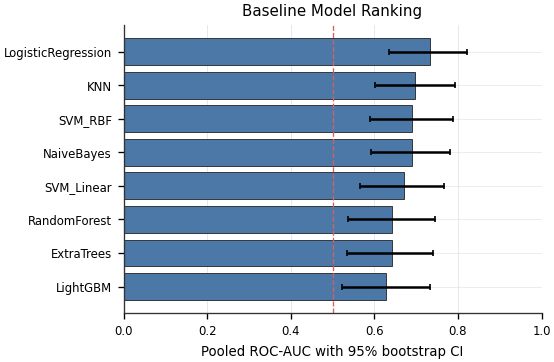

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig02_baseline_roc_curves_top_models.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig02_baseline_roc_curves_top_models.pdf


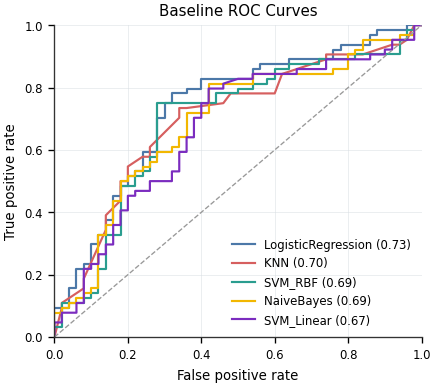

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig03_baseline_best_model_confusion_matrix.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig03_baseline_best_model_confusion_matrix.pdf


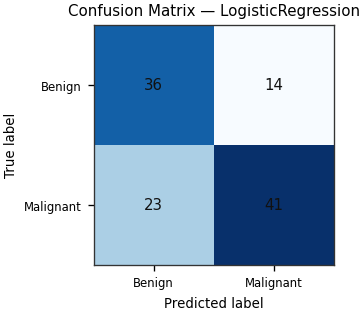

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig04_baseline_best_model_calibration_curve.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig04_baseline_best_model_calibration_curve.pdf


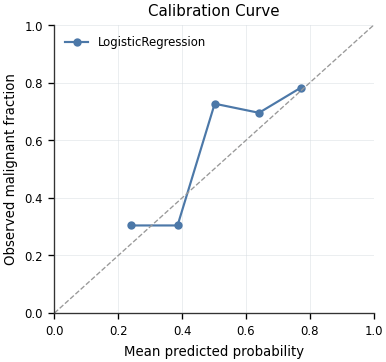

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig05_baseline_best_model_metric_profile.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig05_baseline_best_model_metric_profile.pdf


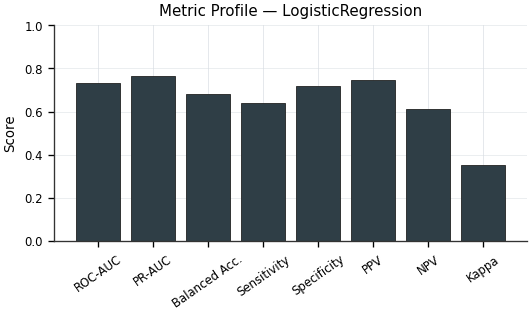

Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig06_baseline_feature_selection_stability.png
Saved: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/final_run_reports/plots_publication_style/fig06_baseline_feature_selection_stability.pdf


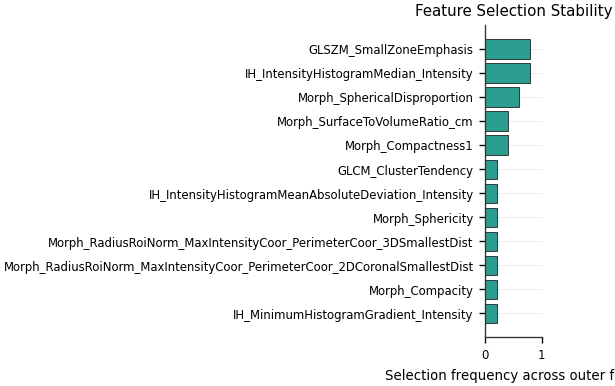


════════════════════════════════════════════════════════════════════════════════
STEP 2B BASELINE SUMMARY
════════════════════════════════════════════════════════════════════════════════
run_name: legacy_elasticnet_then_mrmr_k8_no_smote
save_dir: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote
best_model_by_pooled_auc: LogisticRegression
best_model_roc_auc: 0.733125
best_model_roc_auc_ci95_low: 0.6354924952384419
best_model_roc_auc_ci95_high: 0.8224116633057631
best_model_pr_auc: 0.7642335106591933
best_model_accuracy: 0.6754385964912281
best_model_balanced_accuracy: 0.6803125
best_model_sensitivity: 0.640625
best_model_specificity: 0.72
best_model_ppv: 0.7454545454545455
best_model_npv: 0.6101694915254238
best_model_f1: 0.6890756302521008
best_model_cohen_kappa: 0.35366227398099914
best_model_brier_score: 0.21095353193013966
friedman_auc_p_value: 0.2485411363895314
n_models_evaluated: 10
use_smote: False
fs_method:

In [48]:
# =============================================================================
# STEP 2B — BASELINE NESTED-CV STATISTICAL REPORTING AND COMPACT FIGURES
# =============================================================================
# Purpose:
#   - Summarize baseline nested-CV performance.
#   - Compute pooled metrics: ROC-AUC, PR-AUC, accuracy, balanced accuracy,
#     sensitivity, specificity, PPV, NPV, F1, Cohen's kappa, Brier score.
#   - Add exploratory statistical comparisons across models.
#   - Generate compact, non-redundant, publication-style plots.
#
# Important:
#   - This cell does NOT retrain models.
#   - It only analyzes outputs from nested_cv_results, df_summary, df_fold_details,
#     and pm_df.
# =============================================================================
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)


print("█" * 80)
# FINAL RUN — NESTED-CV STATISTICAL REPORTING
print("  FINAL RUN — STATISTICAL EVALUATION AND PUBLICATION FIGURES")
print("█" * 80)

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    calibration_curve
)

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Output directories
# -----------------------------------------------------------------------------
baseline_dir = CONFIG.get(
    "SAVE_DIR",
    os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "step_2_baseline_nested_cv_no_smote")
)

report_dir = os.path.join(baseline_dir, "final_run_reports")
plot_dir = os.path.join(report_dir, "plots_publication_style")

os.makedirs(report_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

print(f"\nBaseline report directory:\n  {report_dir}")
print(f"Plot directory:\n  {plot_dir}")

# -----------------------------------------------------------------------------
# 2. Publication-style plotting theme
# -----------------------------------------------------------------------------
plt.style.use("default")

FIG_DPI = 600

COLORS = {
    "primary": "#4C78A8",
    "secondary": "#D65F5F",
    "accent": "#2A9D8F",
    "dark": "#2F3E46",
    "neutral": "#6C757D",
    "light": "#F1F3F5",
    "grid": "#D9DEE3"
}

MODEL_COLORS = [
    "#4C78A8", "#D65F5F", "#2A9D8F", "#F2B701",
    "#7B2CBF", "#6C757D", "#E76F51", "#264653"
]

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.5,
    "grid.alpha": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axis(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)


def save_figure(fig, filename_base):
    png_path = os.path.join(plot_dir, f"{filename_base}.png")
    pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def compute_specificity_np(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def compute_npv_np(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


def bootstrap_metric_ci(y_true, y_score_or_pred, metric_func, n_boot=2000, seed=100):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    arr = np.asarray(y_score_or_pred)
    n = len(y_true)

    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        # Skip bootstrap samples with one class only for AUC-like metrics
        if len(np.unique(y_true[idx])) < 2:
            continue

        try:
            values.append(metric_func(y_true[idx], arr[idx]))
        except Exception:
            continue

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    values = np.asarray(values, dtype=float)
    return (
        float(np.nanmean(values)),
        float(np.nanpercentile(values, 2.5)),
        float(np.nanpercentile(values, 97.5))
    )


# -----------------------------------------------------------------------------
# 3. Required object checks
# -----------------------------------------------------------------------------
required_objects = ["nested_cv_results", "df_summary", "df_fold_details", "pm_df"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(f"Required object '{obj_name}' not found. Run Cell 13 and Cell 14 first.")

# -----------------------------------------------------------------------------
# 4. Pooled baseline metrics for each model
# -----------------------------------------------------------------------------
pooled_rows = []

for model_name, res in nested_cv_results.items():
    y_true = np.asarray(res["y_true"], dtype=int)
    y_prob = np.asarray(res["y_prob"], dtype=float)
    y_pred = np.asarray(res["y_pred"], dtype=int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = compute_specificity_np(y_true, y_pred)
    ppv = precision_score(y_true, y_pred, zero_division=0)
    npv = compute_npv_np(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_prob)

    auc_mean_boot, auc_ci_low, auc_ci_high = bootstrap_metric_ci(
        y_true,
        y_prob,
        roc_auc_score,
        n_boot=2000,
        seed=CONFIG.get("RANDOM_STATE", 100)
    )

    pr_mean_boot, pr_ci_low, pr_ci_high = bootstrap_metric_ci(
        y_true,
        y_prob,
        average_precision_score,
        n_boot=2000,
        seed=CONFIG.get("RANDOM_STATE", 100) + 1
    )

    pooled_rows.append({
        "Model": model_name,
        "ROC_AUC": roc_auc,
        "ROC_AUC_bootstrap_mean": auc_mean_boot,
        "ROC_AUC_CI95_low": auc_ci_low,
        "ROC_AUC_CI95_high": auc_ci_high,
        "PR_AUC": pr_auc,
        "PR_AUC_bootstrap_mean": pr_mean_boot,
        "PR_AUC_CI95_low": pr_ci_low,
        "PR_AUC_CI95_high": pr_ci_high,
        "Accuracy": acc,
        "Balanced_Accuracy": bal_acc,
        "Sensitivity_Recall": sensitivity,
        "Specificity": specificity,
        "PPV_Precision": ppv,
        "NPV": npv,
        "F1": f1,
        "Cohen_Kappa": kappa,
        "Brier_Score": brier,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
        "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
    })

baseline_pooled_metrics_df = pd.DataFrame(pooled_rows)
baseline_pooled_metrics_df = baseline_pooled_metrics_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

baseline_pooled_metrics_df.to_csv(
    os.path.join(report_dir, "final_pooled_metrics_with_ci.csv"),
    index=False
)

print("\n" + "═" * 80)
print("BASELINE POOLED METRICS")
print("═" * 80)
print(
    baseline_pooled_metrics_df[
        [
            "Model", "ROC_AUC", "ROC_AUC_CI95_low", "ROC_AUC_CI95_high",
            "PR_AUC", "Accuracy", "Balanced_Accuracy",
            "Sensitivity_Recall", "Specificity", "PPV_Precision", "NPV",
            "F1", "Cohen_Kappa", "Brier_Score", "Mean_Selected_Features"
        ]
    ].to_string(index=False, float_format="%.4f")
)

best_model_name = baseline_pooled_metrics_df.iloc[0]["Model"]
best_res = nested_cv_results[best_model_name]

print(f"\nBest baseline model by pooled ROC-AUC: {best_model_name}")

# -----------------------------------------------------------------------------
# 5. Exploratory model comparison statistics
# -----------------------------------------------------------------------------
# Friedman test across models using fold AUCs.
# With 5 outer folds, this is exploratory and low-powered.
fold_auc_table = pm_df.pivot(index="Fold", columns="Model", values="AUC")

model_comparison_summary = {}

if fold_auc_table.shape[1] >= 3:
    try:
        friedman_stat, friedman_p = friedmanchisquare(
            *[fold_auc_table[col].values for col in fold_auc_table.columns]
        )
    except Exception:
        friedman_stat, friedman_p = np.nan, np.nan
else:
    friedman_stat, friedman_p = np.nan, np.nan

model_comparison_summary["friedman_auc_statistic"] = float(friedman_stat) if np.isfinite(friedman_stat) else None
model_comparison_summary["friedman_auc_p_value"] = float(friedman_p) if np.isfinite(friedman_p) else None

# single Wilcoxon against best model
single_rows = []

if best_model_name in fold_auc_table.columns:
    best_auc_values = fold_auc_table[best_model_name].values

    for model_name in fold_auc_table.columns:
        if model_name == best_model_name:
            continue

        other_auc_values = fold_auc_table[model_name].values

        try:
            stat, p = wilcoxon(
                best_auc_values,
                other_auc_values,
                zero_method="wilcox",
                alternative="two-sided"
            )
        except Exception:
            stat, p = np.nan, np.nan

        single_rows.append({
            "Comparison": f"{best_model_name} vs {model_name}",
            "Best_Model": best_model_name,
            "Other_Model": model_name,
            "Mean_AUC_Best": np.mean(best_auc_values),
            "Mean_AUC_Other": np.mean(other_auc_values),
            "Mean_AUC_Difference": np.mean(best_auc_values - other_auc_values),
            "Wilcoxon_Statistic": stat,
            "Wilcoxon_p_value": p
        })

single_model_tests_df = pd.DataFrame(single_rows)

if len(single_model_tests_df) > 0:
    pvals = single_model_tests_df["Wilcoxon_p_value"].values.astype(float)

    valid = np.isfinite(pvals)
    qvals = np.full(len(pvals), np.nan)

    if valid.sum() > 0:
        valid_p = pvals[valid]
        order = np.argsort(valid_p)
        ranked = valid_p[order]
        adjusted = ranked * len(valid_p) / (np.arange(1, len(valid_p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)
        q_valid = np.empty_like(valid_p)
        q_valid[order] = adjusted
        qvals[valid] = q_valid

    single_model_tests_df["Wilcoxon_q_value_FDR"] = qvals

single_model_tests_df.to_csv(
    os.path.join(report_dir, "baseline_single_wilcoxon_auc_vs_best.csv"),
    index=False
)

with open(os.path.join(report_dir, "baseline_model_comparison_summary.json"), "w") as f:
    json.dump(model_comparison_summary, f, indent=4)

print("\n" + "═" * 80)
print("EXPLORATORY MODEL COMPARISON")
print("═" * 80)
print(f"Friedman test across model fold-AUCs: p = {friedman_p:.6f}" if np.isfinite(friedman_p) else "Friedman test not available.")

if len(single_model_tests_df) > 0:
    print("\nsingle Wilcoxon tests vs best model:")
    print(single_model_tests_df.to_string(index=False, float_format="%.4f"))


# -----------------------------------------------------------------------------
# 6. Figure 1 — Model ROC-AUC ranking with bootstrap CI
# -----------------------------------------------------------------------------
top_models_auc = baseline_pooled_metrics_df.head(8).iloc[::-1]

fig, ax = plt.subplots(figsize=(4.8, 3.2))

xerr_low = top_models_auc["ROC_AUC"] - top_models_auc["ROC_AUC_CI95_low"]
xerr_high = top_models_auc["ROC_AUC_CI95_high"] - top_models_auc["ROC_AUC"]

ax.barh(
    top_models_auc["Model"],
    top_models_auc["ROC_AUC"],
    xerr=[xerr_low, xerr_high],
    color=COLORS["primary"],
    edgecolor="#222222",
    linewidth=0.5,
    capsize=2
)

ax.axvline(0.5, linestyle="--", linewidth=0.8, color=COLORS["secondary"])
ax.set_xlim(0.0, 1.0)
ax.set_title("Baseline Model Ranking")
ax.set_xlabel("Pooled ROC-AUC with 95% bootstrap CI")
ax.set_ylabel("")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig01_baseline_model_auc_ranking")
plt.show()


# -----------------------------------------------------------------------------
# 7. Figure 2 — ROC curves for top models
# -----------------------------------------------------------------------------
top_roc_models = baseline_pooled_metrics_df["Model"].head(min(5, len(baseline_pooled_metrics_df))).tolist()

fig, ax = plt.subplots(figsize=(3.8, 3.4))

for i, model_name in enumerate(top_roc_models):
    res = nested_cv_results[model_name]
    y_true = np.asarray(res["y_true"], dtype=int)
    y_prob = np.asarray(res["y_prob"], dtype=float)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)

    ax.plot(
        fpr,
        tpr,
        linewidth=1.3,
        color=MODEL_COLORS[i % len(MODEL_COLORS)],
        label=f"{model_name} ({auc_value:.2f})"
    )

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")
ax.set_title("Baseline ROC Curves")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
clean_axis(ax, grid_axis="both")

plt.tight_layout()
save_figure(fig, "fig02_baseline_roc_curves_top_models")
plt.show()


# -----------------------------------------------------------------------------
# 8. Figure 3 — Confusion matrix for best baseline model
# -----------------------------------------------------------------------------
best_y_true = np.asarray(best_res["y_true"], dtype=int)
best_y_prob = np.asarray(best_res["y_prob"], dtype=float)
best_y_pred = np.asarray(best_res["y_pred"], dtype=int)

cm = confusion_matrix(best_y_true, best_y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(3.1, 2.8))

im = ax.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="#111111",
            fontsize=9
        )

ax.set_title(f"Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benign", "Malignant"])
ax.set_yticklabels(["Benign", "Malignant"])
ax.grid(False)

plt.tight_layout()
save_figure(fig, "fig03_baseline_best_model_confusion_matrix")
plt.show()


# -----------------------------------------------------------------------------
# 9. Figure 4 — Calibration curve for best baseline model
# -----------------------------------------------------------------------------
frac_pos, mean_pred = manual_calibration_curve(
    best_y_true,
    best_y_prob,
    n_bins=5
)

fig, ax = plt.subplots(figsize=(3.4, 3.2))

ax.plot(
    mean_pred,
    frac_pos,
    marker="o",
    linewidth=1.3,
    markersize=4,
    color=COLORS["primary"],
    label=best_model_name
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

ax.set_title("Calibration Curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed malignant fraction")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper left")
clean_axis(ax, grid_axis="both")

plt.tight_layout()
save_figure(fig, "fig04_baseline_best_model_calibration_curve")
plt.show()


# -----------------------------------------------------------------------------
# 10. Figure 5 — Compact metric profile for best model
# -----------------------------------------------------------------------------
best_metric_row = baseline_pooled_metrics_df[
    baseline_pooled_metrics_df["Model"] == best_model_name
].iloc[0]

metric_profile = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Balanced Acc.",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Kappa"
    ],
    "Value": [
        best_metric_row["ROC_AUC"],
        best_metric_row["PR_AUC"],
        best_metric_row["Balanced_Accuracy"],
        best_metric_row["Sensitivity_Recall"],
        best_metric_row["Specificity"],
        best_metric_row["PPV_Precision"],
        best_metric_row["NPV"],
        best_metric_row["Cohen_Kappa"]
    ]
})

metric_profile.to_csv(
    os.path.join(report_dir, "baseline_best_model_metric_profile.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(4.6, 2.8))

ax.bar(
    metric_profile["Metric"],
    metric_profile["Value"],
    color=COLORS["dark"],
    edgecolor="#222222",
    linewidth=0.5
)

ax.set_ylim(0, 1)
ax.set_title(f"Metric Profile — {best_model_name}")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig05_baseline_best_model_metric_profile")
plt.show()


# -----------------------------------------------------------------------------
# 11. Figure 6 — Feature selection stability among selected features
# -----------------------------------------------------------------------------
if "df_selected_features_long" in globals() and len(df_selected_features_long) > 0:
    stability_df = (
        df_selected_features_long
        .groupby("Feature_Name")
        .size()
        .reset_index(name="Selection_Count")
        .sort_values("Selection_Count", ascending=False)
    )

    stability_df["Selection_Frequency"] = stability_df["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]

    stability_df.to_csv(
        os.path.join(report_dir, "baseline_feature_selection_stability.csv"),
        index=False
    )

    top_stable = stability_df.head(12).iloc[::-1]

    fig, ax = plt.subplots(figsize=(4.8, 3.4))

    ax.barh(
        top_stable["Feature_Name"],
        top_stable["Selection_Frequency"],
        color=COLORS["accent"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_xlim(0, 1)
    ax.set_title("Feature Selection Stability")
    ax.set_xlabel("Selection frequency across outer folds")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig06_baseline_feature_selection_stability")
    plt.show()
else:
    stability_df = pd.DataFrame()
    print("\nNo selected feature long table found; stability plot skipped.")


# -----------------------------------------------------------------------------
# 12. Compact summary JSON
# -----------------------------------------------------------------------------
step_2b_summary = {
    "run_name": CONFIG.get("RUN_NAME", "step_2_baseline_nested_cv_no_smote"),
    "save_dir": baseline_dir,
    "best_model_by_pooled_auc": best_model_name,
    "best_model_roc_auc": float(best_metric_row["ROC_AUC"]),
    "best_model_roc_auc_ci95_low": float(best_metric_row["ROC_AUC_CI95_low"]),
    "best_model_roc_auc_ci95_high": float(best_metric_row["ROC_AUC_CI95_high"]),
    "best_model_pr_auc": float(best_metric_row["PR_AUC"]),
    "best_model_accuracy": float(best_metric_row["Accuracy"]),
    "best_model_balanced_accuracy": float(best_metric_row["Balanced_Accuracy"]),
    "best_model_sensitivity": float(best_metric_row["Sensitivity_Recall"]),
    "best_model_specificity": float(best_metric_row["Specificity"]),
    "best_model_ppv": float(best_metric_row["PPV_Precision"]),
    "best_model_npv": float(best_metric_row["NPV"]),
    "best_model_f1": float(best_metric_row["F1"]),
    "best_model_cohen_kappa": float(best_metric_row["Cohen_Kappa"]),
    "best_model_brier_score": float(best_metric_row["Brier_Score"]),
    "friedman_auc_p_value": (
        float(friedman_p) if np.isfinite(friedman_p) else None
    ),
    "n_models_evaluated": int(len(baseline_pooled_metrics_df)),
    "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
    "fs_method": CONFIG.get("FS_METHOD", None),
    "fs_n_features": CONFIG.get("FS_N_FEATURES", None),
    "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
    "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
    "report_dir": report_dir,
    "plot_dir": plot_dir
}

with open(os.path.join(report_dir, "step_2b_summary.json"), "w") as f:
    json.dump(step_2b_summary, f, indent=4)

print("\n" + "═" * 80)
print("STEP 2B BASELINE SUMMARY")
print("═" * 80)

for k, v in step_2b_summary.items():
    print(f"{k}: {v}")

print("\nSaved baseline reports and compact publication-style plots to:")
print(f"  {report_dir}")
print(f"  {plot_dir}")

print("\n✅ STEP 2B completed successfully.")

In [49]:
# =============================================================================
# STEP 3A — OPTIONAL LEGACY SMOTE ABLATION CONFIGURATION LOCK
# =============================================================================
# This cell is disabled by default because the systematic SMOTE/no-SMOTE
# comparison is handled inside FS_EXPERIMENTS.
# =============================================================================

if not bool(globals().get("RUN_SMOTE_ABLATION", False)):
    print("█" * 80)
    print("  STEP 3A — SKIPPED")
    print("█" * 80)
    print("RUN_SMOTE_ABLATION=False. SMOTE/no-SMOTE comparison is handled in the FS grid.")
else:
    print("█" * 80)
    print("  STEP 3A — SMOTE ABLATION CONFIGURATION LOCK")
    print("█" * 80)

    import os
    import json

    CONFIG["RUN_NAME"] = "step_3_smote_nested_cv"
    CONFIG["SAVE_DIR"] = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        CONFIG["RUN_NAME"]
    )
    SAVE_DIR = CONFIG["SAVE_DIR"]
    os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

    CONFIG["USE_SMOTE"] = True
    CONFIG["FS_METHOD"] = "mrmr_then_elasticnet_no_corr"
    CONFIG["FS_N_FEATURES"] = 14
    CONFIG["AUTO_TUNE_FS_N_FEATURES"] = False
    CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
    CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
    CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

    if "groups" not in globals():
        raise RuntimeError("groups object not found. Run Step 1 first.")

    smote_config_snapshot = {
        "RUN_NAME": CONFIG["RUN_NAME"],
        "SAVE_DIR": CONFIG["SAVE_DIR"],
        "USE_SMOTE": CONFIG["USE_SMOTE"],
        "FS_METHOD": CONFIG["FS_METHOD"],
        "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
        "AUTO_TUNE_FS_N_FEATURES": CONFIG.get("AUTO_TUNE_FS_N_FEATURES"),
        "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
        "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
        "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
        "RANDOM_STATE": CONFIG["RANDOM_STATE"],
        "N_SAMPLES": int(X.shape[0]),
        "N_FEATURES": int(X.shape[1]),
        "N_PATIENTS": int(len(set(groups))),
    }

    with open(os.path.join(CONFIG["SAVE_DIR"], "smote_config_snapshot.json"), "w") as f:
        json.dump(smote_config_snapshot, f, indent=4)

    print("SMOTE ablation configuration:")
    for k, v in smote_config_snapshot.items():
        print(f"  {k}: {v}")

    print("✅ STEP 3A completed successfully.")


████████████████████████████████████████████████████████████████████████████████
  STEP 3A — SKIPPED
████████████████████████████████████████████████████████████████████████████████
RUN_SMOTE_ABLATION=False. SMOTE/no-SMOTE comparison is handled in the FS grid.


In [50]:
# =============================================================================
# STEP 3A-RUN — OPTIONAL LEGACY SMOTE NESTED CV
# =============================================================================

if not bool(globals().get("RUN_SMOTE_ABLATION", False)):
    print("STEP 3A-RUN skipped because RUN_SMOTE_ABLATION=False.")
else:
    import copy
    import os

    smote_cfg = copy.deepcopy(CONFIG)
    smote_cfg.update({
        "RUN_NAME": "step_3_smote_nested_cv",
        "SAVE_DIR": os.path.join(
            CONFIG["DATASET_OUTPUT_ROOT"],
            "step_3_smote_nested_cv"
        ),
        "USE_SMOTE": True,
        "FS_METHOD": "mrmr_then_elasticnet_no_corr",
        "FS_N_FEATURES": 14,
        "AUTO_TUNE_FS_N_FEATURES": False,
    })

    smote_outputs = run_nested_cv_experiment(
        config_run=smote_cfg,
        model_subset=None,
        overwrite=OVERWRITE_FS_RUNS
    )

    CONFIG = copy.deepcopy(smote_cfg)
    SAVE_DIR = CONFIG["SAVE_DIR"]

    nested_cv_results = smote_outputs["nested_cv_results"]
    df_summary = smote_outputs["df_summary"]
    df_fold_details = smote_outputs["df_fold_details"]
    df_oof_predictions = smote_outputs["df_oof_predictions"]
    df_selected_features_long = smote_outputs["df_selected_features_long"]
    selected_features_per_fold = smote_outputs["selected_features_per_fold"]
    fold_details = smote_outputs["fold_details"]

    ACTIVE_RUN_NAME = CONFIG["RUN_NAME"]
    ACTIVE_FS_METHOD = CONFIG["FS_METHOD"]
    ACTIVE_USE_SMOTE = CONFIG["USE_SMOTE"]
    ACTIVE_SAVE_DIR = SAVE_DIR

    expected_smote_pkl = os.path.join(SAVE_DIR, "nested_cv_results.pkl")
    assert os.path.exists(expected_smote_pkl), f"SMOTE pkl was not created: {expected_smote_pkl}"
    print("✅ SMOTE nested_cv_results.pkl created:")
    print(expected_smote_pkl)


STEP 3A-RUN skipped because RUN_SMOTE_ABLATION=False.


In [51]:
publication_all_models_df.to_csv(
    os.path.join(ACTIVE_SAVE_DIR,
                 'publication_all_models_summary.csv'),
    index=False
)

all_model_summary_df.to_csv(
    os.path.join(ACTIVE_SAVE_DIR,
                 'all_model_summary_statistics.csv'),
    index=False
)

🤖 Best Model Detected: LogisticRegression



✅ High-resolution plot (DPI 900) saved to: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/best_model_LogisticRegression_folds_report.png


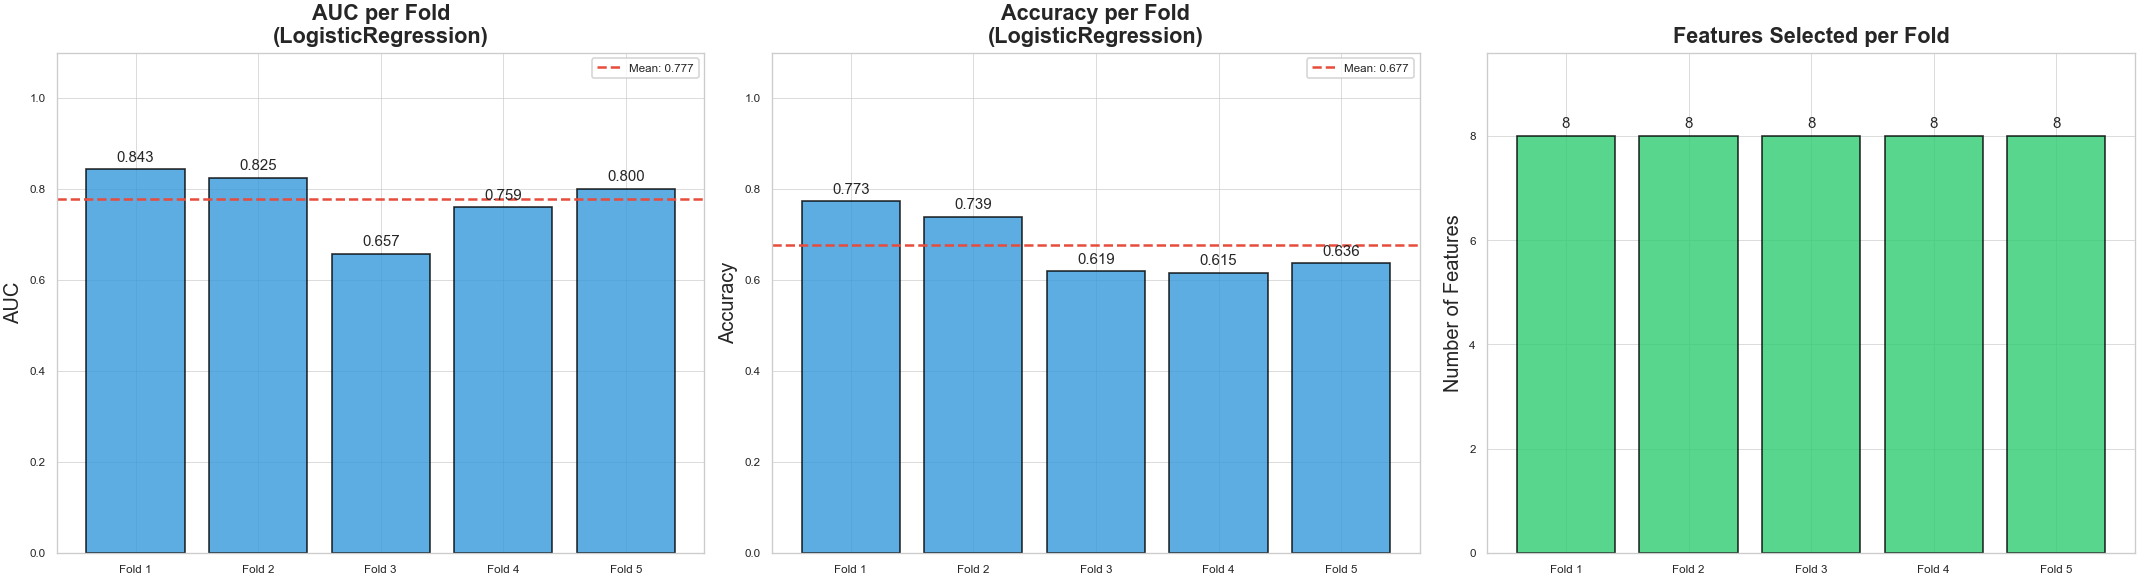


📊 FINAL SUMMARY (LogisticRegression - 5-Fold Cross-Validation)

🔹 AUC:       0.7770 ± 0.0660
   Range: [0.6574, 0.8430]

🔹 Accuracy:  0.6765 ± 0.0661


In [52]:
# =============================================================================
# COHORT GRAPHICAL REPORTING AND FEATURE SELECTION STABILITY MANIFEST
# =============================================================================
# Purpose:
#   - Isolate execution results for the top-performing estimator configuration.
#   - Generate publication-grade, high-resolution tripartite diagnostic charts.
#   - Synthesize a structural feature selection recurrence manifest to evaluate 
#     cross-fold biomarker stability and reproducibility metrics.
# =============================================================================

import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply standardized uniform layout parameters for peer-review charting
sns.set_style("whitegrid")

df_summary = df_summary.sort_values(by='Mean_AUC', ascending=False).reset_index(drop=True)
best_model_name = df_summary.iloc[0]['Model']

# Dynamically isolate the highest performing configuration matrix pattern
best_model_name = df_summary.iloc[0]['Model'] 
print(f"🤖 Best Model Detected: {best_model_name}\n")

# Filter localized out-of-fold diagnostic matrices matching the top candidate
best_model_folds = df_fold_details[df_fold_details['Model'] == best_model_name].copy()

actual_n_outer = len(best_model_folds)

fold_labels = [f"Fold {int(f)}" for f in best_model_folds['Fold']]
aucs = best_model_folds['AUC'].values
accuracies = best_model_folds['Acc'].values
n_features = best_model_folds['n_features'].values

mean_auc = np.mean(aucs)
mean_acc = np.mean(accuracies)

# --- Subplot 1 to 3: Multi-panel Diagnostic Performance Charts ---------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db'] * actual_n_outer

# 1️⃣ Subplot A: Receiver Operating Characteristic Area Under Curve (AUC)
ax1 = axes[0]
bars1 = ax1.bar(fold_labels, aucs, color=colors, edgecolor='black', alpha=0.8)
ax1.set_ylabel('AUC', fontsize=12)
ax1.set_title(f'AUC per Fold\n({best_model_name})', fontsize=13, fontweight='bold')
ax1.set_ylim(0.0, 1.1)  # Expanded upper boundary to accommodate structural annotation text
ax1.axhline(y=mean_auc, color='#e74c3c', linestyle='--', label=f"Mean: {mean_auc:.3f}")
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
ax1.legend()

# 2️⃣ Subplot B: Empirical Classification Accuracy Profiles
ax2 = axes[1]
bars2 = ax2.bar(fold_labels, accuracies, color=colors, edgecolor='black', alpha=0.8)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f'Accuracy per Fold\n({best_model_name})', fontsize=13, fontweight='bold')
ax2.set_ylim(0.0, 1.1)
ax2.axhline(y=mean_acc, color='#e74c3c', linestyle='--', label=f"Mean: {mean_acc:.3f}")
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
ax2.legend()

# 3️⃣ Subplot C: Selected Feature Cardinality Volatility Matrix
ax3 = axes[2]
bars3 = ax3.bar(fold_labels, n_features, color='#2ecc71', edgecolor='black', alpha=0.8)
ax3.set_ylabel('Number of Features', fontsize=12)
ax3.set_title('Features Selected per Fold', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(n_features) * 1.2 if len(n_features) > 0 else 10)
for bar in bars3:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save structural presentation graphics using extreme high-resolution (DPI 900)
os.makedirs(SAVE_DIR, exist_ok=True)
plot_path = os.path.join(SAVE_DIR, f"best_model_{best_model_name}_folds_report.png")
plt.savefig(plot_path, dpi=600)
print(f"✅ High-resolution plot (DPI 900) saved to: {plot_path}")
plt.show()
plt.close()


# =============================================================================
# COHORT SUMMARY AND INFERENCE CRITERIA TABLES
# =============================================================================
print("\n" + "="*60)
print(f"📊 FINAL SUMMARY ({best_model_name} - {actual_n_outer}-Fold Cross-Validation)")
print("="*60)

print(f"\n🔹 AUC:       {mean_auc:.4f} ± {np.std(aucs):.4f}")
print(f"   Range: [{np.min(aucs):.4f}, {np.max(aucs):.4f}]")

print(f"\n🔹 Accuracy:  {mean_acc:.4f} ± {np.std(accuracies):.4f}")


In [53]:
    # =============================================================================
    # STEP 3B — SMOTE VS BASELINE STATISTICAL COMPARISON AND COMPACT FIGURES
    # =============================================================================
    # Purpose:
    #   - Compare Step 3 SMOTE run against Step 2 baseline.
    #   - Use the same models, same CV design, and same evaluation logic.
    #   - Compute pooled metric deltas, paired bootstrap CIs, and fold-wise Wilcoxon tests.
    #   - Generate compact publication-style comparison plots.
    #
    # Important:
    #   - This cell does NOT retrain models.
    #   - It analyzes the current SMOTE nested_cv_results and the saved baseline outputs.
    # =============================================================================
current_use_smote = bool(CONFIG.get("USE_SMOTE", False))
run_legacy_smote_comparison = bool(globals().get("RUN_SMOTE_VS_BASELINE_COMPARISON", False))

if not run_legacy_smote_comparison:
    print("█" * 80)
    print("  STEP 3B — SKIPPED")
    print("█" * 80)
    print("RUN_SMOTE_VS_BASELINE_COMPARISON=False. Use fs_comparison_smote_vs_no_smote_*.csv for the systematic comparison.")
elif not current_use_smote:
    print("█" * 80)
    print("  STEP 3B — SKIPPED")
    print("█" * 80)
    print("This cell is only for SMOTE-enabled runs.")
    print(f"Current USE_SMOTE is: {CONFIG.get('USE_SMOTE', None)}")
    print("No SMOTE-vs-baseline comparison was executed.")

else:
    print("█" * 80)
    print("  STEP 3B — SMOTE VS BASELINE COMPARISON")
    print("█" * 80)

    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_2_baseline_nested_cv_no_smote"
    )

    smote_dir = CONFIG.get(
        "SAVE_DIR",
        os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "step_3_smote_nested_cv")
    )

    comparison_dir = os.path.join(smote_dir, "step_3b_smote_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    if not os.path.exists(baseline_pkl_path):
        raise FileNotFoundError(
            f"Baseline nested_cv_results not found:\n{baseline_pkl_path}\n"
            "Make sure Step 2 baseline Cell 13 was completed and saved."
        )

    if "nested_cv_results" not in globals():
        raise RuntimeError("Current SMOTE nested_cv_results not found. Run Cell 13 after Step 3A.")

    with open(baseline_pkl_path, "rb") as f:
        baseline_results = pickle.load(f)

    smote_results = nested_cv_results

    print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
    print(f"Using current SMOTE results from runtime and SAVE_DIR:\n  {smote_dir}")

    # -----------------------------------------------------------------------------
    # 2. Publication-style plotting theme
    # -----------------------------------------------------------------------------
    plt.style.use("default")

    FIG_DPI = 600

    COLORS = {
        "baseline": "#4C78A8",
        "smote": "#D65F5F",
        "delta_pos": "#2A9D8F",
        "delta_neg": "#B23A48",
        "dark": "#2F3E46",
        "neutral": "#6C757D",
        "grid": "#D9DEE3"
    }

    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": FIG_DPI,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "#333333",
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.5,
        "grid.alpha": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


    def clean_axis(ax, grid_axis="y"):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    def save_figure(fig, filename_base):
        png_path = os.path.join(plot_dir, f"{filename_base}.png")
        pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
        fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")


    def compute_specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def compute_npv(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def benjamini_hochberg(p_values):
        p_values = np.asarray(p_values, dtype=float)
        q_values = np.full(len(p_values), np.nan)

        valid = np.isfinite(p_values)
        p = p_values[valid]

        if len(p) == 0:
            return q_values

        order = np.argsort(p)
        ranked = p[order]
        adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)

        q_valid = np.empty_like(p)
        q_valid[order] = adjusted
        q_values[valid] = q_valid

        return q_values


    def pooled_metrics_from_results(results_dict):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Accuracy": accuracy_score(y_true, y_pred),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": compute_specificity(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": compute_npv(y_true, y_pred),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier_Score": brier_score_loss(y_true, y_prob),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
            })

        return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


    def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
        """
        Paired bootstrap CI for delta = metric_b - metric_a.
        Here:
            a = baseline
            b = SMOTE
        """
        rng = np.random.default_rng(seed)

        y_true = np.asarray(y_true, dtype=int)
        prob_a = np.asarray(prob_a, dtype=float)
        prob_b = np.asarray(prob_b, dtype=float)

        n = len(y_true)
        deltas = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            try:
                val_a = metric_func(y_true[idx], prob_a[idx])
                val_b = metric_func(y_true[idx], prob_b[idx])
                deltas.append(val_b - val_a)
            except Exception:
                continue

        if len(deltas) == 0:
            return np.nan, np.nan, np.nan

        deltas = np.asarray(deltas, dtype=float)

        return (
            float(np.nanmean(deltas)),
            float(np.nanpercentile(deltas, 2.5)),
            float(np.nanpercentile(deltas, 97.5))
        )


    # -----------------------------------------------------------------------------
    # 3. Compute pooled metrics
    # -----------------------------------------------------------------------------
    baseline_metrics_df = pooled_metrics_from_results(baseline_results)
    smote_metrics_df = pooled_metrics_from_results(smote_results)

    baseline_metrics_df.to_csv(
        os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
        index=False
    )

    smote_metrics_df.to_csv(
        os.path.join(comparison_dir, "smote_pooled_metrics.csv"),
        index=False
    )

    common_models = sorted(set(baseline_metrics_df["Model"]).intersection(smote_metrics_df["Model"]))

    comparison_rows = []

    for model_name in common_models:
        b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
        s_row = smote_metrics_df[smote_metrics_df["Model"] == model_name].iloc[0]

        b_res = baseline_results[model_name]
        s_res = smote_results[model_name]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        s_y_true = np.asarray(s_res["y_true"], dtype=int)

        same_oof_order = (
            len(b_y_true) == len(s_y_true)
            and np.array_equal(b_y_true, s_y_true)
        )

        if same_oof_order:
            auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(s_res["y_prob"], dtype=float),
                roc_auc_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100)
            )

            pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(s_res["y_prob"], dtype=float),
                average_precision_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100) + 1
            )
        else:
            auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
            pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

        # Fold-wise Wilcoxon on outer-fold AUCs
        b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
        s_fold_auc = np.asarray(s_res["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(s_fold_auc) and len(b_fold_auc) >= 2:
            try:
                w_stat, w_p = wilcoxon(
                    s_fold_auc,
                    b_fold_auc,
                    alternative="two-sided",
                    zero_method="wilcox"
                )
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            w_stat, w_p = np.nan, np.nan

        comparison_rows.append({
            "Model": model_name,

            "Baseline_ROC_AUC": b_row["ROC_AUC"],
            "SMOTE_ROC_AUC": s_row["ROC_AUC"],
            "Delta_ROC_AUC_SMOTE_minus_Baseline": s_row["ROC_AUC"] - b_row["ROC_AUC"],
            "Paired_Bootstrap_Delta_ROC_AUC_Mean": auc_delta_mean,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

            "Baseline_PR_AUC": b_row["PR_AUC"],
            "SMOTE_PR_AUC": s_row["PR_AUC"],
            "Delta_PR_AUC_SMOTE_minus_Baseline": s_row["PR_AUC"] - b_row["PR_AUC"],
            "Paired_Bootstrap_Delta_PR_AUC_Mean": pr_delta_mean,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_Low": pr_delta_low,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_High": pr_delta_high,

            "Baseline_Balanced_Accuracy": b_row["Balanced_Accuracy"],
            "SMOTE_Balanced_Accuracy": s_row["Balanced_Accuracy"],
            "Delta_Balanced_Accuracy": s_row["Balanced_Accuracy"] - b_row["Balanced_Accuracy"],

            "Baseline_Sensitivity": b_row["Sensitivity"],
            "SMOTE_Sensitivity": s_row["Sensitivity"],
            "Delta_Sensitivity": s_row["Sensitivity"] - b_row["Sensitivity"],

            "Baseline_Specificity": b_row["Specificity"],
            "SMOTE_Specificity": s_row["Specificity"],
            "Delta_Specificity": s_row["Specificity"] - b_row["Specificity"],

            "Baseline_PPV": b_row["PPV"],
            "SMOTE_PPV": s_row["PPV"],
            "Delta_PPV": s_row["PPV"] - b_row["PPV"],

            "Baseline_NPV": b_row["NPV"],
            "SMOTE_NPV": s_row["NPV"],
            "Delta_NPV": s_row["NPV"] - b_row["NPV"],

            "Baseline_Kappa": b_row["Cohen_Kappa"],
            "SMOTE_Kappa": s_row["Cohen_Kappa"],
            "Delta_Kappa": s_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

            "Baseline_Brier": b_row["Brier_Score"],
            "SMOTE_Brier": s_row["Brier_Score"],
            "Delta_Brier_SMOTE_minus_Baseline": s_row["Brier_Score"] - b_row["Brier_Score"],

            "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
            "SMOTE_Mean_Selected_Features": s_row["Mean_Selected_Features"],

            "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
            "Foldwise_Wilcoxon_AUC_p_value": w_p,
            "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
        })

    comparison_df = pd.DataFrame(comparison_rows)

    comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
        comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
    )

    comparison_df = comparison_df.sort_values(
        "Delta_ROC_AUC_SMOTE_minus_Baseline",
        ascending=False
    ).reset_index(drop=True)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "smote_vs_baseline_model_comparison.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("SMOTE VS BASELINE — MODEL COMPARISON")
    print("═" * 80)

    display_cols = [
        "Model",
        "Baseline_ROC_AUC",
        "SMOTE_ROC_AUC",
        "Delta_ROC_AUC_SMOTE_minus_Baseline",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
        "Baseline_PR_AUC",
        "SMOTE_PR_AUC",
        "Delta_PR_AUC_SMOTE_minus_Baseline",
        "Baseline_Sensitivity",
        "SMOTE_Sensitivity",
        "Delta_Sensitivity",
        "Baseline_Specificity",
        "SMOTE_Specificity",
        "Delta_Specificity",
        "Foldwise_Wilcoxon_AUC_p_value",
        "Foldwise_Wilcoxon_AUC_q_value_FDR"
    ]

    print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 4. Choose best SMOTE and best baseline models
    # -----------------------------------------------------------------------------
    best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
    best_smote_model = smote_metrics_df.iloc[0]["Model"]

    print("\nBest baseline model:", best_baseline_model)
    print("Best SMOTE model:   ", best_smote_model)

    best_delta_model = comparison_df.iloc[0]["Model"]
    print("Largest ROC-AUC gain with SMOTE:", best_delta_model)

    # -----------------------------------------------------------------------------
    # 5. Figure 1 — ROC-AUC delta by model
    # -----------------------------------------------------------------------------
    delta_plot = comparison_df.copy()
    delta_plot = delta_plot.sort_values("Delta_ROC_AUC_SMOTE_minus_Baseline", ascending=True)

    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    bar_colors = [
        COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
        for v in delta_plot["Delta_ROC_AUC_SMOTE_minus_Baseline"]
    ]

    ax.barh(
        delta_plot["Model"],
        delta_plot["Delta_ROC_AUC_SMOTE_minus_Baseline"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(0, color="#222222", linewidth=0.8)
    ax.set_title("Effect of SMOTE on ROC-AUC")
    ax.set_xlabel("Δ ROC-AUC: SMOTE − Baseline")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig01_smote_delta_roc_auc_by_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 6. Figure 2 — Baseline vs SMOTE ROC-AUC paired bars for top changed models
    # -----------------------------------------------------------------------------
    top_changed = comparison_df.reindex(
        comparison_df["Delta_ROC_AUC_SMOTE_minus_Baseline"].abs().sort_values(ascending=False).index
    ).head(6)

    x = np.arange(len(top_changed))
    width = 0.36

    fig, ax = plt.subplots(figsize=(5.0, 3.0))

    ax.bar(
        x - width / 2,
        top_changed["Baseline_ROC_AUC"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        top_changed["SMOTE_ROC_AUC"],
        width,
        label="SMOTE",
        color=COLORS["smote"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title("ROC-AUC Before and After SMOTE")
    ax.set_ylabel("ROC-AUC")
    ax.set_xticks(x)
    ax.set_xticklabels(top_changed["Model"], rotation=35, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig02_baseline_vs_smote_roc_auc_top_models")
    plt.show()

    # -----------------------------------------------------------------------------
    # 7. Figure 3 — ROC curves for best baseline and best SMOTE model
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(3.8, 3.4))

    b_res = baseline_results[best_baseline_model]
    s_res = smote_results[best_smote_model]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

    s_y_true = np.asarray(s_res["y_true"], dtype=int)
    s_y_prob = np.asarray(s_res["y_prob"], dtype=float)

    b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
    s_fpr, s_tpr, _ = roc_curve(s_y_true, s_y_prob)

    b_auc = roc_auc_score(b_y_true, b_y_prob)
    s_auc = roc_auc_score(s_y_true, s_y_prob)

    ax.plot(
        b_fpr,
        b_tpr,
        linewidth=1.4,
        color=COLORS["baseline"],
        label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
    )

    ax.plot(
        s_fpr,
        s_tpr,
        linewidth=1.4,
        color=COLORS["smote"],
        label=f"SMOTE: {best_smote_model} ({s_auc:.2f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

    ax.set_title("Best ROC Curves")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax, grid_axis="both")

    plt.tight_layout()
    save_figure(fig, "fig03_best_baseline_vs_smote_roc_curves")
    plt.show()

    # -----------------------------------------------------------------------------
    # 8. Figure 4 — Sensitivity/specificity trade-off for best changed model
    # -----------------------------------------------------------------------------
    trade_model = best_delta_model

    trade_row = comparison_df[comparison_df["Model"] == trade_model].iloc[0]

    trade_df = pd.DataFrame({
        "Metric": ["Sensitivity", "Specificity", "PPV", "NPV", "Kappa"],
        "Baseline": [
            trade_row["Baseline_Sensitivity"],
            trade_row["Baseline_Specificity"],
            trade_row["Baseline_PPV"],
            trade_row["Baseline_NPV"],
            trade_row["Baseline_Kappa"]
        ],
        "SMOTE": [
            trade_row["SMOTE_Sensitivity"],
            trade_row["SMOTE_Specificity"],
            trade_row["SMOTE_PPV"],
            trade_row["SMOTE_NPV"],
            trade_row["SMOTE_Kappa"]
        ]
    })

    trade_df.to_csv(
        os.path.join(comparison_dir, "best_delta_model_metric_tradeoff.csv"),
        index=False
    )

    x = np.arange(len(trade_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(4.8, 2.9))

    ax.bar(
        x - width / 2,
        trade_df["Baseline"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        trade_df["SMOTE"],
        width,
        label="SMOTE",
        color=COLORS["smote"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title(f"Metric Trade-off — {trade_model}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(trade_df["Metric"], rotation=30, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig04_smote_metric_tradeoff_best_delta_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 9. Figure 5 — Fold AUC paired lines for best delta model
    # -----------------------------------------------------------------------------
    b_fold_auc = np.asarray(baseline_results[trade_model]["fold_aucs"], dtype=float)
    s_fold_auc = np.asarray(smote_results[trade_model]["fold_aucs"], dtype=float)

    if len(b_fold_auc) == len(s_fold_auc):
        fig, ax = plt.subplots(figsize=(3.8, 2.8))

        for i in range(len(b_fold_auc)):
            ax.plot(
                [0, 1],
                [b_fold_auc[i], s_fold_auc[i]],
                marker="o",
                linewidth=0.9,
                color=COLORS["neutral"],
                alpha=0.8
            )

        ax.scatter(
            np.zeros_like(b_fold_auc),
            b_fold_auc,
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="Baseline"
        )

        ax.scatter(
            np.ones_like(s_fold_auc),
            s_fold_auc,
            color=COLORS["smote"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="SMOTE"
        )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "SMOTE"])
        ax.set_ylim(0, 1)
        ax.set_title(f"Outer-fold ROC-AUC Change — {trade_model}")
        ax.set_ylabel("Fold ROC-AUC")
        ax.legend(frameon=False, loc="best")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig05_outer_fold_auc_paired_change_best_delta_model")
        plt.show()

    # -----------------------------------------------------------------------------
    # 10. Feature stability comparison
    # -----------------------------------------------------------------------------
    baseline_features_path = os.path.join(baseline_dir, "df_selected_features_long.csv")
    smote_features_path = os.path.join(smote_dir, "df_selected_features_long.csv")

    feature_stability_comparison = pd.DataFrame()

    if os.path.exists(baseline_features_path) and os.path.exists(smote_features_path):
        b_feat = pd.read_csv(baseline_features_path)
        s_feat = pd.read_csv(smote_features_path)

        b_stab = (
            b_feat.groupby("Feature_Name")
            .size()
            .reset_index(name="Baseline_Selection_Count")
        )

        s_stab = (
            s_feat.groupby("Feature_Name")
            .size()
            .reset_index(name="SMOTE_Selection_Count")
        )

        feature_stability_comparison = b_stab.merge(
            s_stab,
            on="Feature_Name",
            how="outer"
        ).fillna(0)

        feature_stability_comparison["Baseline_Selection_Frequency"] = (
            feature_stability_comparison["Baseline_Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        feature_stability_comparison["SMOTE_Selection_Frequency"] = (
            feature_stability_comparison["SMOTE_Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        feature_stability_comparison["Delta_Selection_Frequency"] = (
            feature_stability_comparison["SMOTE_Selection_Frequency"]
            - feature_stability_comparison["Baseline_Selection_Frequency"]
        )

        feature_stability_comparison = feature_stability_comparison.sort_values(
            "SMOTE_Selection_Frequency",
            ascending=False
        )

        feature_stability_comparison.to_csv(
            os.path.join(comparison_dir, "feature_stability_baseline_vs_smote.csv"),
            index=False
        )

        top_stability = feature_stability_comparison.head(10).iloc[::-1]

        fig, ax = plt.subplots(figsize=(5.0, 3.2))

        x = np.arange(len(top_stability))
        width = 0.36

        ax.barh(
            x - width / 2,
            top_stability["Baseline_Selection_Frequency"],
            height=width,
            label="Baseline",
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.barh(
            x + width / 2,
            top_stability["SMOTE_Selection_Frequency"],
            height=width,
            label="SMOTE",
            color=COLORS["smote"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_yticks(x)
        ax.set_yticklabels(top_stability["Feature_Name"])
        ax.set_xlim(0, 1)
        ax.set_title("Feature Selection Stability")
        ax.set_xlabel("Selection frequency")
        ax.set_ylabel("")
        ax.legend(frameon=False)
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig06_feature_stability_baseline_vs_smote")
        plt.show()

    else:
        print("\nFeature stability files not found. Stability comparison skipped.")

    # -----------------------------------------------------------------------------
    # 11. Final decision table
    # -----------------------------------------------------------------------------
    decision_rows = []

    for _, row in comparison_df.iterrows():
        auc_delta = row["Delta_ROC_AUC_SMOTE_minus_Baseline"]
        pr_delta = row["Delta_PR_AUC_SMOTE_minus_Baseline"]
        sens_delta = row["Delta_Sensitivity"]
        spec_delta = row["Delta_Specificity"]
        brier_delta = row["Delta_Brier_SMOTE_minus_Baseline"]

        if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
            recommendation = "SMOTE favorable"
        elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
            recommendation = "SMOTE improves sensitivity but reduces specificity"
        elif auc_delta <= 0 and pr_delta <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": auc_delta,
            "Delta_PR_AUC": pr_delta,
            "Delta_Sensitivity": sens_delta,
            "Delta_Specificity": spec_delta,
            "Delta_Brier": brier_delta,
            "Recommendation": recommendation
        })

    smote_decision_df = pd.DataFrame(decision_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    )

    smote_decision_df.to_csv(
        os.path.join(comparison_dir, "smote_ablation_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("SMOTE ABLATION DECISION TABLE")
    print("═" * 80)
    print(smote_decision_df.to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 12. Compact summary JSON
    # -----------------------------------------------------------------------------
    step_3b_summary = {
        "run_name": CONFIG.get("RUN_NAME", "step_3_smote_nested_cv"),
        "baseline_dir": baseline_dir,
        "smote_dir": smote_dir,
        "comparison_dir": comparison_dir,
        "best_baseline_model_by_roc_auc": best_baseline_model,
        "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
        "best_smote_model_by_roc_auc": best_smote_model,
        "best_smote_roc_auc": float(smote_metrics_df.iloc[0]["ROC_AUC"]),
        "largest_auc_gain_model": best_delta_model,
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_SMOTE_minus_Baseline"]),
        "use_smote": bool(CONFIG.get("USE_SMOTE", True)),
        "fs_method": CONFIG.get("FS_METHOD", None),
        "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
        "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
        "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
        "n_models_compared": int(len(common_models))
    }

    with open(os.path.join(comparison_dir, "step_3b_summary.json"), "w") as f:
        json.dump(step_3b_summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 3B SUMMARY")
    print("═" * 80)

    for k, v in step_3b_summary.items():
        print(f"{k}: {v}")

    print("\nSaved SMOTE comparison reports and figures to:")
    print(f"  {comparison_dir}")
    print(f"  {plot_dir}")

    print("\n✅ STEP 3B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 3B — SKIPPED
████████████████████████████████████████████████████████████████████████████████
RUN_SMOTE_VS_BASELINE_COMPARISON=False. Use fs_comparison_smote_vs_no_smote_*.csv for the systematic comparison.


In [54]:
# # =============================================================================
# # STEP 4B — LASSO-ONLY FEATURE SELECTION CONFIGURATION LOCK
# # =============================================================================
# # Purpose:
# #   - Run a controlled LASSO-only feature selection ablation.
# #   - Keep SMOTE disabled to isolate the effect of feature selection.
# # =============================================================================

# print("█" * 80)
# print("  STEP 4B — LASSO-ONLY CONFIGURATION LOCK")
# print("█" * 80)

# import os
# import json
# import numpy as np

# CONFIG["RUN_NAME"] = "step_4_lasso_only_fs_nested_cv_no_smote"
# CONFIG["SAVE_DIR"] = os.path.join("./nested_cv_outputs", CONFIG["RUN_NAME"])
# CONFIG["USE_SMOTE"] = False
# CONFIG["FS_METHOD"] = "lasso_only"
# SAVE_DIR = CONFIG["SAVE_DIR"]


# os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# # Isolate feature-selection effect
# # CONFIG["USE_SMOTE"] = False
# # CONFIG["FS_METHOD"] = "lasso_only"

# # Keep same target feature count as baseline
# CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

# # LASSO-specific settings
# CONFIG["LASSO_CS"] = [float(x) for x in np.logspace(-3, 1, 10)]
# CONFIG["LASSO_COEF_THRESHOLD"] = 1e-6

# # Keep nested CV fixed
# CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
# CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
# CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

# lasso_config_snapshot = {
#     "RUN_NAME": CONFIG["RUN_NAME"],
#     "SAVE_DIR": CONFIG["SAVE_DIR"],
#     "USE_SMOTE": CONFIG["USE_SMOTE"],
#     "FS_METHOD": CONFIG["FS_METHOD"],
#     "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
#     "LASSO_CS": CONFIG["LASSO_CS"],
#     "LASSO_COEF_THRESHOLD": CONFIG["LASSO_COEF_THRESHOLD"],
#     "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
#     "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
#     "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
#     "RANDOM_STATE": CONFIG["RANDOM_STATE"],
#     "N_SAMPLES": int(X.shape[0]),
#     "N_FEATURES": int(X.shape[1]),
#     "N_PATIENTS": int(len(set(groups)))
# }

# with open(os.path.join(CONFIG["SAVE_DIR"], "lasso_only_config_snapshot.json"), "w") as f:
#     json.dump(lasso_config_snapshot, f, indent=4)

# print("\nLASSO-only configuration:")
# for k, v in lasso_config_snapshot.items():
#     print(f"  {k}: {v}")

# print("\n✅ STEP 4B completed successfully.")

  DeLong single AUC Comparison — All Model Pairs
           Model_A          Model_B  AUC_A  AUC_B    ΔAUC Z_stat  p_value Significant (α=0.05) Significant (α=0.01) p_value_bonferroni Significant Bonf. (α=0.05)
LogisticRegression GradientBoosting 0.7331 0.5711 +0.1620  4.292 1.77e-05                    ✓                    ✓           7.97e-04                          ✓
LogisticRegression          XGBoost 0.7331 0.5884 +0.1447  3.298 9.74e-04                    ✓                    ✓           4.38e-02                          ✓
           SVM_RBF GradientBoosting 0.6906 0.5711 +0.1195  3.269 1.08e-03                    ✓                    ✓           4.86e-02                          ✓
LogisticRegression     RandomForest 0.7331 0.6419 +0.0912  3.123 1.79e-03                    ✓                    ✓           8.06e-02                          ✗
               KNN GradientBoosting 0.6978 0.5711 +0.1267  3.076 2.10e-03                    ✓                    ✓           9.45e-02       


💾 High-resolution heatmap (DPI 900) saved to: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/delong_single_heatmap.png


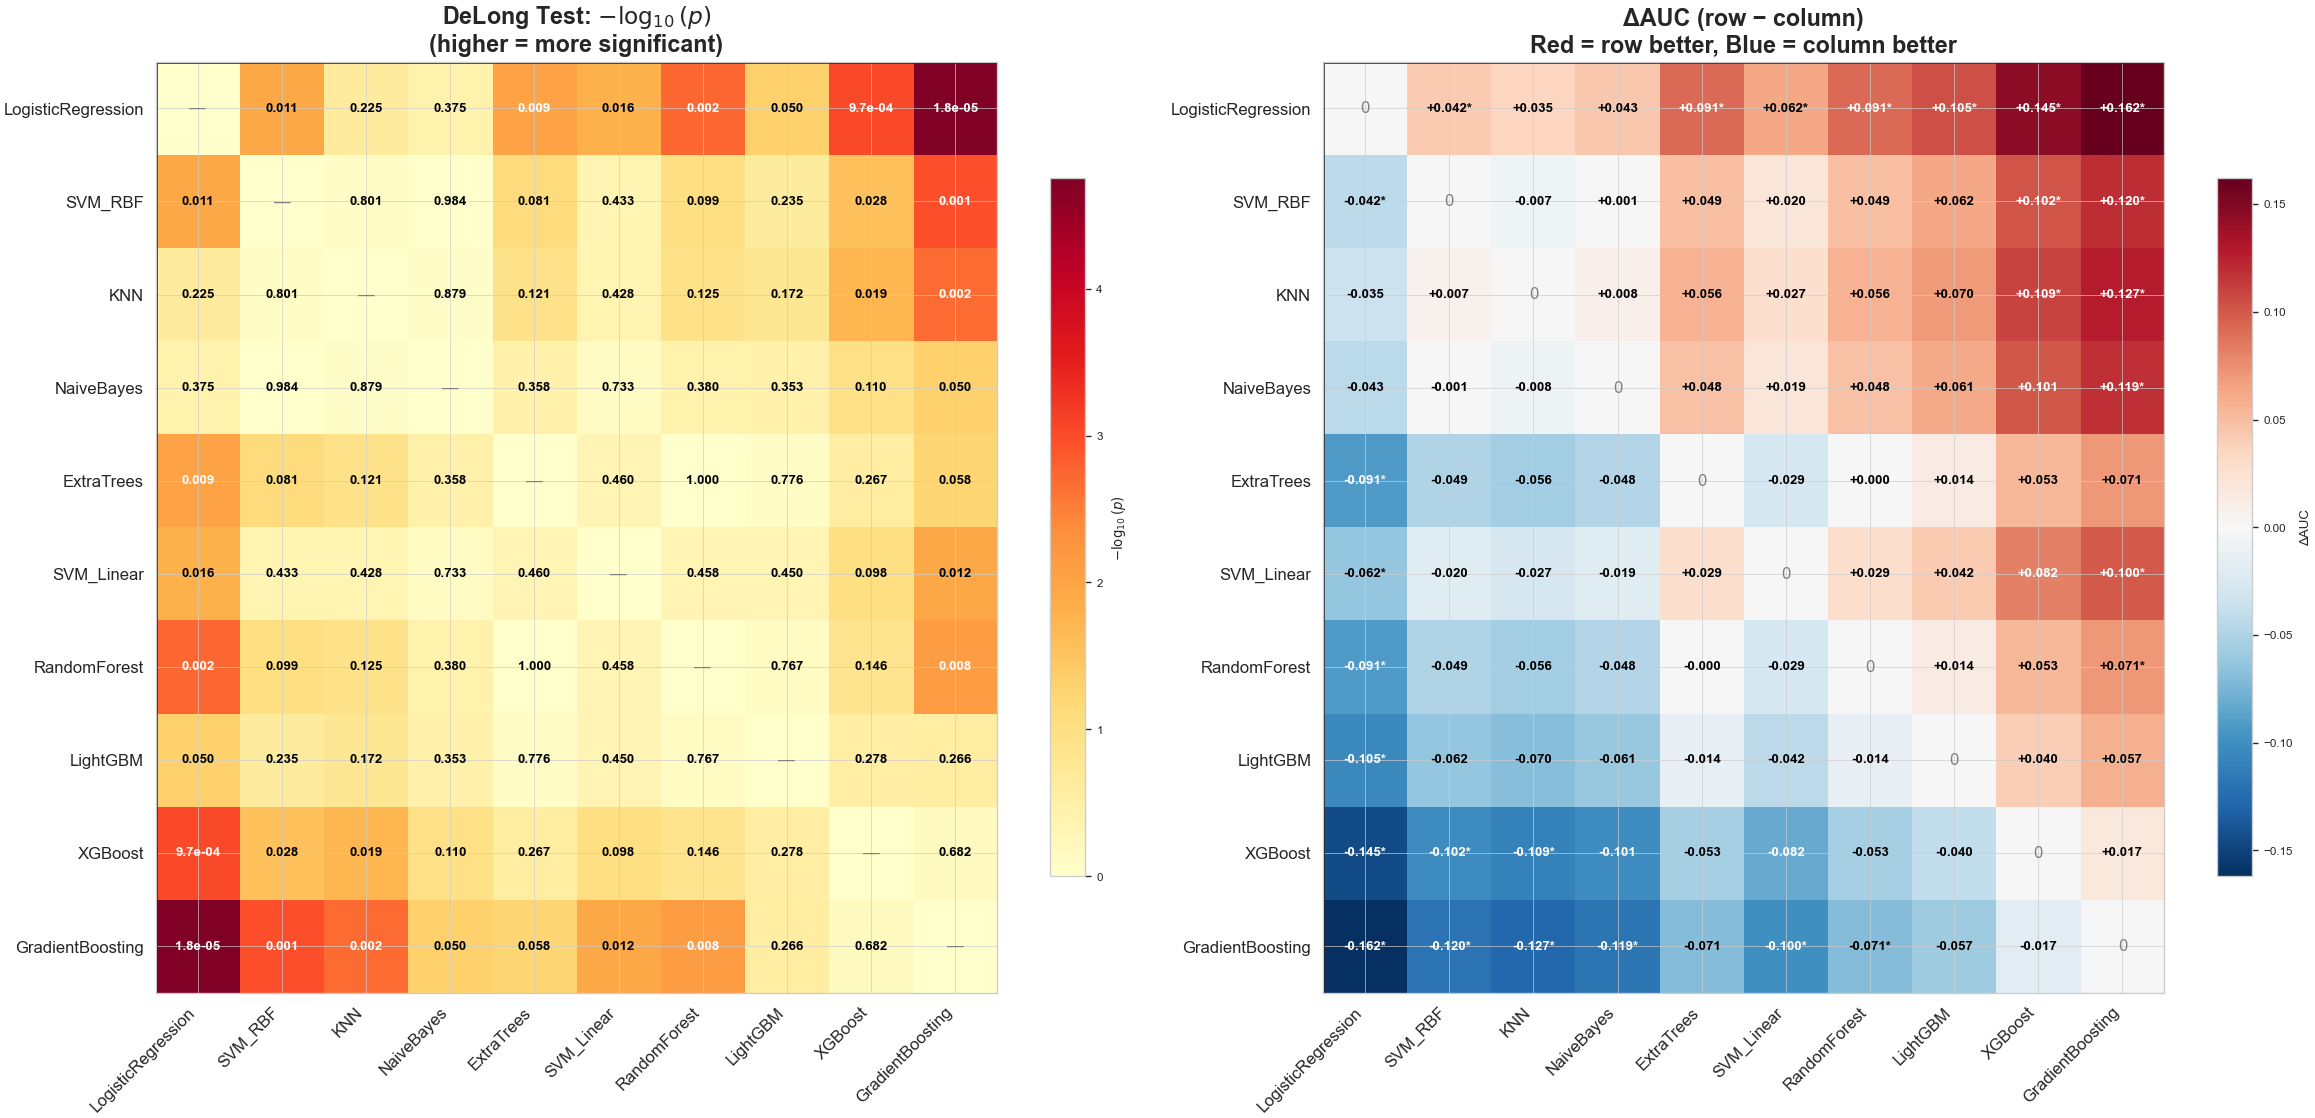


 🏆 Best Model (by Mean AUC): LogisticRegression  (Mean AUC = 0.7770)
 DeLong comparison vs. all other models (sorted by Mean ΔAUC):
      Competitor Competitor_Mean_AUC ΔMean_AUC  p_value p_Bonferroni Significant_uncorrected Significant_Bonferroni
GradientBoosting              0.6148   +0.1621 1.77e-05     7.97e-04                       ✓                      ✓
         XGBoost              0.6155   +0.1615 9.74e-04     4.38e-02                       ✓                      ✓
        LightGBM              0.6614   +0.1155 4.96e-02     1.00e+00                       ✓                      ✗
    RandomForest              0.6704   +0.1065 1.79e-03     8.06e-02                       ✓                      ✗
      SVM_Linear              0.6756   +0.1014 1.64e-02     7.39e-01                       ✓                      ✗
      ExtraTrees              0.6954   +0.0815 9.33e-03     4.20e-01                       ✓                      ✗
      NaiveBayes              0.7230   +0.0539 3.75e-01

In [55]:
# =============================================================================
# STATISTICAL INFERENCE VIA DELONG single ROC ANALYSIS
# =============================================================================
# Purpose:
#   - Implement vectorized, fast DeLong test computations for paired ROC curves.
#   - Execute exhaustive single model comparisons with family-wise error rate 
#     control via Bonferroni corrections.
#   - Generate publication-grade diagnostic heatmaps tracking p-values and delta AUCs.
#   - Benchmark the top-performing architecture against all remaining cohorts.
# =============================================================================

import os
import warnings
import itertools
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats

# Enforce strategic default persistence directories if missing from environment context
if 'SAVE_DIR' not in locals() and 'SAVE_DIR' not in globals():
    SAVE_DIR = CONFIG["DATASET_OUTPUT_ROOT"]

# -----------------------------------------------------------------------------
# 1. CORE MATH IMPLEMENTATIONS FOR FAST DELONG VECTORIZATION
# -----------------------------------------------------------------------------
def _compute_midrank(x):
    """Computes mathematical midranks for identical entry strings inside vectors."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        midrank = 0.5 * (i + j - 1)
        for k in range(i, j):
            T[k] = midrank
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2


def _fast_delong(predictions_sorted_transposed, label_1_count):
    """Vectorized algorithm mapping structurally unrolled variance-covariance arrays."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tz[r] = _compute_midrank(predictions_sorted_transposed[r])
        tx[r] = _compute_midrank(predictions_sorted_transposed[r, :m])
        ty[r] = _compute_midrank(predictions_sorted_transposed[r, m:])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01) if k > 1 else np.var(v01, ddof=1).reshape(1, 1)
    sy = np.cov(v10) if k > 1 else np.var(v10, ddof=1).reshape(1, 1)

    delongcov = sx / m + sy / n
    return aucs, delongcov


def delong_roc_test(y_true, y_prob_1, y_prob_2):
    """Executes the standard DeLong test to evaluate two correlated ROC curves.

    Args:
        y_true (np.ndarray): Target true classification outcomes.
        y_prob_1 (np.ndarray): Probability vectors produced by Model 1.
        y_prob_2 (np.ndarray): Probability vectors produced by Model 2.

    Returns:
        dict: Empirical metrics mapping standalone AUCs, Z-scores, and two-tailed p-values.
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob_1 = np.asarray(y_prob_1, dtype=np.float64)
    y_prob_2 = np.asarray(y_prob_2, dtype=np.float64)

    order = (-y_true).argsort()
    y_true_sorted = y_true[order]
    label_1_count = int(y_true_sorted.sum())

    predictions_sorted_transposed = np.vstack([
        y_prob_1[order],
        y_prob_2[order]
    ])

    aucs, delongcov = _fast_delong(predictions_sorted_transposed, label_1_count)

    diff = aucs[0] - aucs[1]
    var_diff = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]

    if var_diff <= 0:
        z_stat = 0.0
        p_value = 1.0
    else:
        z_stat = diff / np.sqrt(var_diff)
        p_value = 2.0 * stats.norm.sf(abs(z_stat))

    return {
        'auc1': aucs[0],
        'auc2': aucs[1],
        'z_stat': z_stat,
        'p_value': p_value,
    }


# -----------------------------------------------------------------------------
# 2. single MODEL MATRIX INFERENCE PROTOCOL
# -----------------------------------------------------------------------------
model_names = (
    df_summary.sort_values('Mean_AUC', ascending=False)['Model']
    .tolist()
)

n_models = len(model_names)

pvalue_matrix = pd.DataFrame(np.ones((n_models, n_models)), index=model_names, columns=model_names)
zstat_matrix = pd.DataFrame(np.zeros((n_models, n_models)), index=model_names, columns=model_names)

comparison_rows = []
ref_y_true = np.array(nested_cv_results[model_names[0]]['y_true'])

for i, j in itertools.combinations(range(n_models), 2):
    m1, m2 = model_names[i], model_names[j]

    y_true_1 = np.array(nested_cv_results[m1]['y_true'])
    y_true_2 = np.array(nested_cv_results[m2]['y_true'])
    y_prob_1 = np.array(nested_cv_results[m1]['y_prob'])
    y_prob_2 = np.array(nested_cv_results[m2]['y_prob'])

    assert np.array_equal(y_true_1, y_true_2), f"y_true mismatch between {m1} and {m2}!"

    result = delong_roc_test(y_true_1, y_prob_1, y_prob_2)

    pvalue_matrix.loc[m1, m2] = result['p_value']
    pvalue_matrix.loc[m2, m1] = result['p_value']
    zstat_matrix.loc[m1, m2] = result['z_stat']
    zstat_matrix.loc[m2, m1] = -result['z_stat']

    comparison_rows.append({
        'Model_A': m1,
        'Model_B': m2,
        'AUC_A': result['auc1'],
        'AUC_B': result['auc2'],
        'ΔAUC': result['auc1'] - result['auc2'],
        'Z_stat': result['z_stat'],
        'p_value': result['p_value'],
        'Significant (α=0.05)': '✓' if result['p_value'] < 0.05 else '✗',
        'Significant (α=0.01)': '✓' if result['p_value'] < 0.01 else '✗',
    })

df_delong = pd.DataFrame(comparison_rows)
df_delong = df_delong.sort_values('p_value').reset_index(drop=True)

# Enforce rigid Family-Wise Error Rate control using Bonferroni Adjustments
n_comparisons = len(comparison_rows)
df_delong['p_value_bonferroni'] = np.minimum(df_delong['p_value'] * n_comparisons, 1.0)
df_delong['Significant Bonf. (α=0.05)'] = df_delong['p_value_bonferroni'].apply(lambda p: '✓' if p < 0.05 else '✗')


# --- Display Tabular Outputs -------------------------------------------------
print("=" * 90)
print("  DeLong single AUC Comparison — All Model Pairs")
print("=" * 90)
df_display = df_delong.copy()
df_display['AUC_A'] = df_display['AUC_A'].map('{:.4f}'.format)
df_display['AUC_B'] = df_display['AUC_B'].map('{:.4f}'.format)
df_display['ΔAUC'] = df_display['ΔAUC'].map('{:+.4f}'.format)
df_display['Z_stat'] = df_display['Z_stat'].map('{:.3f}'.format)
df_display['p_value'] = df_display['p_value'].map('{:.2e}'.format)
df_display['p_value_bonferroni'] = df_display['p_value_bonferroni'].map('{:.2e}'.format)
print(df_display.to_string(index=False))

n_sig_005 = (df_delong['p_value'] < 0.05).sum()
n_sig_001 = (df_delong['p_value'] < 0.01).sum()
n_sig_bonf = (df_delong['p_value_bonferroni'] < 0.05).sum()

print(f"\n📊 Summary: {n_comparisons} single comparisons")
print(f"   • Significant at α=0.05:              {n_sig_005}/{n_comparisons}")
print(f"   • Significant at α=0.01:              {n_sig_001}/{n_comparisons}")
print(f"   • Significant after Bonferroni (0.05): {n_sig_bonf}/{n_comparisons}")


# -----------------------------------------------------------------------------
# 3. HIGH-RESOLUTION PRESENTATION HEATMAP GENERATION (DPI 900)
# -----------------------------------------------------------------------------
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    fig, axes = plt.subplots(1, 2, figsize=(20, 9.5))

    # --- Heatmap Panel A: -log10(p-value) Magnitude Mapping ---
    log_pval = -np.log10(pvalue_matrix.values.astype(float) + 1e-300)
    np.fill_diagonal(log_pval, 0)

    im1 = axes[0].imshow(log_pval, cmap='YlOrRd', aspect='auto')
    axes[0].set_xticks(range(n_models))
    axes[0].set_yticks(range(n_models))
    axes[0].set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    axes[0].set_yticklabels(model_names, fontsize=10)
    axes[0].set_title('DeLong Test: $-\\log_{10}(p)$\n(higher = more significant)', fontsize=14, fontweight='bold')

    for ii in range(n_models):
        for jj in range(n_models):
            if ii != jj:
                pval = pvalue_matrix.iloc[ii, jj]
                txt = f'{pval:.1e}' if pval < 0.001 else f'{pval:.3f}'
                color = 'white' if log_pval[ii, jj] > 2 else 'black'
                axes[0].text(jj, ii, txt, ha='center', va='center', fontsize=8, color=color, fontweight='bold')
            else:
                axes[0].text(jj, ii, '—', ha='center', va='center', fontsize=10, color='gray')

    fig.colorbar(im1, ax=axes[0], shrink=0.75, label='$-\\log_{10}(p)$')

    # --- Heatmap Panel B: Unrolled Delta AUC Directional Matrix ---
    auc_diff_matrix = pd.DataFrame(np.zeros((n_models, n_models)), index=model_names, columns=model_names)
    for _, row in df_delong.iterrows():
        m1, m2 = row['Model_A'], row['Model_B']
        d = float(row['ΔAUC'])
        auc_diff_matrix.loc[m1, m2] = d
        auc_diff_matrix.loc[m2, m1] = -d

    max_abs = max(abs(auc_diff_matrix.values.min()), abs(auc_diff_matrix.values.max()), 0.01)
    im2 = axes[1].imshow(auc_diff_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-max_abs, vmax=max_abs)
    axes[1].set_xticks(range(n_models))
    axes[1].set_yticks(range(n_models))
    axes[1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    axes[1].set_yticklabels(model_names, fontsize=10)
    axes[1].set_title('ΔAUC (row − column)\nRed = row better, Blue = column better', fontsize=14, fontweight='bold')

    for ii in range(n_models):
        for jj in range(n_models):
            if ii != jj:
                val = auc_diff_matrix.iloc[ii, jj]
                pval = pvalue_matrix.iloc[ii, jj]
                star = '*' if pval < 0.05 else ''
                txt = f'{val:+.3f}{star}'
                axes[1].text(jj, ii, txt, ha='center', va='center', fontsize=8,
                             color='white' if abs(val) > max_abs * 0.5 else 'black', fontweight='bold')
            else:
                axes[1].text(jj, ii, '0', ha='center', va='center', fontsize=10, color='gray')

    fig.colorbar(im2, ax=axes[1], shrink=0.75, label='ΔAUC')

    for ax in axes:
        ax.axhline(y=-0.5, color='black', linewidth=1.5)
        ax.axvline(x=-0.5, color='black', linewidth=1.5)

    plt.tight_layout()
    
    os.makedirs(SAVE_DIR, exist_ok=True)
    heatmap_save_path = os.path.join(SAVE_DIR, 'delong_single_heatmap.png')
    plt.savefig(heatmap_save_path, dpi=600, bbox_inches='tight')
    print(f"\n💾 High-resolution heatmap (DPI 900) saved to: {heatmap_save_path}")
    plt.show()
    plt.close()

except ImportError:
    print("\n⚠️ matplotlib not available — skipping heatmap visualisation.")


# -----------------------------------------------------------------------------
# 4. CRITICAL CHRONOLOGICAL ANALYSIS: CHOSEN CHAMPION VS INDEPENDENT COHORTS
# -----------------------------------------------------------------------------
mean_aucs = {}
for mn in model_names:
    try:
        # Compute baseline criteria mapping directly on Cross-Validation Fold means
        mean_aucs[mn] = np.mean(nested_cv_results[mn]['fold_aucs'])
    except Exception:
        mean_aucs[mn] = 0.5

# Extract optimal model design index relying exclusively on structural Mean AUC performance
best_model = df_summary.sort_values('Mean_AUC', ascending=False).iloc[0]['Model']
best_auc = mean_aucs[best_model]

print(f"\n{'=' * 70}")
print(f" 🏆 Best Model (by Mean AUC): {best_model}  (Mean AUC = {best_auc:.4f})")
print(f" DeLong comparison vs. all other models (sorted by Mean ΔAUC):")
print(f"{'=' * 70}")



best_vs_rest = []
for mn in model_names:
    if mn == best_model:
        continue
    
    # Query paired historical database rows matching target experimental configurations
    row_data = df_delong[
        ((df_delong['Model_A'] == best_model) & (df_delong['Model_B'] == mn)) |
        ((df_delong['Model_A'] == mn) & (df_delong['Model_B'] == best_model))
    ]
    
    if len(row_data) > 0:
        row = row_data.iloc[0]
        p_val = row['p_value']
        p_bonf = row['p_value_bonferroni']
    else:
        p_val, p_bonf = 1.0, 1.0

    # Calculate absolute delta values using standalone Mean AUC frame locations
    delta = best_auc - mean_aucs[mn]
    
    best_vs_rest.append({
        'Competitor': mn,
        'Competitor_Mean_AUC': mean_aucs[mn],
        'ΔMean_AUC': delta,
        'p_value': p_val,
        'p_Bonferroni': p_bonf,
        'Significant_uncorrected': '✓' if p_val < 0.05 else '✗',
        'Significant_Bonferroni': '✓' if p_bonf < 0.05 else '✗',
    })

# Format and rank baseline comparisons sequentially from largest to minimal delta deviations
df_best_vs_rest = pd.DataFrame(best_vs_rest).sort_values('ΔMean_AUC', ascending=False).reset_index(drop=True)
df_best_vs_rest['Competitor_Mean_AUC'] = df_best_vs_rest['Competitor_Mean_AUC'].map('{:.4f}'.format)
df_best_vs_rest['ΔMean_AUC'] = df_best_vs_rest['ΔMean_AUC'].map('{:+.4f}'.format)
df_best_vs_rest['p_value'] = df_best_vs_rest['p_value'].map('{:.2e}'.format)
df_best_vs_rest['p_Bonferroni'] = df_best_vs_rest['p_Bonferroni'].map('{:.2e}'.format)



df_delong.to_csv(os.path.join(SAVE_DIR, 'df_delong_single.csv'), index=False)
pvalue_matrix.to_csv(os.path.join(SAVE_DIR, 'delong_pvalue_matrix.csv'))
zstat_matrix.to_csv(os.path.join(SAVE_DIR, 'delong_zstat_matrix.csv'))
df_best_vs_rest.to_csv(os.path.join(SAVE_DIR, 'delong_best_vs_rest.csv'), index=False)



print(df_best_vs_rest.to_string(index=False))
print("\n✅ DeLong analysis complete.")

In [56]:
    # =============================================================================
    # STEP 4C — LASSO-ONLY VS BASELINE STATISTICAL COMPARISON
    # =============================================================================
    # Purpose:
    #   - Compare LASSO-only FS against the Step 2 baseline.
    #   - Keep analysis compact and manuscript-style.
    #   - Generate non-redundant plots:
    #       1) ROC-AUC delta by model
    #       2) Best ROC curves
    #       3) Fold-wise AUC paired change
    #       4) LASSO feature-selection stability
    #       5) Metric trade-off for best changed model
    # =============================================================================


current_fs_method = CONFIG.get("FS_METHOD", None)

if current_fs_method != "lasso_only":
    print("█" * 80)
    print("  STEP 4C — SKIPPED")
    print("█" * 80)
    print("This cell is only for FS_METHOD='lasso_only'.")
    print(f"Current FS_METHOD is: {current_fs_method}")
    print("No LASSO-vs-baseline comparison was executed.")

else:
    print("█" * 80)
    print("  STEP 4C — LASSO-ONLY VS BASELINE COMPARISON")
    print("█" * 80)
    

    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_2_baseline_nested_cv_no_smote"
    )

    lasso_dir = CONFIG.get(
        "SAVE_DIR",
        os.path.join("./nested_cv_outputs", "step_4_lasso_only_fs_nested_cv_no_smote")
    )

    comparison_dir = os.path.join(lasso_dir, "step_4c_lasso_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)


    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    # -----------------------------------------------------------------------------
    # Guard: Baseline comparison is optional and requires a previous baseline run
    # -----------------------------------------------------------------------------
    if not os.path.exists(baseline_pkl_path):
        print("=" * 90)
        print("  BASELINE COMPARISON — SKIPPED")
        print("=" * 90)
        print(f"Baseline results were not found:\n{baseline_pkl_path}")
        print("This is expected when running only the final locked model.")
        print("For the final manuscript model, this comparison cell is optional.")
        
        df_baseline_comparison = pd.DataFrame()
    else:
        print(f"Baseline results found:\n{baseline_pkl_path}")


        if "nested_cv_results" not in globals():
            raise RuntimeError("Current LASSO nested_cv_results not found. Run Cell 13 after Step 4B.")

        with open(baseline_pkl_path, "rb") as f:
            baseline_results = pickle.load(f)

        lasso_results = nested_cv_results

        print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
        print(f"Using current LASSO results from:\n  {lasso_dir}")

        # -----------------------------------------------------------------------------
        # 2. Publication-style plotting theme
        # -----------------------------------------------------------------------------
        plt.style.use("default")

        FIG_DPI = 600

        COLORS = {
            "baseline": "#4C78A8",
            "lasso": "#2A9D8F",
            "delta_pos": "#2A9D8F",
            "delta_neg": "#B23A48",
            "dark": "#2F3E46",
            "neutral": "#6C757D",
            "grid": "#D9DEE3"
        }

        plt.rcParams.update({
            "figure.dpi": 120,
            "savefig.dpi": FIG_DPI,
            "font.family": "DejaVu Sans",
            "font.size": 8,
            "axes.titlesize": 9,
            "axes.labelsize": 8,
            "xtick.labelsize": 7,
            "ytick.labelsize": 7,
            "legend.fontsize": 7,
            "axes.linewidth": 0.8,
            "axes.edgecolor": "#333333",
            "axes.grid": True,
            "grid.color": COLORS["grid"],
            "grid.linewidth": 0.5,
            "grid.alpha": 0.8,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.03,
            "pdf.fonttype": 42,
            "ps.fonttype": 42
        })


        def clean_axis(ax, grid_axis="y"):
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
            ax.set_axisbelow(True)


        def save_figure(fig, filename_base):
            png_path = os.path.join(plot_dir, f"{filename_base}.png")
            pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
            fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
            fig.savefig(pdf_path, bbox_inches="tight")
            print(f"Saved: {png_path}")
            print(f"Saved: {pdf_path}")


        def compute_specificity(y_true, y_pred):
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            if cm.shape != (2, 2):
                return np.nan
            tn, fp, fn, tp = cm.ravel()
            return tn / (tn + fp) if (tn + fp) > 0 else np.nan


        def compute_npv(y_true, y_pred):
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            if cm.shape != (2, 2):
                return np.nan
            tn, fp, fn, tp = cm.ravel()
            return tn / (tn + fn) if (tn + fn) > 0 else np.nan


        def benjamini_hochberg(p_values):
            p_values = np.asarray(p_values, dtype=float)
            q_values = np.full(len(p_values), np.nan)

            valid = np.isfinite(p_values)
            p = p_values[valid]

            if len(p) == 0:
                return q_values

            order = np.argsort(p)
            ranked = p[order]
            adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
            adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
            adjusted = np.clip(adjusted, 0, 1)

            q_valid = np.empty_like(p)
            q_valid[order] = adjusted
            q_values[valid] = q_valid

            return q_values


        def pooled_metrics_from_results(results_dict):
            rows = []

            for model_name, res in results_dict.items():
                y_true = np.asarray(res["y_true"], dtype=int)
                y_prob = np.asarray(res["y_prob"], dtype=float)
                y_pred = np.asarray(res["y_pred"], dtype=int)

                rows.append({
                    "Model": model_name,
                    "ROC_AUC": roc_auc_score(y_true, y_prob),
                    "PR_AUC": average_precision_score(y_true, y_prob),
                    "Accuracy": accuracy_score(y_true, y_pred),
                    "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                    "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                    "Specificity": compute_specificity(y_true, y_pred),
                    "PPV": precision_score(y_true, y_pred, zero_division=0),
                    "NPV": compute_npv(y_true, y_pred),
                    "F1": f1_score(y_true, y_pred, zero_division=0),
                    "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                    "Brier_Score": brier_score_loss(y_true, y_prob),
                    "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                    "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
                })

            return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


        def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
            """
            Paired bootstrap CI for delta = metric_b - metric_a.
            Here:
                a = baseline
                b = LASSO
            """
            rng = np.random.default_rng(seed)

            y_true = np.asarray(y_true, dtype=int)
            prob_a = np.asarray(prob_a, dtype=float)
            prob_b = np.asarray(prob_b, dtype=float)

            n = len(y_true)
            deltas = []

            for _ in range(n_boot):
                idx = rng.integers(0, n, n)

                if len(np.unique(y_true[idx])) < 2:
                    continue

                try:
                    val_a = metric_func(y_true[idx], prob_a[idx])
                    val_b = metric_func(y_true[idx], prob_b[idx])
                    deltas.append(val_b - val_a)
                except Exception:
                    continue

            if len(deltas) == 0:
                return np.nan, np.nan, np.nan

            deltas = np.asarray(deltas, dtype=float)

            return (
                float(np.nanmean(deltas)),
                float(np.nanpercentile(deltas, 2.5)),
                float(np.nanpercentile(deltas, 97.5))
            )


        # -----------------------------------------------------------------------------
        # 3. Compute metrics
        # -----------------------------------------------------------------------------
        baseline_metrics_df = pooled_metrics_from_results(baseline_results)
        lasso_metrics_df = pooled_metrics_from_results(lasso_results)

        baseline_metrics_df.to_csv(
            os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
            index=False
        )

        lasso_metrics_df.to_csv(
            os.path.join(comparison_dir, "lasso_only_pooled_metrics.csv"),
            index=False
        )

        common_models = sorted(set(baseline_metrics_df["Model"]).intersection(lasso_metrics_df["Model"]))

        comparison_rows = []

        for model_name in common_models:
            b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
            l_row = lasso_metrics_df[lasso_metrics_df["Model"] == model_name].iloc[0]

            b_res = baseline_results[model_name]
            l_res = lasso_results[model_name]

            b_y_true = np.asarray(b_res["y_true"], dtype=int)
            l_y_true = np.asarray(l_res["y_true"], dtype=int)

            same_oof_order = (
                len(b_y_true) == len(l_y_true)
                and np.array_equal(b_y_true, l_y_true)
            )

            if same_oof_order:
                auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                    b_y_true,
                    np.asarray(b_res["y_prob"], dtype=float),
                    np.asarray(l_res["y_prob"], dtype=float),
                    roc_auc_score,
                    n_boot=2000,
                    seed=CONFIG.get("RANDOM_STATE", 100)
                )

                pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                    b_y_true,
                    np.asarray(b_res["y_prob"], dtype=float),
                    np.asarray(l_res["y_prob"], dtype=float),
                    average_precision_score,
                    n_boot=2000,
                    seed=CONFIG.get("RANDOM_STATE", 100) + 1
                )
            else:
                auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
                pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

            b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
            l_fold_auc = np.asarray(l_res["fold_aucs"], dtype=float)

            if len(b_fold_auc) == len(l_fold_auc) and len(b_fold_auc) >= 2:
                try:
                    w_stat, w_p = wilcoxon(
                        l_fold_auc,
                        b_fold_auc,
                        alternative="two-sided",
                        zero_method="wilcox"
                    )
                except Exception:
                    w_stat, w_p = np.nan, np.nan
            else:
                w_stat, w_p = np.nan, np.nan

            comparison_rows.append({
                "Model": model_name,

                "Baseline_ROC_AUC": b_row["ROC_AUC"],
                "LASSO_ROC_AUC": l_row["ROC_AUC"],
                "Delta_ROC_AUC_LASSO_minus_Baseline": l_row["ROC_AUC"] - b_row["ROC_AUC"],
                "Paired_Bootstrap_Delta_ROC_AUC_Mean": auc_delta_mean,
                "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
                "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

                "Baseline_PR_AUC": b_row["PR_AUC"],
                "LASSO_PR_AUC": l_row["PR_AUC"],
                "Delta_PR_AUC_LASSO_minus_Baseline": l_row["PR_AUC"] - b_row["PR_AUC"],
                "Paired_Bootstrap_Delta_PR_AUC_Mean": pr_delta_mean,
                "Paired_Bootstrap_Delta_PR_AUC_CI95_Low": pr_delta_low,
                "Paired_Bootstrap_Delta_PR_AUC_CI95_High": pr_delta_high,

                "Baseline_Balanced_Accuracy": b_row["Balanced_Accuracy"],
                "LASSO_Balanced_Accuracy": l_row["Balanced_Accuracy"],
                "Delta_Balanced_Accuracy": l_row["Balanced_Accuracy"] - b_row["Balanced_Accuracy"],

                "Baseline_Sensitivity": b_row["Sensitivity"],
                "LASSO_Sensitivity": l_row["Sensitivity"],
                "Delta_Sensitivity": l_row["Sensitivity"] - b_row["Sensitivity"],

                "Baseline_Specificity": b_row["Specificity"],
                "LASSO_Specificity": l_row["Specificity"],
                "Delta_Specificity": l_row["Specificity"] - b_row["Specificity"],

                "Baseline_PPV": b_row["PPV"],
                "LASSO_PPV": l_row["PPV"],
                "Delta_PPV": l_row["PPV"] - b_row["PPV"],

                "Baseline_NPV": b_row["NPV"],
                "LASSO_NPV": l_row["NPV"],
                "Delta_NPV": l_row["NPV"] - b_row["NPV"],

                "Baseline_Kappa": b_row["Cohen_Kappa"],
                "LASSO_Kappa": l_row["Cohen_Kappa"],
                "Delta_Kappa": l_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

                "Baseline_Brier": b_row["Brier_Score"],
                "LASSO_Brier": l_row["Brier_Score"],
                "Delta_Brier_LASSO_minus_Baseline": l_row["Brier_Score"] - b_row["Brier_Score"],

                "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
                "LASSO_Mean_Selected_Features": l_row["Mean_Selected_Features"],

                "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
                "Foldwise_Wilcoxon_AUC_p_value": w_p,
                "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
            })

        comparison_df = pd.DataFrame(comparison_rows)

        comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
            comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
        )

        comparison_df = comparison_df.sort_values(
            "Delta_ROC_AUC_LASSO_minus_Baseline",
            ascending=False
        ).reset_index(drop=True)

        comparison_df.to_csv(
            os.path.join(comparison_dir, "lasso_only_vs_baseline_model_comparison.csv"),
            index=False
        )

        print("\n" + "═" * 80)
        print("LASSO-ONLY VS BASELINE — MODEL COMPARISON")
        print("═" * 80)

        display_cols = [
            "Model",
            "Baseline_ROC_AUC",
            "LASSO_ROC_AUC",
            "Delta_ROC_AUC_LASSO_minus_Baseline",
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
            "Baseline_PR_AUC",
            "LASSO_PR_AUC",
            "Delta_PR_AUC_LASSO_minus_Baseline",
            "Baseline_Sensitivity",
            "LASSO_Sensitivity",
            "Delta_Sensitivity",
            "Baseline_Specificity",
            "LASSO_Specificity",
            "Delta_Specificity",
            "Foldwise_Wilcoxon_AUC_p_value",
            "Foldwise_Wilcoxon_AUC_q_value_FDR"
        ]

        print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

        best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
        best_lasso_model = lasso_metrics_df.iloc[0]["Model"]
        best_delta_model = comparison_df.iloc[0]["Model"]

        print("\nBest baseline model:", best_baseline_model)
        print("Best LASSO model:   ", best_lasso_model)
        print("Largest ROC-AUC gain with LASSO:", best_delta_model)

        # -----------------------------------------------------------------------------
        # 4. Figure 1 — ROC-AUC delta by model
        # -----------------------------------------------------------------------------
        delta_plot = comparison_df.sort_values(
            "Delta_ROC_AUC_LASSO_minus_Baseline",
            ascending=True
        )

        fig, ax = plt.subplots(figsize=(4.8, 3.0))

        bar_colors = [
            COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
            for v in delta_plot["Delta_ROC_AUC_LASSO_minus_Baseline"]
        ]

        ax.barh(
            delta_plot["Model"],
            delta_plot["Delta_ROC_AUC_LASSO_minus_Baseline"],
            color=bar_colors,
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.axvline(0, color="#222222", linewidth=0.8)
        ax.set_title("Effect of LASSO Feature Selection")
        ax.set_xlabel("Δ ROC-AUC: LASSO − Baseline")
        ax.set_ylabel("")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig01_lasso_delta_roc_auc_by_model")
        plt.show()

        # -----------------------------------------------------------------------------
        # 5. Figure 2 — Best ROC curves
        # -----------------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(3.8, 3.4))

        b_res = baseline_results[best_baseline_model]
        l_res = lasso_results[best_lasso_model]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

        l_y_true = np.asarray(l_res["y_true"], dtype=int)
        l_y_prob = np.asarray(l_res["y_prob"], dtype=float)

        b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
        l_fpr, l_tpr, _ = roc_curve(l_y_true, l_y_prob)

        b_auc = roc_auc_score(b_y_true, b_y_prob)
        l_auc = roc_auc_score(l_y_true, l_y_prob)

        ax.plot(
            b_fpr,
            b_tpr,
            linewidth=1.4,
            color=COLORS["baseline"],
            label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
        )

        ax.plot(
            l_fpr,
            l_tpr,
            linewidth=1.4,
            color=COLORS["lasso"],
            label=f"LASSO: {best_lasso_model} ({l_auc:.2f})"
        )

        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

        ax.set_title("Best ROC Curves")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(frameon=False, loc="lower right")
        clean_axis(ax, grid_axis="both")

        plt.tight_layout()
        save_figure(fig, "fig02_best_baseline_vs_lasso_roc_curves")
        plt.show()

        # -----------------------------------------------------------------------------
        # 6. Figure 3 — Fold-wise AUC paired change for best delta model
        # -----------------------------------------------------------------------------
        b_fold_auc = np.asarray(baseline_results[best_delta_model]["fold_aucs"], dtype=float)
        l_fold_auc = np.asarray(lasso_results[best_delta_model]["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(l_fold_auc):
            fig, ax = plt.subplots(figsize=(3.8, 2.8))

            for i in range(len(b_fold_auc)):
                ax.plot(
                    [0, 1],
                    [b_fold_auc[i], l_fold_auc[i]],
                    marker="o",
                    linewidth=0.9,
                    color=COLORS["neutral"],
                    alpha=0.8
                )

            ax.scatter(
                np.zeros_like(b_fold_auc),
                b_fold_auc,
                color=COLORS["baseline"],
                edgecolor="#222222",
                linewidth=0.4,
                zorder=3,
                label="Baseline"
            )

            ax.scatter(
                np.ones_like(l_fold_auc),
                l_fold_auc,
                color=COLORS["lasso"],
                edgecolor="#222222",
                linewidth=0.4,
                zorder=3,
                label="LASSO"
            )

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["Baseline", "LASSO"])
            ax.set_ylim(0, 1)
            ax.set_title(f"Outer-fold ROC-AUC Change — {best_delta_model}")
            ax.set_ylabel("Fold ROC-AUC")
            ax.legend(frameon=False, loc="best")
            clean_axis(ax)

            plt.tight_layout()
            save_figure(fig, "fig03_outer_fold_auc_paired_change_lasso")
            plt.show()

        # -----------------------------------------------------------------------------
        # 7. Figure 4 — LASSO feature selection stability
        # -----------------------------------------------------------------------------
        lasso_features_path = os.path.join(lasso_dir, "df_selected_features_long.csv")

        if os.path.exists(lasso_features_path):
            lasso_feat = pd.read_csv(lasso_features_path)

            lasso_stability = (
                lasso_feat
                .groupby("Feature_Name")
                .size()
                .reset_index(name="Selection_Count")
                .sort_values("Selection_Count", ascending=False)
            )

            lasso_stability["Selection_Frequency"] = (
                lasso_stability["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
            )

            lasso_stability.to_csv(
                os.path.join(comparison_dir, "lasso_feature_selection_stability.csv"),
                index=False
            )

            top_lasso_stable = lasso_stability.head(12).iloc[::-1]

            fig, ax = plt.subplots(figsize=(4.8, 3.3))

            ax.barh(
                top_lasso_stable["Feature_Name"],
                top_lasso_stable["Selection_Frequency"],
                color=COLORS["lasso"],
                edgecolor="#222222",
                linewidth=0.5
            )

            ax.set_xlim(0, 1)
            ax.set_title("LASSO Feature Stability")
            ax.set_xlabel("Selection frequency across outer folds")
            ax.set_ylabel("")
            clean_axis(ax)

            plt.tight_layout()
            save_figure(fig, "fig04_lasso_feature_selection_stability")
            plt.show()
        else:
            lasso_stability = pd.DataFrame()
            print("\nLASSO selected-feature file not found; stability plot skipped.")

        # -----------------------------------------------------------------------------
        # 8. Feature overlap: Baseline vs LASSO
        # -----------------------------------------------------------------------------
        baseline_features_path = os.path.join(baseline_dir, "df_selected_features_long.csv")

        overlap_summary = {}

        if os.path.exists(baseline_features_path) and os.path.exists(lasso_features_path):
            b_feat = pd.read_csv(baseline_features_path)
            l_feat = pd.read_csv(lasso_features_path)

            b_set = set(b_feat["Feature_Name"].unique())
            l_set = set(l_feat["Feature_Name"].unique())

            intersection = b_set.intersection(l_set)
            union = b_set.union(l_set)

            jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan

            overlap_summary = {
                "baseline_unique_features": int(len(b_set)),
                "lasso_unique_features": int(len(l_set)),
                "shared_features": int(len(intersection)),
                "union_features": int(len(union)),
                "jaccard_overlap": float(jaccard)
            }

            pd.DataFrame([overlap_summary]).to_csv(
                os.path.join(comparison_dir, "baseline_vs_lasso_feature_overlap.csv"),
                index=False
            )

            print("\n" + "═" * 80)
            print("FEATURE OVERLAP SUMMARY")
            print("═" * 80)
            for k, v in overlap_summary.items():
                print(f"{k}: {v}")

        # -----------------------------------------------------------------------------
        # 9. Figure 5 — Metric trade-off for best delta model
        # -----------------------------------------------------------------------------
        trade_model = best_delta_model
        trade_row = comparison_df[comparison_df["Model"] == trade_model].iloc[0]

        trade_df = pd.DataFrame({
            "Metric": ["Sensitivity", "Specificity", "PPV", "NPV", "Kappa"],
            "Baseline": [
                trade_row["Baseline_Sensitivity"],
                trade_row["Baseline_Specificity"],
                trade_row["Baseline_PPV"],
                trade_row["Baseline_NPV"],
                trade_row["Baseline_Kappa"]
            ],
            "LASSO": [
                trade_row["LASSO_Sensitivity"],
                trade_row["LASSO_Specificity"],
                trade_row["LASSO_PPV"],
                trade_row["LASSO_NPV"],
                trade_row["LASSO_Kappa"]
            ]
        })

        trade_df.to_csv(
            os.path.join(comparison_dir, "best_delta_model_lasso_metric_tradeoff.csv"),
            index=False
        )

        x = np.arange(len(trade_df))
        width = 0.36

        fig, ax = plt.subplots(figsize=(4.8, 2.9))

        ax.bar(
            x - width / 2,
            trade_df["Baseline"],
            width,
            label="Baseline",
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.bar(
            x + width / 2,
            trade_df["LASSO"],
            width,
            label="LASSO",
            color=COLORS["lasso"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_ylim(0, 1)
        ax.set_title(f"Metric Trade-off — {trade_model}")
        ax.set_ylabel("Score")
        ax.set_xticks(x)
        ax.set_xticklabels(trade_df["Metric"], rotation=30, ha="right")
        ax.legend(frameon=False)
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig05_lasso_metric_tradeoff_best_delta_model")
        plt.show()

        # -----------------------------------------------------------------------------
        # 10. Decision table
        # -----------------------------------------------------------------------------
        decision_rows = []

        for _, row in comparison_df.iterrows():
            auc_delta = row["Delta_ROC_AUC_LASSO_minus_Baseline"]
            pr_delta = row["Delta_PR_AUC_LASSO_minus_Baseline"]
            sens_delta = row["Delta_Sensitivity"]
            spec_delta = row["Delta_Specificity"]
            brier_delta = row["Delta_Brier_LASSO_minus_Baseline"]

            if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
                recommendation = "LASSO favorable"
            elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
                recommendation = "LASSO improves sensitivity but reduces specificity"
            elif auc_delta <= 0 and pr_delta <= 0:
                recommendation = "Baseline preferred"
            else:
                recommendation = "Mixed effect"

            decision_rows.append({
                "Model": row["Model"],
                "Delta_ROC_AUC": auc_delta,
                "Delta_PR_AUC": pr_delta,
                "Delta_Sensitivity": sens_delta,
                "Delta_Specificity": spec_delta,
                "Delta_Brier": brier_delta,
                "Recommendation": recommendation
            })

        lasso_decision_df = pd.DataFrame(decision_rows).sort_values(
            "Delta_ROC_AUC",
            ascending=False
        )

        lasso_decision_df.to_csv(
            os.path.join(comparison_dir, "lasso_ablation_decision_table.csv"),
            index=False
        )

        print("\n" + "═" * 80)
        print("LASSO ABLATION DECISION TABLE")
        print("═" * 80)
        print(lasso_decision_df.to_string(index=False, float_format="%.4f"))

        # -----------------------------------------------------------------------------
        # 11. Compact summary JSON
        # -----------------------------------------------------------------------------
        step_4c_summary = {
            "run_name": CONFIG.get("RUN_NAME", "step_4_lasso_only_fs_nested_cv_no_smote"),
            "baseline_dir": baseline_dir,
            "lasso_dir": lasso_dir,
            "comparison_dir": comparison_dir,
            "best_baseline_model_by_roc_auc": best_baseline_model,
            "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
            "best_lasso_model_by_roc_auc": best_lasso_model,
            "best_lasso_roc_auc": float(lasso_metrics_df.iloc[0]["ROC_AUC"]),
            "largest_auc_gain_model": best_delta_model,
            "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_LASSO_minus_Baseline"]),
            "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
            "fs_method": CONFIG.get("FS_METHOD", None),
            "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
            "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
            "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
            "n_models_compared": int(len(common_models)),
            "feature_overlap_summary": overlap_summary
        }

        with open(os.path.join(comparison_dir, "step_4c_summary.json"), "w") as f:
            json.dump(step_4c_summary, f, indent=4)

        print("\n" + "═" * 80)
        print("STEP 4C SUMMARY")
        print("═" * 80)

        for k, v in step_4c_summary.items():
            print(f"{k}: {v}")

        print("\nSaved LASSO comparison reports and figures to:")
        print(f"  {comparison_dir}")
        print(f"  {plot_dir}")

        print("\n✅ STEP 4C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 4C — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for FS_METHOD='lasso_only'.
Current FS_METHOD is: elasticnet_then_mrmr
No LASSO-vs-baseline comparison was executed.


In [57]:
# OLD ABLATION CELL — RFE ONLY — DO NOT RUN FOR FINAL MODEL
# =============================================================================
# STEP 5B — RFE-ONLY FEATURE SELECTION CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run a controlled RFE-only feature selection ablation.
#   - Keep SMOTE disabled to isolate the effect of feature selection.
# =============================================================================

print("█" * 80)
print("  STEP 5B — RFE-ONLY CONFIGURATION LOCK")
print("█" * 80)


target_fs_method = globals().get("TARGET_FS_METHOD", None)

if target_fs_method != "rfe_only":
    print("STEP 5B — SKIPPED")
    print("No RFE configuration was applied.")
else:
    CONFIG["RUN_NAME"] = "step_5_rfe_only_fs_nested_cv_no_smote"
    CONFIG["SAVE_DIR"] = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        CONFIG["RUN_NAME"]
    )
    # CONFIG["USE_SMOTE"] = True
    CONFIG["FS_METHOD"] = "rfe_only"
    CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 14)
    SAVE_DIR = CONFIG["SAVE_DIR"]
        
    import os
    import json

    os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

    # Isolate feature-selection effect
    # CONFIG["USE_SMOTE"] = False

    # CONFIG["FS_METHOD"] = "rfe_only"

    # Keep same feature count as baseline/LASSO
    CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

    # RFE-specific settings
    CONFIG["RFE_STEP"] = 0.10
    CONFIG["RFE_C"] = 1.0

    # Keep nested CV fixed
    CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
    CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
    CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

    rfe_config_snapshot = {
        "RUN_NAME": CONFIG["RUN_NAME"],
        "SAVE_DIR": CONFIG["SAVE_DIR"],
        "USE_SMOTE": CONFIG["USE_SMOTE"],
        "FS_METHOD": CONFIG["FS_METHOD"],
        "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
        "RFE_STEP": CONFIG["RFE_STEP"],
        "RFE_C": CONFIG["RFE_C"],
        "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
        "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
        "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
        "RANDOM_STATE": CONFIG["RANDOM_STATE"],
        "N_SAMPLES": int(X.shape[0]),
        "N_FEATURES": int(X.shape[1]),
        "N_PATIENTS": int(len(set(groups)))
    }

    with open(os.path.join(CONFIG["SAVE_DIR"], "rfe_only_config_snapshot.json"), "w") as f:
        json.dump(rfe_config_snapshot, f, indent=4)

    print("\nRFE-only configuration:")
    for k, v in rfe_config_snapshot.items():
        print(f"  {k}: {v}")

    print("\n✅ STEP 5B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 5B — RFE-ONLY CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████
STEP 5B — SKIPPED
No RFE configuration was applied.


In [58]:
    # =============================================================================
    # STEP 5C — RFE-ONLY VS BASELINE STATISTICAL COMPARISON
    # =============================================================================
    # Purpose:
    #   - Compare RFE-only FS against Step 2 baseline.
    #   - Use compact non-redundant manuscript-style figures.
    # =============================================================================
current_fs_method = CONFIG.get("FS_METHOD", None)

if current_fs_method != "rfe_only":
    print("█" * 80)
    print("  STEP 5C — SKIPPED")
    print("█" * 80)
    print("This cell is only for FS_METHOD='rfe_only'.")
    print(f"Current FS_METHOD is: {current_fs_method}")
    print("No RFE-vs-baseline comparison was executed.")

else:
    print("█" * 80)
    print("  STEP 5C — RFE-ONLY VS BASELINE COMPARISON")
    print("█" * 80)


    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_2_baseline_nested_cv_no_smote"
    )

    rfe_dir = CONFIG.get(
        "SAVE_DIR",
        os.path.join("./nested_cv_outputs", "step_5_rfe_only_fs_nested_cv_no_smote")
    )

    comparison_dir = os.path.join(rfe_dir, "step_5c_rfe_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    if not os.path.exists(baseline_pkl_path):
        raise FileNotFoundError(
            f"Baseline results not found:\n{baseline_pkl_path}\n"
            "Run Step 2 baseline first."
        )

    if "nested_cv_results" not in globals():
        raise RuntimeError("Current RFE nested_cv_results not found. Run Cell 13 after Step 5B.")

    with open(baseline_pkl_path, "rb") as f:
        baseline_results = pickle.load(f)

    rfe_results = nested_cv_results

    print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
    print(f"Using current RFE results from:\n  {rfe_dir}")

    # -----------------------------------------------------------------------------
    # 2. Publication-style plotting theme
    # -----------------------------------------------------------------------------
    plt.style.use("default")

    FIG_DPI = 600

    COLORS = {
        "baseline": "#4C78A8",
        "rfe": "#7B2CBF",
        "delta_pos": "#2A9D8F",
        "delta_neg": "#B23A48",
        "dark": "#2F3E46",
        "neutral": "#6C757D",
        "grid": "#D9DEE3"
    }

    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": FIG_DPI,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "#333333",
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.5,
        "grid.alpha": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


    def clean_axis(ax, grid_axis="y"):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    def save_figure(fig, filename_base):
        png_path = os.path.join(plot_dir, f"{filename_base}.png")
        pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
        fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")


    def compute_specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def compute_npv(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def benjamini_hochberg(p_values):
        p_values = np.asarray(p_values, dtype=float)
        q_values = np.full(len(p_values), np.nan)

        valid = np.isfinite(p_values)
        p = p_values[valid]

        if len(p) == 0:
            return q_values

        order = np.argsort(p)
        ranked = p[order]
        adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)

        q_valid = np.empty_like(p)
        q_valid[order] = adjusted
        q_values[valid] = q_valid

        return q_values


    def pooled_metrics_from_results(results_dict):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Accuracy": accuracy_score(y_true, y_pred),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": compute_specificity(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": compute_npv(y_true, y_pred),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier_Score": brier_score_loss(y_true, y_prob),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
            })

        return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


    def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
        """
        Paired bootstrap CI for delta = metric_b - metric_a.
        Here:
            a = baseline
            b = RFE
        """
        rng = np.random.default_rng(seed)

        y_true = np.asarray(y_true, dtype=int)
        prob_a = np.asarray(prob_a, dtype=float)
        prob_b = np.asarray(prob_b, dtype=float)

        n = len(y_true)
        deltas = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            try:
                val_a = metric_func(y_true[idx], prob_a[idx])
                val_b = metric_func(y_true[idx], prob_b[idx])
                deltas.append(val_b - val_a)
            except Exception:
                continue

        if len(deltas) == 0:
            return np.nan, np.nan, np.nan

        deltas = np.asarray(deltas, dtype=float)

        return (
            float(np.nanmean(deltas)),
            float(np.nanpercentile(deltas, 2.5)),
            float(np.nanpercentile(deltas, 97.5))
        )


    # -----------------------------------------------------------------------------
    # 3. Compute metrics
    # -----------------------------------------------------------------------------
    baseline_metrics_df = pooled_metrics_from_results(baseline_results)
    rfe_metrics_df = pooled_metrics_from_results(rfe_results)

    baseline_metrics_df.to_csv(
        os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
        index=False
    )

    rfe_metrics_df.to_csv(
        os.path.join(comparison_dir, "rfe_only_pooled_metrics.csv"),
        index=False
    )

    common_models = sorted(set(baseline_metrics_df["Model"]).intersection(rfe_metrics_df["Model"]))

    comparison_rows = []

    for model_name in common_models:
        b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
        r_row = rfe_metrics_df[rfe_metrics_df["Model"] == model_name].iloc[0]

        b_res = baseline_results[model_name]
        r_res = rfe_results[model_name]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        r_y_true = np.asarray(r_res["y_true"], dtype=int)

        same_oof_order = (
            len(b_y_true) == len(r_y_true)
            and np.array_equal(b_y_true, r_y_true)
        )

        if same_oof_order:
            auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(r_res["y_prob"], dtype=float),
                roc_auc_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100)
            )

            pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(r_res["y_prob"], dtype=float),
                average_precision_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100) + 1
            )
        else:
            auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
            pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

        b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
        r_fold_auc = np.asarray(r_res["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(r_fold_auc) and len(b_fold_auc) >= 2:
            try:
                w_stat, w_p = wilcoxon(
                    r_fold_auc,
                    b_fold_auc,
                    alternative="two-sided",
                    zero_method="wilcox"
                )
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            w_stat, w_p = np.nan, np.nan

        comparison_rows.append({
            "Model": model_name,

            "Baseline_ROC_AUC": b_row["ROC_AUC"],
            "RFE_ROC_AUC": r_row["ROC_AUC"],
            "Delta_ROC_AUC_RFE_minus_Baseline": r_row["ROC_AUC"] - b_row["ROC_AUC"],
            "Paired_Bootstrap_Delta_ROC_AUC_Mean": auc_delta_mean,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

            "Baseline_PR_AUC": b_row["PR_AUC"],
            "RFE_PR_AUC": r_row["PR_AUC"],
            "Delta_PR_AUC_RFE_minus_Baseline": r_row["PR_AUC"] - b_row["PR_AUC"],
            "Paired_Bootstrap_Delta_PR_AUC_Mean": pr_delta_mean,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_Low": pr_delta_low,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_High": pr_delta_high,

            "Baseline_Balanced_Accuracy": b_row["Balanced_Accuracy"],
            "RFE_Balanced_Accuracy": r_row["Balanced_Accuracy"],
            "Delta_Balanced_Accuracy": r_row["Balanced_Accuracy"] - b_row["Balanced_Accuracy"],

            "Baseline_Sensitivity": b_row["Sensitivity"],
            "RFE_Sensitivity": r_row["Sensitivity"],
            "Delta_Sensitivity": r_row["Sensitivity"] - b_row["Sensitivity"],

            "Baseline_Specificity": b_row["Specificity"],
            "RFE_Specificity": r_row["Specificity"],
            "Delta_Specificity": r_row["Specificity"] - b_row["Specificity"],

            "Baseline_PPV": b_row["PPV"],
            "RFE_PPV": r_row["PPV"],
            "Delta_PPV": r_row["PPV"] - b_row["PPV"],

            "Baseline_NPV": b_row["NPV"],
            "RFE_NPV": r_row["NPV"],
            "Delta_NPV": r_row["NPV"] - b_row["NPV"],

            "Baseline_Kappa": b_row["Cohen_Kappa"],
            "RFE_Kappa": r_row["Cohen_Kappa"],
            "Delta_Kappa": r_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

            "Baseline_Brier": b_row["Brier_Score"],
            "RFE_Brier": r_row["Brier_Score"],
            "Delta_Brier_RFE_minus_Baseline": r_row["Brier_Score"] - b_row["Brier_Score"],

            "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
            "RFE_Mean_Selected_Features": r_row["Mean_Selected_Features"],

            "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
            "Foldwise_Wilcoxon_AUC_p_value": w_p,
            "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
        })

    comparison_df = pd.DataFrame(comparison_rows)

    comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
        comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
    )

    comparison_df = comparison_df.sort_values(
        "Delta_ROC_AUC_RFE_minus_Baseline",
        ascending=False
    ).reset_index(drop=True)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "rfe_only_vs_baseline_model_comparison.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("RFE-ONLY VS BASELINE — MODEL COMPARISON")
    print("═" * 80)

    display_cols = [
        "Model",
        "Baseline_ROC_AUC",
        "RFE_ROC_AUC",
        "Delta_ROC_AUC_RFE_minus_Baseline",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
        "Baseline_PR_AUC",
        "RFE_PR_AUC",
        "Delta_PR_AUC_RFE_minus_Baseline",
        "Baseline_Sensitivity",
        "RFE_Sensitivity",
        "Delta_Sensitivity",
        "Baseline_Specificity",
        "RFE_Specificity",
        "Delta_Specificity",
        "Foldwise_Wilcoxon_AUC_p_value",
        "Foldwise_Wilcoxon_AUC_q_value_FDR"
    ]

    print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

    best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
    best_rfe_model = rfe_metrics_df.iloc[0]["Model"]
    best_delta_model = comparison_df.iloc[0]["Model"]

    print("\nBest baseline model:", best_baseline_model)
    print("Best RFE model:     ", best_rfe_model)
    print("Largest ROC-AUC gain with RFE:", best_delta_model)

    # -----------------------------------------------------------------------------
    # 4. Figure 1 — ROC-AUC delta by model
    # -----------------------------------------------------------------------------
    delta_plot = comparison_df.sort_values(
        "Delta_ROC_AUC_RFE_minus_Baseline",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    bar_colors = [
        COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
        for v in delta_plot["Delta_ROC_AUC_RFE_minus_Baseline"]
    ]

    ax.barh(
        delta_plot["Model"],
        delta_plot["Delta_ROC_AUC_RFE_minus_Baseline"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(0, color="#222222", linewidth=0.8)
    ax.set_title("Effect of RFE Feature Selection")
    ax.set_xlabel("Δ ROC-AUC: RFE − Baseline")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig01_rfe_delta_roc_auc_by_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 5. Figure 2 — Best ROC curves
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(3.8, 3.4))

    b_res = baseline_results[best_baseline_model]
    r_res = rfe_results[best_rfe_model]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

    r_y_true = np.asarray(r_res["y_true"], dtype=int)
    r_y_prob = np.asarray(r_res["y_prob"], dtype=float)

    b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
    r_fpr, r_tpr, _ = roc_curve(r_y_true, r_y_prob)

    b_auc = roc_auc_score(b_y_true, b_y_prob)
    r_auc = roc_auc_score(r_y_true, r_y_prob)

    ax.plot(
        b_fpr,
        b_tpr,
        linewidth=1.4,
        color=COLORS["baseline"],
        label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
    )

    ax.plot(
        r_fpr,
        r_tpr,
        linewidth=1.4,
        color=COLORS["rfe"],
        label=f"RFE: {best_rfe_model} ({r_auc:.2f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

    ax.set_title("Best ROC Curves")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax, grid_axis="both")

    plt.tight_layout()
    save_figure(fig, "fig02_best_baseline_vs_rfe_roc_curves")
    plt.show()

    # -----------------------------------------------------------------------------
    # 6. Figure 3 — Fold-wise AUC paired change for best delta model
    # -----------------------------------------------------------------------------
    b_fold_auc = np.asarray(baseline_results[best_delta_model]["fold_aucs"], dtype=float)
    r_fold_auc = np.asarray(rfe_results[best_delta_model]["fold_aucs"], dtype=float)

    if len(b_fold_auc) == len(r_fold_auc):
        fig, ax = plt.subplots(figsize=(3.8, 2.8))

        for i in range(len(b_fold_auc)):
            ax.plot(
                [0, 1],
                [b_fold_auc[i], r_fold_auc[i]],
                marker="o",
                linewidth=0.9,
                color=COLORS["neutral"],
                alpha=0.8
            )

        ax.scatter(
            np.zeros_like(b_fold_auc),
            b_fold_auc,
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="Baseline"
        )

        ax.scatter(
            np.ones_like(r_fold_auc),
            r_fold_auc,
            color=COLORS["rfe"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="RFE"
        )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "RFE"])
        ax.set_ylim(0, 1)
        ax.set_title(f"Outer-fold ROC-AUC Change — {best_delta_model}")
        ax.set_ylabel("Fold ROC-AUC")
        ax.legend(frameon=False, loc="best")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig03_outer_fold_auc_paired_change_rfe")
        plt.show()

    # -----------------------------------------------------------------------------
    # 7. Figure 4 — RFE feature selection stability
    # -----------------------------------------------------------------------------
    rfe_features_path = os.path.join(rfe_dir, "df_selected_features_long.csv")

    if os.path.exists(rfe_features_path):
        rfe_feat = pd.read_csv(rfe_features_path)

        rfe_stability = (
            rfe_feat
            .groupby("Feature_Name")
            .size()
            .reset_index(name="Selection_Count")
            .sort_values("Selection_Count", ascending=False)
        )

        rfe_stability["Selection_Frequency"] = (
            rfe_stability["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        rfe_stability.to_csv(
            os.path.join(comparison_dir, "rfe_feature_selection_stability.csv"),
            index=False
        )

        top_rfe_stable = rfe_stability.head(12).iloc[::-1]

        fig, ax = plt.subplots(figsize=(4.8, 3.3))

        ax.barh(
            top_rfe_stable["Feature_Name"],
            top_rfe_stable["Selection_Frequency"],
            color=COLORS["rfe"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_xlim(0, 1)
        ax.set_title("RFE Feature Stability")
        ax.set_xlabel("Selection frequency across outer folds")
        ax.set_ylabel("")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig04_rfe_feature_selection_stability")
        plt.show()
    else:
        rfe_stability = pd.DataFrame()
        print("\nRFE selected-feature file not found; stability plot skipped.")

    # -----------------------------------------------------------------------------
    # 8. Feature overlap: Baseline vs RFE
    # -----------------------------------------------------------------------------
    baseline_features_path = os.path.join(baseline_dir, "df_selected_features_long.csv")

    overlap_summary = {}

    if os.path.exists(baseline_features_path) and os.path.exists(rfe_features_path):
        b_feat = pd.read_csv(baseline_features_path)
        r_feat = pd.read_csv(rfe_features_path)

        b_set = set(b_feat["Feature_Name"].unique())
        r_set = set(r_feat["Feature_Name"].unique())

        intersection = b_set.intersection(r_set)
        union = b_set.union(r_set)

        jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan

        overlap_summary = {
            "baseline_unique_features": int(len(b_set)),
            "rfe_unique_features": int(len(r_set)),
            "shared_features": int(len(intersection)),
            "union_features": int(len(union)),
            "jaccard_overlap": float(jaccard)
        }

        pd.DataFrame([overlap_summary]).to_csv(
            os.path.join(comparison_dir, "baseline_vs_rfe_feature_overlap.csv"),
            index=False
        )

        print("\n" + "═" * 80)
        print("FEATURE OVERLAP SUMMARY")
        print("═" * 80)
        for k, v in overlap_summary.items():
            print(f"{k}: {v}")

    # -----------------------------------------------------------------------------
    # 9. Figure 5 — Metric trade-off for best delta model
    # -----------------------------------------------------------------------------
    trade_model = best_delta_model
    trade_row = comparison_df[comparison_df["Model"] == trade_model].iloc[0]

    trade_df = pd.DataFrame({
        "Metric": ["Sensitivity", "Specificity", "PPV", "NPV", "Kappa"],
        "Baseline": [
            trade_row["Baseline_Sensitivity"],
            trade_row["Baseline_Specificity"],
            trade_row["Baseline_PPV"],
            trade_row["Baseline_NPV"],
            trade_row["Baseline_Kappa"]
        ],
        "RFE": [
            trade_row["RFE_Sensitivity"],
            trade_row["RFE_Specificity"],
            trade_row["RFE_PPV"],
            trade_row["RFE_NPV"],
            trade_row["RFE_Kappa"]
        ]
    })

    trade_df.to_csv(
        os.path.join(comparison_dir, "best_delta_model_rfe_metric_tradeoff.csv"),
        index=False
    )

    x = np.arange(len(trade_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(4.8, 2.9))

    ax.bar(
        x - width / 2,
        trade_df["Baseline"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        trade_df["RFE"],
        width,
        label="RFE",
        color=COLORS["rfe"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title(f"Metric Trade-off — {trade_model}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(trade_df["Metric"], rotation=30, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig05_rfe_metric_tradeoff_best_delta_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 10. Decision table
    # -----------------------------------------------------------------------------
    decision_rows = []

    for _, row in comparison_df.iterrows():
        auc_delta = row["Delta_ROC_AUC_RFE_minus_Baseline"]
        pr_delta = row["Delta_PR_AUC_RFE_minus_Baseline"]
        sens_delta = row["Delta_Sensitivity"]
        spec_delta = row["Delta_Specificity"]
        brier_delta = row["Delta_Brier_RFE_minus_Baseline"]

        if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
            recommendation = "RFE favorable"
        elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
            recommendation = "RFE improves sensitivity but reduces specificity"
        elif auc_delta <= 0 and pr_delta <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": auc_delta,
            "Delta_PR_AUC": pr_delta,
            "Delta_Sensitivity": sens_delta,
            "Delta_Specificity": spec_delta,
            "Delta_Brier": brier_delta,
            "Recommendation": recommendation
        })

    rfe_decision_df = pd.DataFrame(decision_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    )

    rfe_decision_df.to_csv(
        os.path.join(comparison_dir, "rfe_ablation_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("RFE ABLATION DECISION TABLE")
    print("═" * 80)
    print(rfe_decision_df.to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 11. Compact summary JSON
    # -----------------------------------------------------------------------------
    step_5c_summary = {
        "run_name": CONFIG.get("RUN_NAME", "step_5_rfe_only_fs_nested_cv_no_smote"),
        "baseline_dir": baseline_dir,
        "rfe_dir": rfe_dir,
        "comparison_dir": comparison_dir,
        "best_baseline_model_by_roc_auc": best_baseline_model,
        "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
        "best_rfe_model_by_roc_auc": best_rfe_model,
        "best_rfe_roc_auc": float(rfe_metrics_df.iloc[0]["ROC_AUC"]),
        "largest_auc_gain_model": best_delta_model,
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_RFE_minus_Baseline"]),
        "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
        "fs_method": CONFIG.get("FS_METHOD", None),
        "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
        "rfe_step": float(CONFIG.get("RFE_STEP", 0.10)),
        "rfe_c": float(CONFIG.get("RFE_C", 1.0)),
        "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
        "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
        "n_models_compared": int(len(common_models)),
        "feature_overlap_summary": overlap_summary
    }

    with open(os.path.join(comparison_dir, "step_5c_summary.json"), "w") as f:
        json.dump(step_5c_summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 5C SUMMARY")
    print("═" * 80)

    for k, v in step_5c_summary.items():
        print(f"{k}: {v}")

    print("\nSaved RFE comparison reports and figures to:")
    print(f"  {comparison_dir}")
    print(f"  {plot_dir}")

    print("\n✅ STEP 5C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 5C — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for FS_METHOD='rfe_only'.
Current FS_METHOD is: elasticnet_then_mrmr
No RFE-vs-baseline comparison was executed.


In [59]:
    # =============================================================================
    # STEP 7B — mRMR-CUSTOM FEATURE SELECTION CONFIGURATION LOCK
    # =============================================================================
    # Purpose:
    #   - Run a controlled mRMR-custom FS ablation.
    #   - Keep SMOTE disabled to isolate feature-selection effect.
    # =============================================================================

target_fs_method = globals().get("TARGET_FS_METHOD", None)

if target_fs_method != "mrmr_custom":
    print("█" * 80)
    print("  STEP 7B — SKIPPED")
    print("█" * 80)
    print("This cell is only for TARGET_FS_METHOD='mrmr_custom'.")
    print(f"Current TARGET_FS_METHOD is: {target_fs_method}")
    print("No mrmr_custom configuration was applied.")

else:

    print("█" * 80)
    print("  STEP 7B — mRMR-CUSTOM CONFIGURATION LOCK")
    print("█" * 80)

    import os
    import json

    CONFIG["RUN_NAME"] = "step_7_mrmr_custom_fs_nested_cv_no_smote"
    CONFIG["SAVE_DIR"] = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        CONFIG["RUN_NAME"]
    )

    os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

    # CONFIG["USE_SMOTE"] = False
    CONFIG["FS_METHOD"] = "mrmr_custom"
    SAVE_DIR = CONFIG["SAVE_DIR"]

    CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

    # mRMR-specific settings
    CONFIG["MRMR_REDUNDANCY_WEIGHT"] = 0.50
    CONFIG["MRMR_MI_N_NEIGHBORS"] = 3

    # Keep nested CV fixed
    CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
    CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
    CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

    mrmr_config_snapshot = {
        "RUN_NAME": CONFIG["RUN_NAME"],
        "SAVE_DIR": CONFIG["SAVE_DIR"],
        "USE_SMOTE": CONFIG["USE_SMOTE"],
        "FS_METHOD": CONFIG["FS_METHOD"],
        "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
        "MRMR_REDUNDANCY_WEIGHT": CONFIG["MRMR_REDUNDANCY_WEIGHT"],
        "MRMR_MI_N_NEIGHBORS": CONFIG["MRMR_MI_N_NEIGHBORS"],
        "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
        "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
        "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
        "RANDOM_STATE": CONFIG["RANDOM_STATE"],
        "N_SAMPLES": int(X.shape[0]),
        "N_FEATURES": int(X.shape[1]),
        "N_PATIENTS": int(len(set(groups)))
    }

    with open(os.path.join(CONFIG["SAVE_DIR"], "mrmr_custom_config_snapshot.json"), "w") as f:
        json.dump(mrmr_config_snapshot, f, indent=4)

    print("\nmRMR-custom configuration:")
    for k, v in mrmr_config_snapshot.items():
        print(f"  {k}: {v}")

    print("\n✅ STEP 7B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 7B — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for TARGET_FS_METHOD='mrmr_custom'.
Current TARGET_FS_METHOD is: None
No mrmr_custom configuration was applied.


In [60]:
    # =============================================================================
    # STEP 7C — mRMR-CUSTOM VS BASELINE STATISTICAL COMPARISON
    # =============================================================================
    # Purpose:
    #   - Compare mRMR-custom FS against Step 2 baseline.
    #   - Generate compact, non-redundant manuscript-style figures.
    # =============================================================================

print("█" * 80)
print("  STEP 7C — mRMR-CUSTOM VS BASELINE COMPARISON")
print("█" * 80)

if CONFIG.get("FS_METHOD") != "mrmr_custom":
    print("STEP 7C — SKIPPED")
    print(f"Current FS_METHOD is {CONFIG.get('FS_METHOD')}, not mrmr_custom.")

else:

    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_2_baseline_nested_cv_no_smote"
    )

    mrmr_dir = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_7_mrmr_custom_fs_nested_cv_no_smote"
    )

    comparison_dir = os.path.join(mrmr_dir, "step_7c_mrmr_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    if not os.path.exists(baseline_pkl_path):
        raise FileNotFoundError(
            f"Baseline results not found:\n{baseline_pkl_path}\n"
            "Run Step 2 baseline first."
        )

    if "nested_cv_results" not in globals():
        raise RuntimeError("Current mRMR nested_cv_results not found. Run Cell 13 after Step 7B.")

    with open(baseline_pkl_path, "rb") as f:
        baseline_results = pickle.load(f)

    mrmr_pkl_path = os.path.join(mrmr_dir, "nested_cv_results.pkl")

    if not os.path.exists(mrmr_pkl_path):
        raise FileNotFoundError(f"mRMR-custom results not found: {mrmr_pkl_path}")

    with open(mrmr_pkl_path, "rb") as f:
        mrmr_results = pickle.load(f)

    print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
    print(f"Using current mRMR-custom results from:\n  {mrmr_dir}")

    # -----------------------------------------------------------------------------
    # 2. Plot style
    # -----------------------------------------------------------------------------
    plt.style.use("default")

    FIG_DPI = 600

    COLORS = {
        "baseline": "#4C78A8",
        "mrmr": "#264653",
        "delta_pos": "#2A9D8F",
        "delta_neg": "#B23A48",
        "neutral": "#6C757D",
        "grid": "#D9DEE3"
    }

    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": FIG_DPI,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "#333333",
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.5,
        "grid.alpha": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


    def clean_axis(ax, grid_axis="y"):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    def save_figure(fig, filename_base):
        png_path = os.path.join(plot_dir, f"{filename_base}.png")
        pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
        fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")


    def compute_specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def compute_npv(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def benjamini_hochberg(p_values):
        p_values = np.asarray(p_values, dtype=float)
        q_values = np.full(len(p_values), np.nan)

        valid = np.isfinite(p_values)
        p = p_values[valid]

        if len(p) == 0:
            return q_values

        order = np.argsort(p)
        ranked = p[order]
        adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)

        q_valid = np.empty_like(p)
        q_valid[order] = adjusted
        q_values[valid] = q_valid

        return q_values


    def pooled_metrics_from_results(results_dict):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Accuracy": accuracy_score(y_true, y_pred),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": compute_specificity(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": compute_npv(y_true, y_pred),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier_Score": brier_score_loss(y_true, y_prob),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
            })

        return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


    def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
        rng = np.random.default_rng(seed)

        y_true = np.asarray(y_true, dtype=int)
        prob_a = np.asarray(prob_a, dtype=float)
        prob_b = np.asarray(prob_b, dtype=float)

        n = len(y_true)
        deltas = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            try:
                val_a = metric_func(y_true[idx], prob_a[idx])
                val_b = metric_func(y_true[idx], prob_b[idx])
                deltas.append(val_b - val_a)
            except Exception:
                continue

        if len(deltas) == 0:
            return np.nan, np.nan, np.nan

        deltas = np.asarray(deltas, dtype=float)

        return (
            float(np.nanmean(deltas)),
            float(np.nanpercentile(deltas, 2.5)),
            float(np.nanpercentile(deltas, 97.5))
        )


    # -----------------------------------------------------------------------------
    # 3. Compute comparison table
    # -----------------------------------------------------------------------------
    baseline_metrics_df = pooled_metrics_from_results(baseline_results)
    mrmr_metrics_df = pooled_metrics_from_results(mrmr_results)

    baseline_metrics_df.to_csv(
        os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
        index=False
    )

    mrmr_metrics_df.to_csv(
        os.path.join(comparison_dir, "mrmr_custom_pooled_metrics.csv"),
        index=False
    )

    common_models = sorted(set(baseline_metrics_df["Model"]).intersection(mrmr_metrics_df["Model"]))

    comparison_rows = []

    for model_name in common_models:
        b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
        m_row = mrmr_metrics_df[mrmr_metrics_df["Model"] == model_name].iloc[0]

        b_res = baseline_results[model_name]
        m_res = mrmr_results[model_name]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        m_y_true = np.asarray(m_res["y_true"], dtype=int)

        same_oof_order = (
            len(b_y_true) == len(m_y_true)
            and np.array_equal(b_y_true, m_y_true)
        )

        if same_oof_order:
            auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(m_res["y_prob"], dtype=float),
                roc_auc_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100)
            )

            pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(m_res["y_prob"], dtype=float),
                average_precision_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100) + 1
            )
        else:
            auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
            pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

        b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
        m_fold_auc = np.asarray(m_res["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(m_fold_auc) and len(b_fold_auc) >= 2:
            try:
                w_stat, w_p = wilcoxon(
                    m_fold_auc,
                    b_fold_auc,
                    alternative="two-sided",
                    zero_method="wilcox"
                )
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            w_stat, w_p = np.nan, np.nan

        comparison_rows.append({
            "Model": model_name,

            "Baseline_ROC_AUC": b_row["ROC_AUC"],
            "mRMR_ROC_AUC": m_row["ROC_AUC"],
            "Delta_ROC_AUC_mRMR_minus_Baseline": m_row["ROC_AUC"] - b_row["ROC_AUC"],
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

            "Baseline_PR_AUC": b_row["PR_AUC"],
            "mRMR_PR_AUC": m_row["PR_AUC"],
            "Delta_PR_AUC_mRMR_minus_Baseline": m_row["PR_AUC"] - b_row["PR_AUC"],

            "Baseline_Sensitivity": b_row["Sensitivity"],
            "mRMR_Sensitivity": m_row["Sensitivity"],
            "Delta_Sensitivity": m_row["Sensitivity"] - b_row["Sensitivity"],

            "Baseline_Specificity": b_row["Specificity"],
            "mRMR_Specificity": m_row["Specificity"],
            "Delta_Specificity": m_row["Specificity"] - b_row["Specificity"],

            "Baseline_PPV": b_row["PPV"],
            "mRMR_PPV": m_row["PPV"],
            "Delta_PPV": m_row["PPV"] - b_row["PPV"],

            "Baseline_NPV": b_row["NPV"],
            "mRMR_NPV": m_row["NPV"],
            "Delta_NPV": m_row["NPV"] - b_row["NPV"],

            "Baseline_Kappa": b_row["Cohen_Kappa"],
            "mRMR_Kappa": m_row["Cohen_Kappa"],
            "Delta_Kappa": m_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

            "Baseline_Brier": b_row["Brier_Score"],
            "mRMR_Brier": m_row["Brier_Score"],
            "Delta_Brier_mRMR_minus_Baseline": m_row["Brier_Score"] - b_row["Brier_Score"],

            "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
            "mRMR_Mean_Selected_Features": m_row["Mean_Selected_Features"],

            "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
            "Foldwise_Wilcoxon_AUC_p_value": w_p,
            "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
        })

    comparison_df = pd.DataFrame(comparison_rows)

    comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
        comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
    )

    comparison_df = comparison_df.sort_values(
        "Delta_ROC_AUC_mRMR_minus_Baseline",
        ascending=False
    ).reset_index(drop=True)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "mrmr_custom_vs_baseline_model_comparison.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("mRMR-CUSTOM VS BASELINE — MODEL COMPARISON")
    print("═" * 80)

    display_cols = [
        "Model",
        "Baseline_ROC_AUC",
        "mRMR_ROC_AUC",
        "Delta_ROC_AUC_mRMR_minus_Baseline",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
        "Baseline_PR_AUC",
        "mRMR_PR_AUC",
        "Delta_PR_AUC_mRMR_minus_Baseline",
        "Baseline_Sensitivity",
        "mRMR_Sensitivity",
        "Delta_Sensitivity",
        "Baseline_Specificity",
        "mRMR_Specificity",
        "Delta_Specificity",
        "Foldwise_Wilcoxon_AUC_p_value",
        "Foldwise_Wilcoxon_AUC_q_value_FDR"
    ]

    print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

    best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
    best_mrmr_model = mrmr_metrics_df.iloc[0]["Model"]
    best_delta_model = comparison_df.iloc[0]["Model"]

    print("\nBest baseline model:", best_baseline_model)
    print("Best mRMR model:    ", best_mrmr_model)
    print("Largest ROC-AUC gain with mRMR:", best_delta_model)

    # -----------------------------------------------------------------------------
    # 4. Figure 1 — ROC-AUC delta by model
    # -----------------------------------------------------------------------------
    delta_plot = comparison_df.sort_values(
        "Delta_ROC_AUC_mRMR_minus_Baseline",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    bar_colors = [
        COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
        for v in delta_plot["Delta_ROC_AUC_mRMR_minus_Baseline"]
    ]

    ax.barh(
        delta_plot["Model"],
        delta_plot["Delta_ROC_AUC_mRMR_minus_Baseline"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(0, color="#222222", linewidth=0.8)
    ax.set_title("Effect of mRMR Feature Selection")
    ax.set_xlabel("Δ ROC-AUC: mRMR − Baseline")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig01_mrmr_delta_roc_auc_by_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 5. Figure 2 — Best ROC curves
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(3.8, 3.4))

    b_res = baseline_results[best_baseline_model]
    m_res = mrmr_results[best_mrmr_model]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

    m_y_true = np.asarray(m_res["y_true"], dtype=int)
    m_y_prob = np.asarray(m_res["y_prob"], dtype=float)

    b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
    m_fpr, m_tpr, _ = roc_curve(m_y_true, m_y_prob)

    b_auc = roc_auc_score(b_y_true, b_y_prob)
    m_auc = roc_auc_score(m_y_true, m_y_prob)

    ax.plot(
        b_fpr,
        b_tpr,
        linewidth=1.4,
        color=COLORS["baseline"],
        label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
    )

    ax.plot(
        m_fpr,
        m_tpr,
        linewidth=1.4,
        color=COLORS["mrmr"],
        label=f"mRMR: {best_mrmr_model} ({m_auc:.2f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

    ax.set_title("Best ROC Curves")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax, grid_axis="both")

    plt.tight_layout()
    save_figure(fig, "fig02_best_baseline_vs_mrmr_roc_curves")
    plt.show()

    # -----------------------------------------------------------------------------
    # 6. Figure 3 — mRMR feature stability
    # -----------------------------------------------------------------------------
    mrmr_features_path = os.path.join(mrmr_dir, "df_selected_features_long.csv")

    if os.path.exists(mrmr_features_path):
        mrmr_feat = pd.read_csv(mrmr_features_path)

        mrmr_stability = (
            mrmr_feat
            .groupby("Feature_Name")
            .size()
            .reset_index(name="Selection_Count")
            .sort_values("Selection_Count", ascending=False)
        )

        mrmr_stability["Selection_Frequency"] = (
            mrmr_stability["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        mrmr_stability.to_csv(
            os.path.join(comparison_dir, "mrmr_feature_selection_stability.csv"),
            index=False
        )

        top_mrmr_stable = mrmr_stability.head(12).iloc[::-1]

        fig, ax = plt.subplots(figsize=(4.8, 3.3))

        ax.barh(
            top_mrmr_stable["Feature_Name"],
            top_mrmr_stable["Selection_Frequency"],
            color=COLORS["mrmr"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_xlim(0, 1)
        ax.set_title("mRMR Feature Stability")
        ax.set_xlabel("Selection frequency across outer folds")
        ax.set_ylabel("")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig03_mrmr_feature_selection_stability")
        plt.show()
    else:
        mrmr_stability = pd.DataFrame()
        print("\nmRMR selected-feature file not found; stability plot skipped.")

    # -----------------------------------------------------------------------------
    # 7. Decision table
    # -----------------------------------------------------------------------------
    decision_rows = []

    for _, row in comparison_df.iterrows():
        auc_delta = row["Delta_ROC_AUC_mRMR_minus_Baseline"]
        pr_delta = row["Delta_PR_AUC_mRMR_minus_Baseline"]
        sens_delta = row["Delta_Sensitivity"]
        spec_delta = row["Delta_Specificity"]
        brier_delta = row["Delta_Brier_mRMR_minus_Baseline"]

        if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
            recommendation = "mRMR favorable"
        elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
            recommendation = "mRMR improves sensitivity but reduces specificity"
        elif auc_delta <= 0 and pr_delta <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": auc_delta,
            "Delta_PR_AUC": pr_delta,
            "Delta_Sensitivity": sens_delta,
            "Delta_Specificity": spec_delta,
            "Delta_Brier": brier_delta,
            "Recommendation": recommendation
        })

    mrmr_decision_df = pd.DataFrame(decision_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    )

    mrmr_decision_df.to_csv(
        os.path.join(comparison_dir, "mrmr_ablation_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("mRMR ABLATION DECISION TABLE")
    print("═" * 80)
    print(mrmr_decision_df.to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 8. Summary
    # -----------------------------------------------------------------------------
    step_7c_summary = {
        "run_name": CONFIG.get("RUN_NAME", "step_7_mrmr_custom_fs_nested_cv_no_smote"),
        "baseline_dir": baseline_dir,
        "mrmr_dir": mrmr_dir,
        "comparison_dir": comparison_dir,
        "best_baseline_model_by_roc_auc": best_baseline_model,
        "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
        "best_mrmr_model_by_roc_auc": best_mrmr_model,
        "best_mrmr_roc_auc": float(mrmr_metrics_df.iloc[0]["ROC_AUC"]),
        "largest_auc_gain_model": best_delta_model,
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_mRMR_minus_Baseline"]),
        "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
        "fs_method": CONFIG.get("FS_METHOD", None),
        "fs_n_features": CONFIG.get("FS_N_FEATURES", None),
        "mrmr_redundancy_weight": float(CONFIG.get("MRMR_REDUNDANCY_WEIGHT", 0.50)),
        "n_models_compared": int(len(common_models))
    }

    with open(os.path.join(comparison_dir, "step_7c_summary.json"), "w") as f:
        json.dump(step_7c_summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 7C SUMMARY")
    print("═" * 80)

    for k, v in step_7c_summary.items():
        print(f"{k}: {v}")

    print("\nSaved mRMR comparison reports and figures to:")
    print(f"  {comparison_dir}")
    print(f"  {plot_dir}")

    print("\n✅ STEP 7C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 7C — mRMR-CUSTOM VS BASELINE COMPARISON
████████████████████████████████████████████████████████████████████████████████
STEP 7C — SKIPPED
Current FS_METHOD is elasticnet_then_mrmr, not mrmr_custom.


In [61]:
# =============================================================================
# STEP 8A — HIERARCHICAL mRMR + ELASTICNET CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run hierarchical feature selection:
#       1) correlation redundancy filter
#       2) native notebook mrmr_only selector
#       3) ElasticNet/LASSO sparse refinement
#   - Keep SMOTE disabled to isolate feature-selection effect.
# =============================================================================

target_fs_method = globals().get("TARGET_FS_METHOD", None)

if target_fs_method != "hier_mrmr_elasticnet":
    print("█" * 80)
    print("  STEP 8A — SKIPPED")
    print("█" * 80)
    print("This cell is only for TARGET_FS_METHOD='hier_mrmr_elasticnet'.")
    print(f"Current TARGET_FS_METHOD is: {target_fs_method}")
    print("No hierarchical mRMR + ElasticNet configuration was applied.")

else:
    # =============================================================================
    # STEP 8A — HIERARCHICAL mRMR + ELASTICNET CONFIGURATION LOCK
    # =============================================================================
    # Purpose:
    #   - Test hierarchical feature selection:
    #       1) correlation redundancy filter
    #       2) mRMR candidate selection
    #       3) ElasticNet sparse refinement
    #   - Keep SMOTE disabled to isolate feature-selection effect.
    # =============================================================================

    print("█" * 80)
    print("  STEP 8A — HIERARCHICAL mRMR + ELASTICNET CONFIGURATION LOCK")
    print("█" * 80)

    import os
    import json
    import numpy as np

    CONFIG["RUN_NAME"] = "step_8_hier_mrmr_elasticnet_fs_nested_cv_no_smote"
    CONFIG["SAVE_DIR"] = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        CONFIG["RUN_NAME"]
    )

    # CONFIG["USE_SMOTE"] = False
    CONFIG["FS_METHOD"] = "hier_mrmr_elasticnet"
    SAVE_DIR = CONFIG["SAVE_DIR"]

    os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

    # Stage 1: correlation redundancy filter
    CONFIG["HIER_CORR_THRESHOLD"] = 0.90

    # Stage 2: mRMR candidate pool
    CONFIG["HIER_MRMR_CANDIDATES"] = max(24, CONFIG["FS_N_FEATURES"] * 2)

    # Stage 3: ElasticNet refinement
    CONFIG["HIER_EMBEDDED_METHOD"] = "elasticnet"
    CONFIG["HIER_ELASTICNET_L1_RATIO"] = 0.50
    CONFIG["HIER_ELASTICNET_CS"] = [float(x) for x in np.logspace(-3, 1, 10)]
    CONFIG["HIER_COEF_THRESHOLD"] = 1e-6

    CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
    CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
    CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

    hier_config_snapshot = {
        "RUN_NAME": CONFIG["RUN_NAME"],
        "SAVE_DIR": CONFIG["SAVE_DIR"],
        "USE_SMOTE": CONFIG["USE_SMOTE"],
        "FS_METHOD": CONFIG["FS_METHOD"],
        "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
        "HIER_CORR_THRESHOLD": CONFIG["HIER_CORR_THRESHOLD"],
        "HIER_MRMR_CANDIDATES": CONFIG["HIER_MRMR_CANDIDATES"],
        "HIER_EMBEDDED_METHOD": CONFIG["HIER_EMBEDDED_METHOD"],
        "HIER_ELASTICNET_L1_RATIO": CONFIG["HIER_ELASTICNET_L1_RATIO"],
        "HIER_ELASTICNET_CS": CONFIG["HIER_ELASTICNET_CS"],
        "HIER_COEF_THRESHOLD": CONFIG["HIER_COEF_THRESHOLD"],
        "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
        "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
        "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
        "RANDOM_STATE": CONFIG["RANDOM_STATE"],
        "N_SAMPLES": int(X.shape[0]),
        "N_FEATURES": int(X.shape[1]),
        "N_PATIENTS": int(len(set(groups)))
    }

    with open(
        os.path.join(CONFIG["SAVE_DIR"], "hier_mrmr_elasticnet_config_snapshot.json"),
        "w"
    ) as f:
        json.dump(hier_config_snapshot, f, indent=4)

    print("\nHierarchical mRMR + ElasticNet configuration:")
    for k, v in hier_config_snapshot.items():
        print(f"  {k}: {v}")

    print("\n✅ STEP 8A completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 8A — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for TARGET_FS_METHOD='hier_mrmr_elasticnet'.
Current TARGET_FS_METHOD is: None
No hierarchical mRMR + ElasticNet configuration was applied.


In [62]:
    # =============================================================================
    # STEP 8C — COMPACT HIERARCHICAL FS VS BASELINE COMPARISON
    # =============================================================================

print("█" * 80)
print("  STEP 8C — HIERARCHICAL FS VS BASELINE COMPARISON")
print("█" * 80)

if CONFIG.get("FS_METHOD") != "hier_mrmr_elasticnet":
    print("STEP 8C — SKIPPED")
    print(f"Current FS_METHOD is {CONFIG.get('FS_METHOD')}, not hier_mrmr_elasticnet.")

else:

    import os
    import pickle
    import json
    import numpy as np
    import pandas as pd

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        balanced_accuracy_score,
        recall_score,
        precision_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss
    )

    baseline_dir = os.path.join(CONFIG["DATASET_OUTPUT_ROOT"], "step_2_baseline_nested_cv_no_smote")


    hier_dir = os.path.join(
        CONFIG["DATASET_OUTPUT_ROOT"],
        "step_8_hier_mrmr_elasticnet_fs_nested_cv_no_smote"
    )


    comparison_dir = os.path.join(hier_dir, "step_8c_hier_vs_baseline_reports")
    os.makedirs(comparison_dir, exist_ok=True)

    
    hier_pkl_path = os.path.join(hier_dir, "nested_cv_results.pkl")

    if not os.path.exists(hier_pkl_path):
        raise FileNotFoundError(f"Hierarchical results not found: {hier_pkl_path}")

    with open(hier_pkl_path, "rb") as f:
        hier_results = pickle.load(f)

    hier_results = nested_cv_results


    def specificity_score(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def npv_score(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def metrics_from_results(results_dict, fs_label):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "FS_METHOD": fs_label,
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": specificity_score(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": npv_score(y_true, y_pred),
                "Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier": brier_score_loss(y_true, y_prob),
                "Mean_Fold_AUC": np.mean(res["fold_aucs"]),
                "Std_Fold_AUC": np.std(res["fold_aucs"], ddof=1),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"])
            })

        return pd.DataFrame(rows)


    baseline_df = metrics_from_results(baseline_results, "Baseline_FS")
    hier_df = metrics_from_results(hier_results, CONFIG["FS_METHOD"])

    merged = baseline_df.merge(
        hier_df,
        on="Model",
        suffixes=("_Baseline", "_Hier")
    )

    comparison_rows = []

    for _, row in merged.iterrows():
        comparison_rows.append({
            "Model": row["Model"],

            "Baseline_ROC_AUC": row["ROC_AUC_Baseline"],
            "Hier_ROC_AUC": row["ROC_AUC_Hier"],
            "Delta_ROC_AUC": row["ROC_AUC_Hier"] - row["ROC_AUC_Baseline"],

            "Baseline_PR_AUC": row["PR_AUC_Baseline"],
            "Hier_PR_AUC": row["PR_AUC_Hier"],
            "Delta_PR_AUC": row["PR_AUC_Hier"] - row["PR_AUC_Baseline"],

            "Baseline_Sensitivity": row["Sensitivity_Baseline"],
            "Hier_Sensitivity": row["Sensitivity_Hier"],
            "Delta_Sensitivity": row["Sensitivity_Hier"] - row["Sensitivity_Baseline"],

            "Baseline_Specificity": row["Specificity_Baseline"],
            "Hier_Specificity": row["Specificity_Hier"],
            "Delta_Specificity": row["Specificity_Hier"] - row["Specificity_Baseline"],

            "Baseline_Kappa": row["Kappa_Baseline"],
            "Hier_Kappa": row["Kappa_Hier"],
            "Delta_Kappa": row["Kappa_Hier"] - row["Kappa_Baseline"],

            "Baseline_Brier": row["Brier_Baseline"],
            "Hier_Brier": row["Brier_Hier"],
            "Delta_Brier": row["Brier_Hier"] - row["Brier_Baseline"],

            "Baseline_Mean_Selected_Features": row["Mean_Selected_Features_Baseline"],
            "Hier_Mean_Selected_Features": row["Mean_Selected_Features_Hier"]
        })

    comparison_df = pd.DataFrame(comparison_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    ).reset_index(drop=True)

    decision_rows = []

    for _, row in comparison_df.iterrows():
        if row["Delta_ROC_AUC"] > 0 and row["Delta_PR_AUC"] > 0 and row["Delta_Brier"] <= 0:
            recommendation = "Hierarchical FS favorable"
        elif row["Delta_ROC_AUC"] > 0 and row["Delta_Sensitivity"] > 0 and row["Delta_Specificity"] < 0:
            recommendation = "Sensitivity gain with specificity trade-off"
        elif row["Delta_ROC_AUC"] <= 0 and row["Delta_PR_AUC"] <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": row["Delta_ROC_AUC"],
            "Delta_PR_AUC": row["Delta_PR_AUC"],
            "Delta_Sensitivity": row["Delta_Sensitivity"],
            "Delta_Specificity": row["Delta_Specificity"],
            "Delta_Kappa": row["Delta_Kappa"],
            "Delta_Brier": row["Delta_Brier"],
            "Recommendation": recommendation
        })

    decision_df = pd.DataFrame(decision_rows)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "hier_mrmr_elasticnet_vs_baseline_model_comparison.csv"),
        index=False
    )

    decision_df.to_csv(
        os.path.join(comparison_dir, "hier_mrmr_elasticnet_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("HIERARCHICAL FS VS BASELINE — COMPARISON")
    print("═" * 80)
    print(comparison_df.to_string(index=False, float_format="%.4f"))

    print("\n" + "═" * 80)
    print("HIERARCHICAL FS DECISION TABLE")
    print("═" * 80)
    print(decision_df.to_string(index=False, float_format="%.4f"))

    summary = {
        "run_name": CONFIG["RUN_NAME"],
        "fs_method": CONFIG["FS_METHOD"],
        "comparison_dir": comparison_dir,
        "best_delta_model": str(comparison_df.iloc[0]["Model"]),
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC"]),
        "best_hier_model_by_auc": str(hier_df.sort_values("ROC_AUC", ascending=False).iloc[0]["Model"]),
        "best_hier_auc": float(hier_df.sort_values("ROC_AUC", ascending=False).iloc[0]["ROC_AUC"])
    }

    with open(os.path.join(comparison_dir, "step_8c_summary.json"), "w") as f:
        json.dump(summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 8C SUMMARY")
    print("═" * 80)

    for k, v in summary.items():
        print(f"{k}: {v}")

    print("\n✅ STEP 8C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 8C — HIERARCHICAL FS VS BASELINE COMPARISON
████████████████████████████████████████████████████████████████████████████████
STEP 8C — SKIPPED
Current FS_METHOD is elasticnet_then_mrmr, not hier_mrmr_elasticnet.


In [63]:
# =============================================================================
# apresentATION-READY METRIC EXTRACTION AND GRAPHICAL PLOTTING INGESTION DATA
# =============================================================================
# Purpose:
#   - Isolate diagnostic metadata, coordinate matrices, and threshold metrics
#     for the top candidate model validated across the outer loops.
#   - Export flat serialization frames (ROC, Precision-Recall, Confusion Matrix).
#   - Build generalized summary statistics integrating Pooled values, Fold means,
#     and corresponding Fold standard deviations to secure strict transparency.
#   - Compress verified assets into a unified artifact bundle for publication.
# =============================================================================

import os
import json
import shutil
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix, classification_report,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

# --- 1. Automated Output Destination Initialization -------------------------
save_dir = os.path.join(ACTIVE_SAVE_DIR, "plot_data")
os.makedirs(save_dir, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📌 Extracting plot data for the BEST MODEL: {best_model_name}\n")

# Isolate execution statistics of the targeted baseline architecture
results = nested_cv_results[best_model_name]

# -----------------------------------------------------------------------------
# 1) Per-Fold Evaluation Records
# -----------------------------------------------------------------------------
if 'df_fold_details' in locals() or 'df_fold_details' in globals():
    pm_df_dynamic = df_fold_details[df_fold_details['Model'] == best_model_name]
    pm_df_dynamic.to_csv(f"{save_dir}/per_fold_metrics.csv", index=False)
    print("[SAVED] per_fold_metrics.csv")
else:
    print("[SKIP] df_fold_details not found, skipping per_fold_metrics.csv")

# -----------------------------------------------------------------------------
# 2) Consolidated Model Cross-Comparison Manifest
# -----------------------------------------------------------------------------
try:
    df_summary.to_csv(f"{save_dir}/model_summary.csv", index=False)
    print("[SAVED] model_summary.csv")
except NameError:
    print("[SKIP] df_summary not found in memory")

# -----------------------------------------------------------------------------
# 3) Pooled Predictions Profile Matrix
# -----------------------------------------------------------------------------
pred_df = pd.DataFrame({
    'y_true': results['y_true'],
    'y_prob': results['y_prob'],
    'y_pred': results['y_pred'],
})
pred_df.to_csv(f"{save_dir}/pooled_predictions.csv", index=False)
print("[SAVED] pooled_predictions.csv")

# -----------------------------------------------------------------------------
# 4) Receiver Operating Characteristic (ROC) Coordinate Curve Values
# -----------------------------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(results['y_true'], results['y_prob'])
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'threshold': roc_thresholds})
roc_df.to_csv(f"{save_dir}/roc_curve.csv", index=False)
print("[SAVED] roc_curve.csv")

# -----------------------------------------------------------------------------
# 5) Precision-Recall (PR) Continuous Curve Values
# -----------------------------------------------------------------------------
prec_arr, rec_arr, pr_thresholds = precision_recall_curve(
    results['y_true'], results['y_prob']
)
pr_df = pd.DataFrame({
    'precision': prec_arr,
    'recall':    rec_arr,
    'threshold': np.append(pr_thresholds, np.nan),
})
pr_df.to_csv(f"{save_dir}/pr_curve.csv", index=False)
print("[SAVED] pr_curve.csv")

# -----------------------------------------------------------------------------
# 6) Confusion Matrix Invariant State Coordinates
# -----------------------------------------------------------------------------
cm = confusion_matrix(results['y_true'], results['y_pred'])
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
cm_df.to_csv(f"{save_dir}/confusion_matrix.csv")
print("[SAVED] confusion_matrix.csv")

# -----------------------------------------------------------------------------
# 7) Comprehensive Multi-Class Classification JSON Manifest
# -----------------------------------------------------------------------------
cls_report = classification_report(
    results['y_true'], results['y_pred'],
    target_names=['Class_0', 'Class_1'],
    digits=4, output_dict=True
)
with open(f"{save_dir}/classification_report.json", 'w') as f:
    json.dump(cls_report, f, indent=2)
print("[SAVED] classification_report.json")

# -----------------------------------------------------------------------------
# 8) Statistical Summary Matrix (Pooled Metrics, Means, and Standard Deviations)
# -----------------------------------------------------------------------------
summary_stats = {
    'model_name':        best_model_name,
    'n_folds':            len(results['fold_aucs']),
    'n_total_samples':    len(results['y_true']),
    
    # Globally Pooled Descriptive Performance Criteria
    'pooled_auc':           roc_auc_score(results['y_true'], results['y_prob']),
    'pooled_accuracy':      accuracy_score(results['y_true'], results['y_pred']),
    'pooled_bal_accuracy': balanced_accuracy_score(results['y_true'], results['y_pred']),
    'pooled_precision':    precision_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_recall':       recall_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_f1':           f1_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_specificity':  compute_specificity(results['y_true'], results['y_pred']) if 'compute_specificity' in locals() else np.nan,

    # Cross-Fold Arithmetic Mean Performance Matrix Indices
    'mean_fold_auc':          np.mean(results['fold_aucs']),
    'mean_fold_accuracy':     np.mean(results['fold_accuracies']),
    'mean_fold_bal_accuracy':  np.mean(results['fold_bal_accuracies']),
    'mean_fold_precision':    np.mean(results['fold_precisions']),
    'mean_fold_recall':       np.mean(results['fold_recalls']),
    'mean_fold_f1':           np.mean(results['fold_f1_scores']),
    'mean_fold_specificity':  np.mean(results['fold_specificities']),

    # Cross-Fold Parametric Standard Deviations (Structural Stability Margins)
    'std_fold_auc':            np.std(results['fold_aucs']),
    'std_fold_accuracy':       np.std(results['fold_accuracies']),
    'std_fold_bal_accuracy':   np.std(results['fold_bal_accuracies']),
    'std_fold_precision':      np.std(results['fold_precisions']),
    'std_fold_recall':         np.std(results['fold_recalls']),
    'std_fold_f1':             np.std(results['fold_f1_scores']),
    'std_fold_specificity':    np.std(results['fold_specificities']),
}

pd.DataFrame([summary_stats]).to_csv(f"{save_dir}/summary_statistics.csv", index=False)
print("[SAVED] summary_statistics.csv (Includes all Means, Pooled & Stds)")

# -----------------------------------------------------------------------------
# 9) Pack Artifact Repository into a Deployable Package Manifest
# -----------------------------------------------------------------------------
zip_output_name = os.path.join(ACTIVE_SAVE_DIR, "plot_data_package")
zip_path = shutil.make_archive(zip_output_name, 'zip', save_dir)
print(f"\n{'='*55}")
print(f"  ALL FILES SAVED IN: {save_dir}/")
print(f"  DOWNLOAD ZIP:       {zip_path}")
print("="*55)

print("\nFiles in package:")
for fname in sorted(os.listdir(save_dir)):
    fsize = os.path.getsize(os.path.join(save_dir, fname))
    print(f"  {fname:35s} ({fsize:,} bytes)")

📌 Extracting plot data for the BEST MODEL: LogisticRegression

[SAVED] per_fold_metrics.csv
[SAVED] model_summary.csv
[SAVED] pooled_predictions.csv
[SAVED] roc_curve.csv
[SAVED] pr_curve.csv
[SAVED] confusion_matrix.csv
[SAVED] classification_report.json
[SAVED] summary_statistics.csv (Includes all Means, Pooled & Stds)

  ALL FILES SAVED IN: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/plot_data/
  DOWNLOAD ZIP:       /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Single/nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/plot_data_package.zip

Files in package:
  classification_report.json          (600 bytes)
  confusion_matrix.csv                (45 bytes)
  model_summary.csv                   (4,816 bytes)
  per_fold_metrics.csv            

                Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  \
0  LogisticRegression  0.776956             0.776956            0.0   
1             SVM_RBF  0.762992             0.762992            0.0   
2                 KNN  0.732992             0.732992            0.0   
3          NaiveBayes  0.723046             0.723046            0.0   
4          ExtraTrees  0.695427             0.695427            0.0   
5          SVM_Linear  0.675600             0.675600            0.0   
6        RandomForest  0.670438             0.670438            0.0   
7            LightGBM  0.661449             0.661449            0.0   
8             XGBoost  0.615473             0.615473            0.0   
9    GradientBoosting  0.614808             0.614808            0.0   

   Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff  
0    0.733125               0.733125              0.0  
1    0.690625               0.690625              0.0  
2    0.697812               0.697812              

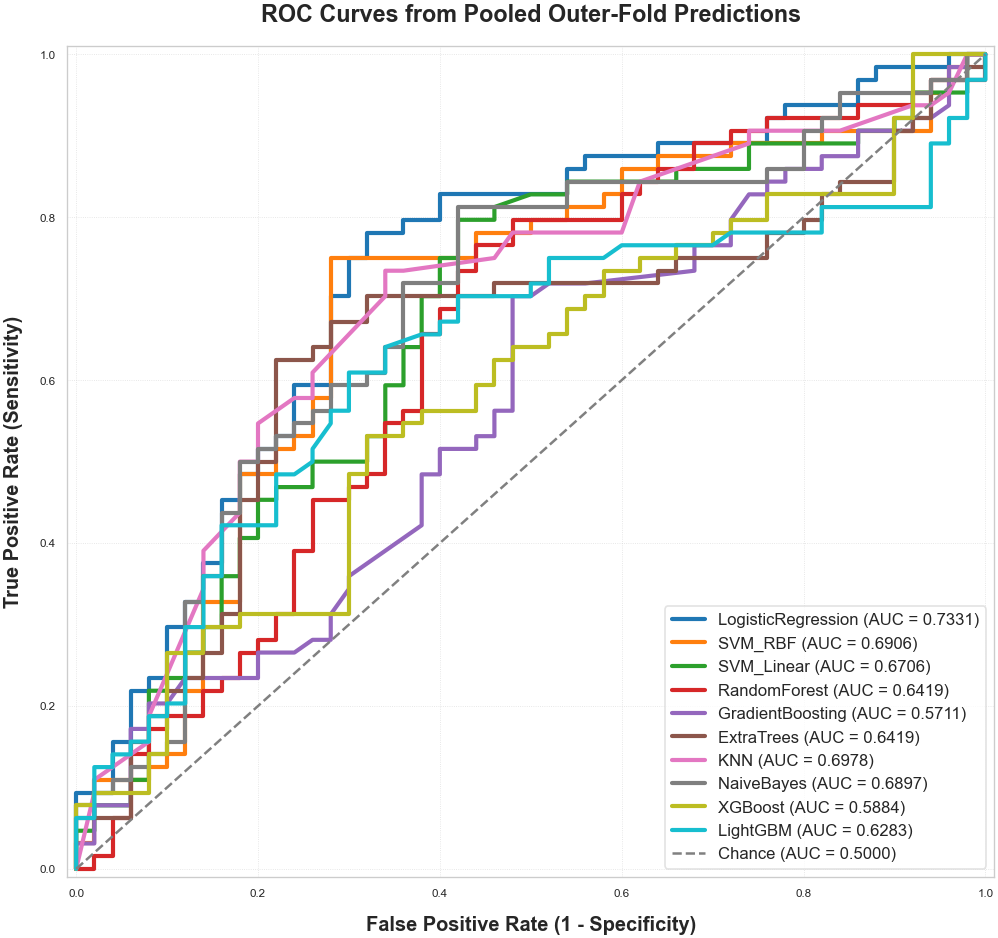


🚀 HIGH-RESOLUTION PLOTS SAVED SUCCESSFULLY:
 🖼️ PNG (DPI 900): nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/roc_curves.png
 📄 PDF (Vector):   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/roc_curves.pdf


In [64]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION ROC PLOT DESIGN
# =============================================================================
# Purpose:
#   - Aggregate pooled out-of-fold prediction matrices across all core estimators.
#   - Compute exact empirical Receiver Operating Characteristic (ROC) coordinates.
#   - Generate publication-grade, square-proportioned diagnostic curve overlays.
#   - Persist lossless vector PDF sheets and high-density 900 DPI raster matrices.
# =============================================================================



# =============================================================================
# CONSISTENCY CHECK: df_summary vs nested_cv_results
# =============================================================================

check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res['y_true'])
    y_prob_chk = np.asarray(res['y_prob'])

    if len(np.unique(y_true_chk)) < 2:
        pooled_auc_chk = np.nan
    else:
        pooled_auc_chk = roc_auc_score(y_true_chk, y_prob_chk)

    check_rows.append({
        'Model': model_name,
        'Pooled_AUC_recomputed': pooled_auc_chk,
        'Mean_AUC_recomputed': np.mean(res['fold_aucs'])
    })

df_check = pd.DataFrame(check_rows)

df_compare = df_summary.merge(df_check, on='Model', how='left')
df_compare['Pooled_AUC_diff'] = df_compare['Pooled_AUC'] - df_compare['Pooled_AUC_recomputed']
df_compare['Mean_AUC_diff'] = df_compare['Mean_AUC'] - df_compare['Mean_AUC_recomputed']

print(df_compare[['Model', 'Mean_AUC', 'Mean_AUC_recomputed', 'Mean_AUC_diff',
                  'Pooled_AUC', 'Pooled_AUC_recomputed', 'Pooled_AUC_diff']])

if (
    df_compare['Mean_AUC_diff'].abs().max() > 1e-8
    or df_compare['Pooled_AUC_diff'].abs().max() > 1e-8
):
    raise ValueError(
        "df_summary and nested_cv_results are inconsistent. "
        "Restart kernel and rerun cells sequentially from data loading through nested CV."
    )



import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dynamic asset extraction directory synchronization
PLOT_DIR = ACTIVE_SAVE_DIR
os.makedirs(PLOT_DIR, exist_ok=True)

# Establish rigorous square geometry aspect configurations optimized for ROC tracking
plt.figure(figsize=(8.5, 8))

# Sequential functional mapping loop navigating through validated cohort predictions
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping ROC for {model_name}: only one class present in y_true.")
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    # Render presentation-ready continuous curves using appropriate lineweights
    plt.plot(fpr, tpr, lw=2.5, label=f"{model_name} (AUC = {auc_val:.4f})")

# Construct baseline random distribution benchmark (Chance Line)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Chance (AUC = 0.5000)')

# Rigorous layout margin boundary setting
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('ROC Curves from Pooled Outer-Fold Predictions', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend to bypass asset collision while securing strict contrast margins
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Absolute multi-format storage target compilation
roc_png = os.path.join(PLOT_DIR, 'roc_curves.png')
roc_pdf = os.path.join(PLOT_DIR, 'roc_curves.pdf')

# Execute dual persistence strategy (DPI 900 Raster + Resolution-Invariant Vector)
plt.savefig(roc_png, dpi=600, bbox_inches='tight')
plt.savefig(roc_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION PLOTS SAVED SUCCESSFULLY:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", roc_png)
print(" 📄 PDF (Vector):  ", roc_pdf)
print("="*50)

                Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  \
0  LogisticRegression  0.776956             0.776956            0.0   
1             SVM_RBF  0.762992             0.762992            0.0   
2                 KNN  0.732992             0.732992            0.0   
3          NaiveBayes  0.723046             0.723046            0.0   
4          ExtraTrees  0.695427             0.695427            0.0   
5          SVM_Linear  0.675600             0.675600            0.0   
6        RandomForest  0.670438             0.670438            0.0   
7            LightGBM  0.661449             0.661449            0.0   
8             XGBoost  0.615473             0.615473            0.0   
9    GradientBoosting  0.614808             0.614808            0.0   

   Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff  
0    0.733125               0.733125              0.0  
1    0.690625               0.690625              0.0  
2    0.697812               0.697812              

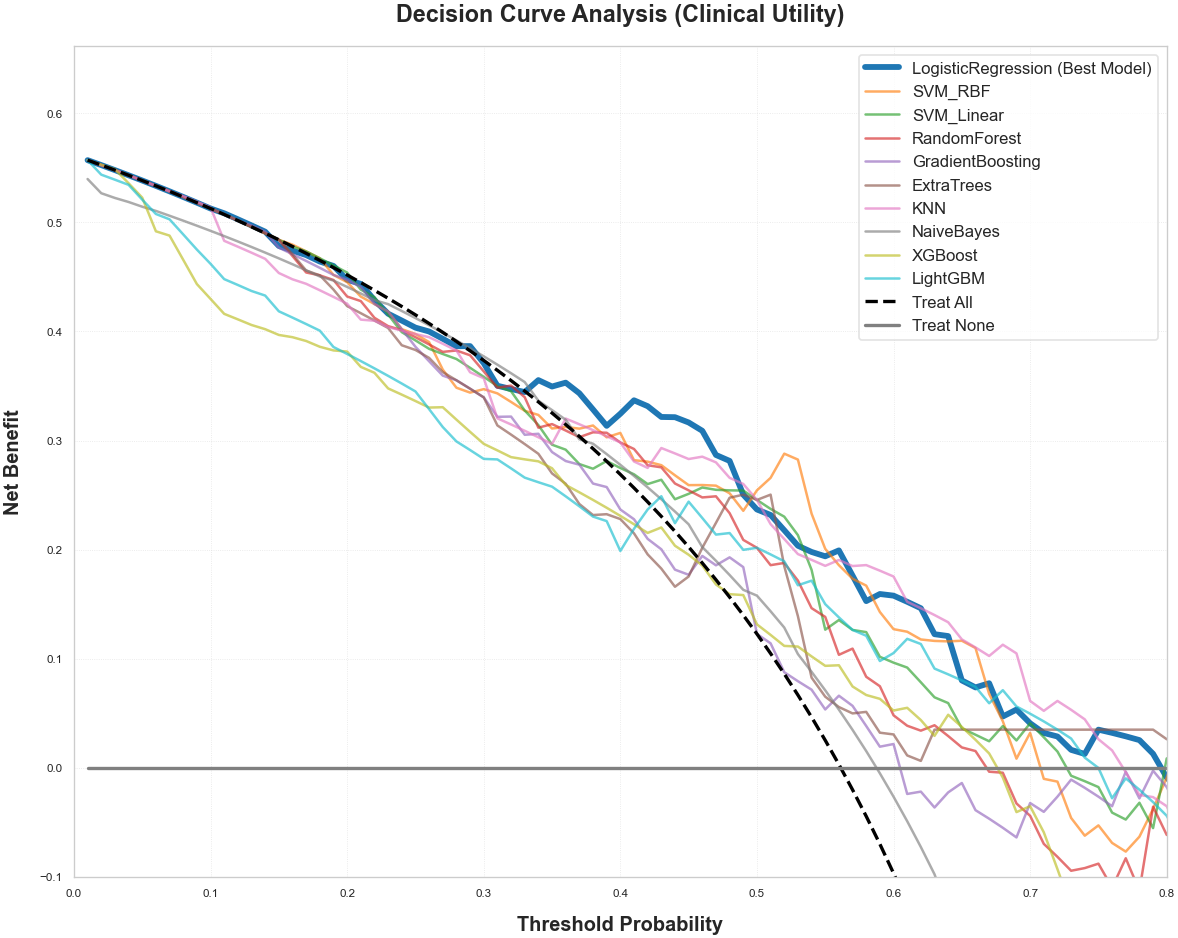


🚀 HIGH-RESOLUTION DCA PLOTS SAVED:
 🖼️ PNG (DPI 900): nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/decision_curve.png
 📄 PDF (Vector):   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/decision_curve.pdf


In [65]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION DECISION CURVE ANALYSIS
# =============================================================================
# Purpose:
#   - Implement mathematical Net Benefit formulations to evaluate clinical utility.
#   - Contrast dynamic machine learning model configurations against baseline clinical 
#     benchmarks ("Treat All" and "Treat None" strategies).
#   - Dynamically scale line-weights to automatically highlight the champion model.
#   - Save presentation-grade raster PNGs (900 DPI) and vector PDFs.
# =============================================================================

# =============================================================================
# CONSISTENCY CHECK BEFORE DCA
# =============================================================================
from sklearn.metrics import roc_auc_score

check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res['y_true'])
    y_prob_chk = np.asarray(res['y_prob'])

    pooled_auc_chk = roc_auc_score(y_true_chk, y_prob_chk)
    mean_auc_chk = np.mean(res['fold_aucs'])

    check_rows.append({
        'Model': model_name,
        'Mean_AUC_recomputed': mean_auc_chk,
        'Pooled_AUC_recomputed': pooled_auc_chk
    })

df_check = pd.DataFrame(check_rows)

df_compare = df_summary.merge(df_check, on='Model', how='left')
df_compare['Mean_AUC_diff'] = df_compare['Mean_AUC'] - df_compare['Mean_AUC_recomputed']
df_compare['Pooled_AUC_diff'] = df_compare['Pooled_AUC'] - df_compare['Pooled_AUC_recomputed']

print(df_compare[['Model', 'Mean_AUC', 'Mean_AUC_recomputed', 'Mean_AUC_diff',
                  'Pooled_AUC', 'Pooled_AUC_recomputed', 'Pooled_AUC_diff']])

if (
    df_compare['Mean_AUC_diff'].abs().max() > 1e-8
    or df_compare['Pooled_AUC_diff'].abs().max() > 1e-8
):
    raise ValueError(
        "df_summary and nested_cv_results are inconsistent. "
        "Restart kernel and rerun all cells sequentially from data loading to nested CV."
    )


import os
import numpy as np
import matplotlib.pyplot as plt

def decision_curve_net_benefit(y_true, y_prob, thresholds):
    """Computes empirical Net Benefit criteria for specified decision thresholds."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    net_benefits = []
    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            net_benefits.append(np.nan)
            continue

        y_pred = (y_prob >= pt).astype(int)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))

        nb = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.asarray(net_benefits)


def treat_all_net_benefit(y_true, thresholds):
    """Computes standard reference baseline Net Benefit assuming all patients are treated."""
    y_true = np.asarray(y_true)
    n = len(y_true)
    prevalence = np.mean(y_true)

    net_benefits = []
    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            net_benefits.append(np.nan)
            continue
        nb = prevalence - (1 - prevalence) * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.asarray(net_benefits)


# --- 1. Automated Output Destination Synchronization -------------------------
PLOT_DIR = ACTIVE_SAVE_DIR
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📈 Generating DCA. Best model '{best_model_name}' will be highlighted.")

thresholds = np.linspace(0.01, 0.99, 99)
plt.figure(figsize=(10, 8))

# Initialize baseline clinical markers relying on the primary validation array
first_model = next(iter(nested_cv_results.keys()))
reference_y_true = np.asarray(nested_cv_results[first_model]['y_true'])
prevalence = np.mean(reference_y_true)

# --- 3. Dynamic Sequential Curve Plotting ------------------------------------
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping DCA for {model_name}: only one class present in y_true.")
        continue

    # Dynamically optimize lineweights to highlight the top-performing candidate
    if model_name == best_model_name:
        lw = 3.5
        alpha = 1.0
        label_str = f"{model_name} (Best Model)"
    else:
        lw = 1.5
        alpha = 0.65
        label_str = model_name
    
    nb_model = decision_curve_net_benefit(y_true, y_prob, thresholds)
    plt.plot(thresholds, nb_model, lw=lw, alpha=alpha, label=label_str)

# --- 4. Clinical Reference Baseline Integration ------------------------------
nb_all = treat_all_net_benefit(reference_y_true, thresholds)
nb_none = np.zeros_like(thresholds)

plt.plot(thresholds, nb_all, linestyle='--', color='black', lw=2, label='Treat All')
plt.plot(thresholds, nb_none, linestyle='-', color='gray', lw=2, label='Treat None')

# Enforce strict medical research layout configuration standards
plt.xlim([0.0, 0.8]) 
plt.ylim([-0.1, max(prevalence + 0.1, 0.5)]) 

plt.xlabel('Threshold Probability', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Net Benefit', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Decision Curve Analysis (Clinical Utility)', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend matrices for optimal publication clarity
plt.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Absolute file path routing
dca_png = os.path.join(PLOT_DIR, 'decision_curve.png')
dca_pdf = os.path.join(PLOT_DIR, 'decision_curve.pdf')

# Execute dual persistence strategy (900 DPI Raster + Resolution-Invariant Vector)
plt.savefig(dca_png, dpi=600, bbox_inches='tight')
plt.savefig(dca_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION DCA PLOTS SAVED:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", dca_png)
print(" 📄 PDF (Vector):  ", dca_pdf)
print("="*50)


dca_rows = []

for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    if len(np.unique(y_true)) < 2:
        continue

    nb_model = decision_curve_net_benefit(y_true, y_prob, thresholds)

    for pt, nb in zip(thresholds, nb_model):
        dca_rows.append({
            'Model': model_name,
            'Threshold': pt,
            'Net_Benefit': nb
        })

nb_all = treat_all_net_benefit(reference_y_true, thresholds)
for pt, nb in zip(thresholds, nb_all):
    dca_rows.append({
        'Model': 'Treat All',
        'Threshold': pt,
        'Net_Benefit': nb
    })

for pt in thresholds:
    dca_rows.append({
        'Model': 'Treat None',
        'Threshold': pt,
        'Net_Benefit': 0.0
    })

df_dca = pd.DataFrame(dca_rows)
df_dca.to_csv(os.path.join(PLOT_DIR, 'decision_curve_data.csv'), index=False)



🔎 Calibration consistency check:
                Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  \
0  LogisticRegression  0.776956             0.776956            0.0   
1             SVM_RBF  0.762992             0.762992            0.0   
2                 KNN  0.732992             0.732992            0.0   
3          NaiveBayes  0.723046             0.723046            0.0   
4          ExtraTrees  0.695427             0.695427            0.0   
5          SVM_Linear  0.675600             0.675600            0.0   
6        RandomForest  0.670438             0.670438            0.0   
7            LightGBM  0.661449             0.661449            0.0   
8             XGBoost  0.615473             0.615473            0.0   
9    GradientBoosting  0.614808             0.614808            0.0   

   Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff  
0    0.733125               0.733125              0.0  
1    0.690625               0.690625              0.0  
2    0.697812   

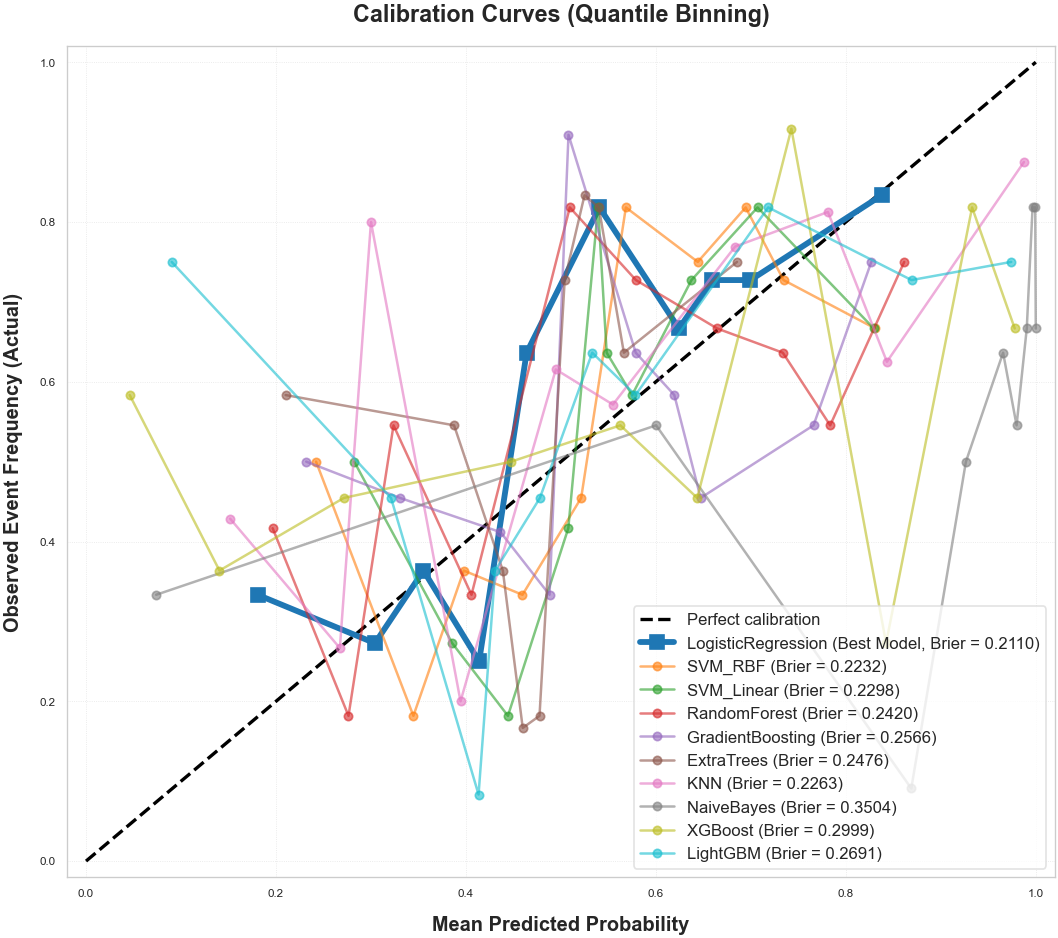


🚀 HIGH-RESOLUTION CALIBRATION PLOTS SAVED:
 🖼️ PNG (DPI 900): nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/calibration_curves.png
 📄 PDF (Vector):   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/calibration_curves.pdf


In [66]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION CALIBRATION CURVES
# =============================================================================
# Purpose:
#   - Compute exact empirical calibration curves (reliability diagrams) across 
#     all model configurations using quantile binning strategies.
#   - Quantify global calibration performance via Brier Score Loss calculations.
#   - Dynamically highlight the top-performing candidate model using customized 
#     markers, markersizes, and dominant lineweights.
#   - Save production-grade raster PNGs (900 DPI) and vector PDFs.
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# --- 1. Automated Output Destination Synchronization -------------------------
PLOT_DIR = ACTIVE_SAVE_DIR
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    df_summary = df_summary.sort_values('Mean_AUC', ascending=False).reset_index(drop=True)
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]
    

from sklearn.metrics import roc_auc_score

check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res['y_true'])
    y_prob_chk = np.asarray(res['y_prob'])

    check_rows.append({
        'Model': model_name,
        'Mean_AUC_recomputed': np.mean(res['fold_aucs']),
        'Pooled_AUC_recomputed': roc_auc_score(y_true_chk, y_prob_chk)
    })

df_check = pd.DataFrame(check_rows)

if 'df_summary' in locals() or 'df_summary' in globals():
    df_compare = df_summary.merge(df_check, on='Model', how='left')
    df_compare['Mean_AUC_diff'] = df_compare['Mean_AUC'] - df_compare['Mean_AUC_recomputed']
    df_compare['Pooled_AUC_diff'] = df_compare['Pooled_AUC'] - df_compare['Pooled_AUC_recomputed']

    print("\n🔎 Calibration consistency check:")
    print(df_compare[['Model', 'Mean_AUC', 'Mean_AUC_recomputed', 'Mean_AUC_diff',
                      'Pooled_AUC', 'Pooled_AUC_recomputed', 'Pooled_AUC_diff']])

    if (
        df_compare['Mean_AUC_diff'].abs().max() > 1e-8
        or df_compare['Pooled_AUC_diff'].abs().max() > 1e-8
    ):
        raise ValueError(
            "df_summary and nested_cv_results are inconsistent. "
            "Restart kernel and rerun all cells sequentially from data loading to nested CV."
        )
    

print(f"📊 Generating Calibration Curves. Best model '{best_model_name}' will be highlighted.")

n_bins = 10  # Standard clinical deciles of risk distribution
plt.figure(figsize=(9, 8))

# Reference baseline for a theoretically perfect diagnostic model (Perfect Calibration)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', lw=2, label='Perfect calibration')

# --- 3. Dynamic Sequential Calibration Plotting -------------------------------
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping calibration for {model_name}: only one class present in y_true.")
        continue

    try:
        # Enforce quantile strategy to preserve uniform sample counts across cross-validation bins
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
        brier = brier_score_loss(y_true, y_prob)

        # Dynamically allocate structural lineweights and shapes to emphasize the best model
        if model_name == best_model_name:
            lw = 3.5
            alpha = 1.0
            marker = 's'  # Square marker chosen exclusively for the champion model
            ms = 8
            label_str = f"{model_name} (Best Model, Brier = {brier:.4f})"
        else:
            lw = 1.5
            alpha = 0.6
            marker = 'o'  # Standard circle marker for baseline competitor profiles
            ms = 5
            label_str = f"{model_name} (Brier = {brier:.4f})"

        plt.plot(mean_pred, frac_pos, marker=marker, markersize=ms, lw=lw, alpha=alpha, label=label_str)
        
    except Exception as e:
        print(f"❌ Skipping calibration for {model_name}: {e}")

# Enforce strict layout configuration boundaries
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Observed Event Frequency (Actual)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Calibration Curves (Quantile Binning)', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend matrices for optimal publication clarity
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Absolute file path routing
cal_png = os.path.join(PLOT_DIR, 'calibration_curves.png')
cal_pdf = os.path.join(PLOT_DIR, 'calibration_curves.pdf')

# Execute dual persistence strategy (900 DPI Raster + Resolution-Invariant Vector)
plt.savefig(cal_png, dpi=600, bbox_inches='tight')
plt.savefig(cal_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION CALIBRATION PLOTS SAVED:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", cal_png)
print(" 📄 PDF (Vector):  ", cal_pdf)
print("="*50)

In [67]:
# =============================================================================
# COHORT ARTIFACT PERSISTENCE AND CROSS-MODEL EVALUATION EXTRACTOR
# =============================================================================
# Purpose:
#   - Atomically validate array distributions and nomenclature consistency.
#   - Export isolated vector matrices (ROC, PR-Curve, Confusion Matrices) 
#     separately for each individual model topology in the execution memory.
#   - Compute stratified descriptive macro-parameters (mean, std, min, max, pooled).
#   - Persist cross-model evaluation rankings to secure tabular outputs.
# =============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score
)

# -----------------------------------------------------------------------------
# 1. COMPONSATIONAL VALIDATION AND DATA ALIGNMENT UTILITY FUNCTIONS
# -----------------------------------------------------------------------------

def safe_array(x):
    """Converts upstream iterable objects cleanly into 1D contiguous NumPy arrays."""
    if x is None:
        return np.array([])
    return np.asarray(x).ravel()


def safe_metric_stats(values):
    """Computes robust descriptive parameters for localized fold evaluation records.

    Safeguards downstream IO processes from crashing when encountered with empty 
    or incomplete cross-validation tracks by adaptively embedding NaN limits.
    """
    if values is None:
        return np.nan, np.nan, np.nan, np.nan
    
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    return (
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values))
    )


def get_optional_metric(results, key, model_name=None):
    """Safely extracts supplementary non-mandatory metrics from execution arrays."""
    if key not in results or results[key] is None or len(results[key]) == 0:
        warnings.warn(
            f"[{model_name}] Optional metric '{key}' not found in results. "
            f"Summary values will be saved as NaN."
        )
        return []
    return results[key]


def validate_required_keys(results, required_keys, model_name="unknown_model"):
    """Enforces rigid metadata verification to protect analytical structural integrity."""
    missing = [k for k in required_keys if k not in results]
    if missing:
        raise ValueError(
            f"Model '{model_name}' is missing required keys in results: {missing}"
        )


# -----------------------------------------------------------------------------
# 2. CORE SERIALIZATION ENGINE FOR ARTIFACT GENERATION
# -----------------------------------------------------------------------------
def save_model_data(model_name, results, base_dir='plot_data'):
    """Atomically exports performance plots, vector logs, and meta-logs for a model.

    Args:
        model_name (str): Matching token matching the target estimator signature.
        results (dict): Log tracking historical prediction matrices and fold outputs.
        base_dir (str): Relative destination path defining asset storage boundaries.

    Returns:
        dict: Flattened composite mapping consisting of pooled indices and fold statistics.
    """
    required_keys = [
        'y_true', 'y_prob', 'y_pred',
        'fold_aucs', 'fold_accuracies',
        'fold_f1_scores', 'fold_precisions', 'fold_recalls',
        'n_features_per_fold'
    ]
    validate_required_keys(results, required_keys, model_name)

    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    y_true = safe_array(results['y_true'])
    y_prob = safe_array(results['y_prob'])
    y_pred = safe_array(results['y_pred'])

    if len(y_true) == 0:
        raise ValueError(f"Model '{model_name}' has empty y_true.")
    if not (len(y_true) == len(y_prob) == len(y_pred)):
        raise ValueError(
            f"Model '{model_name}' has inconsistent lengths: "
            f"len(y_true)={len(y_true)}, len(y_prob)={len(y_prob)}, len(y_pred)={len(y_pred)}"
        )

    # Ingest complementary auxiliary fold sequences
    fold_pr_aucs = get_optional_metric(results, 'fold_pr_aucs', model_name=model_name)
    fold_bal_accuracies = get_optional_metric(results, 'fold_bal_accuracies', model_name=model_name)

    # ─── 1. Receiver Operating Characteristic (ROC) Coordinate Curves ───
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_df = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr
    })
    roc_df['threshold'] = np.nan
    roc_df.iloc[:len(thresholds_roc), roc_df.columns.get_loc('threshold')] = thresholds_roc
    roc_df.to_csv(os.path.join(model_dir, 'roc_curve.csv'), index=False)

    # ─── 2. Precision-Recall (PR) Continuous Curve Values ───
    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)

    pr_df = pd.DataFrame({
        'precision': precision_curve,
        'recall': recall_curve
    })
    pr_df['threshold'] = np.nan
    pr_df.iloc[:len(thresholds_pr), pr_df.columns.get_loc('threshold')] = thresholds_pr
    pr_df.to_csv(os.path.join(model_dir, 'pr_curve.csv'), index=False)

    # ─── 3. Invariant State Confusion Matrices ───
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual_0', 'Actual_1'],
        columns=['Predicted_0', 'Predicted_1']
    )
    cm_df.to_csv(os.path.join(model_dir, 'confusion_matrix.csv'))

    # ─── 4. Pooled Prediction Tracking Profiles ───
    pooled_df = pd.DataFrame({
        'y_true': y_true,
        'y_prob': y_prob,
        'y_pred': y_pred
    })
    pooled_df.to_csv(os.path.join(model_dir, 'pooled_predictions.csv'), index=False)

    # ─── 5. High-Fidelity Categorization Reports (JSON Manifest) ───
    report = classification_report(y_true, y_pred, output_dict=True)
    report['roc_auc'] = float(roc_auc)
    report['average_precision'] = float(ap_score)
    report['balanced_accuracy'] = float(balanced_accuracy_score(y_true, y_pred))

    with open(os.path.join(model_dir, 'classification_report.json'), 'w') as f:
        json.dump(report, f, indent=2)

    # ─── 6. Structural Longitudinal Fold Progress Matrix ───
    n_folds = len(results['fold_aucs'])

    fold_data = {
        'fold': list(range(1, n_folds + 1)),
        'auc': list(results['fold_aucs']),
        'pr_auc': list(fold_pr_aucs) if len(fold_pr_aucs) == n_folds else [np.nan] * n_folds,
        'accuracy': list(results['fold_accuracies']),
        'bal_accuracy': list(fold_bal_accuracies) if len(fold_bal_accuracies) == n_folds else [np.nan] * n_folds,
        'f1_score': list(results['fold_f1_scores']),
        'precision': list(results['fold_precisions']),
        'recall': list(results['fold_recalls']),
        'n_features': list(results['n_features_per_fold']),
    }

    fold_df = pd.DataFrame(fold_data)
    fold_df.to_csv(os.path.join(model_dir, 'per_fold_metrics.csv'), index=False)

    # ─── 7. Optimal Dynamic Hyperparameter Log Maps ───
    if results.get('best_params_per_fold') is not None and len(results.get('best_params_per_fold')) > 0:
        params_df = pd.DataFrame(results['best_params_per_fold'])
        params_df.insert(0, 'fold', range(1, len(params_df) + 1))
        params_df.to_csv(os.path.join(model_dir, 'best_params_per_fold.csv'), index=False)

    # ─── 8. Summary Statistics Tabular Matrix Construction ───
    auc_mean, auc_std, auc_min, auc_max = safe_metric_stats(results['fold_aucs'])
    pr_mean, pr_std, pr_min, pr_max = safe_metric_stats(fold_pr_aucs)
    acc_mean, acc_std, acc_min, acc_max = safe_metric_stats(results['fold_accuracies'])
    bal_mean, bal_std, bal_min, bal_max = safe_metric_stats(fold_bal_accuracies)
    f1_mean, f1_std, f1_min, f1_max = safe_metric_stats(results['fold_f1_scores'])
    prec_mean, prec_std, prec_min, prec_max = safe_metric_stats(results['fold_precisions'])
    rec_mean, rec_std, rec_min, rec_max = safe_metric_stats(results['fold_recalls'])

    summary = {
        'metric': ['AUC', 'PR_AUC', 'Accuracy', 'Bal_Accuracy', 'F1_Score', 'Precision', 'Recall'],
        'mean':   [auc_mean, pr_mean, acc_mean, bal_mean, f1_mean, prec_mean, rec_mean],
        'std':    [auc_std,  pr_std, acc_std, bal_std, f1_std, prec_std, rec_std],
        'min':    [auc_min,  pr_min, acc_min, bal_min, f1_min, prec_min, rec_min],
        'max':    [auc_max,  pr_max, acc_max, bal_max, f1_max, prec_max, rec_max],
        'pooled': [
            float(roc_auc),
            float(ap_score),  # Maps pooled PR-AUC / Average Precision criteria
            float(accuracy_score(y_true, y_pred)),
            float(balanced_accuracy_score(y_true, y_pred)),
            float(f1_score(y_true, y_pred)),
            float(precision_score(y_true, y_pred, zero_division=0)),
            float(recall_score(y_true, y_pred, zero_division=0)),
        ]
    }

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(os.path.join(model_dir, 'summary_statistics.csv'), index=False)

    return {
        'pooled_auc': float(roc_auc),
        'pooled_pr_auc': float(ap_score),
        'pooled_accuracy': float(accuracy_score(y_true, y_pred)),
        'pooled_bal_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'pooled_f1': float(f1_score(y_true, y_pred)),
        'pooled_precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'pooled_recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'n_samples': int(len(y_true)),
        'n_folds': int(n_folds),
        'fold_auc_mean': auc_mean,
        'fold_auc_std': auc_std,
        'fold_pr_auc_mean': pr_mean,
        'fold_pr_auc_std': pr_std,
        'fold_accuracy_mean': acc_mean,
        'fold_accuracy_std': acc_std,
        'fold_bal_accuracy_mean': bal_mean,
        'fold_bal_accuracy_std': bal_std,
        'fold_f1_mean': f1_mean,
        'fold_f1_std': f1_std,
        'fold_precision_mean': prec_mean,
        'fold_precision_std': prec_std,
        'fold_recall_mean': rec_mean,
        'fold_recall_std': rec_std,
    }


# -----------------------------------------------------------------------------
# 3. GLOBAL ROUTING PIPELINE SEQUENCE: SYSTEM OVERVIEW LOGGING
# -----------------------------------------------------------------------------
base_dir = os.path.join(ACTIVE_SAVE_DIR, "plot_data")
os.makedirs(base_dir, exist_ok=True)

print("=" * 70)
print("📦 Saving data for all models...")
print("=" * 70)

all_models_summary = []

for model_name, results in nested_cv_results.items():
    try:
        if 'y_true' not in results or len(results['y_true']) == 0:
            print(f"  ⚠️  {model_name}: No data found, skipping...")
            continue

        model_summary = save_model_data(model_name, results, base_dir)

        all_models_summary.append({
            'model': model_name,
            'mean_auc': model_summary['fold_auc_mean'],
            'std_auc': model_summary['fold_auc_std'],
            'pooled_auc': model_summary['pooled_auc'],
            'mean_pr_auc': model_summary['fold_pr_auc_mean'],
            'std_pr_auc': model_summary['fold_pr_auc_std'],
            'pooled_pr_auc': model_summary['pooled_pr_auc'],
            'mean_accuracy': model_summary['fold_accuracy_mean'],
            'std_accuracy': model_summary['fold_accuracy_std'],
            'pooled_accuracy': model_summary['pooled_accuracy'],
            'mean_bal_accuracy': model_summary['fold_bal_accuracy_mean'],
            'std_bal_accuracy': model_summary['fold_bal_accuracy_std'],
            'pooled_bal_accuracy': model_summary['pooled_bal_accuracy'],
            'mean_f1': model_summary['fold_f1_mean'],
            'std_f1': model_summary['fold_f1_std'],
            'pooled_f1': model_summary['pooled_f1'],
            'mean_precision': model_summary['fold_precision_mean'],
            'std_precision': model_summary['fold_precision_std'],
            'pooled_precision': model_summary['pooled_precision'],
            'mean_recall': model_summary['fold_recall_mean'],
            'std_recall': model_summary['fold_recall_std'],
            'pooled_recall': model_summary['pooled_recall'],
            'n_samples': model_summary['n_samples'],
            'n_folds': model_summary['n_folds'],
        })

        print(
            f"   ✅ {model_name:25s} | "
            f"Pooled AUC={model_summary['pooled_auc']:.4f} | "
            f"Pooled PR-AUC={model_summary['pooled_pr_auc']:.4f} | "
            f"{model_summary['n_samples']} samples | "
            f"{model_summary['n_folds']} folds"
        )

    except Exception as e:
        print(f"   ❌ {model_name}: Failed -> {e}")


# -----------------------------------------------------------------------------
# 4. CROSS-MODEL TABULAR RANKING MATRIX EVALUATION
# -----------------------------------------------------------------------------
comparison_dir = os.path.join(base_dir, 'comparison')
os.makedirs(comparison_dir, exist_ok=True)

summary_all_df = pd.DataFrame(all_models_summary)

if len(summary_all_df) > 0:
    summary_all_df = summary_all_df.sort_values('mean_auc', ascending=False).reset_index(drop=True)
    summary_all_df.to_csv(os.path.join(comparison_dir, 'all_models_summary.csv'), index=False)

print("=" * 70)
print(f"✅ Done! {len(all_models_summary)} models saved.")
print(f"📁 Output directory: {os.path.abspath(base_dir)}")
print("=" * 70)

# --- Dynamic Directory Verification Sequence ---------------------------------
print("\n📂 Directory structure:")
for item_name in sorted(os.listdir(base_dir)):
    item_path = os.path.join(base_dir, item_name)
    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        print(f"   ├── {item_name}/ ({len(files)} files)")

📦 Saving data for all models...
   ✅ LogisticRegression        | Pooled AUC=0.7331 | Pooled PR-AUC=0.7642 | 114 samples | 5 folds
   ✅ SVM_RBF                   | Pooled AUC=0.6906 | Pooled PR-AUC=0.7159 | 114 samples | 5 folds
   ✅ SVM_Linear                | Pooled AUC=0.6706 | Pooled PR-AUC=0.7068 | 114 samples | 5 folds
   ✅ RandomForest              | Pooled AUC=0.6419 | Pooled PR-AUC=0.6528 | 114 samples | 5 folds
   ✅ GradientBoosting          | Pooled AUC=0.5711 | Pooled PR-AUC=0.6425 | 114 samples | 5 folds
   ✅ ExtraTrees                | Pooled AUC=0.6419 | Pooled PR-AUC=0.7031 | 114 samples | 5 folds
   ✅ KNN                       | Pooled AUC=0.6978 | Pooled PR-AUC=0.7263 | 114 samples | 5 folds
   ✅ NaiveBayes                | Pooled AUC=0.6897 | Pooled PR-AUC=0.7278 | 114 samples | 5 folds
   ✅ XGBoost                   | Pooled AUC=0.5884 | Pooled PR-AUC=0.6670 | 114 samples | 5 folds
   ✅ LightGBM                  | Pooled AUC=0.6283 | Pooled PR-AUC=0.7080 | 114 sample

In [68]:
# # =============================================================================
# # RADIOMICS MANIFOLD LEARNING AND HIGH-DIMENSIONAL COHORT CLUSTERING (t-SNE)
# # =============================================================================
# # Purpose:
# #   - Isolate raw numeric multi-modality features from global diagnostic frames.
# #   - Execute non-linear dimensionality reduction utilizing manifold learning (t-SNE).
# #   - Generate presentation-grade, high-resolution diagnostic cluster charts 
# #     evaluating class boundaries (0 vs 1) and intra-patient batch effects.
# # =============================================================================

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.manifold import TSNE
# from sklearn.preprocessing import StandardScaler

# # --- 1. Vector Matrix Isolation and Baseline Extraction ---------------------
# # Filter continuous numeric radiomics parameters dynamically from system memory
# X_numeric = pd.DataFrame(X, columns=feature_names).copy()
# y_labels = np.asarray(y)
# patient_groups = np.asarray(groups)

# print(f"t-SNE input shape: {X_numeric.shape}")
# print(f"Number of labels: {len(y_labels)}")
# print(f"Number of patient groups: {len(patient_groups)}")


# print("⏳ Scaling data and calculating t-SNE (This may take 1-2 minutes)...")

# # --- 2. Invariant Standardization and Feature Rescaling ---------------------
# # Enforce zero-mean and unit-variance scaling to protect optimization algorithms 
# # from dominant dimensional variance artifacts.
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_numeric)

# # --- 3. Manifold Learning and Low-Dimensional Embedding Space ----------------
# # Compile non-linear high-dimensional topological boundaries into an optimized 
# # 2D coordinate map using t-Distributed Stochastic Neighbor Embedding.
# tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
# X_tsne = tsne.fit_transform(X_scaled)

# # Assemble lower-dimensional array coordinates into a clean structured tracking DataFrame
# tsne_df = pd.DataFrame({
#     'TSNE_1': X_tsne[:, 0],
#     'TSNE_2': X_tsne[:, 1],
#     'Class': y_labels,
#     'Patient_ID': patient_groups
# })

# # Establish destination directory framework for persistent storage
# os.makedirs('plot_data/Clustering', exist_ok=True)

# # -----------------------------------------------------------------------------
# # GRAPHICAL CHART 1: TARGET PATHOLOGICAL SIGNAL ISOLATION ANALYSIS
# # -----------------------------------------------------------------------------
# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x='TSNE_1', y='TSNE_2',
#     hue='Class',
#     palette=['#FF7043', '#00ACC1'],  # Balanced vibrant coral and deep cyan accents
#     data=tsne_df,
#     alpha=0.7,
#     s=60,
#     edgecolor=None
# )
# plt.title("t-SNE Visualization: Separation by Class (0 vs 1)", fontsize=14, pad=15)
# plt.xlabel("t-SNE Dimension 1", fontsize=12)
# plt.ylabel("t-SNE Dimension 2", fontsize=12)
# plt.legend(title='Target Class')
# plt.tight_layout()
# plt.savefig('plot_data/Clustering/tsne_by_class.png', dpi=300)
# plt.close()

# # -----------------------------------------------------------------------------
# # GRAPHICAL CHART 2: INTRA-PATIENT LESION CLUSTERING MATRIX
# # -----------------------------------------------------------------------------
# plt.figure(figsize=(12, 9))
# sns.scatterplot(
#     x='TSNE_1', y='TSNE_2',
#     hue='Patient_ID',
#     palette='tab20',  # Distinct qualitative layout to track discrete subject profiles
#     data=tsne_df,
#     alpha=0.8,
#     s=50,
#     edgecolor='k',
#     linewidth=0.2
# )
# plt.title("t-SNE Visualization: Lesion Clustering by Patient", fontsize=14, pad=15)
# plt.xlabel("t-SNE Dimension 1", fontsize=12)
# plt.ylabel("t-SNE Dimension 2", fontsize=12)

# # Prevent bounding-box metric clipping by projecting the legend externally
# plt.legend(title='Patient ID', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
# plt.tight_layout()
# plt.savefig('plot_data/Clustering/tsne_by_patient.png', dpi=600)
# plt.close()

# print("✅ t-SNE plots saved successfully in 'plot_data/Clustering/'")

In [69]:
print("ACTIVE_RUN_NAME:", globals().get("ACTIVE_RUN_NAME"))
print("ACTIVE_SAVE_DIR:", globals().get("ACTIVE_SAVE_DIR"))

print("\nselected_features_per_fold type:", type(selected_features_per_fold))
print("n folds:", len(selected_features_per_fold))

print("\nExample selected_features_per_fold[0]:")
print(selected_features_per_fold[0])

print("\ndf shape:", df.shape)
print("n df columns:", len(df.columns))

print("\nFirst 20 df columns:")
print(list(df.columns[:20]))

print("\nfeature_names exists:", "feature_names" in globals())
if "feature_names" in globals():
    print("n feature_names:", len(feature_names))
    print("first 20 feature_names:", feature_names[:20])

print("\ndf_selected_features_long exists:", "df_selected_features_long" in globals())
if "df_selected_features_long" in globals():
    print(df_selected_features_long.head(20))

ACTIVE_RUN_NAME: legacy_elasticnet_then_mrmr_k8_no_smote
ACTIVE_SAVE_DIR: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote

selected_features_per_fold type: <class 'list'>
n folds: 5

Example selected_features_per_fold[0]:
['GLSZM_SmallZoneEmphasis', 'GLRLM_ShortRunLowGreyLevelEmphasis', 'GLCM_DifferenceAverage', 'Morph_SphericalDisproportion', 'Morph_RadiusRoiNorm_MaxIntensityCoor_PerimeterCoor_3DSmallestDist', 'GLSZM_NormalisedZoneSizeNonUniformity', 'IB_MedianIntensity', 'Morph_Compacity']

df shape: (30, 52)
n df columns: 52

First 20 df columns:
['AUC_Rank', 'Model', 'Mean_AUC', 'Std_AUC', 'Pooled_AUC', 'Mean_PR_AUC', 'Std_PR_AUC', 'Pooled_PR_AUC', 'Mean_Acc', 'Std_Acc', 'Pooled_Acc', 'Mean_Bal_Acc', 'Std_Bal_Acc', 'Pooled_Bal_Acc', 'Mean_Prec', 'Std_Prec', 'Pooled_Prec', 'Mean_Rec', 'Std_Rec', 'Pooled_Rec']

feature_names exists: True
n feature_names: 145
first 20 feature_names: ['FEATURE_RESULTS', 'Morph_Volume

🌟 FINAL XAI PIPELINE: STABLE-FEATURE SHAP ANALYSIS

🔎 Consistency check:
             Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff
LogisticRegression  0.776956             0.776956            0.0    0.733125               0.733125              0.0
           SVM_RBF  0.762992             0.762992            0.0    0.690625               0.690625              0.0
               KNN  0.732992             0.732992            0.0    0.697812               0.697812              0.0
        NaiveBayes  0.723046             0.723046            0.0    0.689688               0.689688              0.0
        ExtraTrees  0.695427             0.695427            0.0    0.641875               0.641875              0.0
        SVM_Linear  0.675600             0.675600            0.0    0.670625               0.670625              0.0
      RandomForest  0.670438             0.670438            0.0    0.641875               0.641875         


✅ SHAP calculation complete.

Top SHAP features:
                     Feature_Original  Feature_Index                     Feature_Sanitized  MeanAbsSHAP  Selection_Count
IH_IntensityHistogramMedian_Intensity             61 IH_IntensityHistogramMedian_Intensity     0.106498                4
         Morph_SphericalDisproportion              9          Morph_SphericalDisproportion     0.041485                3
        Morph_SurfaceToVolumeRatio_cm              5         Morph_SurfaceToVolumeRatio_cm     0.039946                2
                   Morph_Compactness1              7                    Morph_Compactness1     0.034624                2
              GLSZM_SmallZoneEmphasis            130               GLSZM_SmallZoneEmphasis     0.022245                4

💾 SHAP importance table saved to: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/SHAP_Plots/shap_feature_importance.csv


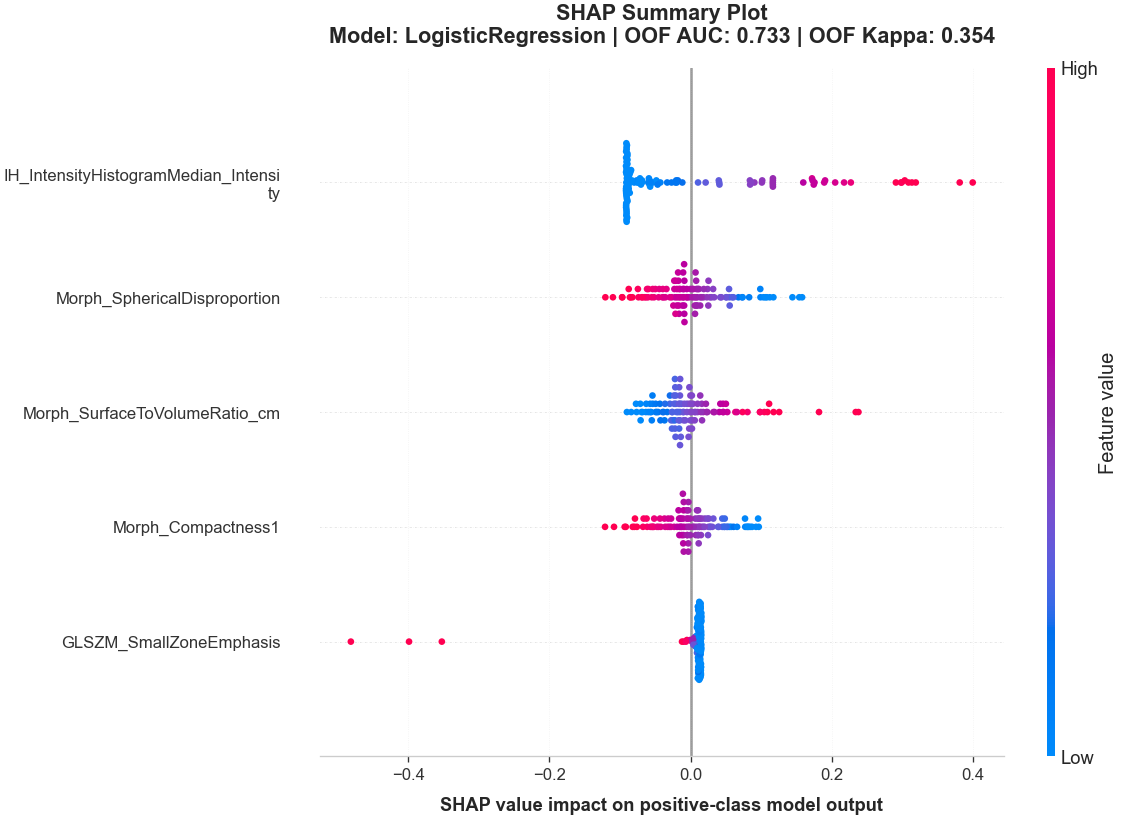

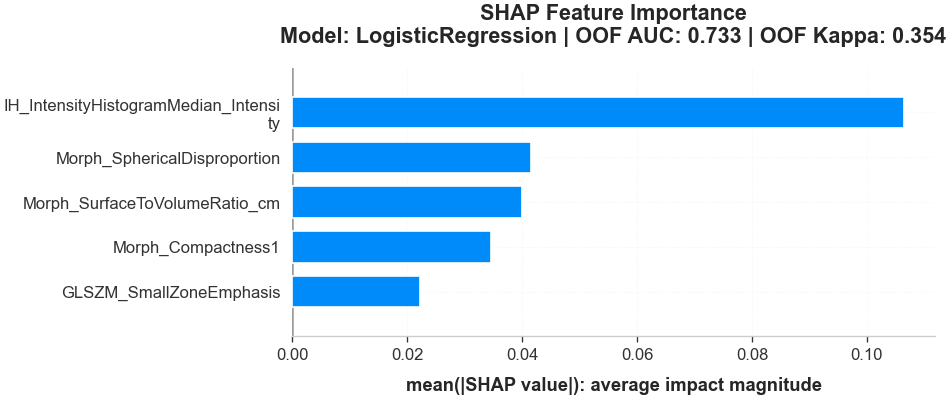


🎉 FINAL XAI PIPELINE COMPLETE
📁 Output directory: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/SHAP_Plots
💾 Metadata:         nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/SHAP_Plots/xai_metadata.json
💾 Model artifact:   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/SHAP_Plots/Best_Model_LogisticRegression_XAI_Artifact.joblib
💾 SHAP dot plot:    nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/SHAP_Plots/shap_summary_dot_stable.png
💾 SHAP bar plot:    nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote/SHAP_Plots/shap_summary_bar_stable.png


In [70]:
# =============================================================================
# FINAL EXPLAINABLE AI MODULE: STABLE-FEATURE SHAP ANALYSIS
# =============================================================================
# Purpose:
#   - Verify consistency between df_summary and nested_cv_results.
#   - Select the best model by Mean AUC from nested CV.
#   - Build a recurrence-based stable feature set from outer-fold feature selection.
#   - Refit the best model on the full cohort using the same imputation/scaling logic.
#   - Use OOF metrics for reported performance/Kappa, not in-sample metrics.
#   - Compute SHAP explanations on positive-class probability / model score.
#   - Save SHAP plots, feature-importance tables, stability tables, and model artifact.
# =============================================================================

import os
import re
import json
import math
import textwrap
import warnings
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

print("=" * 80)
print("🌟 FINAL XAI PIPELINE: STABLE-FEATURE SHAP ANALYSIS")
print("=" * 80)


# =============================================================================
# 0. REQUIRED OBJECT CHECKS
# =============================================================================
required_objects = [
    "X", "y", "feature_names", "df_summary", "nested_cv_results",
    "selected_features_per_fold", "CONFIG", "NESTED_CV_MODELS"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]
if len(missing_objects) > 0:
    raise RuntimeError(
        f"Missing required runtime objects: {missing_objects}. "
        "Run the previous notebook cells sequentially before this XAI cell."
    )


# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================
def sanitize_feature_name(name):
    """Convert feature names to model-safe strings."""
    name = str(name)
    name = re.sub(r"[^a-zA-Z0-9_]", "_", name)
    name = re.sub(r"_+", "_", name)
    name = name.strip("_")
    return name


def wrap_feature_labels(labels, width=35):
    """Wrap long feature names for readable SHAP plots."""
    return [textwrap.fill(str(label), width=width) for label in labels]


def interpret_kappa(kappa_score):
    """Interpret Cohen's Kappa."""
    if kappa_score < 0:
        return "No agreement / worse than chance"
    elif kappa_score <= 0.20:
        return "Slight agreement / very weak"
    elif kappa_score <= 0.40:
        return "Fair agreement / low"
    elif kappa_score <= 0.60:
        return "Moderate agreement"
    elif kappa_score <= 0.80:
        return "Substantial agreement"
    else:
        return "Almost perfect agreement"


def to_jsonable(obj):
    """Convert NumPy/Pandas objects to JSON-safe objects."""
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if pd.isna(obj) if not isinstance(obj, (list, dict, tuple, np.ndarray)) else False:
        return None
    return obj


def aggregate_best_params(params_per_fold):
    """
    Aggregate Optuna-selected hyperparameters across outer folds without using
    outer-test performance to choose a single fold.

    Numeric parameters -> median.
    Integer numeric parameters -> rounded median.
    Categorical/string/bool/None parameters -> mode.
    """
    if params_per_fold is None or len(params_per_fold) == 0:
        return {}

    all_keys = sorted(set().union(*[p.keys() for p in params_per_fold if isinstance(p, dict)]))
    aggregated = {}

    for key in all_keys:
        vals = [p[key] for p in params_per_fold if isinstance(p, dict) and key in p]

        if len(vals) == 0:
            continue

        all_numeric = all(isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool) for v in vals)

        if all_numeric:
            med_val = float(np.median(vals))
            all_int = all(isinstance(v, (int, np.integer)) and not isinstance(v, bool) for v in vals)
            aggregated[key] = int(round(med_val)) if all_int else med_val
        else:
            aggregated[key] = Counter(vals).most_common(1)[0][0]

    return aggregated


def compute_specificity_from_arrays(y_true, y_pred):
    """Compute specificity = TN / (TN + FP)."""
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan

    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


# =============================================================================
# 2. CONSISTENCY CHECK: df_summary vs nested_cv_results
# =============================================================================
check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res["y_true"])
    y_prob_chk = np.asarray(res["y_prob"])

    check_rows.append({
        "Model": model_name,
        "Mean_AUC_recomputed": float(np.mean(res["fold_aucs"])),
        "Pooled_AUC_recomputed": float(roc_auc_score(y_true_chk, y_prob_chk)),
        "Pooled_PR_AUC_recomputed": float(average_precision_score(y_true_chk, y_prob_chk))
    })

df_check = pd.DataFrame(check_rows)

df_compare = df_summary.merge(df_check, on="Model", how="left")
df_compare["Mean_AUC_diff"] = df_compare["Mean_AUC"] - df_compare["Mean_AUC_recomputed"]
df_compare["Pooled_AUC_diff"] = df_compare["Pooled_AUC"] - df_compare["Pooled_AUC_recomputed"]

print("\n🔎 Consistency check:")
print(
    df_compare[
        [
            "Model",
            "Mean_AUC",
            "Mean_AUC_recomputed",
            "Mean_AUC_diff",
            "Pooled_AUC",
            "Pooled_AUC_recomputed",
            "Pooled_AUC_diff"
        ]
    ].to_string(index=False)
)

if (
    df_compare["Mean_AUC_diff"].abs().max() > 1e-8 or
    df_compare["Pooled_AUC_diff"].abs().max() > 1e-8
):
    raise ValueError(
        "df_summary and nested_cv_results are inconsistent. "
        "Restart kernel and rerun all cells sequentially from data loading to nested CV."
    )


# =============================================================================
# 3. BEST MODEL SELECTION BY NESTED-CV MEAN AUC
# =============================================================================
df_summary_sorted = df_summary.sort_values("Mean_AUC", ascending=False).reset_index(drop=True)
best_model_name = df_summary_sorted.iloc[0]["Model"]
best_model_results = nested_cv_results[best_model_name]

print("\n" + "=" * 80)
print(f"🏆 Champion Model Detected by Mean AUC: {best_model_name}")
print(f"📈 Mean Fold AUC:   {df_summary_sorted.iloc[0]['Mean_AUC']:.4f}")
print(f"📈 Pooled OOF AUC:  {df_summary_sorted.iloc[0]['Pooled_AUC']:.4f}")
print("=" * 80)


# =============================================================================
# 4. OOF PERFORMANCE AND AGREEMENT PROFILE
# =============================================================================
y_oof_true = np.asarray(best_model_results["y_true"])
y_oof_prob = np.asarray(best_model_results["y_prob"])
y_oof_pred = np.asarray(best_model_results["y_pred"])

oof_metrics = {
    "oof_auc": float(roc_auc_score(y_oof_true, y_oof_prob)),
    "oof_pr_auc": float(average_precision_score(y_oof_true, y_oof_prob)),
    "oof_accuracy": float(accuracy_score(y_oof_true, y_oof_pred)),
    "oof_balanced_accuracy": float(balanced_accuracy_score(y_oof_true, y_oof_pred)),
    "oof_precision": float(precision_score(y_oof_true, y_oof_pred, zero_division=0)),
    "oof_recall": float(recall_score(y_oof_true, y_oof_pred, zero_division=0)),
    "oof_f1": float(f1_score(y_oof_true, y_oof_pred, zero_division=0)),
    "oof_specificity": float(compute_specificity_from_arrays(y_oof_true, y_oof_pred)),
    "oof_kappa": float(cohen_kappa_score(y_oof_true, y_oof_pred)),
}

print("\n📊 OOF agreement/performance profile for SHAP title and metadata:")
for k, v in oof_metrics.items():
    print(f"   {k:25s}: {v:.4f}")

print(f"   kappa_interpretation     : {interpret_kappa(oof_metrics['oof_kappa'])}")


# =============================================================================
# 5. STABLE FEATURE SELECTION BY CROSS-FOLD RECURRENCE
# =============================================================================
all_selected_features = []
for fold_features in selected_features_per_fold:
    all_selected_features.extend(list(fold_features))

feature_counts = Counter(all_selected_features)
n_fs_folds = len(selected_features_per_fold)

if n_fs_folds == 0 or len(feature_counts) == 0:
    raise ValueError("selected_features_per_fold is empty. Cannot perform stable-feature SHAP analysis.")

min_stability_freq = CONFIG.get(
    "XAI_MIN_STABILITY_FREQ",
    max(2, math.ceil(0.40 * n_fs_folds))
)

stable_features = [
    feat for feat, count in feature_counts.items()
    if count >= min_stability_freq
]

stable_features = sorted(
    stable_features,
    key=lambda f: (feature_counts[f], f),
    reverse=True
)

# Conservative fallback: use top recurrent selected features, not all numeric features.
if len(stable_features) == 0:
    fallback_n = min(CONFIG.get("FS_N_FEATURES", 12), len(feature_counts))
    stable_features = [feat for feat, _ in feature_counts.most_common(fallback_n)]
    print(
        f"\n⚠️ No feature reached stability threshold >= {min_stability_freq}/{n_fs_folds}. "
        f"Using top {fallback_n} recurrent selected features instead."
    )

df_feature_stability = pd.DataFrame([
    {
        "Feature_Name": feat,
        "Selection_Count": feature_counts[feat],
        "Selection_Frequency": feature_counts[feat] / n_fs_folds,
        "Selected_As_Stable": feat in stable_features
    }
    for feat in sorted(feature_counts.keys(), key=lambda f: feature_counts[f], reverse=True)
])

print("\n" + "=" * 80)
print("🧬 Feature-selection stability summary")
print("=" * 80)
print(f"Outer FS folds: {n_fs_folds}")
print(f"Stability threshold: selected in >= {min_stability_freq}/{n_fs_folds} folds")
print(f"Stable/recurrent features selected for SHAP: {len(stable_features)}")
print(df_feature_stability.head(30).to_string(index=False))


# =============================================================================
# 6. ALIGN STABLE FEATURE IDENTIFIERS WITH MODELING FEATURE SPACE
# =============================================================================
# Important:
#   SHAP must use the same feature space used by the nested-CV model.
#   Therefore we align selected_features_per_fold against feature_names / X,
#   not against df.columns.
# =============================================================================

import re

model_feature_names = list(feature_names)
X_model_full = np.asarray(X)

if X_model_full.shape[1] != len(model_feature_names):
    raise ValueError(
        f"X and feature_names mismatch: "
        f"X has {X_model_full.shape[1]} columns, "
        f"feature_names has {len(model_feature_names)} names."
    )

def sanitize_feature_name(name):
    """Convert feature names to model-safe strings."""
    name = str(name)
    name = re.sub(r"[^a-zA-Z0-9_]", "_", name)
    name = re.sub(r"_+", "_", name)
    name = name.strip("_")
    return name


# -------------------------------------------------------------------------
# Build robust lookup dictionaries for model feature names
# -------------------------------------------------------------------------
exact_to_index = {}
sanitized_to_index = {}
lower_sanitized_to_index = {}

for i, name in enumerate(model_feature_names):
    name_str = str(name)
    exact_to_index.setdefault(name_str, i)

    s_name = sanitize_feature_name(name_str)
    sanitized_to_index.setdefault(s_name, i)
    lower_sanitized_to_index.setdefault(s_name.lower(), i)


def resolve_feature_identifier(feat):
    """
    Resolve feature identifier into an integer column index of X.

    Handles:
      1) exact feature name
      2) sanitized feature name
      3) lower-case sanitized feature name
      4) integer index
      5) strings like '37', 'np.int64(37)', 'array(37)', '[37]'
    """
    # Case 1: already integer-like
    if isinstance(feat, (int, np.integer)):
        idx = int(feat)
        if 0 <= idx < len(model_feature_names):
            return idx

    feat_str = str(feat).strip()

    # Case 2: exact feature name
    if feat_str in exact_to_index:
        return exact_to_index[feat_str]

    # Case 3: sanitized feature name
    s_feat = sanitize_feature_name(feat_str)

    if s_feat in sanitized_to_index:
        return sanitized_to_index[s_feat]

    if s_feat.lower() in lower_sanitized_to_index:
        return lower_sanitized_to_index[s_feat.lower()]

    # Case 4: plain integer string
    try:
        idx = int(feat_str)
        if 0 <= idx < len(model_feature_names):
            return idx
    except Exception:
        pass

    # Case 5: strings like "np.int64(37)" or "array(37)" or "[37]"
    found_ints = re.findall(r"-?\d+", feat_str)
    if len(found_ints) == 1:
        try:
            idx = int(found_ints[0])
            if 0 <= idx < len(model_feature_names):
                return idx
        except Exception:
            pass

    return None


# -------------------------------------------------------------------------
# Resolve stable/recurrent selected features to X column indices
# -------------------------------------------------------------------------
clean_feature_indices = []
clean_features = []
unmatched_features = []
resolved_feature_counts = {}

for feat in stable_features:
    idx = resolve_feature_identifier(feat)

    if idx is not None:
        clean_feature_indices.append(idx)
        clean_features.append(model_feature_names[idx])
        resolved_feature_counts[model_feature_names[idx]] = feature_counts.get(feat, 0)
    else:
        unmatched_features.append(feat)

# Remove duplicates while preserving order
seen_idx = set()
dedup_indices = []
dedup_features = []

for idx, name in zip(clean_feature_indices, clean_features):
    if idx not in seen_idx:
        seen_idx.add(idx)
        dedup_indices.append(idx)
        dedup_features.append(name)

clean_feature_indices = dedup_indices
clean_features = dedup_features


# -------------------------------------------------------------------------
# Fallback 1:
# Use df_selected_features_long if available.
# -------------------------------------------------------------------------
if len(clean_feature_indices) == 0 and "df_selected_features_long" in globals():
    print(
        "\n⚠️ stable_features did not resolve. "
        "Trying fallback from df_selected_features_long..."
    )

    if "Feature_Name" in df_selected_features_long.columns:
        fallback_counts = (
            df_selected_features_long["Feature_Name"]
            .astype(str)
            .value_counts()
        )

        for feat, cnt in fallback_counts.items():
            idx = resolve_feature_identifier(feat)
            if idx is not None and idx not in seen_idx:
                seen_idx.add(idx)
                clean_feature_indices.append(idx)
                clean_features.append(model_feature_names[idx])
                resolved_feature_counts[model_feature_names[idx]] = int(cnt)


# -------------------------------------------------------------------------
# Fallback 2:
# Directly use top recurrent raw values from selected_features_per_fold.
# This handles cases where selected_features_per_fold contains indices.
# -------------------------------------------------------------------------
if len(clean_feature_indices) == 0:
    print(
        "\n⚠️ df_selected_features_long fallback also failed. "
        "Trying direct Counter fallback from selected_features_per_fold..."
    )

    raw_counter = Counter()

    for fold_features in selected_features_per_fold:
        for feat in list(fold_features):
            raw_counter[feat] += 1

    fallback_n = min(CONFIG.get("FS_N_FEATURES", 12), len(raw_counter))

    for feat, cnt in raw_counter.most_common(fallback_n):
        idx = resolve_feature_identifier(feat)
        if idx is not None and idx not in seen_idx:
            seen_idx.add(idx)
            clean_feature_indices.append(idx)
            clean_features.append(model_feature_names[idx])
            resolved_feature_counts[model_feature_names[idx]] = int(cnt)


# -------------------------------------------------------------------------
# Diagnostics
# -------------------------------------------------------------------------
print("\n🔎 SHAP feature alignment diagnostics:")
print(f"   X shape:                      {X_model_full.shape}")
print(f"   n model_feature_names:         {len(model_feature_names)}")
print(f"   n selected_features_per_fold:  {len(selected_features_per_fold)}")
print(f"   n stable_features:             {len(stable_features)}")
print(f"   n matched SHAP features:       {len(clean_features)}")

print("\nExample model_feature_names:")
for name in model_feature_names[:15]:
    print(f"   - {name}")

print("\nExample stable_features:")
for feat in stable_features[:15]:
    print(f"   - {feat}")

if len(unmatched_features) > 0:
    print("\n⚠️ Unmatched stable features:")
    for feat in unmatched_features[:30]:
        print(f"   - {feat}")
    if len(unmatched_features) > 30:
        print(f"   ... and {len(unmatched_features) - 30} more")

if len(clean_feature_indices) == 0:
    raise ValueError(
        "No selected features could be mapped to X/feature_names. "
        "This means selected_features_per_fold does not contain valid feature names "
        "or valid feature indices for the current feature_names list. "
        "Run the selected-run loading cell again, then print selected_features_per_fold[0]."
    )

print("\n✅ Final SHAP feature space verified from X/feature_names.")
print(f"   Active features: {len(clean_features)}")

for i, (idx, f) in enumerate(zip(clean_feature_indices, clean_features), 1):
    print(f"   {i:02d}. idx={idx} | {f}")





# =============================================================================
# 7. FULL-COHORT REFIT FOR INTERPRETATION ONLY
# =============================================================================
print("\n" + "=" * 80)
print("🚀 Refitting champion model on full cohort for interpretation only")
print("   Note: reported metrics remain OOF/nested-CV metrics, not in-sample refit metrics.")
print("=" * 80)

X_final_raw = pd.DataFrame(
    X_model_full[:, clean_feature_indices],
    columns=clean_features
)
y_final = np.asarray(y).astype(int)

sanitized_feature_names = [sanitize_feature_name(c) for c in X_final_raw.columns]

# Ensure uniqueness after sanitization
seen = {}
unique_sanitized_feature_names = []
for name in sanitized_feature_names:
    if name not in seen:
        seen[name] = 0
        unique_sanitized_feature_names.append(name)
    else:
        seen[name] += 1
        unique_sanitized_feature_names.append(f"{name}_{seen[name]}")

final_imputer = SimpleImputer(strategy="median")
X_final_imp = final_imputer.fit_transform(X_final_raw)

final_scaler_name = str(CONFIG.get("MODEL_SCALER", "standard")).lower()

if final_scaler_name == "standard":
    final_scaler = StandardScaler()
elif final_scaler_name == "robust":
    final_scaler = RobustScaler()
else:
    raise ValueError(
        f"Unsupported MODEL_SCALER={final_scaler_name}. "
        "Use 'standard' or 'robust'."
    )

print(f"Final refit scaler for SHAP: {final_scaler_name}")
X_final_scaled = final_scaler.fit_transform(X_final_imp)

X_for_model = pd.DataFrame(
    X_final_scaled,
    columns=unique_sanitized_feature_names,
    index=X_final_raw.index
)

best_params_aggregated = aggregate_best_params(best_model_results.get("best_params_per_fold", []))

print("\n🔧 Aggregated hyperparameters from outer folds:")
print(best_params_aggregated)

if "build_model_from_best_params" in globals():
    final_model = build_model_from_best_params(
        model_name=best_model_name,
        params=best_params_aggregated,
        random_state=CONFIG.get("RANDOM_STATE", 42)
    )
else:
    warnings.warn(
        "build_model_from_best_params() not found. Falling back to clone + set_params. "
        "For maximum consistency, define build_model_from_best_params in the Optuna cell."
    )
    final_model = clone(NESTED_CV_MODELS[best_model_name])
    try:
        final_model.set_params(**best_params_aggregated)
    except Exception as e:
        warnings.warn(f"Could not set aggregated params on cloned model: {e}")

final_model.fit(X_for_model, y_final)

# In-sample refit diagnostics, printed only as sanity check, not validation.
y_refit_pred = final_model.predict(X_for_model)
refit_acc = accuracy_score(y_final, y_refit_pred)
refit_kappa = cohen_kappa_score(y_final, y_refit_pred)

print("\n⚠️ In-sample refit diagnostics only — do not report as validation performance:")
print(f"   Refit accuracy: {refit_acc:.4f}")
print(f"   Refit kappa:    {refit_kappa:.4f}")


# =============================================================================
# 8. OUTPUT DIRECTORIES AND ARTIFACT SAVE
# =============================================================================
PLOT_DIR = ACTIVE_SAVE_DIR

print("Running SHAP for selected active run:")
print(f"  ACTIVE_RUN_NAME:  {ACTIVE_RUN_NAME}")
print(f"  ACTIVE_FS_METHOD: {ACTIVE_FS_METHOD}")
print(f"  ACTIVE_USE_SMOTE: {ACTIVE_USE_SMOTE}")


output_dir = os.path.join(PLOT_DIR, "SHAP_Plots")
os.makedirs(output_dir, exist_ok=True)

feature_stability_path = os.path.join(output_dir, "xai_feature_stability.csv")
df_feature_stability.to_csv(feature_stability_path, index=False)

model_artifact = {
    "model": final_model,
    "imputer": final_imputer,
    "scaler": final_scaler,
    "best_model_name": best_model_name,
    "best_params_aggregated": best_params_aggregated,
    "features_original": clean_features,
    "features_sanitized": unique_sanitized_feature_names,
    "oof_metrics": oof_metrics,
    "feature_stability": df_feature_stability
}

model_path = os.path.join(output_dir, f"Best_Model_{best_model_name}_XAI_Artifact.joblib")
joblib.dump(model_artifact, model_path)

print(f"\n💾 XAI model artifact saved to: {model_path}")
print(f"💾 Feature-stability table saved to: {feature_stability_path}")


# =============================================================================
# 9. SHAP EXPLAINER ON POSITIVE-CLASS PROBABILITY / SCORE
# =============================================================================
print("\n⏳ Calculating SHAP values...")

def model_output_positive(X_input):
    """
    Return positive-class model output for SHAP.
    Uses predict_proba[:, 1] when available; otherwise decision_function.
    """
    X_input = pd.DataFrame(X_input, columns=X_for_model.columns)

    if hasattr(final_model, "predict_proba"):
        return final_model.predict_proba(X_input)[:, 1]

    if hasattr(final_model, "decision_function"):
        return final_model.decision_function(X_input)

    return final_model.predict(X_input)


masker = shap.maskers.Independent(
    X_for_model,
    max_samples=X_for_model.shape[0]
)

explainer = shap.Explainer(
    model_output_positive,
    masker
)

shap_values_obj = explainer(X_for_model)
shap_values = shap_values_obj.values

if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

if shap_values.shape[1] != X_for_model.shape[1]:
    raise ValueError(
        f"SHAP shape mismatch: shap_values has {shap_values.shape[1]} features, "
        f"but X_for_model has {X_for_model.shape[1]} features."
    )

mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

df_shap_importance = pd.DataFrame({
    "Feature_Original": clean_features,
    "Feature_Index": clean_feature_indices,
    "Feature_Sanitized": unique_sanitized_feature_names,
    "MeanAbsSHAP": mean_abs_shap,
    "Selection_Count": [
        resolved_feature_counts.get(f, feature_counts.get(f, 0))
        for f in clean_features
    ]
}).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)



shap_importance_path = os.path.join(output_dir, "shap_feature_importance.csv")
df_shap_importance.to_csv(shap_importance_path, index=False)

print("\n✅ SHAP calculation complete.")
print("\nTop SHAP features:")
print(df_shap_importance.head(20).to_string(index=False))
print(f"\n💾 SHAP importance table saved to: {shap_importance_path}")


# =============================================================================
# 10. SHAP PLOTS
# =============================================================================
max_display = min(20, X_for_model.shape[1])
fig_height = max(7.0, min(12.0, 3.0 + 0.45 * max_display))

wrapped_feature_names = wrap_feature_labels(clean_features, width=35)

title_suffix = (
    f"Model: {best_model_name} | "
    f"OOF AUC: {oof_metrics['oof_auc']:.3f} | "
    f"OOF Kappa: {oof_metrics['oof_kappa']:.3f}"
)

# -----------------------------------------------------------------------------
# Plot A: SHAP summary dot plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, fig_height))

shap.summary_plot(
    shap_values,
    X_for_model,
    feature_names=wrapped_feature_names,
    max_display=max_display,
    plot_size=None,
    show=False
)

plt.title(
    f"SHAP Summary Plot\n{title_suffix}",
    fontsize=13,
    fontweight="bold",
    pad=15
)
plt.xlabel(
    "SHAP value impact on positive-class model output",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)
plt.gca().tick_params(axis="y", labelsize=10)
plt.gca().tick_params(axis="x", labelsize=10)
plt.grid(True, linestyle=":", alpha=0.25)
plt.tight_layout()

summary_dot_path = os.path.join(output_dir, "shap_summary_dot_stable.png")
summary_dot_pdf_path = os.path.join(output_dir, "shap_summary_dot_stable.pdf")

plt.savefig(summary_dot_path, dpi=600, bbox_inches="tight")
plt.savefig(summary_dot_pdf_path, bbox_inches="tight")
plt.show()
plt.close()


# -----------------------------------------------------------------------------
# Plot B: SHAP global feature importance bar plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, fig_height))

shap.summary_plot(
    shap_values,
    X_for_model,
    feature_names=wrapped_feature_names,
    plot_type="bar",
    max_display=max_display,
    show=False
)

plt.title(
    f"SHAP Feature Importance\n{title_suffix}",
    fontsize=13,
    fontweight="bold",
    pad=15
)
plt.xlabel(
    "mean(|SHAP value|): average impact magnitude",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)
plt.gca().tick_params(axis="y", labelsize=10)
plt.gca().tick_params(axis="x", labelsize=10)
plt.grid(True, linestyle=":", alpha=0.25)
plt.tight_layout()

summary_bar_path = os.path.join(output_dir, "shap_summary_bar_stable.png")
summary_bar_pdf_path = os.path.join(output_dir, "shap_summary_bar_stable.pdf")

plt.savefig(summary_bar_path, dpi=600, bbox_inches="tight")
plt.savefig(summary_bar_pdf_path, bbox_inches="tight")
plt.show()
plt.close()


# =============================================================================
# 11. METADATA SAVE
# =============================================================================
metadata = {
    "best_model_name": best_model_name,
    "selection_criterion": "Highest nested-CV Mean_AUC from df_summary",
    "oof_metrics": oof_metrics,
    "kappa_interpretation": interpret_kappa(oof_metrics["oof_kappa"]),
    "n_total_samples": int(len(y_final)),
    "n_selected_features_for_xai": int(len(clean_features)),
    "stability_threshold_min_folds": int(min_stability_freq),
    "n_feature_selection_folds": int(n_fs_folds),
    "best_params_aggregated": best_params_aggregated,
    "features_original": clean_features,
    "features_sanitized": unique_sanitized_feature_names,
    "notes": [
        "Final refit on the full cohort is used only for SHAP interpretation.",
        "Reported performance values are OOF/nested-CV metrics.",
        "SHAP explanations use positive-class probability when predict_proba is available.",
        "Stable features are selected by recurrence across outer folds, not by using all numeric features."
    ],
    "saved_files": {
        "model_artifact": model_path,
        "feature_stability": feature_stability_path,
        "shap_importance": shap_importance_path,
        "summary_dot_png": summary_dot_path,
        "summary_dot_pdf": summary_dot_pdf_path,
        "summary_bar_png": summary_bar_path,
        "summary_bar_pdf": summary_bar_pdf_path,
    }
}

metadata_path = os.path.join(output_dir, "xai_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(metadata), f, ensure_ascii=False, indent=2)

print("\n" + "=" * 80)
print("🎉 FINAL XAI PIPELINE COMPLETE")
print("=" * 80)
print(f"📁 Output directory: {output_dir}")
print(f"💾 Metadata:         {metadata_path}")
print(f"💾 Model artifact:   {model_path}")
print(f"💾 SHAP dot plot:    {summary_dot_path}")
print(f"💾 SHAP bar plot:    {summary_bar_path}")
print("=" * 80)

In [71]:
# =============================================================================
# FINAL FEATURE COUNT REPORT
# =============================================================================
# Purpose:
#   - Print how many features were used by the current FS_METHOD.
#   - Report feature count per model and per outer fold.
#   - Report unique selected features across the full nested-CV run.
# =============================================================================

print("█" * 80)
print("  FINAL FEATURE COUNT REPORT")
print("█" * 80)

import os
import json
import numpy as np
import pandas as pd

current_run_name = ACTIVE_RUN_NAME
current_fs_method = ACTIVE_FS_METHOD
current_save_dir = ACTIVE_SAVE_DIR

print(f"\nRun name:   {current_run_name}")
print(f"FS method:  {current_fs_method}")
print(f"Save dir:   {current_save_dir}")

# -----------------------------------------------------------------------------
# 1. Primary source: nested_cv_results
# -----------------------------------------------------------------------------
if "nested_cv_results" not in globals():
    raise RuntimeError(
        "nested_cv_results not found. Run the Integrated Nested CV cell first."
    )

feature_count_rows = []

for model_name, res in nested_cv_results.items():
    n_features_per_fold = res.get("n_features_per_fold", None)

    if n_features_per_fold is None:
        continue

    n_features_per_fold = np.asarray(n_features_per_fold, dtype=float)

    row = {
        "Model": model_name,
        "FS_METHOD": current_fs_method,
        "N_Outer_Folds": int(len(n_features_per_fold)),
        "Mean_Selected_Features": float(np.nanmean(n_features_per_fold)),
        "Std_Selected_Features": float(np.nanstd(n_features_per_fold, ddof=1)) if len(n_features_per_fold) > 1 else 0.0,
        "Min_Selected_Features": int(np.nanmin(n_features_per_fold)),
        "Max_Selected_Features": int(np.nanmax(n_features_per_fold)),
        "Selected_Features_Per_Fold": list(n_features_per_fold.astype(int))
    }

    feature_count_rows.append(row)

feature_count_df = pd.DataFrame(feature_count_rows)

if feature_count_df.empty:
    print("\n⚠️ No n_features_per_fold found inside nested_cv_results.")
else:
    print("\n" + "═" * 80)
    print("SELECTED FEATURE COUNT BY MODEL")
    print("═" * 80)

    display_cols = [
        "Model",
        "Mean_Selected_Features",
        "Std_Selected_Features",
        "Min_Selected_Features",
        "Max_Selected_Features",
        "Selected_Features_Per_Fold"
    ]

    print(feature_count_df[display_cols].to_string(index=False))

# -----------------------------------------------------------------------------
# 2. Overall summary
# -----------------------------------------------------------------------------
if not feature_count_df.empty:
    overall_mean = feature_count_df["Mean_Selected_Features"].mean()
    overall_min = feature_count_df["Min_Selected_Features"].min()
    overall_max = feature_count_df["Max_Selected_Features"].max()

    print("\n" + "═" * 80)
    print("OVERALL FEATURE COUNT SUMMARY")
    print("═" * 80)

    print(f"FS_METHOD: {current_fs_method}")
    print(f"Target FS_N_FEATURES: {CONFIG.get('FS_N_FEATURES', 'not_set')}")
    print(f"Mean selected features across models: {overall_mean:.2f}")
    print(f"Minimum selected features across all folds/models: {overall_min}")
    print(f"Maximum selected features across all folds/models: {overall_max}")

# -----------------------------------------------------------------------------
# 3. Unique selected features across run
# -----------------------------------------------------------------------------
unique_feature_summary = {}

if "df_selected_features_long" in globals():
    if isinstance(df_selected_features_long, pd.DataFrame) and not df_selected_features_long.empty:
        if "Feature_Name" in df_selected_features_long.columns:
            unique_features = sorted(df_selected_features_long["Feature_Name"].dropna().unique())
            n_unique_features = len(unique_features)

            unique_feature_summary = {
                "N_Unique_Selected_Features_Across_Run": int(n_unique_features),
                "Unique_Selected_Features": unique_features
            }

            print("\n" + "═" * 80)
            print("UNIQUE SELECTED FEATURES ACROSS CURRENT RUN")
            print("═" * 80)

            print(f"Number of unique selected features across all models/folds: {n_unique_features}")
            print("\nUnique selected features:")
            for i, feat in enumerate(unique_features, start=1):
                print(f"{i:02d}. {feat}")

else:
    print("\n⚠️ df_selected_features_long not found in memory. Unique feature list skipped.")

# -----------------------------------------------------------------------------
# 4. Save report
# -----------------------------------------------------------------------------
feature_report_dir = os.path.join(current_save_dir, "final_feature_count_report")
os.makedirs(feature_report_dir, exist_ok=True)

if not feature_count_df.empty:
    feature_count_df.to_csv(
        os.path.join(feature_report_dir, "selected_feature_count_by_model.csv"),
        index=False
    )

if unique_feature_summary:
    pd.DataFrame({
        "Feature_Name": unique_feature_summary["Unique_Selected_Features"]
    }).to_csv(
        os.path.join(feature_report_dir, "unique_selected_features_across_run.csv"),
        index=False
    )

summary_json = {
    "RUN_NAME": current_run_name,
    "FS_METHOD": current_fs_method,
    "FS_N_FEATURES_TARGET": CONFIG.get("FS_N_FEATURES", None),
    "N_MODELS": int(len(nested_cv_results)),
    "Overall_Mean_Selected_Features": float(feature_count_df["Mean_Selected_Features"].mean()) if not feature_count_df.empty else None,
    "Overall_Min_Selected_Features": int(feature_count_df["Min_Selected_Features"].min()) if not feature_count_df.empty else None,
    "Overall_Max_Selected_Features": int(feature_count_df["Max_Selected_Features"].max()) if not feature_count_df.empty else None,
    "N_Unique_Selected_Features_Across_Run": unique_feature_summary.get("N_Unique_Selected_Features_Across_Run", None)
}

with open(os.path.join(feature_report_dir, "feature_count_summary.json"), "w") as f:
    json.dump(summary_json, f, indent=4)

print("\n" + "═" * 80)
print("FEATURE COUNT REPORT SAVED")
print("═" * 80)

print(f"Saved to: {feature_report_dir}")
print("\n✅ FINAL FEATURE COUNT REPORT completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  FINAL FEATURE COUNT REPORT
████████████████████████████████████████████████████████████████████████████████

Run name:   legacy_elasticnet_then_mrmr_k8_no_smote
FS method:  elasticnet_then_mrmr
Save dir:   nested_cv_outputs_single_dataset_batch_smote_compare/ADC/fs_method_comparison/legacy_elasticnet_then_mrmr_k8_no_smote

════════════════════════════════════════════════════════════════════════════════
SELECTED FEATURE COUNT BY MODEL
════════════════════════════════════════════════════════════════════════════════
             Model  Mean_Selected_Features  Std_Selected_Features  Min_Selected_Features  Max_Selected_Features Selected_Features_Per_Fold
LogisticRegression                     8.0                    0.0                      8                      8            [8, 8, 8, 8, 8]
           SVM_RBF                     8.0                    0.0                      8                      8         

In [72]:
# =============================================================================
# ARTIFACT CONSOLIDATION, WORKSPACE PURGE, AND PRODUCTION DEPLOYMENT
# =============================================================================
# Purpose:
#   - Initialize a centralized staging directory to aggregate multi-source logs.
#   - Purge stale runtime structures to mitigate workspace conflict errors.
#   - Merge cross-validation analytical outputs and high-DPI scientific visuals.
#   - Compile and compress verified directory clusters into a single deployable 
#     ZIP archive optimized for clinical storage and publication appendices.
# =============================================================================

import os
import shutil

# --- 1. Destination Mapping and Structural Target Initialization ------------
base_working_dir = os.getcwd()
source_dir_1 = ACTIVE_SAVE_DIR
source_dir_2 = os.path.join(ACTIVE_SAVE_DIR, "plot_data")


# Temporary staging environment for multi-source matrix collation
staging_dir = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), '_final_outputs_staging')
output_zip_path = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), ACTIVE_RUN_NAME)

# --- 2. Operational Environment Purge Strategy ------------------------------
# Prevent covariate leakage or residual data interpolation by deleting prior logs
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir, exist_ok=True)

print("⏳ Consolidating experimental artifacts into a single deployment directory...")

# --- 3. Sub-Directory Ingestion: Nested Cross-Validation Logs ----------------
if os.path.exists(source_dir_1):
    dest_1 = os.path.join(staging_dir, 'nested_cv_outputs')
    if os.path.exists(dest_1):
        shutil.rmtree(dest_1)
    shutil.copytree(source_dir_1, dest_1)
    print(f"  📂 Merged: {os.path.basename(source_dir_1)} -> Combined Package")
else:
    print(f"  ⚠️ Warning: Source directory '{source_dir_1}' not found. Skipping.")

# --- 4. Sub-Directory Ingestion: High-DPI Presentation Curves ----------------
if os.path.exists(source_dir_2):
    dest_2 = os.path.join(staging_dir, 'plot_data')
    if os.path.exists(dest_2):
        shutil.rmtree(dest_2)
    shutil.copytree(source_dir_2, dest_2)
    print(f"  📂 Merged: {os.path.basename(source_dir_2)} -> Combined Package")
else:
    print(f"  ⚠️ Warning: Source directory '{source_dir_2}' not found. Skipping.")

# --- 5. Production Serialization and Compression Sequence -------------------
print("\n📦 Generating centralized production archive...")
if len(os.listdir(staging_dir)) > 0:
    # Compile multi-layer workspace branches into a unified binary bundle
    shutil.make_archive(output_zip_path, 'zip', staging_dir)
    
    # Actively purge temporary operational tracks to secure clean local storage blocks
    shutil.rmtree(staging_dir)
    
    print("=" * 80)
    print(f"✅ Successful! Consolidated package deployed at: {output_zip_path}.zip")
    print("💡 The unified archive is available for download in the Kaggle right-hand panel under 'Output'.")
    print("=" * 80)
else:
    shutil.rmtree(staging_dir)
    print("❌ Critical Error: Staging matrix empty. Compilation aborted due to missing source data.")

⏳ Consolidating experimental artifacts into a single deployment directory...
  📂 Merged: legacy_elasticnet_then_mrmr_k8_no_smote -> Combined Package
  📂 Merged: plot_data -> Combined Package

📦 Generating centralized production archive...


✅ Successful! Consolidated package deployed at: nested_cv_outputs_single_dataset_batch_smote_compare/ADC/legacy_elasticnet_then_mrmr_k8_no_smote.zip
💡 The unified archive is available for download in the Kaggle right-hand panel under 'Output'.


# Resaults:

RFE-based feature selection improved the pooled ROC-AUC and PR-AUC mainly for the RBF-SVM classifier, suggesting that nonlinear margin-based models may benefit from recursive elimination of redundant radiomic features. However, the gain was not consistent across all classifiers.

# TODO list:

## A) Dataset Preparation and Preprocessing

1. Perform robust preprocessing on the dataset.
2. Identify and correct dataset issues.
3. Check missing values.
4. Check empty or invalid columns.
5. Check constant or near-constant features.
6. Check outliers.
7. Check for potential leakage.
8. Check duplicate samples or patients.
9. Ensure that data splits are patient-aware, not simple lesion-aware splits.

---

## B) Class Imbalance Assessment

10. Check the distribution of benign and malignant classes.
11. Assess the severity of class imbalance.
12. Run the model without SMOTE as the baseline.
13. Run the model with SMOTE.
14. Compare model performance with and without SMOTE.
15. Ensure that SMOTE is applied only inside the training fold, not before cross-validation.

---

## C) Data Analysis and EDA

16. Perform descriptive data analysis.
17. Examine feature distributions.
18. Plot histograms or density plots for important features.
19. Assess correlations between features.
20. Compare feature distributions between benign and malignant classes.
21. Identify repetitive or redundant features.
22. Evaluate statistical differences between classes.

---

## D) Normality Assessment

23. Run the **Shapiro-Wilk test** for features.
24. Determine whether each feature is normally or non-normally distributed.
25. If a feature is normally distributed, use **Pearson correlation**.
26. If a feature is non-normally distributed, use **Spearman correlation**.
27. Use p-values to assess the association between features and the class label.
28. Apply multiple-testing correction, such as **Benjamini-Hochberg FDR correction**.

---

## E) Modeling Pipeline Design

29. Build an appropriate modeling pipeline for the new dataset.
30. Modify the pipeline compared with the previous dataset if needed.
31. Assess whether the previous method is necessarily suitable for the new dataset.
32. Test each change step by step.
33. After each change, evaluate its effect on the results.
34. Save the output of each step for comparison.
35. Keep the notebook fully compatible after each modification.

---

## F) Cross-Validation Strategy Assessment

36. Assess the suitability of **Nested CV**.
37. Assess the suitability of **LOOCV**.
38. Compare LOOCV with k-fold or nested CV if necessary.
39. Adjust the number of inner and outer folds for the new dataset.
40. Determine whether the current nested CV setup should be kept or modified.
41. Prevent overfitting in the small dataset setting.
42. Ensure that preprocessing and feature selection are performed only inside the training fold.

---

## G) Testing Individual Feature Selection Methods

43. Test **LASSO feature selection**.
44. Test **RFE**.
45. Test **Boruta / Boruta-like feature selection**.
46. Test **Elastic Net**.
47. Test **mRMR**.
48. Test additional feature selection methods if needed.
49. Compare each feature selection method against the baseline.
50. Check the number of features selected by each method.
51. Assess the stability of selected features across folds.
52. Determine whether individual feature selection methods work well.

---

## H) Testing Hierarchical Feature Selection Methods

53. If individual methods do not perform well, test hierarchical feature selection methods.
54. Use a filter method as the first stage.
55. Use a correlation filter to remove redundancy.
56. Apply mRMR after the initial filtering stage.
57. Apply Elastic Net or LASSO after mRMR.
58. Design a pipeline such as:

```text
Filter → mRMR → ElasticNet/LASSO
```

59. Compare hierarchical feature selection with individual methods.
60. Evaluate whether hierarchical feature selection genuinely improves performance.
61. Select the final feature selection strategy based on both performance and stability.

---

## I) Dimensionality Reduction and Visualization

62. Apply **PCA**.
63. Assess PCA as a visualization method.
64. Assess PCA as a preprocessing/modeling option.
65. Apply **t-SNE**.
66. Use t-SNE for visualization, not necessarily as the main modeling approach.
67. Apply UMAP if needed.
68. Compare two-dimensional class separation using PCA and t-SNE.
69. Evaluate whether the classes are separable in the reduced-dimensional space.

---

## J) Visualization Style and Plot Formatting

70. Modify visualization methods.
71. Change plot color schemes.
72. Avoid making the plots look similar to the previous paper.
73. Generate clean, publication-ready figures.
74. Standardize the visualization style across the notebook.
75. Change the palette for ROC curves, calibration plots, feature importance plots, SHAP plots, and other figures.

---

## K) Explainability and Interpretability

76. Apply **SHAP**.
77. Apply **LIME**.
78. Implement **RADAR plots**.
79. Use explainability methods only for the final or champion model.
80. Assess feature importance.
81. Interpret important radiomic features.
82. Compare interpretations from SHAP, LIME, and RADAR plots.
83. Save explainability outputs for the report or manuscript.

---

## L) Model Performance Evaluation

84. Evaluate performance after each change.
85. Compare results against the baseline.
86. Report ROC-AUC.
87. Report PR-AUC.
88. Report accuracy.
89. Report balanced accuracy.
90. Report precision.
91. Report recall / sensitivity.
92. Report specificity.
93. Report PPV.
94. Report NPV.
95. Report Cohen’s kappa.
96. Report the confusion matrix.
97. Report the calibration curve.
98. Report the Brier score.
99. Assess the train-test gap to check for overfitting.
100. Select the champion model based on multiple metrics, not only AUC.

---

## M) Stepwise Notebook Execution Management

101. Make only one change at each step.
102. Specify which notebook cell is modified at each step.
103. Specify whether a new cell should be added or an existing cell should be modified.
104. Specify whether any cell should be deleted or skipped.
105. Review outputs after each step.
106. Save each run with a separate `RUN_NAME`.
107. Compare the output of each step with the previous step.
108. Keep the notebook compatible and executable after each step.

---

## N) Final Goal

109. Develop an appropriate pipeline for this specific dataset.
110. Avoid simply copying the pipeline from the previous paper or dataset.
111. Select the best preprocessing strategy.
112. Select the best feature selection strategy.
113. Select the best cross-validation strategy.
114. Select the best model.
115. Generate complete statistical, visual, and explainability outputs.
116. Prepare the results for a report, thesis, or manuscript.
